In [1]:
import numpy as np
import pandas as pd
import glob, os, subprocess, vcf, pysam, shutil, sparse, yaml, sys, pickle, itertools
from Bio import Entrez, Seq, SeqIO, SeqUtils
import scipy.stats as st
import evcouplings

# utils files are in a separate folder
sys.path.append("utils")
from saliency_utils import *
from inSilicoMut_utils import *
from analysis_utils import *
from data_utils import *

from sklearn.linear_model import Ridge, RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
model_loci = pd.read_csv("data_processing/data_utils/drug_loci.csv")

BASE_TO_COLUMN = {'A': 0, 'C': 1, 'T': 2, 'G': 3, '-': 4}
data_dir = "/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs"
output_dir = "/n/data1/hms/dbmi/farhat/Sanjana/CNN_results"

h37Rv = SeqIO.read("/n/data1/hms/dbmi/farhat/Sanjana/H37Rv/GCF_000195955.2_ASM19595v2_genomic.gbff", "genbank")
h37Rv_full = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/H37Rv/mycobrowser_h37rv_v4.csv")
h37Rv_genes = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/H37Rv/mycobrowser_h37rv_genes_v4.csv")
h37Rv_coords_to_gene = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/H37Rv/h37Rv_coords_to_gene.csv")
h37Rv_coords_to_gene_dict = dict(zip(h37Rv_coords_to_gene['pos'], h37Rv_coords_to_gene['region']))

# full_data = pd.read_csv("data_processing/samples_pass_geno_QC.csv")
cc_df = pd.read_csv("/n/data1/hms/dbmi/farhat/rollingDB/metadata/MIC/critical_concentrations_all.csv")
# drug_gene_mapping = pd.read_csv("~/who-analysis/data/drug_gene_mapping.csv")

# CETR_isolate_metadata = pd.read_csv("../data_cleaning/CETR_isolate_details.csv")
# isolate_metadata = pd.read_csv("/n/data1/hms/dbmi/farhat/rollingDB/metadata/isolate_metadata.csv")
# print(set(h37Rv_genes.Symbol).symmetric_difference(h37Rv_full.query("Feature=='CDS'").Name))

amino_acid_biophysical_properties = pd.read_csv("./data_processing/protein_seqs/biophysical_properties_AA.csv", index_col=[0])

results_dir = "/n/data1/hms/dbmi/farhat/Sanjana/CNN_results"

who_variants = pd.read_csv("./data_processing/data_utils/WHO_catalog_V2.csv", header=[2]).reset_index(drop=True)
regression_who_results = pd.read_csv("/home/sak0914/who-analysis/results/Regression_Final_June2024_Tier1.csv")
cc_df_who = pd.read_csv("/home/sak0914/who-analysis/data/drug_CC.csv")

coll_2014 = pd.read_csv("/home/sak0914/who-analysis/data/coll2014_SNP_scheme.tsv", sep="\t")
coll_2014["lineage"] = coll_2014["#lineage"].str.replace("lineage", "")
del coll_2014["#lineage"]

lineages_matrix = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/lineage_matrix_Coll2014.csv", index_col=[0])

drug_abbr_dict = {"Delamanid": "DLM",
                  "Bedaquiline": "BDQ",
                  "Clofazimine": "CFZ",
                  "Ethionamide": "ETH",
                  "Linezolid": "LZD",
                  "Moxifloxacin": "MXF",
                  "Capreomycin": "CAP",
                  "Amikacin": "AMI",
                  "Pretomanid": "PTM",
                  "Pyrazinamide": "PZA",
                  "Kanamycin": "KAN",
                  "Levofloxacin": "LEV",
                  "Streptomycin": "STM",
                  "Ethambutol": "EMB",
                  "Isoniazid": "INH",
                  "Rifampicin": "RIF"
                 }

abbr_drug_dict = {value: key for key, value in drug_abbr_dict.items()}

# any NaNs in the variant column are imprecise variants or gene fusions
isolate_variants = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/isolate_WHO_catalog_variants.csv").dropna(subset='variant').reset_index(drop=True)
isolate_variants.shapeb

(1108735, 20)

In [6]:
search_isolates = ['PK00537387', 'QE00098167', 'TRL0025866', 'TRL0056535', 'TRL0085353', 'TRL0113093', 'TRL0115152', 'TRL0120480', 'TRL0120481', 'YA00011906']
len(np.unique(search_isolates))

10

In [3]:
isolate_metadata = pd.read_csv("/n/data1/hms/dbmi/farhat/rollingDB/metadata/isolate_metadata.csv")
all_TB = pd.read_csv("~/data_cleaning/isolate_metadata_All_Mtb_SRA.csv")

In [25]:
returned_samples = pd.read_csv("~/data_cleaning/returned_samples.csv")

In [7]:
isolate_metadata.query("ROLLINGDB_ID in @search_isolates")

,ROLLINGDB_ID,BIOSAMPLE_ACCESSION,SAMPLE,RUN,DB_OF_ORIGIN,ISOLATION_DATE,ISOLATION_COUNTRY,ISOLATION_REGION,SPUTUM/CULTURE,UNPAIRED/PAIRED,Platform,Model,SPECIES,TaxID,ReleaseDate,LoadDate,Combined_Runs,Num_Runs,TDR_Sample
4669,PK00537387,NaN,NaN,NaN,NICD,NaN,NaN,NaN,1,1,NaN,NaN,Mycobacterium tuberculosis,NaN,NaN,NaN,NaN,NaN,NaN
4743,QE00098167,NaN,NaN,NaN,NICD,NaN,NaN,NaN,1,1,NaN,NaN,Mycobacterium tuberculosis,NaN,NaN,NaN,NaN,NaN,NaN
6900,TRL0056535,NaN,NaN,NaN,NICD,NaN,NaN,NaN,1,1,NaN,NaN,Mycobacterium tuberculosis,NaN,NaN,NaN,NaN,NaN,NaN
6925,TRL0085353,NaN,NaN,NaN,NICD,NaN,NaN,NaN,1,1,NaN,NaN,Mycobacterium tuberculosis,NaN,NaN,NaN,NaN,NaN,NaN
6969,TRL0113093,NaN,NaN,NaN,NICD,NaN,NaN,NaN,1,1,NaN,NaN,Mycobacterium tuberculosis,NaN,NaN,NaN,NaN,NaN,NaN
7061,TRL0115152,NaN,NaN,NaN,NICD,NaN,NaN,NaN,1,1,NaN,NaN,Mycobacterium tuberculosis,NaN,NaN,NaN,NaN,NaN,NaN


In [26]:
returned_samples

,Query,BioSample,Sample,SampleName,Run,ReleaseDate,LoadDate,CenterName,LibraryName,LibraryStrategy,LibrarySource,LibraryLayout,Platform,Model,TaxID,ScientificName
0,PK00537387,SAMEA3174282,ERS2400012,SAMEA3174282,ERR2515407,2018-09-25 09:03:47,2022-07-18 16:06:27,CTB/NICD,SAPK00537387_S12. CTB/NICD. PK00537387_S12. 1,WGS,GENOMIC,PAIRED,ILLUMINA,Illumina MiSeq,1773.0,Mycobacterium tuberculosis
1,QE00098167,SAMEA3268264,ERS2400467,SAMEA3268264,ERR2515868,2018-09-25 09:06:44,2021-10-23 18:16:19,CTB/NICD,SAQE00098167_S8. CTB/NICD. QE00098167_S8. 1,WGS,GENOMIC,PAIRED,ILLUMINA,Illumina MiSeq,1773.0,Mycobacterium tuberculosis
2,TRL0025866,SAMN08912729,SRS3157465,TRL0025866,SRR6982541,2018-04-12 16:42:22,2018-04-12 16:39:17,SAN RAFFAELE,TRL0025866_WGS,WGS,GENOMIC,PAIRED,ILLUMINA,Illumina MiSeq,1773.0,Mycobacterium tuberculosis
3,TRL0056535,SAMEA3282731,ERS2400536,SAMEA3282731,ERR2515937,2018-09-25 09:06:45,2021-10-23 19:14:09,CTB/NICD,SATRL0056535_S30. CTB/NICD. TRL0056535_S30. 1,WGS,GENOMIC,PAIRED,ILLUMINA,Illumina MiSeq,1773.0,Mycobacterium tuberculosis
4,TRL0085353,SAMEA3301267,ERS2400582,SAMEA3301267,ERR2515983,2018-09-25 09:06:45,2022-07-23 23:21:01,CTB/NICD,SATRL0085353_S11. CTB/NICD. TRL0085353_S11. 1,WGS,GENOMIC,PAIRED,ILLUMINA,Illumina MiSeq,1773.0,Mycobacterium tuberculosis
5,TRL0113093,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,TRL0115152,SAMEA3174294,ERS2400024,SAMEA3174294,ERR2515419,2018-09-25 09:03:47,2021-10-23 18:19:32,CTB/NICD,SATRL0115152_S14. CTB/NICD. TRL0115152_S14. 1,WGS,GENOMIC,PAIRED,ILLUMINA,Illumina MiSeq,1773.0,Mycobacterium tuberculosis
7,TRL0120480,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,TRL0120481,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,YA00011906,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [17]:
all_TB.columns #query("SampleName in @search_isolates")

Index(['BioSample', 'Sample', 'Run', 'strain', 'collected_by',
       'collection_date', 'geo_loc_name', 'host', 'host_disease',
       'isolation_source', 'lat_lon', 'host_health_state', 'sample_name',
       'broker name', 'ReleaseDate', 'LoadDate', 'spots', 'bases',
       'spots_with_mates', 'avgLength', 'size_MB', 'AssemblyName',
       'download_path', 'Experiment', 'LibraryName', 'LibraryStrategy',
       'LibrarySelection', 'LibrarySource', 'LibraryLayout', 'InsertSize',
       'InsertDev', 'Platform', 'Model', 'SRAStudy', 'BioProject',
       'Study_Pubmed_id', 'ProjectID', 'SampleType', 'TaxID', 'ScientificName',
       'SampleName', 'CenterName', 'Submission', 'RunHash', 'ReadHash',
       'collection_date_string', 'country'],
      dtype='object')

In [24]:
pd.Series(search_isolates).to_csv("/home/sak0914/data_cleaning/search_samples.txt", sep='\t', header=None, index=False)

In [20]:
all_TB.query("LibrarySource in @search_isolates")

,BioSample,Sample,Run,strain,collected_by,collection_date,geo_loc_name,host,host_disease,isolation_source,...,SampleType,TaxID,ScientificName,SampleName,CenterName,Submission,RunHash,ReadHash,collection_date_string,country


In [22]:
all_TB.query("Run=='SRR6982541'")

,BioSample,Sample,Run,strain,collected_by,collection_date,geo_loc_name,host,host_disease,isolation_source,...,SampleType,TaxID,ScientificName,SampleName,CenterName,Submission,RunHash,ReadHash,collection_date_string,country


In [12]:
finished_samples = []

for sample_id in search_isolates:
    if os.path.isdir(f"/n/data1/hms/dbmi/farhat/rollingDB/genomic_data/{sample_id}/WHO_resistance"):
        finished_samples.append(sample_id)

In [13]:
set(search_isolates) - set(finished_samples)

{'TRL0025866', 'TRL0056535', 'TRL0120480', 'TRL0120481', 'YA00011906'}

In [8]:
isolate_metadata.query("BIOSAMPLE_ACCESSION in @search_isolates")

,ROLLINGDB_ID,BIOSAMPLE_ACCESSION,SAMPLE,RUN,DB_OF_ORIGIN,ISOLATION_DATE,ISOLATION_COUNTRY,ISOLATION_REGION,SPUTUM/CULTURE,UNPAIRED/PAIRED,Platform,Model,SPECIES,TaxID,ReleaseDate,LoadDate,Combined_Runs,Num_Runs,TDR_Sample


In [9]:
isolate_metadata.query("SAMPLE in @search_isolates")

,ROLLINGDB_ID,BIOSAMPLE_ACCESSION,SAMPLE,RUN,DB_OF_ORIGIN,ISOLATION_DATE,ISOLATION_COUNTRY,ISOLATION_REGION,SPUTUM/CULTURE,UNPAIRED/PAIRED,Platform,Model,SPECIES,TaxID,ReleaseDate,LoadDate,Combined_Runs,Num_Runs,TDR_Sample


In [ ]:
python3 analysis/addl_data_predictions.py -c config_files/config_eth.yaml --amino-acid --insilico-muts --locus ethA --predict
python3 analysis/addl_data_predictions.py -c config_files/config_eth.yaml --amino-acid --insilico-muts --locus ethR --predict
python3 analysis/addl_data_predictions.py -c config_files/config_eth.yaml --amino-acid --insilico-muts --locus fabG1-inhA --predict
python3 analysis/addl_data_predictions.py -c config_files/config_eth.yaml --amino-acid --insilico-muts --locus mshA --predict

In [2]:
losses_df = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/PZA_amino_acid/xgboost/losses_df.csv")
losses_df

,CV,learning_rate,alpha,val_loss
0,0,0.1,0.1,2.455627
1,1,0.1,0.1,2.603466
2,2,0.1,0.1,2.379429
3,3,0.1,0.1,2.549062
4,4,0.1,0.1,2.595673


In [10]:
best_params = pd.DataFrame(losses_df.groupby(['learning_rate', 'alpha'])['val_loss'].mean()).reset_index().sort_values("val_loss", ascending=False).iloc[0, :]
best_params  = dict(best_params)
del best_params['val_loss']

In [11]:
for dir_name in glob.glob("/n/data1/hms/dbmi/farhat/lfreschi/*")L

In [1]:
# def remove_empty_directories(root_dir):
#     # Traverse the directory tree from the bottom up
#     for dirpath, dirnames, filenames in os.walk(root_dir, topdown=False):
#         # If the directory is empty, delete it
#         if not dirnames and not filenames:
#             try:
#                 os.rmdir(dirpath)
#             except:
#                 print(dirpath)

# root_directory = '/n/data1/hms/dbmi/farhat/lfreschi'
# remove_empty_directories(root_directory)

In [2]:
root_directory = '/n/data1/hms/dbmi/farhat/Jerry'
remove_empty_directories(root_directory)

NameError: name 'remove_empty_directories' is not defined

In [10]:
for drug in os.listdir(data_dir):

    if drug not in ['PZA', 'ETH']:

        if os.path.isdir(f"{data_dir}_old/{drug}/inSilico_analysis"):
            shutil.rmtree(f"{data_dir}_old/{drug}/inSilico_analysis")
        
        if os.path.isdir(f"{data_dir}/{drug}/inSilico_analysis"):
            shutil.rmtree(f"{data_dir}/{drug}/inSilico_analysis")

In [11]:
fNames = glob.glob("/n/data1/hms/dbmi/farhat/rollingDB/genomic_data/*/WHO_resistance/*_variants.tsv")

In [4]:
insilico_seq = pd.DataFrame([(seq.id, str(seq.seq)) for seq in SeqIO.parse("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/ETH/inSilico_analysis/ethR/fastas/ethR.fasta", "fasta")])
og_seq = pd.DataFrame([(seq.id, str(seq.seq)) for seq in SeqIO.parse("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/ETH/fastas/ethR.fasta", "fasta")])

In [5]:
insilico_seq.loc[insilico_seq[0]=='MT_H37Rv'][1].values[0] == og_seq.loc[og_seq[0]=='MT_H37Rv'][1].values

array([False])

In [8]:
len(insilico_seq.loc[insilico_seq[0]=='MT_H37Rv'][1].values[0]), len(og_seq.loc[og_seq[0]=='MT_H37Rv'][1].values[0])

(727, 726)

In [9]:
WHO_nuc_variants = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/ETH/inSilico_analysis/WHO_nucleotide_variants.csv")
WHO_nuc_variants_og = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/ETH/inSilico_analysis/WHO_nucleotide_variants_original.csv")

In [12]:
set(WHO_nuc_variants_og.query("gene=='ethR'")['variant']) - set(WHO_nuc_variants.query("gene=='ethR'")['variant'])

{'ethR_c.-2_-1insA'}

In [13]:
WHO_nuc_variants_og.query("variant=='ethR_c.-2_-1insA'")

,variant,gene,mutation,effect,confidence,POS,REF,ALT
802,ethR_c.-2_-1insA,ethR,c.-2_-1insA,upstream_gene_variant,3) Uncertain significance,4327546,G,GA


In [15]:
out_dir = "/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/ETH/inSilico_analysis"
drug = 'ETH'
locus = 'ethR'

vcf_files_fName = f"{out_dir}/{locus}/WHO_mutations.txt"
vcf_files_fName_original = f"{out_dir}/{locus}/WHO_mutations_original.txt"

# all nucleotide variants are one level up because this is a master dataframe for all of them
nucleotide_vars_fName = f"{out_dir}/WHO_nucleotide_variants.csv"
nucleotide_vars_fName_original = f"{out_dir}/WHO_nucleotide_variants_original.csv"

insertion_sites_fName = f"{out_dir}/{locus}/fastas/{locus}_insertion_sites.csv"
insertion_sites_fName_original = f"{out_dir}/{locus}/fastas/{locus}_insertion_sites_original.csv"

# original dataframe of insertions when the original data were aligned
model_aln_df = pd.read_csv(os.path.join(data_dir, drug, "fastas", f"{locus}_insertion_sites.csv"))

# isolates above + WHO mutations for insilico validation
insilico_aln_df = pd.read_csv(os.path.join(data_dir, drug, "inSilico_analysis", locus, "fastas", f"{locus}_insertion_sites_original.csv"))

In [16]:
model_aln_df

,aln_idx,len_insertion


In [17]:
insilico_aln_df

,aln_idx,len_insertion
0,72,1


In [18]:
START = drug_loci.query("Locus==@locus")['Start'].values[0]
START
# remove_mutations_to_preserve_aln(model_aln_df, insilico_aln_df, START, variants_df)

4327473

In [20]:
model_aln_df["name"] = "old"
insilico_aln_df["name"] = "new"

insertions_combined = model_aln_df.merge(insilico_aln_df, on="aln_idx", how="outer")

# idx + START + 1 = record.POS. Add 1 to START because it is 0-indexed
insertions_combined["POS"] = insertions_combined["aln_idx"] + START + 1

# x = old, y = new
search_df = insertions_combined.loc[insertions_combined['len_insertion_x'] != insertions_combined['len_insertion_y']]#insertions_combined.loc[pd.isnull(insertions_combined["name_x"])]

WHO_nuc_variants_og["REF_len"] = [len(val) for val in WHO_nuc_variants_og["REF"]]
WHO_nuc_variants_og["ALT_len"] = [len(val) for val in WHO_nuc_variants_og["ALT"]]


In [22]:
search_df

,len_insertion_x,name_x,aln_idx,len_insertion_y,name_y,POS
0,NaN,NaN,72,1,new,4327546


In [ ]:
bash {out_dir}/bash_scripts/{locus}.sh

In [30]:
variants = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/ETH/inSilico_analysis/ethR/WHO_mutations.txt", sep='\t', header=None)
len(variants)

151

In [33]:
variants[0].values[0]

'/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/ETH/inSilico_analysis/synthetic_VCF/ethA_c_-10G>A.eff.vcf'

In [ ]:
'/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/ETH/inSilico_analysis/synthetic_VCF/ethR_c_-2_-1insA.eff.vcf' in variants[0].values

In [32]:
WHO_nuc_variants.query("gene=='ethR'").shape, WHO_nuc_variants_og.query("gene=='ethR'").shape

((127, 10), (128, 10))

In [21]:
WHO_nuc_variants_og

,variant,gene,mutation,effect,confidence,POS,REF,ALT,REF_len,ALT_len
0,ethA_c.1011C>T,ethA,c.1011C>T,synonymous_variant,4) Not assoc w R - Interim,4326463,G,A,1,1
1,ethA_c.1020C>A,ethA,c.1020C>A,synonymous_variant,4) Not assoc w R - Interim,4326454,G,T,1,1
2,ethA_c.1023A>C,ethA,c.1023A>C,synonymous_variant,4) Not assoc w R - Interim,4326451,T,G,1,1
3,ethA_c.1032G>A,ethA,c.1032G>A,synonymous_variant,4) Not assoc w R - Interim,4326442,C,T,1,1
4,ethA_c.1047T>C,ethA,c.1047T>C,synonymous_variant,4) Not assoc w R - Interim,4326427,A,G,1,1
...,...,...,...,...,...,...,...,...,...,...
1336,mshA_p.Val346Ala,mshA,p.Val346Ala,missense_variant,3) Uncertain significance,576383,GTT,GCT,3,3
1337,mshA_p.Val390Ala,mshA,p.Val390Ala,missense_variant,3) Uncertain significance,576515,GTG,GCT,3,3
1338,mshA_p.Val416Met,mshA,p.Val416Met,missense_variant,3) Uncertain significance,576593,GTG,ATG,3,3
1339,mshA_p.Val478Ala,mshA,p.Val478Ala,missense_variant,3) Uncertain significance,576779,GTG,GCG,3,3


In [25]:
WHO_nuc_variants_og.query("POS in @search_df.POS & ALT_len > REF_len")[["confidence", "mutation", "POS", "REF", "ALT"]].mutation.values

array(['c.-2_-1insA'], dtype=object)

In [ ]:

drop_mutations = vcf_df.query("POS in @search_df.POS & ALT_len > REF_len")[["confidence", "mutation", "POS", "REF", "ALT"]].mutation.values

In [2]:
pkl_file = sparse.load_npz(os.path.join(results_dir, "ETH", "pkl_sparse_train_val.npz"))

In [3]:
pkl_file_insilico = sparse.load_npz(os.path.join(results_dir, "ETH", "inSilico_analysis", "saturation_mutagenesis", "ethA", "pkl_sparse_full.npz"))

In [4]:
pkl_file.shape, pkl_file_insilico.shape

((8568, 5, 1881, 7), (9781, 5, 1914, 7))

In [ ]:
python3 analysis/addl_data_predictions.py -c config_files/config_eth.yaml --amino-acid --predict --locus fabG1-inhA --insilico-muts
python3 analysis/addl_data_predictions.py -c config_files/config_eth.yaml --amino-acid --predict --locus ethR --insilico-muts
python3 analysis/addl_data_predictions.py -c config_files/config_eth.yaml --amino-acid --predict --locus mshA --insilico-muts

In [ ]:
python3 ~/MtbQuantCNN/data_processing/variant_calling/process_variants_for_who_catalog.py -i /n/data1/hms/dbmi/farhat/rollingDB/genomic_data/20542/WHO_resistance/20542_variants.tsv

In [27]:
df = pd.read_csv("/n/data1/hms/dbmi/farhat/rollingDB/genomic_data/20542/WHO_resistance/20542_variants.tsv", sep='\t')
df_annot = pd.read_csv("/n/data1/hms/dbmi/farhat/rollingDB/genomic_data/20542/WHO_resistance/20542_variants_annot.tsv", sep='\t')

In [31]:
df_pred = pd.read_csv("/n/data1/hms/dbmi/farhat/rollingDB/genomic_data/20542/WHO_resistance/20542_catalog_pred_AF_thresh_75.csv")

In [34]:
df_pred_lst = glob.glob(f"/n/data1/hms/dbmi/farhat/rollingDB/genomic_data/*/WHO_resistance/*_catalog_pred*.csv")


In [45]:
df_pred_combined = []

for fName in df_pred_lst:
    if '25' not in fName and 'V1' not in fName:
        try:
            df = pd.read_csv(fName)
            df['Isolate'] = os.path.basename(os.path.dirname(os.path.dirname(fName)))
            df_pred_combined.append(df)
        except:
            continue

df_pred_combined = pd.concat(df_pred_combined)

In [47]:
df_pred_combined.Isolate.nunique()

86

In [50]:
df_pred_combined['R'] = df_pred_combined['Phenotype'].map({'S': 0, 'R': 1})

In [52]:
df_pred_combined.groupby("Isolate")['R'].mean()

Isolate
20542        0.000000
21363        0.066667
21839        0.133333
21849        0.066667
22755        0.066667
               ...   
FS348-470    0.400000
FS352-472    0.000000
FS359-477    0.066667
FS500-243    0.266667
FS512-284    0.066667
Name: R, Length: 86, dtype: float64

In [59]:
df_R_matrix = df_pred_combined.pivot(index='Isolate', columns='Drug', values='R')

In [68]:
df_R_matrix.loc[(df_R_matrix['Ethionamide']==1)]

Drug,Amikacin,Bedaquiline,Capreomycin,Clofazimine,Delamanid,Ethambutol,Ethionamide,Isoniazid,Kanamycin,Levofloxacin,Linezolid,Moxifloxacin,Pyrazinamide,Rifampicin,Streptomycin
Isolate,,,,,,,,,,,,,,,
26228,0,0,0,0,0,0,1,1,0,0,0,0,0,1,0
26936,0,0,0,0,0,1,1,1,0,0,0,0,1,1,1
27186,0,0,0,0,0,0,1,1,0,0,0,0,0,1,1
29598,0,0,0,0,0,0,1,1,0,0,0,0,0,0,1
29779,0,0,0,0,0,0,1,1,0,0,0,0,1,0,0
29846,0,0,0,0,0,1,1,1,0,0,0,0,1,1,1
30544,0,0,0,0,0,0,1,1,0,0,0,0,0,1,1
EC023-34,1,0,1,0,0,1,1,1,1,1,0,1,1,1,1
EC024-35,0,0,0,0,0,0,1,1,0,0,0,0,0,1,0


In [69]:
sample_id = 'EC531B-386'
df_variants = pd.read_csv(f"/n/data1/hms/dbmi/farhat/rollingDB/genomic_data/{sample_id}/WHO_resistance/{sample_id}_variants_annot.tsv", sep='\t')

In [71]:
df_variants.query("drug in ['Ethionamide']")

,POS,REF,ALT,FILTER,QUAL,IMPRECISE,AF,DP,BQ,MQ,IC,DC,EFFECT,GENE,HGVS_C,HGVS_P,variant,drug,confidence
8,657269,A,G,PASS,4049.0,False,1.0,117,35,58,0,0,missense_variant,Rv0565c,c.202T>C,p.Ser68Pro,Rv0565c_p.Ser68Pro,Ethionamide,3) Uncertain significance
16,1673425,C,T,PASS,3907.0,False,1.0,106,37,58,0,0,intergenic_region,Rv1482c-fabG1,n.1673425C>T,NaN,inhA_c.-777C>T,Ethionamide,1) Assoc w R


In [15]:
who_catalog_V1 = pd.read_csv("/home/sak0914/MtbQuantCNN/data_processing/data_utils/WHO_catalog_V1.csv")
who_catalog_V2 = pd.read_csv("/home/sak0914/MtbQuantCNN/data_processing/data_utils/WHO_catalog_V2.csv", header=[2])

who_catalog_V1 = who_catalog_V1.rename(columns={'drug': 'drug_V1', 'variant_V2': 'variant', 'confidence': 'confidence_V1'})[['drug_V1', 'variant', 'confidence_V1']]
who_catalog_V2 = who_catalog_V2[['drug', 'variant', 'FINAL CONFIDENCE GRADING', 'Comment']].rename(columns={'drug': 'drug_V2', 'FINAL CONFIDENCE GRADING': 'confidence_V2'})


In [ ]:
python3 ~/MtbQuantCNN/data_processing/variant_calling/who_catalog_resistance_pred.py -i /n/data1/hms/dbmi/farhat/rollingDB/genomic_data/20542/WHO_resistance/20542_variants.tsv

In [ ]:
# need to bgzip the VCF file to use bcftools view with the region argument. NEED TO PUT "" AROUND FILE NAME TO PROPERLY CONSIDER SPECIAL CHARACTERS IN FILENAME
#             if [ ! -f "$fName.bgz" ]; then
#                 bgzip -c "$fName" > "$fName.bgz"
#             fi
        
#             # tabix the bgzipped file, which will create fName.bgz.tbi
#             if [ ! -f "$fName.bgz.tbi" ]; then
#                 tabix -0 -p vcf "$fName.bgz" -f
#             fi

#             # bcftools view -R /home/sak0914/MtbQuantCNN/data_processing/variant_calling/who_catalog_regions.bed "$fName.bgz" | SnpSift extractFields '-' POS REF ALT FILTER QUAL AF DP BQ MQ "ANN[0].GENEID" "ANN[0].GENE" "ANN[0].EFFECT" "ANN[0].HGVS_C" "ANN[0].HGVS_P" -e "" > $out_fName
             
#              bcftools view -R /home/sak0914/MtbQuantCNN/data_processing/variant_calling/who_catalog_regions.bed "$fName.bgz" | SnpSift extractFields '-' POS REF ALT FILTER QUAL IMPRECISE AF DP BQ MQ ANN -e "" > $out_fName

In [12]:
best_params

{'learning_rate': 0.1, 'alpha': 0.1}

In [40]:
param_grid = {
    'learning_rate': [0.1],
    # 'max_depth': [5], #np.arange(3, 10+1),
    'reg_lambda': [0.1] #np.logspace(-3, 3, 7),
    # 'gpu_id': [0]
}

In [15]:
delete_dirs = []

for dir_name in os.listdir("/n/data1/hms/dbmi/farhat/rollingDB/genomic_data"):
    if os.path.isdir(f"/n/data1/hms/dbmi/farhat/rollingDB/genomic_data/{dir_name}/prinseq"):

        if dir_name.startswith('ERR') or dir_name.startswith('SRR') or dir_name.startswith('DRR'):
            delete_dirs.append(dir_name)

len(delete_dirs)

142

In [27]:
glob.glob("/n/data1/hms/dbmi/farhat/rollingDB/genomic_data/IDR1600057520/*")

['/n/data1/hms/dbmi/farhat/rollingDB/genomic_data/IDR1600057520/IDR1600057520.out',
 '/n/data1/hms/dbmi/farhat/rollingDB/genomic_data/IDR1600057520/bam',
 '/n/data1/hms/dbmi/farhat/rollingDB/genomic_data/IDR1600057520/depth',
 '/n/data1/hms/dbmi/farhat/rollingDB/genomic_data/IDR1600057520/fast-lineage-caller',
 '/n/data1/hms/dbmi/farhat/rollingDB/genomic_data/IDR1600057520/kraken',
 '/n/data1/hms/dbmi/farhat/rollingDB/genomic_data/IDR1600057520/pilon',
 '/n/data1/hms/dbmi/farhat/rollingDB/genomic_data/IDR1600057520/prinseq',
 '/n/data1/hms/dbmi/farhat/rollingDB/genomic_data/IDR1600057520/qualimap']

In [ ]:
/n/data1/hms/dbmi/farhat/rollingDB/genomic_data/IDR1600057520/pilon

In [24]:
len(glob.glob("/n/data1/hms/dbmi/farhat/rollingDB/genomic_data/*"))

55466

In [22]:
best_params

{'learning_rate': 0.1, 'alpha': 0.1, 'val_loss': 1.3404116529458305}

TypeError: unhashable type: 'list'

In [38]:
for drug in os.listdir(data_dir):
    # print(f"python3 data_processing/02_clean_pheno_data.py {drug}")
    df_phenos = pd.read_csv(os.path.join(data_dir, drug, "data_for_model.csv"))
    print(drug, df_phenos.category.unique())

BDQ ['train_set' 'test_set']
EMB ['train_set' 'test_set']
ETH ['train_set' 'test_set']
INH ['train_set' 'test_set']
LEV ['train_set' 'test_set']
MXF ['train_set' 'test_set']
PZA ['train_set' 'test_set']
RIF ['train_set' 'test_set']


In [ ]:
python3 data_processing/02_clean_pheno_data.py BDQ
python3 data_processing/02_clean_pheno_data.py EMB
python3 data_processing/02_clean_pheno_data.py ETH
python3 data_processing/02_clean_pheno_data.py INH
python3 data_processing/02_clean_pheno_data.py LEV
python3 data_processing/02_clean_pheno_data.py MXF
python3 data_processing/02_clean_pheno_data.py RIF

In [4]:
for drug in os.listdir(data_dir):
    
    if os.path.isdir(f"{results_dir}/{drug}"):
        
        for dir_name in glob.glob(f"{results_dir}/{drug}*"):
            
            if dir_name != f"{results_dir}/{drug}":
                
                if not os.path.isfile(f"{dir_name}/bootstrapping/results.csv"):
                    print(dir_name)

/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/EMB_lineage_amino_acid
/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/ETH_lineage_tier2_amino_acid
/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/ETH_tier2_amino_acid
/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/PZA_lineage


In [22]:
# isolate_metadata = pd.read_csv("/n/data1/hms/dbmi/farhat/rollingDB/metadata/isolate_metadata.csv")

array(['train_set', 'test_set'], dtype=object)

In [31]:
df_phenos.category.value_counts()

category
train_set    730
test_set     183
Name: count, dtype: int64

In [2]:
np.linspace(0, 1, 11)

array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ])

In [3]:
np.arange(3, 10+1)

array([ 3,  4,  5,  6,  7,  8,  9, 10])

In [16]:
debug_df = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/PZA_amino_acid/xgboost/debug_df.csv")

In [17]:
debug_df

,Unnamed: 0,y_pred,lower,upper,residuals
0,0,2.321928,-19.931569,3.321928,0.000000e+00
1,1,5.228819,4.643856,5.643856,0.000000e+00
2,2,7.643856,6.643856,8.228819,0.000000e+00
3,3,2.321928,-19.931569,3.321928,0.000000e+00
4,4,5.129283,4.321928,5.643856,0.000000e+00
...,...,...,...,...,...
724,724,3.643856,-19.931569,4.643856,0.000000e+00
725,725,8.965784,8.965784,inf,-2.117861e-07
726,726,6.228819,5.643856,6.643856,0.000000e+00
727,727,8.965784,8.965784,inf,-2.117861e-07


In [15]:
debug_df.query("residuals != 0")

,Unnamed: 0,y_pred,lower,upper,residuals
21,21,8.965784,8.965784,inf,-2.117861e-07
24,24,8.965784,8.965784,inf,-2.117861e-07
28,28,8.965784,8.965784,inf,-2.117861e-07
29,29,8.965784,8.965784,inf,-2.117861e-07
30,30,8.965784,8.965784,inf,-2.117861e-07
...,...,...,...,...,...
714,714,8.965784,8.965784,inf,-2.117861e-07
715,715,8.965784,8.965784,inf,-2.117861e-07
722,722,8.965784,8.965784,inf,-2.117861e-07
725,725,8.965784,8.965784,inf,-2.117861e-07


In [14]:
debug_df.query("residuals != 0")['residuals'].sum()

-5.506438871094588e-05

In [ ]:
    history_df = pd.DataFrame({'n_estimators': np.arange(gbr_model.n_estimators) + 1,
                               'train_loss': gbr_model.train_score_, # this is an array of the training loss across the n_estimators array,
                               'val_loss': val_loss
                              })

    # save the history dataframe
    history_df.to_csv(f"{gradient_boosting_dir}/history.csv") 

In [4]:
drug = 'PZA'
X_train_val = sparse.load_npz(os.path.join(results_dir, drug, "pkl_sparse_train_val.npz")).todense()
print(X_train_val.shape)

(821, 5, 2602, 7)

In [6]:
X_AA_train_val = np.load(os.path.join(results_dir, drug, "pkl_AA_train_val.npy"))
X_AA_train_val.shape

(821, 3, 848, 11)

In [50]:
df_phenos = pd.read_csv(os.path.join(data_dir, drug, "data_for_model.csv"))
df_train_val = df_phenos.query("category in ['train_set', 'validation_set']").reset_index(drop=True)

train_idx = df_train_val.query("category=='train_set'").index.values
val_idx = df_train_val.query("category=='validation_set'").index.values

y_train = np.log2(df_train_val.query("category=='train_set'")[f"{drug}_midpoint"])
y_val = np.log2(df_train_val.query("category=='validation_set'")[f"{drug}_midpoint"])

In [12]:
seq_data_path = os.path.join(results_dir, "PZA")

# compute the mean and SD of the training set to scale validation and test data later. Only amino acid features need to be scaled
# scale across the sample axis (0) and the length of the amino acid sequence (2). Don't scale different biophysical properties together (1), or different genes together (3)
train_mean_fName = os.path.join(seq_data_path, "AA_train_mean.npy")
train_std_fName = os.path.join(seq_data_path, "AA_train_std.npy")

train_mean = np.load(train_mean_fName)
train_std = np.load(train_std_fName)

# train_mean and train_std are only 2 dimensions. So need to duplicate the arrays to make the full dataset and protein sequence lengths
# scale all 3 matrices
X_AA_train_val = (X_AA_train_val - expand_dims_for_rescaling(train_mean, (0, 2), X_AA_train_val)) / expand_dims_for_rescaling(train_std, (0, 2), X_AA_train_val)

In [40]:
kwargs = yaml.safe_load(open(f"config_files/config_{drug.lower()}.yaml", "r"))

num_keep_channels = len(kwargs['tier1_loci'])

genes_list = get_genes_lst(kwargs['tier1_loci'])

num_keep_channels, genes_list

(4, ['Rv2042c', 'pncA', 'panD', 'panC', 'Rv3603c', 'rpsA', 'clpC1'])

In [46]:
X_train = get_single_matrix_regression_input(X_train_val, keep_idx=train_idx, num_keep_channels=num_keep_channels)
X_val = get_single_matrix_regression_input(X_train_val, keep_idx=val_idx, num_keep_channels=num_keep_channels)

train_AA_matrix = get_single_matrix_regression_input(X_AA_train_val, keep_idx=train_idx, num_keep_channels=len(genes_list))
val_AA_matrix = get_single_matrix_regression_input(X_AA_train_val, keep_idx=val_idx, num_keep_channels=len(genes_list))

print(X_train.shape, X_val.shape, train_AA_matrix.shape, val_AA_matrix.shape)

X_train = np.concatenate([X_train, train_AA_matrix], axis=1)
X_val = np.concatenate([X_val, val_AA_matrix], axis=1)

print(X_train.shape, X_val.shape)

(729, 52040) (92, 52040) (729, 17808) (92, 17808)
(729, 69848) (92, 69848)


In [52]:
# N_trees = 100

# rf_regressor = RandomForestRegressor(n_estimators=N_trees, criterion='absolute_error', min_samples_split=2, min_samples_leaf=1)
# rf_regressor.fit(X_train, y_train)

In [56]:
# criterion is for measuring the quality of a split. Documentation suggests that friedman_mse is the best
# use the same learning rate as for the CNN
gradient_regressor = GradientBoostingRegressor(loss='absolute_error', criterion='friedman_mse', learning_rate=np.exp(-1.0 * 9), n_estimators=10, min_samples_split=2, min_samples_leaf=1, patience_epochs=10, tol=0.1)
gradient_regressor.fit(X_train, y_train)

GradientBoostingRegressor(learning_rate=0.00012340980408667956,
                          loss='absolute_error', n_iter_no_change=10, tol=0.1)

In [57]:
y_hat = gradient_regressor.predict(X_val)

In [70]:
lower_bounds_val, upper_bounds_val = df_train_val.query("category=='validation_set'")[[f'{drug}_lower_bound', f'{drug}_upper_bound']].values.T

In [77]:
np.arange(3, 11)

array([ 3,  4,  5,  6,  7,  8,  9, 10])

In [78]:
range(10 + 1, 10000 + 1)

range(11, 10001)

In [79]:
np.arange(11, 10000 + 1)

array([   11,    12,    13, ...,  9998,  9999, 10000])

In [82]:
gradient_boosting_dir = os.path.join(f"{results_dir}/{drug}_amino_acid/gradient_boosting")
gradient_boosting_dir

'/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/PZA_amino_acid/gradient_boosting'

In [83]:
if not os.path.isdir(gradient_boosting_dir):
    os.mkdir(gradient_boosting_dir)

In [4]:
np.sign(0)

0

In [136]:
if loss_type == 'L1':
    loss_str = 'absolute_error'
elif loss_type == 'L2':
    loss_str = 'squared_error'
else:
    raise ValuError(f"{loss_type} is not a valid loss type")

In [151]:
np.arange(0, 10000) + 1

array([    1,     2,     3, ...,  9998,  9999, 10000])

In [6]:
from sklearn.model_selection import ParameterGrid


In [26]:
np.arange(1, 105, 5)

array([  1,   6,  11,  16,  21,  26,  31,  36,  41,  46,  51,  56,  61,
        66,  71,  76,  81,  86,  91,  96, 101])

In [27]:
np.exp(-1.0 * 9)

0.00012340980408667956

In [29]:
np.exp2(-19.93156857), np.exp2(3.32192809)

(9.999999995315535e-07, 9.999999966123386)

In [31]:
a = np.array([1, 2, 0])

In [33]:
b = np.log2(a)

In [36]:
b[b==-np.inf] = 0

In [37]:
b

array([0., 1., 0.])

In [41]:
np.arange(10, 100+1, 5)

array([ 10,  15,  20,  25,  30,  35,  40,  45,  50,  55,  60,  65,  70,
        75,  80,  85,  90,  95, 100])

In [152]:
def fit_single_gbr_model(patience_epochs, num_estimators, max_depth, loss_type):
    '''
    Return a dataframe of the validation losses for different max depths
    '''

    # initialize list to store validation loss over the number of estimators
    val_loss = []
    
    if num_estimators < 10:
        raise ValueError(f"{num_estimators} must be greater than 10")

    min_loss = 1e3
    patience_counter = 0

    # implement custom stopping criterion to match the CNN
    for n in np.arange(0, 10000) + 1:

        # use warm_start = True, which keeps the solution from the previous iteration instead of erasing the previous one
        # for consistency with the CNN, use the same learning rate and early stopping criterion
        gbr_model = GradientBoostingRegressor(n_estimators=n, max_depth=max_depth, warm_start=True, loss=loss_str, criterion='friedman_mse', learning_rate=np.exp(-1.0 * 9), min_samples_split=2, min_samples_leaf=1)
    
        gbr_model.fit(X_train, y_train)

        # Evaluate on validation set
        y_hat = gbr_model.predict(X_val)

        val_loss.append(boundedLoss_Reg(y_hat, y_val, lower_bounds_val, upper_bounds_val, loss_type=loss_type))

        # if loss decreases by at least 1%
        if float((min_loss - val_loss[-1]) / min_loss) >= 0.01:

            print(f"{n} estimators: Validation loss improved from {min_loss} to {val_loss[-1]}")

            # save the model
            with open(f"{gradient_boosting_dir}/best_model.sav", 'wb') as file:
                pickle.dump(gbr_model, file)

            # zero out the patience counter
            patience_counter = 0

            # update the minimum loss
            min_loss = val_loss[-1]

        else:
            # increment the patience counter
            patience_counter += 1
            
            if patience_counter == patience_epochs:
                print(f"Early stopping at {n} estimators for max_depth = {max_depth}")
                break  
                
    print(len(gbr_model.train_score_))
    print(len(val_loss))
    print(np.arange(gbr_model.n_estimators) + 1)
    
    print(f"{gradient_boosting_dir}/best_model.sav")
    
    history_df = pd.DataFrame({'n_estimator': np.arange(gbr_model.n_estimators) + 1,
                               'train_loss': gbr_model.train_score_, # this is an array of the training loss across the n_estimators array,
                               'val_loss': val_loss
                              })
        
    return history_df

In [153]:
history_df = fit_single_gbr_model(10, 10000, 10, loss_type)

1 estimators: Validation loss improved from 1000.0 to 1.5683909123293744
Early stopping at 11 estimators for max_depth = 10
11
11
[ 1  2  3  4  5  6  7  8  9 10 11]
/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/PZA_amino_acid/gradient_boosting/best_model.sav


In [154]:
history_df

,n_estimator,train_loss,val_loss
0,1,2.018992,1.568391
1,2,2.018873,1.568295
2,3,2.018755,1.568199
3,4,2.018638,1.568108
4,5,2.018517,1.568017
5,6,2.018402,1.567896
6,7,2.018282,1.567820
7,8,2.018167,1.567719
8,9,2.018048,1.567626
9,10,2.017928,1.567527


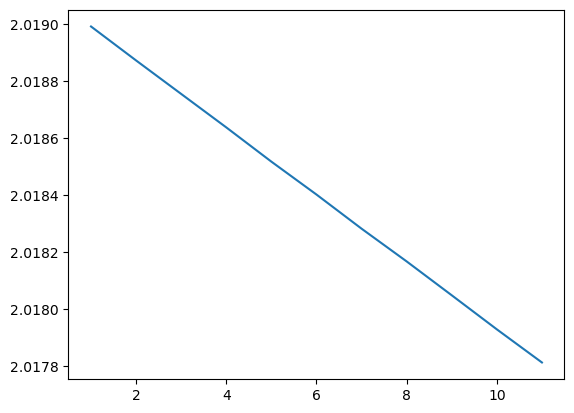

In [156]:
plt.plot(history_df['n_estimator'], history_df['train_loss'])

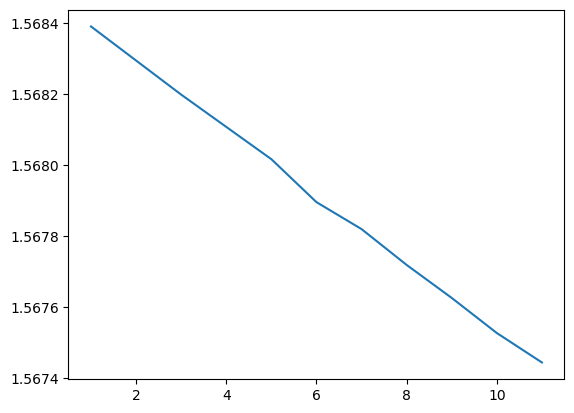

In [157]:
plt.plot(history_df['n_estimator'], history_df['val_loss'])

In [109]:
def select_max_depth_param(patience_epochs, num_estimators, max_depth_range, loss_type):
    '''
    Return a dataframe of the validation losses for different max depths
    '''
    
    # Initialize the GradientBoostingRegressor with a small number of boosting stages
    # use warm_start = True, which keeps the solution from the previous iteration instead of erasing the previous one
    initial_estimators = 10

    losses_df = []
    
    if num_estimators < 10:
        raise ValueError(f"{num_estimators} must be greater than 10")
    
    # Iterate over the range of max_depth values
    for max_depth in max_depth_range:
        
        print(f"\nTesting max_depth = {max_depth}")   

        # for consistency with the CNN, use the same learning rate and early stopping criterion
        gbr_model = GradientBoostingRegressor(n_estimators=initial_estimators, max_depth=max_depth, warm_start=True, loss='absolute_error', criterion='friedman_mse', learning_rate=np.exp(-1.0 * 9), min_samples_split=2, min_samples_leaf=1)
    
        min_loss = 1e3
        patience_counter = 0
    
        # implement custom stopping criterion to match the CNN
        for n in np.arange(11, 10000 + 1):
            
            gbr_model.n_estimators = n
            gbr_model.fit(X_train, y_train)
    
            # Evaluate on validation set
            y_hat = gbr.predict(X_val)
            val_loss = boundedLoss_Reg(y_hat, y_val, lower_bounds_val, upper_bounds_val, loss_type=loss_type)
    
            # if loss decreases by at least 1%
            if float((min_loss - val_loss) / min_loss) >= 0.01:
    
                print(f"{n} estimators: Validation loss improved from {min_loss} to {val_loss}")
    
                # # save the model
                # with open(f"{gradient_boosting_dir}/best_model.sav", 'wb') as file:
                #     pickle.dump(gbr, file)
    
                # zero out the patience counter
                patience_counter = 0
    
                # update the minimum loss
                min_loss = val_loss
    
            else:
                # increment the patience counter
                patience_counter += 1
                
                if patience_counter == patience_epochs:
                    print(f"Early stopping at {n} estimators for max_depth = {max_depth}")
                    break  
    
        # Evaluate on the validation set
        y_hat = gbr_model.predict(X_val)
        
        # keep track of the final loss
        final_val_loss = boundedLoss_Reg(y_hat, y_val, lower_bounds_val, upper_bounds_val, loss_type=loss_type)
        
        losses_df.append(pd.DataFrame({"max_depth": max_depth, "val_loss": final_val_loss}, index=[0]))
        
        del gbr_model
        del y_hat
        del val_loss
        del final_val_loss
        del min_loss
        del patience_counter
        
    return pd.concat(losses_df)

In [111]:
patience_epochs = 20#200
num_estimators = 10000 # very large number like N_epochs in the CNN
max_depth_range = np.arange(3, 11)

losses_df = select_max_depth_param(patience_epochs, num_estimators, max_depth_range, loss_type)


Testing max_depth = 3
11 estimators: Validation loss improved from 1000.0 to 1.5669340182781557
Early stopping at 31 estimators for max_depth = 3

Testing max_depth = 4
11 estimators: Validation loss improved from 1000.0 to 1.5669340182781557
Early stopping at 31 estimators for max_depth = 4

Testing max_depth = 5
11 estimators: Validation loss improved from 1000.0 to 1.5669340182781557
Early stopping at 31 estimators for max_depth = 5

Testing max_depth = 6
11 estimators: Validation loss improved from 1000.0 to 1.5669340182781557
Early stopping at 31 estimators for max_depth = 6

Testing max_depth = 7
11 estimators: Validation loss improved from 1000.0 to 1.5669340182781557
Early stopping at 31 estimators for max_depth = 7

Testing max_depth = 8
11 estimators: Validation loss improved from 1000.0 to 1.5669340182781557
Early stopping at 31 estimators for max_depth = 8

Testing max_depth = 9
11 estimators: Validation loss improved from 1000.0 to 1.5669340182781557
Early stopping at 31 

In [114]:
best_max_depth = losses_df.sort_values("val_loss", ascending=True)["max_depth"].values[0]
print(f"    Max tree depth: {best_max_depth}, minimum validation loss: {losses_df.sort_values('val_loss', ascending=True)['val_loss'].values[0]}")

    Max tree depth: 10, minimum validation loss: 1.565473471772816


In [117]:
gbr.train_score_.shape

(21,)

In [161]:
for drug in os.listdir(data_dir):
    if os.path.isdir(f"{results_dir}/{drug}/gradient_boosting"):
        print(drug)
        # shutil.rmtree(f"{results_dir}/{drug}/gradient_boosting")

In [119]:
gbr

GradientBoostingRegressor(learning_rate=0.00012340980408667956,
                          loss='absolute_error', n_estimators=21,
                          warm_start=True)

In [120]:
gbr.train_score_.shape

(21,)

In [125]:
np.arange(0, n)

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20])

In [93]:
with open(f"{gradient_boosting_dir}/best_model.sav", "rb") as file:
    saved_model = pickle.load(file)

In [94]:
saved_model

GradientBoostingRegressor(learning_rate=0.00012340980408667956,
                          loss='absolute_error', n_estimators=11,
                          warm_start=True)

In [96]:
y_hat = saved_model.predict(X_val)
boundedLoss_Reg(y_hat, y_val, lower_bounds_val, upper_bounds_val, loss_type=loss_type) == val_loss[0]

True

In [75]:
boundedLoss_Reg(y_hat, y_val, lower_bounds_val, upper_bounds_val, loss_type=loss_type)

1.5676768384171724

In [61]:
def boundedLoss_Reg(y_pred, y_true, lower_bounds, upper_bounds, loss_type="L1"):
    '''
    This function is used to select the regularization strength of a Regression model. It is the Regression analog
    of boundedLoss_CNN
    
    y_test and y_pred are log2-transformed. lower_bounds and upper_bounds are NOT
    loss_type is L1 or L2, specifying whether to return the MAE or MSE
    '''

    # lower_bounds /= 2
    # upper_bounds *= 2

    # add a tiny amount so they can be log-transformed, then log-transform
    lower_bounds[lower_bounds==0] += 1e-6
    lower_bounds = np.log2(lower_bounds)
    upper_bounds = np.log2(upper_bounds)

    # determine whether to compute error from the bounds or if the error is 0. 
    bound_to_compute_error = np.clip(y_pred, lower_bounds, upper_bounds)

    # compute the errors first using the log-MICs, based on the desired loss type
    # if you want to compute error relative to the midpoint, replace bound_to_compute_error with y_true
    if loss_type == "L1":
        errors = np.abs(bound_to_compute_error - y_pred)
    elif loss_type == "L2":
        errors = np.exp2(bound_to_compute_error - y_pred)
    else:
        raise RuntimeError(f"{loss_type} is not a valid loss function type")

    # use less than or equal to because the true MIC is in the range (lower, upper], so it is not equal to lower.
    outside_bounds_mask = (np.less_equal(y_pred, lower_bounds) | np.greater(y_pred, upper_bounds)).astype(int)

    # multiply so that the points predicted in their bin are multiplied by 0 so they have 0 error
    masked_errors = outside_bounds_mask * errors

    # because we used np.clip above, the value in the errors array for points predicted within the MIC bin will be 0, so just take the simple mean
    return np.mean(masked_errors)

In [ ]:
def train_single_CNN(model, loss_type, N_epochs, train_generator, val_generator, num_train, num_val, save_model_fName, save_history_df=False, patience_epochs=None, return_min_loss=False):

    output_path = os.path.dirname(save_model_fName)
    
    optimizer = Adam(learning_rate = np.exp(-1.0 * 9))
    
    if patience_epochs is None:
        print(f"    Training the model with an {loss_type} loss for {N_epochs} epochs")
    else:
        print(f"    Using early stopping with an {loss_type} loss and a delay of {patience_epochs} epochs")
    
    # manual implementation of model callbacks
    patience_counter = 0
    min_loss = 1e3
    
    # initialize lists to store losses
    train_loss = []
    train_error = []
    val_loss = []
    val_error = []
    
    history = pd.DataFrame(columns=["loss", "error", "val_loss", "val_error"])

    for epoch in range(N_epochs):
                   
        # list to keep track of the losses for each batch
        train_epoch_loss = []
        train_epoch_error = []
        val_epoch_loss = []
        val_epoch_error = []
        
        # training loop
        for x_batch_train, y_batch_train in train_generator:
                    
            # compute loss and error. These are sums over the points in the batch
            loss, error = train_step(model, optimizer, loss_type, x_batch_train, y_batch_train)
            
            train_epoch_loss.append(loss)
            train_epoch_error.append(error)
            
        # store losses for the epoch -- mean of all the batches
        train_loss.append(np.sum(train_epoch_loss) / num_train)   
        train_error.append(np.sum(train_epoch_error) / num_train)
    
        # validation loop -- iterate through all batches
        for x_batch_val, y_batch_val in val_generator:
                            
            # compute loss and error
            loss, error = val_step(model, loss_type, x_batch_val, y_batch_val)
            
            val_epoch_loss.append(loss)
            val_epoch_error.append(error)
          
        # store the mean loss of the batch
        val_loss.append(np.sum(val_epoch_loss) / num_val)
        val_error.append(np.sum(val_epoch_error) / num_val)
    
        history.loc[epoch, :] = [train_loss[-1], train_error[-1], val_loss[-1], val_error[-1]]    
        
        if patience_epochs is not None:
            # if loss decreases by at least 1%
            if float((min_loss - val_loss[-1]) / min_loss) >= 0.01:
            
                print(f"Epoch {epoch+1}: Validation loss improved from {min_loss} to {val_loss[-1]}")
                
                # save the model because it is better than the previous iteration
                model.save(save_model_fName)
    
                # update min loss, then zero out the patience counter
                min_loss = val_loss[-1]
                patience_counter = 0
                
            else:
                patience_counter += 1
    
            if patience_counter == patience_epochs:
                break
        
        # train the model for the specified number of epochs
        else:
            print(f"Epoch {epoch} validation loss: {val_loss[-1]}")

    # only save the model if not using early stopping because it doesn't get saved as you go in the above loop
    if patience_epochs is None:
        model.save(save_model_fName)

    # clear all model variables
    K.clear_session()

    # save the history dataframe to see the additional epochs during the patience period. DON'T SAVE THE MODEL because we want the model at the early stop point
    if save_history_df:
        history.to_csv(os.path.join(output_path, "history.csv"), index=False)
    else:
        return history["val_loss"].values
    
    # this is for cross-validation of the regularization parameter: return the losses to keep track which regularization strength is best
    if return_min_loss:
        # if using early stopping, then the loss of the trained model is the min_loss (because it got updated)
        if patience_epochs is not None:
            return min_loss
        # if not using early stopping, then the model loss is the last value in val_loss (because you trained the model for a specified number of epochs and are taking the last loss)
        else:
            return val_loss[-1]

In [ ]:
# Create and train a Random Forest Regression model
rf_regressor = RandomForestRegressor(n_estimators=100, random_state=42)
rf_regressor.fit(X_train, y_train)

# Make predictions on the test data
y_pred = rf_regressor.predict(X_test)

# Evaluate the model by calculating Mean Squared Error (MSE)
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse}")

In [ ]:
bcftools norm --fasta-ref /n/data1/hms/dbmi/farhat/mtb_data/h37rv/h37rv.fna /n/data1/hms/dbmi/farhat/rollingDB/genomic_data/EC367-431/pilon/EC367-431_variants.vcf | bcftools filter -i "POS==4326539 | POS ==4326540"

In [ ]:
all_fastq_files = glob.glob("/n/data1/hms/dbmi/farhat/upload/fastq/*/*.fastq*")
len(all_fastq_files)

In [22]:
sample_id = 'SAMN06094087'
df = pd.read_csv(f"/n/data1/hms/dbmi/farhat/rollingDB/genomic_data/SAMN06094087/WHO_resistance/{sample_id}_variants.tsv", sep='\t')

df = split_annotations(df)

In [26]:
who_variants.query("effect=='start_lost'").mutation.unique()

array(['p.Met1?'], dtype=object)

In [39]:
df_ablation = get_variants_with_ablations(df)

In [40]:
df_ablation

,POS,REF,ALT,FILTER,QUAL,AF,DP,BQ,MQ,GENE,EFFECT,variant
0,2289053,GTCCGGTGTGCCGGAGAAGTGGTCACCCGGGTCGATGTGGAAGTCC...,G,PASS,0.0,NaN,NaN,NaN,NaN,Rv2044c,transcript_ablation,Rv2044c_deletion
1,2289053,GTCCGGTGTGCCGGAGAAGTGGTCACCCGGGTCGATGTGGAAGTCC...,G,PASS,0.0,NaN,NaN,NaN,NaN,pncA,start_lost,p.Met1?


In [18]:
df.query("EFFECT=='frameshift'")

,POS,REF,ALT,FILTER,QUAL,IMPRECISE,AF,DP,BQ,MQ,...,EFFECT_1,GENE_1,EFFECT_2,GENE_2,EFFECT_3,GENE_3,EFFECT_4,GENE_4,EFFECT_5,GENE_5


In [15]:
df.query("POS==2289053")

,POS,REF,ALT,FILTER,QUAL,IMPRECISE,AF,DP,BQ,MQ,...,EFFECT_1,GENE_1,EFFECT_2,GENE_2,EFFECT_3,GENE_3,EFFECT_4,GENE_4,EFFECT_5,GENE_5
14,2289053,GTCCGGTGTGCCGGAGAAGTGGTCACCCGGGTCGATGTGGAAGTCC...,G,PASS,0.0,False,NaN,NaN,NaN,NaN,...,gene_fusion,lipT&pncA,frameshift_variant&start_lost,pncA,frameshift_variant&stop_lost&splice_region_var...,lipT,intergenic_region,pncA-Rv2044c,intergenic_region,Rv2044c-lipT


In [38]:
# who_variants.query("effect=='start_lost'")

In [42]:
who_variants.query("variant=='pncA_p.Met1?'")

,drug,gene,mutation,variant,tier,effect,genomic position,algorithm_pass,Present_SOLO_SR,Present_SOLO_R,...,Additional grading criteria applied,FINAL CONFIDENCE GRADING,Comment,CHANGES vs ver1,"Relaxed thresholds simulation (BDQ_Rv0678, CFZ_Rv0678, INH_katG, DLM_ddn/fbiA/fbiB/fbiC/fgd1/Rv2983)",Silent mutation,Listed in abridged tables,Additional grading,Footnote,CHANGES vs ver1.1
36066,Pyrazinamide,pncA,p.Met1?,pncA_p.Met1?,1,start_lost,"(see ""Genomic_coordinates"" sheet)",1.0,9.0,9.0,...,NaN,1) Assoc w R,NaN,UP from AwRI to AwR,NaN,NaN,yes,NaN,NaN,4


In [5]:
regression_who_results.query("mutation=='ethA_LoF'")

,Drug,gene,mutation,predicted_effect,WHO_Odds_Ratio,WHO_pval,WHO_BH_pval,WHO_neutral_pval,WHO_BH_neutral_pval,WHO_LRT_pval,...,ALL_Sens_UB,ALL_Spec_LB,ALL_Spec_UB,Initial confidence grading ALL dataset,REGRESSION FINAL CONFIDENCE GRADING,Reason,SOLO INITIAL CONFIDENCE GRADING,SOLO FINAL CONFIDENCE GRADING,REGRESSION GRADING + LOF UPGRADE,REGRESSION + GRADING RULES
8760,Ethionamide,ethA,ethA_LoF,LoF,1.946153,0.0,0.0,1.0,1.0,3.613601e-91,...,0.256824,0.937028,0.944527,Assoc w R,1) Assoc w R,Both Assoc w R,1) Assoc w R,1) Assoc w R,1) Assoc w R,1) Assoc w R


In [10]:
regression_who_results.query("mutation=='mshA_LoF'")

,Drug,gene,mutation,predicted_effect,WHO_Odds_Ratio,WHO_pval,WHO_BH_pval,WHO_neutral_pval,WHO_BH_neutral_pval,WHO_LRT_pval,...,ALL_Sens_UB,ALL_Spec_LB,ALL_Spec_UB,Initial confidence grading ALL dataset,REGRESSION FINAL CONFIDENCE GRADING,Reason,SOLO INITIAL CONFIDENCE GRADING,SOLO FINAL CONFIDENCE GRADING,REGRESSION GRADING + LOF UPGRADE,REGRESSION + GRADING RULES
8800,Ethionamide,mshA,mshA_LoF,LoF,1.058524,0.021,0.066379,0.938,1.0,0.04586,...,0.007729,0.99777,0.999057,Assoc w R,2) Assoc w R - Interim,Upgrade to Interim,3) Uncertain significance,3) Uncertain significance,2) Assoc w R - Interim,2) Assoc w R - Interim


In [10]:
seq_1 = [(seq.id, seq.seq) for seq in SeqIO.parse("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/CFZ/inSilico_analysis/Rv0678/fastas/Rv0678.fasta", "fasta")]
seq_2 = [(seq.id, seq.seq) for seq in SeqIO.parse("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/CFZ/inSilico_analysis/pepQ/fastas/Rv0678.fasta", "fasta")]

In [11]:
str(seq_1[-1][1]) == str(seq_2[-1][1])

True

In [13]:
model_loci.query("Locus=='ethA'")

,Locus,Start,End,Sense
45,ethA,4326003,4327548,-


In [236]:
fName='/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/VCF_clean/SAMEA7525167.vcf'
# fName='/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/VCF_clean/SAMEA7563381.vcf'
START = 4326003
END = 4327548
SENSE = '-'

genome_len = len(h37Rv)
print(f"Reference genome size: {genome_len}")

# get only the region of interest
h37Rv_region = list(str(h37Rv.seq[START:END]))
print(f"Unaligned region size: {len(h37Rv_region)}")

Reference genome size: 4411532
Unaligned region size: 1545


In [237]:
# VCF file was indexed using 0-indexed half-open scheme, so keep START and END coords as they are
vcf_reader = vcf.Reader(filename=f"{fName}.bgz", compressed=True)

# need to read in the bgzipped file in order to use fetch
records = vcf_reader.fetch('NC_000962.3', start=START, end=END)

for record in records:
    print(record)

Record(CHROM=NC_000962.3, POS=4326899, REF=GGCACGAGCGTGACCGCCGTTGCGCCACTGCCGATCACGACGATGTTCTTAGCGTCGTAGTCGAGGTCCTCGGGCCAGTGCTGCGGATGGATGATCGGCCCGACGAAATCCTCCGAGCCGGCGAATCTCGGCGAGTAGCCCTCGTCGTAGTTGTAGTAGCCGCTGCACAGAAAGAGGAATTCGCAGGTGAGGGCGCTGAGCGTGCCGTGGCTTTGGATGTGAACGGTCCAGCGGTTTTCCGCGGTCGACCAATCGGCACTGATCACCTTGTGGTGGAACCGGATATGCCTGTCGATTCCATACATGGCCGCGGTGCTCTTGACGTACTCGAGGATGGGCTTGCCGTCGGCGATCGCCTGCCGTCCGGTCCAGGGACGGAATCGGAAACCTAGCGTGTACATGTCGGAGTCGGAGCGAATTCCGGGATAACGGAACAAATCCCAGGTGCCGCCCATGGATTCCCGCTTTTCCAGGATGGCGTAGCTCTTGGTCGGGCAACGGTCCTGCAGGTGCCAGGCCGCGCTGACACCGGAGATTCCAGCGCCCACGATGACAACGTCGAGGTGCTCGGTCATGGATCCACGCTATCAACGTAATGTCGAGGCCGTCAACGAGATGTCGACACTATCGACACGTAGTAAGCTGCCAGGGTGACCACCTCCGCGGCCAGTCAGGCTTCGCTGCCTAGGGGCCGGCGCACCGCGCGGCCGTCCGGCGACGATCGTGAACTGGCGATCCTCGCCACCGCCGAGAACCTTCTCGAGGACCGTCCGCTGGCCGATATCTCGGTCGACGATCTGGCCAAGGGCGCCGGTATCTCGAGGCCGACGTTCTACTTCTATTTCCCATCCAAGGAAGCGGTGCTGCTGACCCTGCTGGACCGGGTGGTCAATCAAGCCGACATGGCCCTACAGACCCTTGCCGAGAATCCCGCCGACACCGACCGCGAGAACATGT

In [239]:
new_thing = introduce_snps_indels_single_seq(fName, h37Rv_region, START, END)

1657
CTAAACCCCCACCGGGGCAGGCCTTTTGGCGAACCGCAGACCCTCGTCGTCGATCTTGCCGCGCCGGATGAGCCGGATGTCACGTAGGTAGTTCTGATTCAGGCGCCACGGTGTACGCGAACCCTGCTTGGGCAGCTCGTCCAGCGAGCGCAGCACGTAACCTGGGGTGAACTCCATGAAGGGCCGCTCTTCGACATCTGAGCCCGGTCGCTCGACGACCACGGTGTCAAAACCGTTGTCGTCCATGTAATTCAACAAGCGACAGACAAACTCCGACACCAGGTCGGCCTTCAGCGTCCAGGAGGCATTGGTGTAGCCAACCGTGTAGGCCATGTTGGGGATGCCGGAAAGCATCATGCCCTTGTAGGCCATCGTCGTGGTGATGTCCACTTGTTGTCCGTCGATAGTCGCCGTCGCCCCACCAAAAAGCTGCAGGTTCAACCCCGTTGCGGTAATGATGATGTCAGCCGGCAGTTCGCGACCTGAGTTCAGCCGGATTCCGGTCGCGGTGAACCGTTCAATGGTGTCGGTCACCACCTCGACCTTCCCGTGACGAATGGCCCGGAACAGGTCGCCGTTGGGCACCAAGCACAATCGCTGGTCCCAGGGGTTGTAGTGCGGGCCGAAGTGCTTTCGCACGTCGTACCCCTCGGGTAGCTGGCGCTGGATCAGGCTCAGGAACATCTTCCGCATGCGCCGTGGCCACTTCTGGCAGGCGCTGTACACGGCCGCCTGGCGCAGCACGTTCTTCCACCGTACCGCGGTGTAGGCCATGGTCTCCGGCAGCCAGCGGTTGAGCTTCTCGGCGATGCCGTCCCGGTCTGGCTGCGACACGATGTAGGTGGGTGAGCGCTGCAGCATCGTGACGTGCTTGGCGCCCGAGTCCGCCAGCGCC
GGCACGAGCGTGACCGCCGTTGCGCCACTGCCGATCACGACGATGTTCTTAGCGTCGTAGTCGAGGTCCTCGGGCCAGTGCTGCGGATGGATGATCGGC

In [240]:
''.join(new_thing)

'CTAAACCCCCACCGGGGCAGGCCTTTTGGCGAACCGCAGACCCTCGTCGTCGATCTTGCCGCGCCGGATGAGCCGGATGTCACGTAGGTAGTTCTGATTCAGGCGCCACGGTGTACGCGAACCCTGCTTGGGCAGCTCGTCCAGCGAGCGCAGCACGTAACCTGGGGTGAACTCCATGAAGGGCCGCTCTTCGACATCTGAGCCCGGTCGCTCGACGACCACGGTGTCAAAACCGTTGTCGTCCATGTAATTCAACAAGCGACAGACAAACTCCGACACCAGGTCGGCCTTCAGCGTCCAGGAGGCATTGGTGTAGCCAACCGTGTAGGCCATGTTGGGGATGCCGGAAAGCATCATGCCCTTGTAGGCCATCGTCGTGGTGATGTCCACTTGTTGTCCGTCGATAGTCGCCGTCGCCCCACCAAAAAGCTGCAGGTTCAACCCCGTTGCGGTAATGATGATGTCAGCCGGCAGTTCGCGACCTGAGTTCAGCCGGATTCCGGTCGCGGTGAACCGTTCAATGGTGTCGGTCACCACCTCGACCTTCCCGTGACGAATGGCCCGGAACAGGTCGCCGTTGGGCACCAAGCACAATCGCTGGTCCCAGGGGTTGTAGTGCGGGCCGAAGTGCTTTCGCACGTCGTACCCCTCGGGTAGCTGGCGCTGGATCAGGCTCAGGAACATCTTCCGCATGCGCCGTGGCCACTTCTGGCAGGCGCTGTACACGGCCGCCTGGCGCAGCACGTTCTTCCACCGTACCGCGGTGTAGGCCATGGTCTCCGGCAGCCAGCGGTTGAGCTTCTCGGCGATGCCGTCCCGGTCTGGCTGCGACACGATGTAGGTGGGTGAGCGCTGCAGCATCGTGACGTGCTTGGCGCCCGAGTCCGCCAGCGCCGT------------------------------------------------------------------------------------------------------

In [212]:
str(h37Rv_seq.seq[4325704:START])

'TCCCTGCACACCGCGTTGGTCGGTGATGTCATCGCCGAGTTGGCCCGCTCTACCGGCTGGACCGGGTTGATCGTCCACGGCGCGGTGCGAGATGCCGCCGCGCTGCGCGGCATCGACATCGGCATCAAAGCGCTGGGCACCAATCCCCGCAAGAGCACCAAGACCGGTGCCGGAGAACGCGACGTTGAAATCACGCTGGGCGGGGTGACATTCGTTCCGGGCGATATCGCCTACAGCGACGACGACGGCATCATCGTCGTCTGACTATGGCCTAAACCGGCGCTAAACCGTCGCTAAAG'

In [221]:
# remove 299 nucleotides from the front and 1194 nucleotides from the end
len(str(h37Rv_seq.seq[4325704:START]))

299

In [214]:
str(h37Rv_seq.seq[START:END])

'CTAAACCCCCACCGGGGCAGGCCTTTTGGCGAACCGCAGACCCTCGTCGTCGATCTTGCCGCGCCGGATGAGCCGGATGTCACGTAGGTAGTTCTGATTCAGGCGCCACGGTGTACGCGAACCCTGCTTGGGCAGCTCGTCCAGCGAGCGCAGCACGTAACCTGGGGTGAACTCCATGAAGGGCCGCTCTTCGACATCTGAGCCCGGTCGCTCGACGACCACGGTGTCAAAACCGTTGTCGTCCATGTAATTCAACAAGCGACAGACAAACTCCGACACCAGGTCGGCCTTCAGCGTCCAGGAGGCATTGGTGTAGCCAACCGTGTAGGCCATGTTGGGGATGCCGGAAAGCATCATGCCCTTGTAGGCCATCGTCGTGGTGATGTCCACTTGTTGTCCGTCGATAGTCGCCGTCGCCCCACCAAAAAGCTGCAGGTTCAACCCCGTTGCGGTAATGATGATGTCAGCCGGCAGTTCGCGACCTGAGTTCAGCCGGATTCCGGTCGCGGTGAACCGTTCAATGGTGTCGGTCACCACCTCGACCTTCCCGTGACGAATGGCCCGGAACAGGTCGCCGTTGGGCACCAAGCACAATCGCTGGTCCCAGGGGTTGTAGTGCGGGCCGAAGTGCTTTCGCACGTCGTACCCCTCGGGTAGCTGGCGCTGGATCAGGCTCAGGAACATCTTCCGCATGCGCCGTGGCCACTTCTGGCAGGCGCTGTACACGGCCGCCTGGCGCAGCACGTTCTTCCACCGTACCGCGGTGTAGGCCATGGTCTCCGGCAGCCAGCGGTTGAGCTTCTCGGCGATGCCGTCCCGGTCTGGCTGCGACACGATGTAGGTGGGTGAGCGCTGCAGCATCGTGACGTGCTTGGCGCCCGAGTCCGCCAGCGCCGGCACGAGCGTGACCGCCGTTGCGCCACTGCCGATCACGACGATGTTCTTAGCGTCGTAGTCGAGGTCCTCGGGCCAGTGCTGCGGATGGATGATCGGCCCGAC

In [219]:
str(h37Rv_seq.seq[END:4328742])

'GTGACCACCTCCGCGGCCAGTCAGGCTTCGCTGCCTAGGGGCCGGCGCACCGCGCGGCCGTCCGGCGACGATCGTGAACTGGCGATCCTCGCCACCGCCGAGAACCTTCTCGAGGACCGTCCGCTGGCCGATATCTCGGTCGACGATCTGGCCAAGGGCGCCGGTATCTCGAGGCCGACGTTCTACTTCTATTTCCCATCCAAGGAAGCGGTGCTGCTGACCCTGCTGGACCGGGTGGTCAATCAAGCCGACATGGCCCTACAGACCCTTGCCGAGAATCCCGCCGACACCGACCGCGAGAACATGTGGCGCACCGGGATCAACGTGTTCTTCGAGACATTCGGGTCGCACAAGGCGGTAACCCGAGCCGGTCAGGCCGCCAGGGCAACCAGTGTCGAAGTCGCCGAACTGTGGTCGACGTTTATGCAGAAGTGGATCGCCTACACGGCCGCCGTGATCGACGCCGAACGCGACCGAGGCGCGGCGCCGCGCACCCTGCCGGCCCATGAACTGGCCACAGCGCTCAACCTGATGAACGAGCGGACGCTGTTCGCGTCATTCGCCGGCGAACAGCCCTCGGTGCCGGAAGCCCGCGTGCTGGATACGCTGGTGCACATCTGGGTGACCAGCATTTACGGCGAGAACCGCTAAGCCGCACTCGGTCGGGGGTGCTCGGTCGATGCTCAGTGCCAAAGCGGCATGCAGATCTCACGGAGGTCCGGTGGACGATCTGGCAGCCGAAGTGGCGCCTTGGGTAGGCAATGGCGTGCGGTCATATAGGAGCGGGTGCATTCGCATGTCGGACACGTGGCGTTGCCGCCTGGTACCGCGGTGTTCGTGGCCGACAGCGGGCTAATGCGACCCGGTCCACGCCAGGAGCGTGTCGGCCGGCCAGGTGTTGACGATCCGGTCGGCGGGCACCTCCGCGTCCAAGGCGCGCTGGGCGCCGTAGCCGAGGAAGTCCAGCTGGCCGGGTGCGTGCGCGTCGGTGTCGATGCT

In [222]:
len(str(h37Rv_seq.seq[END:4328742]))

1194

In [220]:
''.join(h37Rv_region)

'CTAAACCCCCACCGGGGCAGGCCTTTTGGCGAACCGCAGACCCTCGTCGTCGATCTTGCCGCGCCGGATGAGCCGGATGTCACGTAGGTAGTTCTGATTCAGGCGCCACGGTGTACGCGAACCCTGCTTGGGCAGCTCGTCCAGCGAGCGCAGCACGTAACCTGGGGTGAACTCCATGAAGGGCCGCTCTTCGACATCTGAGCCCGGTCGCTCGACGACCACGGTGTCAAAACCGTTGTCGTCCATGTAATTCAACAAGCGACAGACAAACTCCGACACCAGGTCGGCCTTCAGCGTCCAGGAGGCATTGGTGTAGCCAACCGTGTAGGCCATGTTGGGGATGCCGGAAAGCATCATGCCCTTGTAGGCCATCGTCGTGGTGATGTCCACTTGTTGTCCGTCGATAGTCGCCGTCGCCCCACCAAAAAGCTGCAGGTTCAACCCCGTTGCGGTAATGATGATGTCAGCCGGCAGTTCGCGACCTGAGTTCAGCCGGATTCCGGTCGCGGTGAACCGTTCAATGGTGTCGGTCACCACCTCGACCTTCCCGTGACGAATGGCCCGGAACAGGTCGCCGTTGGGCACCAAGCACAATCGCTGGTCCCAGGGGTTGTAGTGCGGGCCGAAGTGCTTTCGCACGTCGTACCCCTCGGGTAGCTGGCGCTGGATCAGGCTCAGGAACATCTTCCGCATGCGCCGTGGCCACTTCTGGCAGGCGCTGTACACGGCCGCCTGGCGCAGCACGTTCTTCCACCGTACCGCGGTGTAGGCCATGGTCTCCGGCAGCCAGCGGTTGAGCTTCTCGGCGATGCCGTCCCGGTCTGGCTGCGACACGATGTAGGTGGGTGAGCGCTGCAGCATCGTGACGTGCTTGGCGCCCGAGTCCGCCAGCGCCGGCACGAGCGTGACCGCCGTTGCGCCACTGCCGATCACGACGATGTTCTTAGCGTCGTAGTCGAGGTCCTCGGGCCAGTGCTGCGGATGGATGATCGGCCCGAC

In [163]:
897+649

1546

In [162]:
END - START

1545

In [200]:
new_thing = introduce_snps_indels_single_seq(fName, h37Rv_region, START, END)

1657
CTAAACCCCCACCGGGGCAGGCCTTTTGGCGAACCGCAGACCCTCGTCGTCGATCTTGCCGCGCCGGATGAGCCGGATGTCACGTAGGTAGTTCTGATTCAGGCGCCACGGTGTACGCGAACCCTGCTTGGGCAGCTCGTCCAGCGAGCGCAGCACGTAACCTGGGGTGAACTCCATGAAGGGCCGCTCTTCGACATCTGAGCCCGGTCGCTCGACGACCACGGTGTCAAAACCGTTGTCGTCCATGTAATTCAACAAGCGACAGACAAACTCCGACACCAGGTCGGCCTTCAGCGTCCAGGAGGCATTGGTGTAGCCAACCGTGTAGGCCATGTTGGGGATGCCGGAAAGCATCATGCCCTTGTAGGCCATCGTCGTGGTGATGTCCACTTGTTGTCCGTCGATAGTCGCCGTCGCCCCACCAAAAAGCTGCAGGTTCAACCCCGTTGCGGTAATGATGATGTCAGCCGGCAGTTCGCGACCTGAGTTCAGCCGGATTCCGGTCGCGGTGAACCGTTCAATGGTGTCGGTCACCACCTCGACCTTCCCGTGACGAATGGCCCGGAACAGGTCGCCGTTGGGCACCAAGCACAATCGCTGGTCCCAGGGGTTGTAGTGCGGGCCGAAGTGCTTTCGCACGTCGTACCCCTCGGGTAGCTGGCGCTGGATCAGGCTCAGGAACATCTTCCGCATGCGCCGTGGCCACTTCTGGCAGGCGCTGTACACGGCCGCCTGGCGCAGCACGTTCTTCCACCGTACCGCGGTGTAGGCCATGGTCTCCGGCAGCCAGCGGTTGAGCTTCTCGGCGATGCCGTCCCGGTCTGGCTGCGACACGATGTAGGTGGGTGAGCGCTGCAGCATCGTGACGTGCTTGGCGCCCGAGTCCGCCAGCGCC
GGCACGAGCGTGACCGCCGTTGCGCCACTGCCGATCACGACGATGTTCTTAGCGTCGTAGTCGAGGTCCTCGGGCCAGTGCTGCGGATGGATGATCGGC

In [201]:
''.join(h37Rv_region)

'CTAAACCCCCACCGGGGCAGGCCTTTTGGCGAACCGCAGACCCTCGTCGTCGATCTTGCCGCGCCGGATGAGCCGGATGTCACGTAGGTAGTTCTGATTCAGGCGCCACGGTGTACGCGAACCCTGCTTGGGCAGCTCGTCCAGCGAGCGCAGCACGTAACCTGGGGTGAACTCCATGAAGGGCCGCTCTTCGACATCTGAGCCCGGTCGCTCGACGACCACGGTGTCAAAACCGTTGTCGTCCATGTAATTCAACAAGCGACAGACAAACTCCGACACCAGGTCGGCCTTCAGCGTCCAGGAGGCATTGGTGTAGCCAACCGTGTAGGCCATGTTGGGGATGCCGGAAAGCATCATGCCCTTGTAGGCCATCGTCGTGGTGATGTCCACTTGTTGTCCGTCGATAGTCGCCGTCGCCCCACCAAAAAGCTGCAGGTTCAACCCCGTTGCGGTAATGATGATGTCAGCCGGCAGTTCGCGACCTGAGTTCAGCCGGATTCCGGTCGCGGTGAACCGTTCAATGGTGTCGGTCACCACCTCGACCTTCCCGTGACGAATGGCCCGGAACAGGTCGCCGTTGGGCACCAAGCACAATCGCTGGTCCCAGGGGTTGTAGTGCGGGCCGAAGTGCTTTCGCACGTCGTACCCCTCGGGTAGCTGGCGCTGGATCAGGCTCAGGAACATCTTCCGCATGCGCCGTGGCCACTTCTGGCAGGCGCTGTACACGGCCGCCTGGCGCAGCACGTTCTTCCACCGTACCGCGGTGTAGGCCATGGTCTCCGGCAGCCAGCGGTTGAGCTTCTCGGCGATGCCGTCCCGGTCTGGCTGCGACACGATGTAGGTGGGTGAGCGCTGCAGCATCGTGACGTGCTTGGCGCCCGAGTCCGCCAGCGCCGGCACGAGCGTGACCGCCGTTGCGCCACTGCCGATCACGACGATGTTCTTAGCGTCGTAGTCGAGGTCCTCGGGCCAGTGCTGCGGATGGATGATCGGCCCGAC

In [202]:
''.join(new_thing)

'CTAAACCCCCACCGGGGCAGGCCTTTTGGCGAACCGCAGACCCTCGTCGTCGATCTTGCCGCGCCGGATGAGCCGGATGTCACGTAGGTAGTTCTGATTCAGGCGCCACGGTGTACGCGAACCCTGCTTGGGCAGCTCGTCCAGCGAGCGCAGCACGTAACCTGGGGTGAACTCCATGAAGGGCCGCTCTTCGACATCTGAGCCCGGTCGCTCGACGACCACGGTGTCAAAACCGTTGTCGTCCATGTAATTCAACAAGCGACAGACAAACTCCGACACCAGGTCGGCCTTCAGCGTCCAGGAGGCATTGGTGTAGCCAACCGTGTAGGCCATGTTGGGGATGCCGGAAAGCATCATGCCCTTGTAGGCCATCGTCGTGGTGATGTCCACTTGTTGTCCGTCGATAGTCGCCGTCGCCCCACCAAAAAGCTGCAGGTTCAACCCCGTTGCGGTAATGATGATGTCAGCCGGCAGTTCGCGACCTGAGTTCAGCCGGATTCCGGTCGCGGTGAACCGTTCAATGGTGTCGGTCACCACCTCGACCTTCCCGTGACGAATGGCCCGGAACAGGTCGCCGTTGGGCACCAAGCACAATCGCTGGTCCCAGGGGTTGTAGTGCGGGCCGAAGTGCTTTCGCACGTCGTACCCCTCGGGTAGCTGGCGCTGGATCAGGCTCAGGAACATCTTCCGCATGCGCCGTGGCCACTTCTGGCAGGCGCTGTACACGGCCGCCTGGCGCAGCACGTTCTTCCACCGTACCGCGGTGTAGGCCATGGTCTCCGGCAGCCAGCGGTTGAGCTTCTCGGCGATGCCGTCCCGGTCTGGCTGCGACACGATGTAGGTGGGTGAGCGCTGCAGCATCGTGACGTGCTTGGCGCCCGAGTCCGCCAGCGCCGT------------------------------------------------------------------------------------------------------

In [180]:
''.join(h37Rv_seq[END-1:4326899 + 1657 + 1])

'GGTGACCACCTCCGCGGCCAGTCAGGCTTCGCTGCCTAGGGGCCGGCGCACCGCGCGGCCGTCCGGCGACGATCGTGAACTGGCGATCCTCGCCACCGCCGAGAACCTTCTCGAGGACCGTCCGCTGGCCGATATCTCGGTCGACGATCTGGCCAAGGGCGCCGGTATCTCGAGGCCGACGTTCTACTTCTATTTCCCATCCAAGGAAGCGGTGCTGCTGACCCTGCTGGACCGGGTGGTCAATCAAGCCGACATGGCCCTACAGACCCTTGCCGAGAATCCCGCCGACACCGACCGCGAGAACATGTGGCGCACCGGGATCAACGTGTTCTTCGAGACATTCGGGTCGCACAAGGCGGTAACCCGAGCCGGTCAGGCCGCCAGGGCAACCAGTGTCGAAGTCGCCGAACTGTGGTCGACGTTTATGCAGAAGTGGATCGCCTACACGGCCGCCGTGATCGACGCCGAACGCGACCGAGGCGCGGCGCCGCGCACCCTGCCGGCCCATGAACTGGCCACAGCGCTCAACCTGATGAACGAGCGGACGCTGTTCGCGTCATTCGCCGGCGAACAGCCCTCGGTGCCGGAAGCCCGCGTGCTGGATACGCTGGTGCACATCTGGGTGACCAGCATTTACGGCGAGAACCGCTAAGCCGCACTCGGTCGGGGGTGCTCGGTCGATGCTCAGTGCCAAAGCGGCATGCAGATCTCACGGAGGTCCGGTGGACGATCTGGCAGCCGAAGTGGCGCCTTGGGTAGGCAATGGCGTGCGGTCATATAGGAGCGGGTGCATTCGCATGTCGGACACGTGGCGTTGCCGCCTGGTACCGCGGTGTTCGTGGCCGACAGCGGGCTAATGCGACCCGGTCCACGCCAGGAGCGTGTCGGCCGGCCAGGTGTTGACGATCCGGTCGGCGGGCACCTCCGCGTCCAAGGCGCGCTGGGCGCCGTAGCCGAGGAAGTCCAGCTGGCCGGGTGCGTGCGCGTCGGTGTCGATGC

In [104]:
new_thing = introduce_snps_indels_single_seq(fName, h37Rv_region, START, END)

Ref allele too long
CTAAACCCCCACCGGGGCAGGCCTTTTGGCGAACCGCAGACCCTCGTCGTCGATCTTGCCGCGCCGGATGAGCCGGATGTCACGTAGGTAGTTCTGATTCAGGCGCCACGGTGTACGCGAACCCTGCTTGGGCAGCTCGTCCAGCGAGCGCAGCACGTAACCTGGGGTGAACTCCATGAAGGGCCGCTCTTCGACATCTGAGCCCGGTCGCTCGACGACCACGGTGTCAAAACCGTTGTCGTCCATGTAATTCAACAAGCGACAGACAAACTCCGACACCAGGTCGGCCTTCAGCGTCCAGGAGGCATTGGTGTAGCCAACCGTGTAGGCCATGTTGGGGATGCCGGAAAGCATCATGCCCTTGTAGGCCATCGTCGTGGTGATGTCCACTTGTTGTCCGTCGATAGTCGCCGTCGCCCCACCAAAAAGCTGCAGGTTCAACCCCGTTGCGGTAATGATGATGTCAGCCGGCAGTTCGCGACCTGAGTTCAGCCGGATTCCGGTCGCGGTGAACCGTTCAATGGTGTCGGTCACCACCTCGACCTTCCCGTGACGAATGGCCCGGAACAGGTCGCCGTTGGGCACCAAGCACAATCGCTGGTCCCAGGGGTTGTAGTGCGGGCCGAAGTGCTTTCGCACGTCGTACCCCTCGGGTAGCTGGCGCTGGATCAGGCTCAGGAACATCTTCCGCATGCGCCGTGGCCACTTCTGGCAGGCGCTGTACACGGCCGCCTGGCGCAGCACGTTCTTCCACCGTACCGCGGTGTAGGCCATGGTCTCCGGCAGCCAGCGGTTGAGCTTCTCGGCGATGCCGTCCCGGTCTGGCTGCGACACGATGTAGGTGGGTGAGCGCTGCAGCATCGTGACGTGCTTGGCGCCCGAGTCCGCCAGCGCCGGCACGAGCGTGACCGCCGTTGCGCCACTGCCGATCACGACGATGTTCTTAGCGTCGTAGTCGAGGTCCTCGGGCCAGTGCTGCG

In [100]:
''.join(h37Rv_seq[START:END])

'CTAAACCCCCACCGGGGCAGGCCTTTTGGCGAACCGCAGACCCTCGTCGTCGATCTTGCCGCGCCGGATGAGCCGGATGTCACGTAGGTAGTTCTGATTCAGGCGCCACGGTGTACGCGAACCCTGCTTGGGCAGCTCGTCCAGCGAGCGCAGCACGTAACCTGGGGTGAACTCCATGAAGGGCCGCTCTTCGACATCTGAGCCCGGTCGCTCGACGACCACGGTGTCAAAACCGTTGTCGTCCATGTAATTCAACAAGCGACAGACAAACTCCGACACCAGGTCGGCCTTCAGCGTCCAGGAGGCATTGGTGTAGCCAACCGTGTAGGCCATGTTGGGGATGCCGGAAAGCATCATGCCCTTGTAGGCCATCGTCGTGGTGATGTCCACTTGTTGTCCGTCGATAGTCGCCGTCGCCCCACCAAAAAGCTGCAGGTTCAACCCCGTTGCGGTAATGATGATGTCAGCCGGCAGTTCGCGACCTGAGTTCAGCCGGATTCCGGTCGCGGTGAACCGTTCAATGGTGTCGGTCACCACCTCGACCTTCCCGTGACGAATGGCCCGGAACAGGTCGCCGTTGGGCACCAAGCACAATCGCTGGTCCCAGGGGTTGTAGTGCGGGCCGAAGTGCTTTCGCACGTCGTACCCCTCGGGTAGCTGGCGCTGGATCAGGCTCAGGAACATCTTCCGCATGCGCCGTGGCCACTTCTGGCAGGCGCTGTACACGGCCGCCTGGCGCAGCACGTTCTTCCACCGTACCGCGGTGTAGGCCATGGTCTCCGGCAGCCAGCGGTTGAGCTTCTCGGCGATGCCGTCCCGGTCTGGCTGCGACACGATGTAGGTGGGTGAGCGCTGCAGCATCGTGACGTGCTTGGCGCCCGAGTCCGCCAGCGCCGGCACGAGCGTGACCGCCGTTGCGCCACTGCCGATCACGACGATGTTCTTAGCGTCGTAGTCGAGGTCCTCGGGCCAGTGCTGCGGATGGATGATCGGCCCGAC

In [107]:
str(h37Rv_seq.seq[START:4326899-1])

'CTAAACCCCCACCGGGGCAGGCCTTTTGGCGAACCGCAGACCCTCGTCGTCGATCTTGCCGCGCCGGATGAGCCGGATGTCACGTAGGTAGTTCTGATTCAGGCGCCACGGTGTACGCGAACCCTGCTTGGGCAGCTCGTCCAGCGAGCGCAGCACGTAACCTGGGGTGAACTCCATGAAGGGCCGCTCTTCGACATCTGAGCCCGGTCGCTCGACGACCACGGTGTCAAAACCGTTGTCGTCCATGTAATTCAACAAGCGACAGACAAACTCCGACACCAGGTCGGCCTTCAGCGTCCAGGAGGCATTGGTGTAGCCAACCGTGTAGGCCATGTTGGGGATGCCGGAAAGCATCATGCCCTTGTAGGCCATCGTCGTGGTGATGTCCACTTGTTGTCCGTCGATAGTCGCCGTCGCCCCACCAAAAAGCTGCAGGTTCAACCCCGTTGCGGTAATGATGATGTCAGCCGGCAGTTCGCGACCTGAGTTCAGCCGGATTCCGGTCGCGGTGAACCGTTCAATGGTGTCGGTCACCACCTCGACCTTCCCGTGACGAATGGCCCGGAACAGGTCGCCGTTGGGCACCAAGCACAATCGCTGGTCCCAGGGGTTGTAGTGCGGGCCGAAGTGCTTTCGCACGTCGTACCCCTCGGGTAGCTGGCGCTGGATCAGGCTCAGGAACATCTTCCGCATGCGCCGTGGCCACTTCTGGCAGGCGCTGTACACGGCCGCCTGGCGCAGCACGTTCTTCCACCGTACCGCGGTGTAGGCCATGGTCTCCGGCAGCCAGCGGTTGAGCTTCTCGGCGATGCCGTCCCGGTCTGGCTGCGACACGATGTAGGTGGGTGAGCGCTGCAGCATCGTGACGTGCTTGGCGCCCGAGTCCGCCAGCGCC'

In [ ]:
GGCACGAGCGTGACCGCCGTTGCGCCACTGCCGATCACGACGATGTTCTTAGCGTCGTAGTCGAGGTCCTCGGGCCAGTGCTGCGGATGGATGATCGGCCCGACGAAATCCTCCGAGCCGGCGAATCTCGGCGAGTAGCCCTCGTCGTAGTTGTAGTAGCCGCTGCACAGAAAGAGGAATTCGCAGGTGAGGGCGCTGAGCGTGCCGTGGCTTTGGATGTGAACGGTCCAGCGGTTTTCCGCGGTCGACCAATCGGCACTGATCACCTTGTGGTGGAACCGGATATGCCTGTCGATTCCATACATGGCCGCGGTGCTCTTGACGTACTCGAGGATGGGCTTGCCGTCGGCGATCGCCTGCCGTCCGGTCCAGGGACGGAATCGGAAACCTAGCGTGTACATGTCGGAGTCGGAGCGAATTCCGGGATAACGGAACAAATCCCAGGTGCCGCCCATGGATTCCCGCTTTTCCAGGATGGCGTAGCTCTTGGTCGGGCAACGGTCCTGCAGGTGCCAGGCCGCGCTGACACCGGAGATTCCAGCGCCCACGATGACAACGTCGAGGTGCTCGGTCATGGATCCACGCTATCAACGTAATGTCGAGGCCGTCAACGAGATGTCGACACTATCGACACGTAGTAAGCTGCCAG

In [108]:
str(h37Rv_seq.seq[4326899-1: END])

'GGCACGAGCGTGACCGCCGTTGCGCCACTGCCGATCACGACGATGTTCTTAGCGTCGTAGTCGAGGTCCTCGGGCCAGTGCTGCGGATGGATGATCGGCCCGACGAAATCCTCCGAGCCGGCGAATCTCGGCGAGTAGCCCTCGTCGTAGTTGTAGTAGCCGCTGCACAGAAAGAGGAATTCGCAGGTGAGGGCGCTGAGCGTGCCGTGGCTTTGGATGTGAACGGTCCAGCGGTTTTCCGCGGTCGACCAATCGGCACTGATCACCTTGTGGTGGAACCGGATATGCCTGTCGATTCCATACATGGCCGCGGTGCTCTTGACGTACTCGAGGATGGGCTTGCCGTCGGCGATCGCCTGCCGTCCGGTCCAGGGACGGAATCGGAAACCTAGCGTGTACATGTCGGAGTCGGAGCGAATTCCGGGATAACGGAACAAATCCCAGGTGCCGCCCATGGATTCCCGCTTTTCCAGGATGGCGTAGCTCTTGGTCGGGCAACGGTCCTGCAGGTGCCAGGCCGCGCTGACACCGGAGATTCCAGCGCCCACGATGACAACGTCGAGGTGCTCGGTCATGGATCCACGCTATCAACGTAATGTCGAGGCCGTCAACGAGATGTCGACACTATCGACACGTAGTAAGCTGCCAGG'

In [110]:
''.join(new_thing)

'CTAAACCCCCACCGGGGCAGGCCTTTTGGCGAACCGCAGACCCTCGTCGTCGATCTTGCCGCGCCGGATGAGCCGGATGTCACGTAGGTAGTTCTGATTCAGGCGCCACGGTGTACGCGAACCCTGCTTGGGCAGCTCGTCCAGCGAGCGCAGCACGTAACCTGGGGTGAACTCCATGAAGGGCCGCTCTTCGACATCTGAGCCCGGTCGCTCGACGACCACGGTGTCAAAACCGTTGTCGTCCATGTAATTCAACAAGCGACAGACAAACTCCGACACCAGGTCGGCCTTCAGCGTCCAGGAGGCATTGGTGTAGCCAACCGTGTAGGCCATGTTGGGGATGCCGGAAAGCATCATGCCCTTGTAGGCCATCGTCGTGGTGATGTCCACTTGTTGTCCGTCGATAGTCGCCGTCGCCCCACCAAAAAGCTGCAGGTTCAACCCCGTTGCGGTAATGATGATGTCAGCCGGCAGTTCGCGACCTGAGTTCAGCCGGATTCCGGTCGCGGTGAACCGTTCAATGGTGTCGGTCACCACCTCGACCTTCCCGTGACGAATGGCCCGGAACAGGTCGCCGTTGGGCACCAAGCACAATCGCTGGTCCCAGGGGTTGTAGTGCGGGCCGAAGTGCTTTCGCACGTCGTACCCCTCGGGTAGCTGGCGCTGGATCAGGCTCAGGAACATCTTCCGCATGCGCCGTGGCCACTTCTGGCAGGCGCTGTACACGGCCGCCTGGCGCAGCACGTTCTTCCACCGTACCGCGGTGTAGGCCATGGTCTCCGGCAGCCAGCGGTTGAGCTTCTCGGCGATGCCGTCCCGGTCTGGCTGCGACACGATGTAGGTGGGTGAGCGCTGCAGCATCGTGACGTGCTTGGCGCCCGAGTCCGCCAGCGCCGT------------------------------------------------------------------------------------------------------

In [152]:
[1, 2, 3, 4, 5, 6, 7, 8][:-5]

[1, 2, 3]

In [17]:
def reverse_complement(seq):
    
    comp_dict = {'A': 'T', 
                 'C': 'G', 
                 'G': 'C', 
                 'T': 'A', 
                 'N': 'N', 
                 '-': '-'
                }
    
    # this is to turn it into a list where each element is of length 1
    seq = list("".join(seq))
    
    if len(np.unique(seq)) > 6:
        raise ValueError(f"More than 6 types of characters in the sequence!")

    if "X" in np.unique(seq):
        raise ValueError(f"There are Xs in the sequence!")
        
    seq = [comp_dict[base] for base in seq] 
    
    # reverse the sequence and return as a list
    return "".join(seq[::-1])
    
    
    
def allele_category(record, qualThresh=10, presentThresh=0.75):
    '''
    Returns "alt" or "ref" if the variant is low-quality or ambiguous. Otherwise this function returns "missing"
    
    Low-quality criteria:
    
        1. FILTER == Del, LowCov
        2. FILTER == Amb and 0.25 < AF <= 0.75
        3. SNP quality < 10

    Criteria for not confident in a variant or can not be reliably inserted, so leave it as reference:

        1. IMPRECISE variant (in the INFO field)
        2. Indels longer than 15 bp where neither the REF nor the ALT are of length 1 (this case is handled in the next function)
        
    If FILTER contains Amb and the alternative allele fraction > 0.9, then it is a pure alternative call. 
    If FILTER contains Amb and the alternative allele fraction < 0.1, the it is a pure reference call. 
    '''

    alt_allele = "".join(np.array(record.ALT).astype(str))
    
    # fill in things that might be missing
    if "AF" not in record.INFO.keys():
        af = 0.76
    else:
        af_lst = record.INFO["AF"]
        
        # more than one alternative allele, which shouldn't happen for haploid organisms
        if len(af_lst) > 1:
            return "missing"
        else:
            af = float(af_lst[0])

    # QUAL field considers read depth, base quality, mapping quality. But it is also on the Phred scale
    if record.QUAL is None:
        qual = 11
    else:
        qual = record.QUAL
        
    # don't include IMPRECISE variants because they are difficult to reliably impute and often aren't reliable calls anyway
    # unreliability can be due to ambiguous alignments, complex genomic regions, low sequencing coverage, assembly gaps, or segmental duplications
    # basically these are breakpoints that the variant caller is not confident in. If we put Ns, often we get huge runs of Ns, which causes too much noise for the model.
    # pilon was not able to resolve the variants (usually due to large deletions), so leave as reference because we don't know what the variant is with high confidence

    # this occurs if there is a deletion upstream of this variant. This variant doesn't actually exist because there is no nucleotide there
    # it has been deleted by a deletion upstream. So don't 
    if "Del" in record.FILTER and len(record.REF) == len(alt_allele):
        return "ref"
        
    if "IMPRECISE" in record.INFO.keys():
        return "ref"
    
    # the filter field is an empty list of it is PASS, else the list is non-empty
    # only consider the non-Amb cases here. Amb cases will be later, check the AF too for that
    if len(record.FILTER) > 0 and "Amb" not in record.FILTER:
        return "missing"
    
    # because IMPRECISE is taken care of above, this should only return missing for cases where REF = N or ALT = N
    if "N" in record.REF or "N" in alt_allele:
        return "missing"

    if 'LowCov' in record.FILTER:
        return "missing"
    
    # check if there are any non alphanumeric characters. This would indicate a heterogeneous alternative allele
    if not alt_allele.isalnum():
        return "missing"

    # low SNP quality
    if qual < qualThresh:
        return "missing"

    # base quality, mapping quality, and read depth (measures of certainty about a variant)
    if 'DP' in record.INFO.keys():
        if record.INFO['DP'] < 5:
            return 'missing'

    if 'MQ' in record.INFO.keys():
        if record.INFO['MQ'] < 30:
            return 'missing'

    # base quality is 0 for indels, so include this step for only SNPs and MNPs (lengths are the same for REF and ALT)
    if len(record.REF) == len(alt_allele) and 'BQ' in record.INFO.keys():
        if record.INFO['BQ'] < 20:
            return 'missing'

    # PASS or Amb filters and an alternative allele fraction of less than 0.75 means we have a mixture of REF and ALT
    if "AF" in record.INFO.keys():
        # ≤ 25%, absent
        if af <= (1 - presentThresh):
            return "ref"
        elif af > presentThresh:
            return "alt"
        else:
            return "missing"
        
    # if nothing has been returned, then the variant is high quality (there are no REF = ALT records in the input VCF files, so return the alternative variant)
    # the reference variant only gets returned above if FILTER == Amb and AF <= 0.25
    return "alt"

In [ ]:
cleaned_mut = process_intragenic_variant_WHO_catalog_coord(row)
  File "/home/sak0914/MtbQuantCNN/data_processing/variant_calling/who_catalog_resistance_pred.py", line 41, in process_intragenic_variant_WHO_catalog_coord
    raise ValueError(f"{var_gene} is not in {gene}")

In [ ]:
empty_files = []

for fName in glob.glob("/n/scratch/users/s/sak0914/WHO_annotations/*.tsv"):

    # Use subprocess.Popen to run the wc -l command
    process = subprocess.Popen(['wc', '-l', fName], stdout=subprocess.PIPE, stderr=subprocess.PIPE, encoding='utf-8')
    
    # Capture the output and error (if any)
    output, error = process.communicate()
    line_count = int(output.strip('\n').split(' ')[0])

    if line_count == 0:
        empty_files.append(fName)

In [ ]:
len(empty_files)

In [ ]:
bcftools view -R /home/sak0914/MtbQuantCNN/data_processing/variant_calling/who_catalog_regions.bed /n/data1/hms/dbmi/farhat/Sanjana/MIC_data/VCF_clean_annot/SAMEA8718614_combinedCodons.eff.vcf.bgz | SnpSift extractFields '-' POS REF ALT FILTER QUAL AF DP BQ MQ "ANN[0].GENEID" "ANN[0].GENE" "ANN[0].EFFECT" "ANN[0].HGVS_C" "ANN[0].HGVS_P" -e "" | tail -n +2 | awk -v sample="$sample_id" 'BEGIN { OFS="\t" } { print $0, sample }' > "/n/scratch/users/s/sak0914/WHO_annotations/$sample_id.tsv"

In [11]:
model_loci = pd.read_csv("data_processing/data_utils/drug_loci.csv")


In [12]:
model_loci.query("Locus in ['mmpLS5', 'Rv0678', 'ethA', 'ethR']")

,Locus,Start,End,Sense
2,Rv0678,778905,779487,+
3,mmpLS5,775585,778989,-
45,ethA,4326003,4327548,-
46,ethR,4327473,4328199,+


In [3]:
model_loci.query("Locus=='ethAR'")

,Locus,Start,End,Sense
44,ethAR,4326003,4328199,-


In [5]:
model_loci.loc[-1, :] = ['ethA', 4326003, 4327548, '-']
model_loci.loc[-2, :] = ['ethR', 4327473, 4328199, '+']

In [8]:
model_loci[['Start', 'End']] = model_loci[['Start', 'End']].astype(int)

In [183]:
/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/CFZ/fastas

'/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs'

In [190]:
drug = 'CFZ'
config_file = "config_files/config_cfz.yaml"
fasta_dir = os.path.join(data_dir, drug, "fastas")
isolates_lst = None

kwargs = yaml.safe_load(open(config_file, "r"))
locus_list = kwargs["tier1_loci"] + kwargs['tier2_loci']

if fasta_dir is None:
    fasta_dir = kwargs['genotype_input_directory']

if isolates_lst is None:
    isolates_lst = pd.read_csv(kwargs["phenotype_file"])['ROLLINGDB_ID'].values

if "MT_H37Rv" not in isolates_lst:
    isolates_lst = list(isolates_lst) + ["MT_H37Rv"]            

gene_coords, sense_dict = get_gene_coords(locus_list, fasta_dir)

In [192]:
gene_coords.shape

(8, 4)

In [189]:
dfs_list = []

for locus in locus_list:
            
    # read in the sequences for the fasta file
    seqs = [(seq.id, seq.seq) for seq in SeqIO.parse(os.path.join(fasta_dir, f"{locus}.fasta"), "fasta")]
            
    # H37Rv is the last one
    H37Rv = list(seqs[-1][1])
    H37Rv_coords = pd.DataFrame(H37Rv).rename(columns={0:locus})

    # replace deletion characters with nan
    coords_count = []
    pos = gene_coords.loc[locus, "Start"]
    sense = gene_coords.loc[locus, "Sense"]
    length = gene_coords.loc[locus, "Length"]

    try:
        assert len(H37Rv) >= length
    
    if len(H37Rv) < length:
        print(locus, len(H37Rv), length)

In [187]:
def make_h37rv_coordinates(gene_coords, locus_list, fasta_dir):
    '''
    gene_coords is 1-indexed, and for negative sense genes, start position is downstream of end position.
    '''
    dfs_list = []
    
    for locus in locus_list:
                
        # read in the sequences for the fasta file
        seqs = [(seq.id, seq.seq) for seq in SeqIO.parse(os.path.join(fasta_dir, f"{locus}.fasta"), "fasta")]
                
        # H37Rv is the last one
        H37Rv = list(seqs[-1][1])
        H37Rv_coords = pd.DataFrame(H37Rv).rename(columns={0:locus})

        # replace deletion characters with nan
        coords_count = []
        pos = gene_coords.loc[locus, "Start"]
        sense = gene_coords.loc[locus, "Sense"]
        length = gene_coords.loc[locus, "Length"]
        assert len(H37Rv) >= length

        for _, row in H37Rv_coords.iterrows():

            if row[locus] == "-":
                coords_count.append(np.nan)
            else:
                coords_count.append(pos)
                # increment because we're going from 5' to 3'
                if sense == "+":
                    pos += 1
                # decrement because we're going from 3' to 5'
                elif sense == "-":
                    pos -= 1
                else:
                    raise ValueError(f"{sense} is not a valid gene sense!")
                    
        # check that the last number is the same as the end position
        assert pd.Series(coords_count).dropna()[:length].values[-1] == gene_coords.loc[locus, "End"]
        
        # combine the locus name with the coordinates and remove the sequence
        H37Rv_coords[locus + "_coord"] = coords_count
        del H37Rv_coords[locus]
        dfs_list.append(H37Rv_coords)
        
    # this is 1-indexed now and in reverse order for negative sense genes
    return pd.concat(dfs_list, axis=1).values

{'atpE': '+',
 'pepQ': '-',
 'fgd1': '+',
 'Rv2983': '+',
 'fbiC': '+',
 'fbiAB': '+',
 'Rv1979c': '-',
 'mmpL5-mmpS5-Rv0678': '-'}

In [ ]:
X_matrix_H37Rv_coords = make_h37rv_coordinates(gene_coords, locus_list, fasta_dir)

In [144]:
drug = 'CFZ'

df_mic = pd.read_csv(f"/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/{drug}/combined_MIC.csv")
df_cleaned_mic = pd.read_csv(f"/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/{drug}/data_for_model.csv")

In [145]:
df_cryptic = pd.read_csv("./MIC_data/CRyPTIC_normalized.csv")


In [150]:
for col in df_cryptic.columns[df_cryptic.columns.str.contains('MEDIA_NORM')]:
    print(col, df_cryptic[col].unique())

AMI_MEDIA_NORM ['7H10' nan]
BDQ_MEDIA_NORM ['7H11' nan]
CFZ_MEDIA_NORM ['7H10' nan]
DLM_MEDIA_NORM ['7H11' nan]
EMB_MEDIA_NORM ['7H10' nan]
ETH_MEDIA_NORM ['7H10' nan]
INH_MEDIA_NORM ['7H10' nan]
KAN_MEDIA_NORM ['7H10' nan]
LEV_MEDIA_NORM ['7H10' nan]
LZD_MEDIA_NORM ['7H10' nan]
MXF_MEDIA_NORM ['7H10' nan]
RIF_MEDIA_NORM ['7H10' nan]
RFB_MEDIA_NORM ['UKMYC5' nan]


In [158]:
df_mic.loc[pd.isnull(df_mic['CFZ_lower_bound'])].DB_OF_ORIGIN.unique()

array(['NICD'], dtype=object)

In [174]:
df_combined

,ROLLINGDB_ID,MEDIA_NORM,CFZ_lower_bound,CFZ_midpoint,CFZ_upper_bound,MEDIA,DB_OF_ORIGIN,VCF,F2,Coll2014,Freschi2020,Lipworth2019,Shitikov2017,Stucki2016,Span_CC
0,SAMEA104362044,7H10,0.000,0.1200,0.24,UKMYC,CRyPTIC,/n/data1/hms/dbmi/farhat/rollingDB/cryptic_out...,0.009060,4.3.4.1,4.2.1.2.1.1.i3.2,"lam,beijing,canetti",NaN,4.3/LAM,0
1,SAMEA104362045,7H10,0.000,0.1200,0.24,UKMYC,CRyPTIC,/n/data1/hms/dbmi/farhat/rollingDB/cryptic_out...,0.010044,4.3.4.1,4.2.1.2.1.1.i3.2,"lam,beijing,canetti",NaN,4.3/LAM,0
2,SAMEA104362048,7H10,0.000,0.1200,0.24,UKMYC,CRyPTIC,/n/data1/hms/dbmi/farhat/rollingDB/cryptic_out...,0.025014,4.1.2,4.1.i1.1.1.2,haarlem,NaN,4,0
3,SAMEA104362049,7H10,0.000,0.1200,0.24,UKMYC,CRyPTIC,/n/data1/hms/dbmi/farhat/rollingDB/cryptic_out...,0.018976,4.1.1,4.1.i1.2.1,"xtype,canetti",NaN,4,0
4,SAMEA104362050,7H10,0.000,0.1200,0.24,UKMYC,CRyPTIC,/n/data1/hms/dbmi/farhat/rollingDB/cryptic_out...,0.011908,4.1.2.1,4.1.i1.1.1.1,haarlem,NaN,4.1.2/Haarlem,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8316,TRL0116938,7H10,0.240,0.3700,0.50,BMD,NICD,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,0.019907,4.1.1.3,4.1.i1.2.1,xtype,NaN,4,0
8317,TRL0117008,7H10,0.015,0.0375,0.06,BMD,NICD,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,0.016624,2.2.1.1,2.2.1.1.1,"beijing,mungi","lin2.2.1,pacific_RD150",NaN,0
8318,TRL0117023,7H10,0.060,0.0900,0.12,BMD,NICD,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,0.017823,4.3.3,4.2.1.2.1.1.i4.1,lam,NaN,4.3/LAM,0
8319,TRL0117027,7H10,0.500,0.7500,1.00,BMD,NICD,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,0.015029,2.2.1,2.2.1.1.1,"beijing,canetti,mungi","lin2.2.1,asian_african_2",NaN,0


In [177]:
cc_df.query("antb=='CLOFAZIMINE'")

,antb,m7h10,m7h11,lj,mgit960,ABBR,UKMYC
19,CLOFAZIMINE,1.0,NaN,NaN,NaN,CLO,0.25


In [178]:
cc_df.query("antb=='DELAMANID'")

,antb,m7h10,m7h11,lj,mgit960,ABBR,UKMYC
21,DELAMANID,NaN,0.016,NaN,NaN,DLM,0.12


In [180]:
cc_df_who.query("Drug=='Delamanid'")

,Medium,Value,Drug
16,UKMYC5,0.120,Delamanid
17,UKMYC6,0.120,Delamanid
55,MGIT,0.060,Delamanid
87,7H11,0.016,Delamanid


In [175]:
def get_primary_lineage(lineage_str):

    # get the first number from numeric lineages. Take the unique ones so that i.e. 4.1.2 and 4.3 will result in a single 4
    split_lineage = np.unique([val[0] if val[0].isnumeric() else val for val in lineage_str.split(',')])

    # if there are multiple primary lineages, then return a sorted list (then joined into a string separated by commas). If there is only one, return the single one as a string
    if len(split_lineage) == 1:
        return split_lineage[0]
    else:
        return ','.join(np.sort(split_lineage))
        
# separate for stratification because the isolates with MICs that span the CC shouldn't be part of the train or validation sets. They will manually be placed in the test set
df_MIC_span_CC = df_combined.query("Span_CC==1")
df_combined = df_combined.query("Span_CC==0")

# need to do this because 1) confounding and 2) when stratifying the groups by primary lineage and binary phenotype, there needs to be at least 1 in each group
# BECAUSE WE ARE USING THE UPPER BOUND, NOT THE MIDPOINT, SHOULD BE EXCLUSIVE FOR DETRMINING BINARY RESISTANCE
# this is because i.e. PZA = (50, 100) means susceptible, even though PZA_upper_bound = 100
df_combined["Binary"] = (df_combined[f"{drug}_lower_bound"] >= cc).astype(int)
df_combined["Lineage"] = [get_primary_lineage(lineage) for lineage in df_combined["Coll2014"]]
df_combined['Stratify'] = df_combined["Lineage"]# + "-" + df_combined["Binary"].astype(str)

In [176]:
df_combined

,ROLLINGDB_ID,MEDIA_NORM,CFZ_lower_bound,CFZ_midpoint,CFZ_upper_bound,MEDIA,DB_OF_ORIGIN,VCF,F2,Coll2014,Freschi2020,Lipworth2019,Shitikov2017,Stucki2016,Span_CC,Binary,Lineage,Stratify
0,SAMEA104362044,7H10,0.000,0.1200,0.24,UKMYC,CRyPTIC,/n/data1/hms/dbmi/farhat/rollingDB/cryptic_out...,0.009060,4.3.4.1,4.2.1.2.1.1.i3.2,"lam,beijing,canetti",NaN,4.3/LAM,0,0,4,4
1,SAMEA104362045,7H10,0.000,0.1200,0.24,UKMYC,CRyPTIC,/n/data1/hms/dbmi/farhat/rollingDB/cryptic_out...,0.010044,4.3.4.1,4.2.1.2.1.1.i3.2,"lam,beijing,canetti",NaN,4.3/LAM,0,0,4,4
2,SAMEA104362048,7H10,0.000,0.1200,0.24,UKMYC,CRyPTIC,/n/data1/hms/dbmi/farhat/rollingDB/cryptic_out...,0.025014,4.1.2,4.1.i1.1.1.2,haarlem,NaN,4,0,0,4,4
3,SAMEA104362049,7H10,0.000,0.1200,0.24,UKMYC,CRyPTIC,/n/data1/hms/dbmi/farhat/rollingDB/cryptic_out...,0.018976,4.1.1,4.1.i1.2.1,"xtype,canetti",NaN,4,0,0,4,4
4,SAMEA104362050,7H10,0.000,0.1200,0.24,UKMYC,CRyPTIC,/n/data1/hms/dbmi/farhat/rollingDB/cryptic_out...,0.011908,4.1.2.1,4.1.i1.1.1.1,haarlem,NaN,4.1.2/Haarlem,0,0,4,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8316,TRL0116938,7H10,0.240,0.3700,0.50,BMD,NICD,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,0.019907,4.1.1.3,4.1.i1.2.1,xtype,NaN,4,0,0,4,4
8317,TRL0117008,7H10,0.015,0.0375,0.06,BMD,NICD,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,0.016624,2.2.1.1,2.2.1.1.1,"beijing,mungi","lin2.2.1,pacific_RD150",NaN,0,0,2,2
8318,TRL0117023,7H10,0.060,0.0900,0.12,BMD,NICD,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,0.017823,4.3.3,4.2.1.2.1.1.i4.1,lam,NaN,4.3/LAM,0,0,4,4
8319,TRL0117027,7H10,0.500,0.7500,1.00,BMD,NICD,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,0.015029,2.2.1,2.2.1.1.1,"beijing,canetti,mungi","lin2.2.1,asian_african_2",NaN,0,0,2,2


In [34]:
for fName in glob.glob("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/*/data_for_model.csv"):
    df_mic = pd.read_csv(fName)
    print(fName, df_mic.MEDIA_NORM.value_counts())

/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/BDQ/data_for_model.csv MEDIA_NORM
7H11    9019
Name: count, dtype: int64
/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/CFZ/data_for_model.csv MEDIA_NORM
UKMYC5    7273
Name: count, dtype: int64
/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/EMB/data_for_model.csv MEDIA_NORM
7H10    10004
Name: count, dtype: int64
/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/ETH/data_for_model.csv MEDIA_NORM
7H10    10750
Name: count, dtype: int64
/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/INH/data_for_model.csv MEDIA_NORM
7H10    11973
Name: count, dtype: int64
/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/LEV/data_for_model.csv MEDIA_NORM
7H10    8517
Name: count, dtype: int64
/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/LZD/data_for_model.csv MEDIA_NORM
7H10    8359
Name: count, dtype: int64
/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/MXF/data_for_model.csv MEDIA_NORM
7H10    91

In [76]:
cc = 0.5

In [77]:
def single_isolate_catalog_resistance_prediction(sample_id):

    drug_full_name = abbr_drug_dict[drug]
    
    try:
        df_resistance = pd.read_csv(f"/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/WHO_catalog_pred/{sample_id}.csv", index_col=['Drug'])

        # 'R' or 'S'
        return df_resistance.loc[drug_full_name, 'Phenotype']
    except:
        return np.nan

df_test['y_pred'] = df_test['ROLLINGDB_ID'].apply(single_isolate_catalog_resistance_prediction)
df_test['y_pred'] = df_test['y_pred'].map({'R': 1, 'S': 0})

df_test = df_test.dropna(subset='y_pred')

df_test['y_pred'] = df_test['y_pred'].astype(int)
df_test['y_test'] = (df_test[f'{drug}_upper_bound'] > cc).astype(int)

df_test = df_test[['ROLLINGDB_ID', 'y_pred', 'y_test', 'Span_CC']]#.to_csv(os.path.join(output_path, "catalog_test_predictions.csv"), index=False)

In [81]:
df_test.query("Span_CC==0").query("y_pred != y_test").shape

(19, 4)

In [82]:
len(df_test.query("Span_CC==0"))

665

In [57]:
for drug in os.listdir("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs"):

    df = pd.read_csv(f"/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/{drug}/data_for_model.csv")

    if len(df.query("Span_CC==1").loc[df[f"{drug}_upper_bound"]==np.inf]) > 0:
        
        print(drug, len(df.query("Span_CC==1").loc[df[f"{drug}_upper_bound"]==np.inf]))

ETH 3
INH 19
RIF 54


In [63]:
cc_df.query("antb=='RIFAMPICIN'")

,antb,ABBR,m7h10,m7h11,lj,mgit960/mgit7h9,UKMYC,MYCOTB,BMD,nsw_sensititre
17,RIFAMPICIN,RIF,0.5,0.5,40.0,1.0,0.5,1.0,0.125,0.5


In [65]:
rollingDB_MIC_raw = pd.read_csv("MIC_data/rollingDB_MIC_raw.csv")

In [69]:
rollingDB_MIC_raw.query("BioSample=='SAMEA5282322'")[['MEDIA', 'INH', 'RIF', 'EMB', 'PZA']]

,MEDIA,INH,RIF,EMB,PZA
611,LJ,<=0.05,>3,<=2.5,NaN


In [71]:
cc_df_who = pd.read_csv("/home/sak0914/who-analysis/data/drug_CC.csv")

In [73]:
cc_df_who.query("Drug=='Rifampicin'")

,Medium,Value,Drug
2,UKMYC5,0.5,Rifampicin
3,UKMYC6,0.5,Rifampicin
59,7H10,0.5,Rifampicin
61,LJ,40.0,Rifampicin
63,MGIT,0.5,Rifampicin
68,7H11,1.0,Rifampicin
77,MYCOTB,0.5,Rifampicin


In [59]:
drug = 'RIF'
df.query("Span_CC==1").loc[df[f"{drug}_upper_bound"]==np.inf]

,ROLLINGDB_ID,MEDIA_NORM,RIF_lower_bound,RIF_midpoint,RIF_upper_bound,MEDIA,DB_OF_ORIGIN,VCF,F2,Coll2014,Freschi2020,Lipworth2019,Shitikov2017,Stucki2016,Span_CC,Binary,Lineage,Stratify,category
11215,SAMEA5282322,7H10,0.037500,0.037500,inf,LJ,farhat_internal,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,0.016430,1.1.2,1.1.2,"indo_oceanic,ethiopian,mungi",NaN,NaN,1,NaN,1,NaN,test_set
11216,SAMEA5282323,7H10,0.037500,0.037500,inf,LJ,farhat_internal,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,0.011976,2.2.2,2.2.2,"beijing,mungi","asia_ancestral_1,lin2.2",NaN,1,NaN,2,NaN,test_set
11217,SAMEA5282324,7H10,0.037500,0.037500,inf,LJ,farhat_internal,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,0.013928,2.2.2,2.2.2,"beijing,mungi","asia_ancestral_1,lin2.2",NaN,1,NaN,2,NaN,test_set
11218,SAMEA5282342,7H10,0.037500,0.037500,inf,LJ,farhat_internal,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,0.013934,2.2.2,2.2.2,"beijing,dassie,ethiopian,mungi","asia_ancestral_1,lin2.2",NaN,1,NaN,2,NaN,test_set
11219,SAMEA5282343,7H10,0.037500,0.037500,inf,LJ,farhat_internal,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,0.008116,4,4,ethiopian,NaN,4,1,NaN,4,NaN,test_set
11220,SAMEA5282345,7H10,0.037500,0.037500,inf,LJ,farhat_internal,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,0.016506,3,3.1.1,"east_african_indian,indo_oceanic,ghana,mungi",NaN,NaN,1,NaN,3,NaN,test_set
11221,SAMEA5282350,7H10,0.037500,0.037500,inf,LJ,farhat_internal,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,0.015516,2.2.2,2.2.2,"beijing,mungi","asia_ancestral_1,lin2.2",NaN,1,NaN,2,NaN,test_set
11222,SAMEA5282351,7H10,0.037500,0.037500,inf,LJ,farhat_internal,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,0.014942,4.1.2.1,4.1.i1.1.1.1,"haarlem,mungi,canetti",NaN,4.1.2/Haarlem,1,NaN,4,NaN,test_set
11223,SAMEA5282355,7H10,0.037500,0.037500,inf,LJ,farhat_internal,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,0.019546,4.1.2.1,4.1.i1.1.1.1,haarlem,NaN,4.1.2/Haarlem,1,NaN,4,NaN,test_set
11224,SAMEA5282356,7H10,0.037500,0.037500,inf,LJ,farhat_internal,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,0.011806,4.4,4.2.1.2.2.2,stype,NaN,4,1,NaN,4,NaN,test_set


In [53]:
sum(pd.isnull(df_test['y_pred'])), len(df_test)

(480, 1195)

In [54]:
df_test['y_pred'] = df_test['y_pred'].map({'R': 1, 'S': 0})

In [51]:
df_test

,ROLLINGDB_ID,MEDIA_NORM,RIF_lower_bound,RIF_midpoint,RIF_upper_bound,MEDIA,DB_OF_ORIGIN,VCF,F2,Coll2014,Freschi2020,Lipworth2019,Shitikov2017,Stucki2016,Span_CC,Binary,Lineage,Stratify,category,y_pred
0,SAMEA104362045,7H10,0.000000,0.030000,0.06,UKMYC,CRyPTIC,/n/data1/hms/dbmi/farhat/rollingDB/cryptic_out...,0.010044,4.3.4.1,4.2.1.2.1.1.i3.2,"lam,beijing,canetti",NaN,4.3/LAM,0,0.0,4,4-0,test_set,1.0
1,SAMEA104362057,7H10,0.000000,0.030000,0.06,UKMYC,CRyPTIC,/n/data1/hms/dbmi/farhat/rollingDB/cryptic_out...,0.007555,4,4,"ethiopian,canetti",NaN,4.10/PGG3,0,0.0,4,4-0,test_set,1.0
2,SAMEA104362066,7H10,0.000000,0.030000,0.06,UKMYC,CRyPTIC,/n/data1/hms/dbmi/farhat/rollingDB/cryptic_out...,0.010414,4.1.2.1,4.1.i1.1.1.1,haarlem,NaN,4.1.2/Haarlem,0,0.0,4,4-0,test_set,1.0
3,SAMEA104362073,7H10,0.000000,0.030000,0.06,UKMYC,CRyPTIC,/n/data1/hms/dbmi/farhat/rollingDB/cryptic_out...,0.007246,4.1.1.3,4.1.i1.2.1,xtype,NaN,4,0,0.0,4,4-0,test_set,1.0
4,SAMEA104362083,7H10,0.000000,0.030000,0.06,UKMYC,CRyPTIC,/n/data1/hms/dbmi/farhat/rollingDB/cryptic_out...,0.013290,2.2.1,2.2.1.1.1,beijing,lin2.2.1,NaN,0,0.0,2,2-0,test_set,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1190,SAMEA5282381,NaN,0.000901,0.000901,inf,NaN,Alland,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,0.010828,4.3.4.2.1,4.2.1.2.1.1.i3.1,lam,NaN,4.3/LAM,1,NaN,4,NaN,test_set,1.0
1191,SAMEA5282382,NaN,0.000901,0.000901,inf,NaN,Alland,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,0.010666,4.3.4.2.1,4.2.1.2.1.1.i3.1,lam,NaN,4.3/LAM,1,NaN,4,NaN,test_set,1.0
1192,SAMEA5282384,NaN,0.000901,0.000901,inf,NaN,Alland,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,0.011605,4.3.3,4.2.1.2.1.1.i4.1,lam,NaN,4.3/LAM,1,NaN,4,NaN,test_set,1.0
1193,DA301,NaN,0.000901,0.000901,inf,NaN,Alland,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,0.025436,4.2.1,4.2.2.2.1,"ural,canetti",NaN,4,1,NaN,4,NaN,test_set,1.0


In [68]:
drug = 'PZA' #'INH'
locus = 'pncA' #'katG-furA'
# df_genos = pd.read_csv(f"/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/{drug}/inSilico_analysis/saturation_mutagenesis/{locus}/df_protein_seqs.csv")
df_genos = pd.read_csv(f"/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/{drug}/inSilico_analysis/saturation_mutagenesis/{locus}/df_genos.csv")
df_genos.shape

(3721, 8)

In [67]:
f"/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/{drug}/inSilico_analysis/saturation_mutagenesis/{locus}"

'/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/PZA/inSilico_analysis/saturation_mutagenesis/pncA'

In [60]:
kwargs = yaml.safe_load(open(f"config_files/config_{drug.lower()}.yaml"))
locus_list = kwargs['tier1_loci'] + kwargs['tier2_loci']
genes_lst = get_genes_lst(locus_list)

genes_lst

['Rv2042c',
 'pncA',
 'panD',
 'panC',
 'Rv3603c',
 'rpsA',
 'clpC1',
 'sigE',
 'Rv3236c',
 'Rv3237c',
 'Rv1258c']

In [69]:
for locus in locus_list:
    print("...", locus)
    lengths = [len(seq) for seq in df_genos[locus]]
    assert len(np.unique(lengths)) == 1

    # not sure why, but this has to be done first otherwise an error is thrown
    df_genos[f"{locus}_one_hot"] = None

    # get the reference amino acid sequence
    ref_seq = df_genos.loc[df_genos['ROLLINGDB_ID']=='MT_H37Rv'][locus].values[0]
    ref_seq_one_hot = get_one_hot(ref_seq)

    # Create a list of repeated arrays for the rows that match the condition
    matched_indices = df_genos[df_genos[locus] == ref_seq].index.values
    ref_repeat = [ref_seq_one_hot for _ in matched_indices]
    
    # Assign the repeated arrays to the appropriate rows
    df_genos.loc[matched_indices, f"{locus}_one_hot"] = ref_repeat
    
    # Apply the function only to rows that do not match the condition
    df_genos.loc[~df_genos.index.isin(matched_indices), f"{locus}_one_hot"] = df_genos.loc[~df_genos.index.isin(matched_indices), locus].apply(get_one_hot)

... pncA
... panD
... rpsA
... clpC1
... sigE
... Rv3236c
... Rv1258c


In [61]:
# for gene in genes_lst:

#     # not sure why, but this has to be done first
#     df_genos[f"{gene}_biophys"] = None
    
#     ref_seq = df_genos.loc[df_genos['ROLLINGDB_ID']=='MT_H37Rv'][f"{gene}_AA"].values[0]
#     ref_AA_matrix = convert_AA_seq_to_property_matrix(ref_seq)

#     # Create a list of repeated arrays for the rows that match the condition
#     matched_indices = df_genos[df_genos[f"{gene}_AA"] == ref_seq].index.values
#     ref_repeat = [ref_AA_matrix for _ in matched_indices]
    
#     # Assign the repeated arrays to the appropriate rows
#     df_genos.loc[matched_indices, f"{gene}_biophys"] = ref_repeat
    
#     # Apply the function only to rows that do not match the condition
#     df_genos.loc[~df_genos.index.isin(matched_indices), f"{gene}_biophys"] = df_genos.loc[~df_genos.index.isin(matched_indices), f"{gene}_AA"].apply(convert_AA_seq_to_property_matrix)

#     print(gene)

Rv2042c
pncA
panD
panC
Rv3603c
rpsA
clpC1
sigE
Rv3236c
Rv3237c
Rv1258c


In [70]:
mutations_dir = os.path.join(data_dir, drug, "inSilico_analysis/saturation_mutagenesis")

df_phenos = pd.DataFrame([os.path.basename(val).split(".")[0] for val in pd.read_csv(f"{mutations_dir}/pncA_mutations.txt", sep='\t', header=None)[0].values])

# rename the column to ROLLINGDB_ID for consistency with the TRUST dataframe
df_phenos.columns = ['ROLLINGDB_ID']

df_phenos.loc[-1, ['ROLLINGDB_ID', 'category']] = np.array(["MT_H37Rv", "reference"], dtype=object)

# combined dataframe of all genotypes and phenotypes
df_geno_pheno = df_phenos.merge(df_genos, how='inner', on="ROLLINGDB_ID")

In [63]:
L_longest = np.max([df_genos[col_name].apply(lambda x: len(x)).max() for col_name in df_genos.columns[df_genos.columns.str.contains('_AA')]])
L_longest

848

In [64]:
X = create_X(df_geno_pheno, amino_acid=True, L_longest=L_longest)
X.shape

(3721, 3, 848, 11)

In [71]:
X_nuc = create_X(df_geno_pheno, amino_acid=False)
X_nuc.shape

(3721, 5, 2602, 7)

In [73]:
pre_saved_mat_nuc = sparse.load_npz("/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/PZA/inSilico_analysis/saturation_mutagenesis/pncA/pkl_sparse_full.npz")
pre_saved_mat_nuc.shape

(3721, 5, 2602, 7)

In [75]:
pre_saved_mat_nuc = pre_saved_mat_nuc.todense()

In [76]:
(X_nuc == pre_saved_mat_nuc).all()

True

In [53]:
pre_saved_mat = np.load("/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/PZA/inSilico_analysis/saturation_mutagenesis/pncA/pkl_AA_full.npy")
pre_saved_mat.shape

(3721, 3, 848, 11)

In [66]:
(X == pre_saved_mat).all()

True

In [14]:
def convert_AA_seq_to_property_matrix(aa_seq):
    '''
    Convert a single amino acid sequence to a matrix of biophysical properties. 
    
    The properties are Eisenberg-Weiss consensus hydrophobicity scale, molecular weight (molar mass), and isoelectronic point at 25 degrees C.
    '''
    
    # Convert sequences to matrix
    biophys_matrix = []

    for aa in aa_seq:
        if aa not in amino_acid_biophysical_properties.index.values:
            raise ValueError(f"{aa} is not in the biophysical property table")
            
        biophys_matrix.append(amino_acid_biophysical_properties.loc[aa, :].values.flatten())

    biophys_matrix = np.array(biophys_matrix)
    
    assert biophys_matrix.shape[0] == len(aa_seq)
    assert biophys_matrix.shape[1] == amino_acid_biophysical_properties.shape[1]

    # return the matrix, which is of shape amino acid coord x 3
    return biophys_matrix

,ROLLINGDB_ID,fabG1_AA,inhA_AA,Rv1907c_AA,katG_AA,furA_AA,ahpC_AA,ahpD_AA,fabD_AA,acpM_AA,...,Rv0011c_AA,mshA_AA,hadA_AA,hadB_AA,hadC_AA,Rv1129c_AA,Rv1258c_AA,ndh_AA,Rv2752c_AA,dapA_AA
0,katG_p_Ala106+,MTATATEGAKPPFVSRSVLVTGGNRGIGLAIAQRLAADGHKVAVTH...,MTGLLDGKRILVSGIITDSSIAFHIARVAQEQGAQLVLTGFDRLRL...,MIGPARRSTTTRRSTPRADRLAGCWCLPGAICQTPRAWWSQARRDG...,MPEQHPPITETTTGAASNGCPVVGHMKYPVEGGGNQDWWPNRLNLK...,MSSIPDYAEQLRTADLRVTRPRVAVLEAVNAHPHADTETIFGAVRF...,MPLLTIGDQFPAYQLTALIGGDLSKVDAKQPGDYFTTITSDEHPGK...,MSIEKLKAALPEYAKDIKLNLSSITRSSVLDQEQLWGTLLASAAAT...,MIALLAPGQGSQTEGMLSPWLQLPGAADQIAAWSKAADLDLARLGT...,MPVTQEEIIAGIAEIIEEVTGIEPSEITPEKSFVDDLDIDSLSMVE...,...,MPKSKVRKKNDFTVSAVSRTPMKVKVGPSSVWFVSLFIGLMLIGLI...,MAGVRHDDGSGLIAQRRPVRGEGATRSRGPSGPSNRNVSAADDPRR...,MALSADIVGMHYRYPDHYEVEREKIREYAVAVQNDDAWYFEEDGAA...,MALREFSSVKVGDQLPEKTYPLTRQDLVNYAGVSGDLNPIHWDDEI...,MALKTDIRGMIWRYPDYFIVGREQCREFARAVKCDHPAFFSEEAAA...,MTRSNVLPVARTYSRTFSGARLRRLRQERGLTQVALAKALDLSTSY...,MRNSNRGPAFLILFATLMAAAGDGVSIVAFPWLVLQREGSAGQASI...,MSPQQEPTAQPPRRHRVVIIGSGFGGLNAAKKLKRADVDIKLIART...,MDVDLPPPGPLTSGGLRVTALGGINEIGRNMTVFEHLGRLLIIDCG...,MTTVGFDVAARLGTLLTAMVTPFSGDGSLDTATAARLANHLVDQGC...
1,katG_p_Ala106Arg,MTATATEGAKPPFVSRSVLVTGGNRGIGLAIAQRLAADGHKVAVTH...,MTGLLDGKRILVSGIITDSSIAFHIARVAQEQGAQLVLTGFDRLRL...,MIGPARRSTTTRRSTPRADRLAGCWCLPGAICQTPRAWWSQARRDG...,MPEQHPPITETTTGAASNGCPVVGHMKYPVEGGGNQDWWPNRLNLK...,MSSIPDYAEQLRTADLRVTRPRVAVLEAVNAHPHADTETIFGAVRF...,MPLLTIGDQFPAYQLTALIGGDLSKVDAKQPGDYFTTITSDEHPGK...,MSIEKLKAALPEYAKDIKLNLSSITRSSVLDQEQLWGTLLASAAAT...,MIALLAPGQGSQTEGMLSPWLQLPGAADQIAAWSKAADLDLARLGT...,MPVTQEEIIAGIAEIIEEVTGIEPSEITPEKSFVDDLDIDSLSMVE...,...,MPKSKVRKKNDFTVSAVSRTPMKVKVGPSSVWFVSLFIGLMLIGLI...,MAGVRHDDGSGLIAQRRPVRGEGATRSRGPSGPSNRNVSAADDPRR...,MALSADIVGMHYRYPDHYEVEREKIREYAVAVQNDDAWYFEEDGAA...,MALREFSSVKVGDQLPEKTYPLTRQDLVNYAGVSGDLNPIHWDDEI...,MALKTDIRGMIWRYPDYFIVGREQCREFARAVKCDHPAFFSEEAAA...,MTRSNVLPVARTYSRTFSGARLRRLRQERGLTQVALAKALDLSTSY...,MRNSNRGPAFLILFATLMAAAGDGVSIVAFPWLVLQREGSAGQASI...,MSPQQEPTAQPPRRHRVVIIGSGFGGLNAAKKLKRADVDIKLIART...,MDVDLPPPGPLTSGGLRVTALGGINEIGRNMTVFEHLGRLLIIDCG...,MTTVGFDVAARLGTLLTAMVTPFSGDGSLDTATAARLANHLVDQGC...
2,katG_p_Ala106Asn,MTATATEGAKPPFVSRSVLVTGGNRGIGLAIAQRLAADGHKVAVTH...,MTGLLDGKRILVSGIITDSSIAFHIARVAQEQGAQLVLTGFDRLRL...,MIGPARRSTTTRRSTPRADRLAGCWCLPGAICQTPRAWWSQARRDG...,MPEQHPPITETTTGAASNGCPVVGHMKYPVEGGGNQDWWPNRLNLK...,MSSIPDYAEQLRTADLRVTRPRVAVLEAVNAHPHADTETIFGAVRF...,MPLLTIGDQFPAYQLTALIGGDLSKVDAKQPGDYFTTITSDEHPGK...,MSIEKLKAALPEYAKDIKLNLSSITRSSVLDQEQLWGTLLASAAAT...,MIALLAPGQGSQTEGMLSPWLQLPGAADQIAAWSKAADLDLARLGT...,MPVTQEEIIAGIAEIIEEVTGIEPSEITPEKSFVDDLDIDSLSMVE...,...,MPKSKVRKKNDFTVSAVSRTPMKVKVGPSSVWFVSLFIGLMLIGLI...,MAGVRHDDGSGLIAQRRPVRGEGATRSRGPSGPSNRNVSAADDPRR...,MALSADIVGMHYRYPDHYEVEREKIREYAVAVQNDDAWYFEEDGAA...,MALREFSSVKVGDQLPEKTYPLTRQDLVNYAGVSGDLNPIHWDDEI...,MALKTDIRGMIWRYPDYFIVGREQCREFARAVKCDHPAFFSEEAAA...,MTRSNVLPVARTYSRTFSGARLRRLRQERGLTQVALAKALDLSTSY...,MRNSNRGPAFLILFATLMAAAGDGVSIVAFPWLVLQREGSAGQASI...,MSPQQEPTAQPPRRHRVVIIGSGFGGLNAAKKLKRADVDIKLIART...,MDVDLPPPGPLTSGGLRVTALGGINEIGRNMTVFEHLGRLLIIDCG...,MTTVGFDVAARLGTLLTAMVTPFSGDGSLDTATAARLANHLVDQGC...
3,katG_p_Ala106Asp,MTATATEGAKPPFVSRSVLVTGGNRGIGLAIAQRLAADGHKVAVTH...,MTGLLDGKRILVSGIITDSSIAFHIARVAQEQGAQLVLTGFDRLRL...,MIGPARRSTTTRRSTPRADRLAGCWCLPGAICQTPRAWWSQARRDG...,MPEQHPPITETTTGAASNGCPVVGHMKYPVEGGGNQDWWPNRLNLK...,MSSIPDYAEQLRTADLRVTRPRVAVLEAVNAHPHADTETIFGAVRF...,MPLLTIGDQFPAYQLTALIGGDLSKVDAKQPGDYFTTITSDEHPGK...,MSIEKLKAALPEYAKDIKLNLSSITRSSVLDQEQLWGTLLASAAAT...,MIALLAPGQGSQTEGMLSPWLQLPGAADQIAAWSKAADLDLARLGT...,MPVTQEEIIAGIAEIIEEVTGIEPSEITPEKSFVDDLDIDSLSMVE...,...,MPKSKVRKKNDFTVSAVSRTPMKVKVGPSSVWFVSLFIGLMLIGLI...,MAGVRHDDGSGLIAQRRPVRGEGATRSRGPSGPSNRNVSAADDPRR...,MALSADIVGMHYRYPDHYEVEREKIREYAVAVQNDDAWYFEEDGAA...,MALREFSSVKVGDQLPEKTYPLTRQDLVNYAGVSGDLNPIHWDDEI...,MALKTDIRGMIWRYPDYFIVGREQCREFARAVKCDHPAFFSEEAAA...,MTRSNVLPVARTYSRTFSGARLRRLRQERGLTQVALAKALDLSTSY...,MRNSNRGPAFLILFATLMAAAGDGVSIVAFPWLVLQREGSAGQASI...,MSPQQEPTAQPPRRHRVVIIGSGFGGLNAAKKLKRADVDIKLIART...,MDVDLPPPGPLTSGGLRVTALGGIN

In [11]:
ref_seq

array(['MTIMAPEAVGESLDPRDPLLRLSNFFDDGSVELLHERDRSGVLAAAGTVNGVRTIAFCTDGTVMGGAMGVEGCTHIVNAYDTAIEDQSPIVGIWHSGGARLAEGVRALHAVGQVFEAMIRASGYIPQISVVVGFAAGGAAYGPALTDVVVMAPESRVFVTGPDVVRSVTGEDVDMASLGGPETHHKKSGVCHIVADDELDAYDRGRRLVGLFCQQGHFDRSKAEAGDTDIHALLPESSRRAYDVRPIVTAILDADTPFDEFQANWAPSMVVGLGRLSGRTVGVLANNPLRLGGCLNSESAEKAARFVRLCDAFGIPLVVVVDVPGYLPGVDQEWGGVVRRGAKLLHAFGECTVPRVTLVTRKTYGGAYIAMNSRSLNATKVFAWPDAEVAVMGAKAAVGILHKKKLAAAPEHEREALHDQLAAEHERIAGGVDSALDIGVVDEKIDPAHTRSKLTEALAQAPARRGRHKNIPL'],
      dtype=object)

In [ ]:

# Apply one-hot encoding function to get each isolate sequence
print(f'Making biophysical property matrices for {len(genes_lst)} genes...')
for gene in genes_lst:
    print("...", gene)
    lengths = [len(seq) for seq in df_genos[f"{gene}_AA"]]
    assert len(np.unique(lengths)) == 1
    d

In [2]:
from data_utils import *

In [9]:
config_file = "/home/sak0914/MtbQuantCNN/config_files/config_inh.yaml"
gene = 'katG'
saturation_muts = True

data_dir = "/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs"
drug_loci = pd.read_csv("/home/sak0914/MtbQuantCNN/data_processing/data_utils/drug_loci.csv")

# need to figure out which loci need to be re-aligned (i.e. which loci have in silico mutations in them)
kwargs = yaml.safe_load(open(config_file, "r"))

drug = kwargs['drug']

if saturation_muts:
    out_dir = f"{data_dir}/{drug}/inSilico_analysis/saturation_mutagenesis"
    assert gene is not None # must be specified
else:
    out_dir = f"{data_dir}/{drug}/inSilico_analysis"

vcf_dir = f"{out_dir}/synthetic_VCF"

if not os.path.isdir(vcf_dir):
    os.makedirs(vcf_dir)

df_variants = pd.read_csv(f"{out_dir}/{gene}_nucleotide_variants.csv")

if gene not in drug_loci.Locus.values:
    locus_list = drug_loci.query("Locus.str.contains(@gene)").Locus.values

    if len(locus_list) == 0:
        if gene in ['mmpS5', 'mmpL5']:
            locus_list = ['mmpLS5']
            
    assert len(locus_list) == 1
else:
    locus_list = [gene]

if saturation_muts:
    out_dir = f"{data_dir}/{drug}/inSilico_analysis/saturation_mutagenesis"
    assert gene is not None # must be specified
else:
    out_dir = f"{data_dir}/{drug}/inSilico_analysis"

In [10]:
df_variants

,gene,mutation,variant,POS,REF,ALT
0,katG,p.Val1Lys,katG_p.Val1Lys,2156109,CAC,TTT
1,katG,p.Val1Met,katG_p.Val1Met,2156109,CAC,CAT
2,katG,p.Val1Ser,katG_p.Val1Ser,2156109,CAC,CGA
3,katG,p.Val1Trp,katG_p.Val1Trp,2156109,CAC,CCA
4,katG,p.Val1Ile,katG_p.Val1Ile,2156109,CAC,TAT
...,...,...,...,...,...,...
14795,katG,p.Arg740Gln,katG_p.Arg740Gln,2153892,GCG,TTG
14796,katG,p.Arg740*,katG_p.Arg740*,2153892,GCG,TTA
14797,katG,p.Arg740Val,katG_p.Arg740Val,2153892,GCG,GAC
14798,katG,p.Arg740Pro,katG_p.Arg740Pro,2153892,GCG,GGG


In [5]:
740*20

14800

In [13]:
# only get alignments for loci that have in silico mutations in them
for locus in locus_list:

    locus_start, locus_end = drug_loci.query("Locus==@locus")[['Start', 'End']].values[0]

    # check if there are in silico mutations in the locus region
    if len(df_variants.query("POS > @locus_start & POS <= @locus_end")) > 0:

        # create separate text files for the individual loci for ease later. All variants will be in the master WHO_mutations.txt file though
        locus_start, locus_end = drug_loci.query("Locus==@locus")[['Start', 'End']].values[0]
        
        single_locus_mutations = df_variants.query("POS > @locus_start & POS <= @locus_end")
        
        # # make a separate subdirectory for each locus because that one will be variable, and the rest of the loci in the model will be constant (H37Rv ref seq) for predictions
        # if not os.path.isdir(f"{out_dir}/{locus}/fastas"):
        #     os.makedirs(f"{out_dir}/{locus}/fastas")

        if not saturation_muts:
            
            with open(f"{out_dir}/{locus}/WHO_mutations.txt" , "w+") as file:
                
                for variant in single_locus_mutations.variant.values:
                    
                    fName = f"{vcf_dir}/{variant.replace('.', '_').replace('*', '+')}.eff.vcf"
                    assert os.path.isfile(fName)
                    file.write(f"{fName}\n")
        
            # all mutations will be aligned, but only those with variants in the region of interest will have any changes to the alignment (the others will just be MT_H37Rv ref seq)
            subprocess.run(f"python3 ./data_processing/03_make_scripts_protein_alns.py -c ./config_files/config_{drug.lower()}.yaml --insilico-muts --locus {locus}", shell=True)

        else:
            # all mutations will be aligned, but only those with variants in the region of interest will have any changes to the alignment (the others will just be MT_H37Rv ref seq)
            subprocess.run(f"python3 ./data_processing/03_make_scripts_protein_alns.py -c ./config_files/config_{drug.lower()}.yaml --saturation-muts --locus {locus}", shell=True)

##################################################### STEP 5: CREATE INPUT FILES (ALL SAME SEQUENCES) FOR THE REMAINING MODEL LOCI #####################################################

        
        constant_loci_list = list(set(kwargs['tier1_loci'] + kwargs['tier2_loci']) - set([locus]))
        
        # write files for all other loci, both tiers in the directory for each variable locus
        write_ref_seqs_for_constant_loci(drug, locus, constant_loci_list, out_dir=f"{out_dir}/{locus}/fastas")

Generating nucleotide MSA scripts for 1 loci
Making multiple sequence alignment for 12004 sequences and 14800 additional sequences for katG-furA
Reference genome size: 4411532
Unaligned region size: 3471
Considering AFs > 0.75 as present
Finished reading 26804 sequences!
Aligned region size: 3743
Writing aligned sequences to /n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/INH/inSilico_analysis/saturation_mutagenesis/katG-furA/fastas/katG-furA.fasta
0.930981881 GB

Kept 14801 additional sequences for katG-furA
hadA 1450
mshA 1524
Rv2752c 2758
kasA 5620
dnaA 1524
ndh 1566
fabG1-inhA 1759
ahpC 1788
Rv0010c 967
Rv1258c 1269
Rv1129c 1499


In [7]:
f"python3 ./data_processing/03_make_scripts_protein_alns.py -c ./config_files/config_{drug.lower()}.yaml --saturation-muts --locus {locus}"

'python3 ./data_processing/03_make_scripts_protein_alns.py -c ./config_files/config_inh.yaml --saturation-muts --locus katG-furA'

In [8]:
def write_ref_seqs_for_constant_loci(drug, variable_locus, constant_loci_list, out_dir):

    # get the individual genes in the locus. This is because the in silico variants are named at the gene level
    # i.e. gyrA_p.Asp94Gly rather than gyrBA_p.Asp94Gly
    variable_genes_lst = get_genes_lst([variable_locus])
    
    # insilico mutated sequences
    seq_with_variants = [seq.id for seq in SeqIO.parse(f"{out_dir}/{variable_locus}.fasta", "fasta")]

    for constant_locus in constant_loci_list:
    
        # get the reference sequence for the locus
        locus_seq = [(seq.id, seq.seq) for seq in SeqIO.parse(f"{data_dir}/{drug}/fastas/{constant_locus}.fasta", "fasta")]
        ref_seq = str(locus_seq[-1][1])
        print(constant_locus, len(ref_seq))
        
        with open(f"{out_dir}/{constant_locus}.fasta", "w+") as file:
            
            for seq in seq_with_variants:

                for variable_gene in variable_genes_lst:

                    # only write the sequences that have a gene name in the id
                    # for insilico mutations, the id is like gyrA_p_Asp94Gly, whereas isolates will be i.e. SAMN...
                    # edge case: because the regions for Rv0678 and mmpS5-mmpL5 overlap (they are separate loci because they have different strand sense), some variants will be in both regions because they are in the promoter region, which is the same for both
                    if variable_gene in seq or 'mmp' in seq or 'Rv0678' in seq:
                        file.write(">" + seq + "\n")
                        file.write(ref_seq + "\n")
                        break

                # also include MT_H37Rv because need it for getting locus lengths
                if "MT_H37Rv" in seq:
                    file.write(">" + seq + "\n")
                    file.write(ref_seq + "\n")

In [18]:
res_df[['Study_Pubmed_id', 'ProjectID', 'g1k_pop_code', 'source', 'g1k_analysis_group']]

,Study_Pubmed_id,ProjectID,g1k_pop_code,source,g1k_analysis_group
0,NaN,907686,NaN,NaN,NaN


In [29]:
drug = 'BDQ'
df_phenos = pd.read_csv(os.path.join(data_dir, drug, "data_for_model.csv"))

In [30]:
df_phenos['category'].value_counts()

category
train_set         7272
test_set           920
validation_set     909
Name: count, dtype: int64

In [31]:
df_phenos['Span_CC'].value_counts()

Span_CC
0    9090
1      11
Name: count, dtype: int64

In [32]:
assert len(df_phenos.query("Span_CC==1 & category != 'test_set'")) == 0

In [81]:
# compute the mean and SD of the training set to scale validation and test data later
# scale across the sample axis (0) and the length of the amino acid sequence (2). Don't scale different biophysical properties together (1), or different genes together (3)
train_mean = X_amino_acid.mean(axis=(0, 2))
train_std = X_amino_acid.std(axis=(0, 2))

In [82]:
train_std.shape

(3, 11)

In [83]:
train_mean.shape

(3, 11)

In [69]:
for drug in os.listdir(data_dir):
    if drug not in ['PZA', 'BDQ']:
        shutil.rmtree(f"{data_dir}/{drug}")

In [28]:
df_RIF.query("MIC < 0.0001")

,ROLLINGDB_ID,MEDIA_NORM,RIF_lower_bound,RIF_midpoint,RIF_upper_bound,MEDIA,DB_OF_ORIGIN,VCF,F2,Coll2014,Freschi2020,Lipworth2019,Shitikov2017,Stucki2016,Binary,Lineage,Stratify,category,MIC
11205,SAMEA5282475,NaN,0.000028,0.000042,0.000056,NaN,Alland,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,0.011673,4.4.1.1,4.2.1.2.2.1.1,stype,NaN,4,0,4,4-0,train_set,0.0
11206,SAMEA5282528,NaN,0.000000,0.000014,0.000028,NaN,Alland,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,0.016883,2.2.2,2.2.2,"beijing,mungi","asia_ancestral_1,lin2.2",NaN,0,2,2-0,train_set,0.0
11209,SAMEA5282374,NaN,0.000028,0.000042,0.000056,NaN,Alland,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,0.019737,1.2.2,1.2.2.1,"indo_oceanic,ghana,mungi",NaN,NaN,0,1,1-0,train_set,0.0
11211,SAMN02402661,NaN,0.000000,0.000014,0.000028,NaN,Alland,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,0.012836,4.1.1.3,4.1.i1.2.1,"xtype,ethiopian",NaN,4,0,4,4-0,train_set,0.0
11212,SAMEA3558180,NaN,0.000000,0.000014,0.000028,NaN,Alland,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,0.022125,4.1.2.1,4.1.i1.1.1.1,haarlem,NaN,4.1.2/Haarlem,0,4,4-0,train_set,0.0
11213,HN878,NaN,0.000000,0.000014,0.000028,NaN,Alland,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,0.011473,2.2.1.2,2.2.1.1.1,"beijing,mungi","lin2.2.1,asian_african_2/RD142",NaN,0,2,2-0,train_set,0.0
11214,B91,NaN,0.000028,0.000042,0.000056,NaN,Alland,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,0.011630,4.6.1.1,4.2.1.1.1.2.2.1.1.1.1,uganda,NaN,4.6.1/Uganda,0,4,4-0,train_set,0.0


In [29]:
df_RIF.query("DB_OF_ORIGIN=='Alland'")

,ROLLINGDB_ID,MEDIA_NORM,RIF_lower_bound,RIF_midpoint,RIF_upper_bound,MEDIA,DB_OF_ORIGIN,VCF,F2,Coll2014,Freschi2020,Lipworth2019,Shitikov2017,Stucki2016,Binary,Lineage,Stratify,category,MIC
11205,SAMEA5282475,NaN,0.000028,0.000042,0.000056,NaN,Alland,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,0.011673,4.4.1.1,4.2.1.2.2.1.1,stype,NaN,4,0,4,4-0,train_set,0.0000
11206,SAMEA5282528,NaN,0.000000,0.000014,0.000028,NaN,Alland,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,0.016883,2.2.2,2.2.2,"beijing,mungi","asia_ancestral_1,lin2.2",NaN,0,2,2-0,train_set,0.0000
11207,SAMEA5282346,NaN,0.000056,0.000084,0.000113,NaN,Alland,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,0.014541,4,4,ethiopian,NaN,4,0,4,4-0,train_set,0.0001
11208,SAMEA5282349,NaN,0.000056,0.000084,0.000113,NaN,Alland,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,0.015334,2.2.2,2.2.2,"beijing,mungi","asia_ancestral_1,lin2.2",NaN,0,2,2-0,train_set,0.0001
11209,SAMEA5282374,NaN,0.000028,0.000042,0.000056,NaN,Alland,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,0.019737,1.2.2,1.2.2.1,"indo_oceanic,ghana,mungi",NaN,NaN,0,1,1-0,train_set,0.0000
11210,SAMEA5282403,NaN,0.000056,0.000084,0.000113,NaN,Alland,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,0.009620,4.3.4.2,4.2.1.2.1.1.i3.1,"lam,ethiopian",NaN,4.3/LAM,0,4,4-0,train_set,0.0001
11211,SAMN02402661,NaN,0.000000,0.000014,0.000028,NaN,Alland,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,0.012836,4.1.1.3,4.1.i1.2.1,"xtype,ethiopian",NaN,4,0,4,4-0,train_set,0.0000
11212,SAMEA3558180,NaN,0.000000,0.000014,0.000028,NaN,Alland,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,0.022125,4.1.2.1,4.1.i1.1.1.1,haarlem,NaN,4.1.2/Haarlem,0,4,4-0,train_set,0.0000
11213,HN878,NaN,0.000000,0.000014,0.000028,NaN,Alland,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,0.011473,2.2.1.2,2.2.1.1.1,"beijing,mungi","lin2.2.1,asian_african_2/RD142",NaN,0,2,2-0,train_set,0.0000
11214,B91,NaN,0.000028,0.000042,0.000056,NaN,Alland,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,0.011630,4.6.1.1,4.2.1.1.1.2.2.1.1.1.1,uganda,NaN,4.6.1/Uganda,0,4,4-0,train_set,0.0000


In [30]:
drug_loci.query("Locus=='rpoBC'")

,Locus,Start,End,Sense
28,rpoBC,759478,767320,+


In [58]:
drug = 'BDQ'
cc = 0.25
df_og = pd.read_csv(f"/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/{drug}/combined_MIC.csv")
df_og_clean = pd.read_csv(f"/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/{drug}/data_for_model.csv")

len(df_og), len(df_og_clean)

(10547, 9101)

In [59]:
df_og_clean.query(f"{drug}_lower_bound < @cc & {drug}_upper_bound > @cc & Span_CC==0")

,ROLLINGDB_ID,MEDIA_NORM,BDQ_lower_bound,BDQ_midpoint,BDQ_upper_bound,MEDIA,DB_OF_ORIGIN,VCF,F2,Coll2014,Freschi2020,Lipworth2019,Shitikov2017,Stucki2016,Span_CC,Binary,Lineage,Stratify,category


In [60]:
df_og_clean.query(f"~({drug}_lower_bound < @cc & {drug}_upper_bound > @cc) & Span_CC==1")

,ROLLINGDB_ID,MEDIA_NORM,BDQ_lower_bound,BDQ_midpoint,BDQ_upper_bound,MEDIA,DB_OF_ORIGIN,VCF,F2,Coll2014,Freschi2020,Lipworth2019,Shitikov2017,Stucki2016,Span_CC,Binary,Lineage,Stratify,category


In [62]:
df_og_clean.query("Span_CC==1")

,ROLLINGDB_ID,MEDIA_NORM,BDQ_lower_bound,BDQ_midpoint,BDQ_upper_bound,MEDIA,DB_OF_ORIGIN,VCF,F2,Coll2014,Freschi2020,Lipworth2019,Shitikov2017,Stucki2016,Span_CC,Binary,Lineage,Stratify,category
9090,YA00069278,7H11,0.156,0.234,0.312,MGIT,Gandhi,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,0.009391,2.2.1,2.2.1.1.1,"beijing,mungi",lin2.2.1,NaN,1,NaN,NaN,NaN,test_set
9091,YA00070135,7H11,0.156,0.234,0.312,MGIT,Gandhi,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,0.008861,4.4.1.1,4.2.1.2.2.1.1,stype,NaN,4,1,NaN,NaN,NaN,test_set
9092,YA00086788,7H11,0.156,0.234,0.312,MGIT,Gandhi,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,0.005386,4.3.3,4.2.1.2.1.1.i4.1,lam,NaN,4.3/LAM,1,NaN,NaN,NaN,test_set
9093,YA00173807,7H11,0.156,0.234,0.312,MGIT,Gandhi,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,0.015129,4.3.3,4.2.1.2.1.1.i4.1,lam,NaN,4.3/LAM,1,NaN,NaN,NaN,test_set
9094,YA00128799,7H11,0.156,0.234,0.312,MGIT,Gandhi,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,0.018610,4.4.1.1,4.2.1.2.2.1.1,stype,NaN,4,1,NaN,NaN,NaN,test_set
9095,YA00080703,7H11,0.156,0.234,0.312,MGIT,Gandhi,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,0.026863,4.3.2.1,4.2.1.2.1.1.i1,lam,NaN,4.3/LAM,1,NaN,NaN,NaN,test_set
9096,YA00080723,7H11,0.156,0.234,0.312,MGIT,Gandhi,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,0.029978,4.3.2.1,4.2.1.2.1.1.i1,lam,NaN,4.3/LAM,1,NaN,NaN,NaN,test_set
9097,YA00152657,7H11,0.156,0.234,0.312,MGIT,Gandhi,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,0.015826,2.2.2,2.2.2,"beijing,ethiopian,mungi","asia_ancestral_1,lin2.2",NaN,1,NaN,NaN,NaN,test_set
9098,TN8600,7H11,0.160,0.240,0.320,7H10,Kreiswirth,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,0.015173,2.2.2,2.2.2,"beijing,mungi","asia_ancestral_1,lin2.2",NaN,1,NaN,NaN,NaN,test_set
9099,TN15617,7H11,0.160,0.240,0.320,7H10,Kreiswirth,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,0.027660,4.1.1,4.1.i1.2.1,xtype,NaN,4,1,NaN,NaN,NaN,test_set


In [65]:
df_og_clean.drop_duplicates(subset=[f'{drug}_lower_bound', f'{drug}_midpoint', f'{drug}_upper_bound']).sort_values(f'{drug}_lower_bound')

,ROLLINGDB_ID,MEDIA_NORM,BDQ_lower_bound,BDQ_midpoint,BDQ_upper_bound,MEDIA,DB_OF_ORIGIN,VCF,F2,Coll2014,Freschi2020,Lipworth2019,Shitikov2017,Stucki2016,Span_CC,Binary,Lineage,Stratify,category
12,SAMEA104362263,7H11,0.000000,0.007500,0.015000,UKMYC,CRyPTIC,/n/data1/hms/dbmi/farhat/rollingDB/cryptic_out...,0.006896,4.3.2,4.2.1.2.1.1.i1,"lam,canetti",NaN,4.3/LAM,0,0.0,4,4-0,test_set
8715,TN10460,7H11,0.000000,0.010000,0.020000,7H10,Kreiswirth,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,0.013824,4.1.1.1,4.1.i1.2.1,xtype,NaN,4,0,0.0,4,4-0,train_set
380,SAMEA7545237,7H11,0.000000,0.004000,0.008000,UKMYC,CRyPTIC,/n/data1/hms/dbmi/farhat/rollingDB/cryptic_out...,0.009161,4.3.3,4.2.1.2.1.1.i4.1,lam,NaN,4.3/LAM,0,0.0,4,4-0,test_set
8678,YA00085736,7H11,0.000000,0.019500,0.039000,MGIT,Gandhi,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,0.009687,2.2.2,2.2.2,"beijing,mungi","asia_ancestral_1,lin2.2",NaN,0,0.0,2,2-0,train_set
906,SAMEA5282523,NaN,0.000000,0.000694,0.001389,NaN,Alland,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,0.016418,4.6.1.2,4.2.1.1.1.2.2.1.1.1.2,"uganda,canetti",NaN,4.6.1/Uganda,0,0.0,4,4-0,test_set
904,SAMEA5282481,NaN,0.001389,0.002083,0.002778,NaN,Alland,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,0.025344,3.1.2.1,3.1.1.i2,"east_african_indian,ghana,mungi",NaN,NaN,0,0.0,3,3-0,test_set
905,SAMEA5282519,NaN,0.002778,0.004166,0.005555,NaN,Alland,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,0.012551,4.6.1.2,4.2.1.1.1.2.2.1.1.1.2,"uganda,canetti",NaN,4.6.1/Uganda,0,0.0,4,4-0,test_set
9054,SAMEA5282341,NaN,0.005555,0.008332,0.011110,NaN,Alland,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,0.017689,2.2.2,2.2.2,"beijing,ethiopian,mungi","asia_ancestral_1,lin2.2",NaN,0,0.0,2,2-0,train_set
371,SAMEA7545172,7H11,0.008000,0.011500,0.015000,UKMYC,CRyPTIC,/n/data1/hms/dbmi/farhat/rollingDB/cryptic_out...,0.019933,4.1.2.1,4.1.i1.1.1.1,haarlem,NaN,4.1.2/Haarlem,0,0.0,4,4-0,test_set
871,BF01298605,7H11,0.008000,0.019500,0.031000,BMD,NICD,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,0.027724,4.1.1.3,4.1.i1.2.1,xtype,NaN,4,0,0.0,4,4-0,test_set


In [63]:
len(df_og_clean)

9101

In [3]:
output_dir = "/n/data1/hms/dbmi/farhat/rollingDB/TRUST/240528.TRUST.Illumina.Batch4.Output"
fNames_lst = []

for sample_id in os.listdir(output_dir):
    if os.path.isfile(f"{output_dir}/{sample_id}/pilon/{sample_id}_variants.vcf"):
        fNames_lst.append(f"{output_dir}/{sample_id}/pilon/{sample_id}_variants.vcf")

In [9]:
for fName in fNames_lst:

    sample_id = os.path.basename(fName).split('_')[0]
    shutil.copy(fName, f"/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/TRUST/VCF/{sample_id}.vcf")

In [ ]:
python3 MtbQuantCNN/data_processing/prepare_model_inputs/03_get_duplicate_indels.py /home/sak0914/TRUST_new_samples.txt /n/data1/hms/dbmi/farhat/Sanjana/MIC_data/TRUST/VCF_clean /home/sak0914/TRUST_changes.csv

In [32]:
samples_1 = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/TRUST/vcf_full_paths.txt", sep='\t', header=None)[0].values
samples_2 = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/TRUST/vcf_full_paths_filtered.txt", sep='\t', header=None)[0].values

len(samples_1), len(samples_2)

(556, 554)

In [34]:
df_samples = pd.DataFrame([os.path.basename(val).split(".")[0] for val in pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/TRUST/vcf_full_paths.txt", sep='\t', header=None)[0].values])

,0
0,MFS-1
1,MFS-10
2,MFS-100
3,MFS-101
4,MFS-102
...,...
551,MFS-95
552,MFS-96
553,MFS-97
554,MFS-98


In [23]:
set(samples_1) - set(samples_2)

{'/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/TRUST/VCF_clean/MFS-370.vcf',
 '/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/TRUST/VCF_clean/MFS-371.vcf'}

In [33]:
set(samples_1) - set(samples_2)

{'/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/TRUST/VCF_clean/MFS-370.vcf',
 '/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/TRUST/VCF_clean/MFS-371.vcf'}

In [24]:
pd.Series(glob.glob(f"/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/TRUST/VCF_clean/*.vcf")).to_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/TRUST/vcf_full_paths.txt", sep='\t', header=None, index=False)

In [25]:
yay = glob.glob(f"/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/TRUST/VCF_clean/*.vcf")

In [28]:
len(yay), len(set(yay) - {'/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/TRUST/VCF_clean/MFS-370.vcf',
 '/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/TRUST/VCF_clean/MFS-371.vcf'}
)

(556, 554)

In [31]:
pd.Series(list(set(yay) - {'/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/TRUST/VCF_clean/MFS-370.vcf',
 '/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/TRUST/VCF_clean/MFS-371.vcf'})).to_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/TRUST/vcf_full_paths_filtered.txt", sep='\t', header=None, index=False)

In [ ]:
/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/TRUST

In [3]:
isolate_metadata.loc[~pd.isnull(isolate_metadata['Combined_Runs'])]

,ROLLINGDB_ID,BIOSAMPLE_ACCESSION,ISOLATION_LOCATION,DB_OF_ORIGIN,SPUTUM/CULTURE,SPECIES,UNPAIRED/PAIRED,SAMPLE,RUN,Platform,Model,TaxID,ReleaseDate,LoadDate,Combined_Runs,Num_Runs,TDR_Sample
20831,SAMEA3231526,SAMEA3231526,NaN,PATRIC_20191206,1,Mycobacterium tuberculosis,1,ERS652748,ERR757147,ILLUMINA,Illumina MiSeq,1773.0,2015-02-13 21:33:30,2015-02-13 21:36:00,ERR757147,1.0,NaN
20832,SAMEA3231537,SAMEA3231537,NaN,PATRIC_20191206,1,Mycobacterium tuberculosis,1,ERS652759,ERR757164,ILLUMINA,Illumina HiSeq 2000,1773.0,2015-02-13 21:33:55,2015-02-13 21:43:53,ERR757164,1.0,NaN
20833,SAMEA3231547,SAMEA3231547,NaN,PATRIC_20191206,1,Mycobacterium tuberculosis,1,ERS652769,ERR757174,ILLUMINA,Illumina HiSeq 2000,1773.0,2015-02-13 21:33:54,2015-02-13 21:39:55,ERR757174,1.0,NaN
20834,SAMEA3231557,SAMEA3231557,NaN,PATRIC_20191206,1,Mycobacterium tuberculosis,1,ERS652779,ERR757184,ILLUMINA,Illumina HiSeq 2000,1773.0,2015-02-13 21:33:56,2015-02-13 21:36:51,ERR757184,1.0,NaN
20835,SAMEA3231565,SAMEA3231565,NaN,PATRIC_20191206,1,Mycobacterium tuberculosis,1,ERS652787,ERR760811,ILLUMINA,Illumina HiSeq 2000,1773.0,2015-02-19 08:27:37,2015-02-19 09:13:46,ERR760811,1.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21774,SAMN02567683,SAMN02567683,Uganda,PATRIC_20191206,1,Mycobacterium tuberculosis UT0101,1,SRS559967,SRR1173404,ILLUMINA,Illumina HiSeq 2000,1438892.0,2014-02-20 07:56:09,2014-02-20 08:11:22,"SRR1173835,SRR1173404",2.0,NaN
21775,SAMN02567684,SAMN02567684,Uganda,PATRIC_20191206,1,Mycobacterium tuberculosis UT0103,1,SRS559934,SRR1173285,ILLUMINA,Illumina HiSeq 2000,1438877.0,2014-02-20 07:21:07,2014-02-20 07:22:15,"SRR1173285,SRR1173765",2.0,NaN
21776,SAMN02567684,SAMN02567684,Uganda,PATRIC_20191206,1,Mycobacterium tuberculosis UT0103,1,SRS559934,SRR1173765,ILLUMINA,Illumina HiSeq 2000,1438877.0,2014-02-20 09:22:04,2014-02-20 09:29:22,"SRR1173285,SRR1173765",2.0,NaN
21777,SAMN02567685,SAMN02567685,Uganda,PATRIC_20191206,1,Mycobacterium tuberculosis UT0119,1,SRS559948,SRR1173343,ILLUMINA,Illumina HiSeq 2000,1438867.0,2014-02-20 07:38:03,2014-02-20 07:47:41,"SRR1173343,SRR1174277",2.0,NaN


In [12]:
all_isolates = os.listdir("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/VCF_clean_annot")
all_isolates = [val.replace('_combinedCodons.eff.vcf', '') for val in all_isolates]
len(all_isolates), len(np.unique(all_isolates))

(14135, 14135)

In [3]:
df = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/isolate_variants.tsv", sep='\t', usecols=['ISOLATE']).drop_duplicates()

In [14]:
todo_isolates = list(set(all_isolates) - set(df.ISOLATE.values))
len(todo_isolates)

3125

In [18]:
todo_isolates = [f"/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/VCF_clean_annot/{val}_combinedCodons.eff.vcf" for val in todo_isolates]

for fName in todo_isolates:
    assert os.path.isfile(fName)

In [21]:
pd.Series(todo_isolates).to_csv("/home/sak0914/fNames_to_get.tsv", sep='\t', header=None, index=False)

In [33]:
isolate_data.query("~Study.str.contains('cryptic', case=False)").shape

(311, 14)

In [32]:
isolate_data.query("~Study.str.contains('cryptic', case=False)").dropna(subset=['MGIT MIC', 'Microtitre MIC', '7H11 MIC'], how='all')

,Study,MGIT MIC,Microtitre MIC,7H11 MIC,mmpR5,pepQ,atpE,atpB,Resistance,S or I/R,S/I or R,Unnamed: 11,Unnamed: 12,Unnamed: 13
0,Andres 2020,2.0,NaN,NaN,"193_indel,192_indel,Y157C",NaN,NaN,NaN,R,R,R,NaN,NaN,NaN
1,Andres 2020,2.0,NaN,NaN,"R94W,193_indel,R156*,R82P",NaN,NaN,NaN,R,R,R,NaN,NaN,NaN
2,Andres 2020,2.0,NaN,NaN,R94W,NaN,NaN,NaN,R,R,R,NaN,NaN,NaN
3,Andres 2020,8.0,NaN,NaN,NaN,NaN,A63P,NaN,R,R,R,NaN,NaN,NaN
4,Andres 2020,2.0,NaN,NaN,"138_indel,141_indel",NaN,NaN,NaN,R,R,R,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1249,Yang 2018,NaN,0.25,NaN,NaN,NaN,NaN,NaN,I,R,S,NaN,NaN,NaN
1250,Yang 2018,NaN,0.25,NaN,NaN,NaN,NaN,NaN,I,R,S,NaN,NaN,NaN
1251,Yang 2018,NaN,0.25,NaN,NaN,NaN,NaN,NaN,I,R,S,NaN,NaN,NaN
1252,Yang 2018,NaN,0.50,NaN,NaN,NaN,NaN,NaN,R,R,R,NaN,NaN,NaN


In [18]:
seq_df = pd.DataFrame([(seq.id, seq.seq) for seq in SeqIO.parse('/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/BDQ/fastas/mmpL5-mmpS5-Rv0678.fasta', "fasta")])
# seq_df.columns = ['Isolate', 'Seq']
# seq_df['Seq'].nunique() == 1

In [19]:
len(seq_df)

1

In [10]:
kwargs['tier2_loci']

['dnaA', 'Rv0010c', 'mshA', 'hadA', 'Rv1129c', 'Rv1258c', 'ndh', 'Rv2752c']

In [6]:
h37Rv_genes.query("Symbol=='mmpL5'").values

array([[696, 'CDS', 775586, 778480, '-', 0.0, 'Rv0676c', 'mmpL5',
        'Unknown. Thought to be involved in fatty acid transport.',
        'Probable conserved transmembrane transport protein MmpL5',
        'Rv0676c, (MTV040.04c), len: 964 aa. Probable mmpL5, conserved transmembrane transport protein (see Tekaia et al., 1999), member of RND superfamily, highly similar to other Mycobacterial proteins e.g. MTV037_14, MTCY98_8, MTCY20G9_34, MTCY4D9_15, MTCY48_8, MTCY19G5_6, MTV005_19, etc. Also similar to other Mycobacterial mmpl proteins e.g. P54881|MML4_MYCLE putative membrane protein MMPL4 from Mycobacterium leprae (959 aa), FASTA scores: opt: 3991, E(): 0, (62.8% identity in 933 aa overlap); etc. Belongs to the MmpL family.',
        'P9WJV1', 'No', 'cell wall and cell processes', nan, 'O53784',
        'P9WJV1', 'GO:0005886,GO:0016021', nan, nan, nan, nan, nan, nan,
        'MMAR_1005', 'MSMEG_0225,MSMEG_3496', 'Mb0695c', nan, nan, nan,
        nan, nan]], dtype=object)

In [5]:
(778480-775586+1)/3

965.0

In [ ]:
894, 918

In [ ]:
python3 analysis/addl_data_predictions.py -c config_files/config_inh.yaml --TRUST
python3 analysis/addl_data_predictions.py -c config_files/config_inh.yaml --TRUST --lineage
python3 analysis/addl_data_predictions.py -c config_files/config_inh.yaml --TRUST --peptide-lengths
python3 analysis/addl_data_predictions.py -c config_files/config_inh.yaml --TRUST --lineage --peptide-lengths
python3 analysis/addl_data_predictions.py -c config_files/config_inh.yaml --TRUST --lineage --amino-acid
python3 analysis/addl_data_predictions.py -c config_files/config_inh.yaml --TRUST --peptide-lengths --amino-acid
python3 analysis/addl_data_predictions.py -c config_files/config_inh.yaml --TRUST --lineage --peptide-lengths --amino-acid
python3 analysis/addl_data_predictions.py -c config_files/config_inh.yaml --TRUST --amino-acid

In [ ]:
python3 analysis/addl_data_predictions.py -c config_files/config_emb.yaml --TRUST --lineage --amino-acid
python3 analysis/addl_data_predictions.py -c config_files/config_emb.yaml --TRUST --peptide-lengths --amino-acid
python3 analysis/addl_data_predictions.py -c config_files/config_emb.yaml --TRUST --lineage --peptide-lengths --amino-acid
python3 analysis/addl_data_predictions.py -c config_files/config_emb.yaml --TRUST --amino-acid

In [7]:
for dir_name in glob.glob(os.path.join(results_dir, "*")):
    if not os.path.isfile(f"{dir_name}/results.csv"):
        print(dir_name)

/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/EMB_amino_acid
/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/EMB_lineage_amino_acid
/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/EMB_peptide_lineage
/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/INH_amino_acid
/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/INH_lineage_amino_acid
/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/INH_peptide_amino_acid
/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/INH_peptide_lineage_amino_acid


In [2]:
for dir_name in glob.glob("/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/INH*"):
    if "peptide" in dir_name or "amino" in dir_name:
        print(dir_name)

/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/INH_amino_acid
/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/INH_lineage_amino_acid
/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/INH_peptide
/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/INH_peptide_amino_acid
/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/INH_peptide_lineage
/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/INH_peptide_lineage_amino_acid


In [58]:
assert X_train.shape[1] == X_val.shape[1] == X_test.shape[1]

In [59]:
X_train.shape[1], X_val.shape[1], X_test.shape[1]

(69917, 69917, 69917)

In [66]:
python3 model/regression_custom_loss.py -c config_files/config_pza.yaml --peptide-lengths
python3 model/regression_custom_loss.py -c config_files/config_pza.yaml --peptide-lengths --amino-acid
python3 model/regression_custom_loss.py -c config_files/config_pza.yaml --amino-acid

Signature:
pickle.dump(
    obj,
    file,
    protocol=None,
    *,
    fix_imports=True,
    buffer_callback=None,
)
Docstring:
Write a pickled representation of obj to the open file object file.

This is equivalent to ``Pickler(file, protocol).dump(obj)``, but may
be more efficient.

The optional *protocol* argument tells the pickler to use the given
protocol; supported protocols are 0, 1, 2, 3, 4 and 5.  The default
protocol is 4. It was introduced in Python 3.4, and is incompatible
with previous versions.

Specifying a negative protocol version selects the highest protocol
version supported.  The higher the protocol used, the more recent the
version of Python needed to read the pickle produced.

The *file* argument must have a write() method that accepts a single
bytes argument.  It can thus be a file object opened for binary
writing, an io.BytesIO instance, or any other custom object that meets
this interface.

If *fix_imports* is True and protocol is less than 3, pickle will try

In [60]:
X_train

array([[ 0.  ,  0.  ,  0.  , ...,  0.  , 10.76,  0.  ],
       [ 0.  ,  0.  ,  0.  , ...,  0.  , 10.76,  0.  ],
       [ 0.  ,  0.  ,  0.  , ...,  0.  , 10.76,  0.  ],
       ...,
       [ 0.  ,  0.  ,  0.  , ...,  0.  , 10.76,  0.  ],
       [ 0.  ,  0.  ,  0.  , ...,  0.  , 10.76,  0.  ],
       [ 0.  ,  0.  ,  0.  , ...,  0.  , 10.76,  0.  ]])

In [61]:
# Step 1: Find unique values along rows
unique_values = np.apply_along_axis(lambda x: len(np.unique(x)), axis=0, arr=X_train)

In [62]:
np.mean(unique_values)

1.090664645222192

In [63]:
non_uniform_columns = np.where(unique_values > 1)[0]

In [64]:
len(non_uniform_columns)

6265

In [65]:
non_uniform_columns

array([    8,    12,    16, ..., 69341, 69467, 69551])

In [47]:
X = X_train[:, non_uniform_columns]
X.shape

(731, 7648)

In [52]:
np.unique(X[:, 0])

array([0., 1.])

In [27]:
# Step 1: Find unique values along rows
unique_values = np.apply_along_axis(lambda x: len(np.unique(x)), axis=0, arr=arr)

# Step 2: Find columns with more than one unique value
non_uniform_columns = np.where(unique_values > 1)[0]

'PZA_midpoint'

In [28]:
df_test

,ROLLINGDB_ID,DB_OF_ORIGIN,MEDIA,MEDIA_NORM,PZA_lower_bound,PZA_midpoint,PZA_upper_bound,VCF,F2,Coll2014,Freschi2020,Lipworth2019,Shitikov2017,Stucki2016,Binary,Lineage,Stratify,category
0,SAMEA3402850,farhat_internal,MGIT,MGIT,20.0,35.0,50.0,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,0.011348,2.2.1,2.2.1.1.1.i3,beijing,"lin2.2.1,central_asia",NaN,0,2,2-0,test_set
1,SAMEA3402920,farhat_internal,MGIT,MGIT,20.0,35.0,50.0,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,0.007990,3,3.1.1,east_african_indian,NaN,NaN,0,3,3-0,test_set
2,SAMEA3414464,farhat_internal,MGIT,MGIT,10.0,15.0,20.0,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,0.021974,4.1.2,4.1.i1.1.2,haarlem,NaN,4,0,4,4-0,test_set
3,SAMN05915252,farhat_internal,MGIT,MGIT,500.0,500.0,inf,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,0.005569,4.3.2,4.2.1.2.1.1.i1,lam,NaN,4.3/LAM,1,4,4-1,test_set
4,SAMN05915256,farhat_internal,MGIT,MGIT,0.0,12.5,25.0,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,0.003934,4.8,4.2.1.1.1.1.1.1.i1,NaN,NaN,4.10/PGG3,0,4,4-0,test_set
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87,SAMN06010444,farhat_internal,MGIT,MGIT,0.0,12.5,25.0,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,0.004933,4.4.1.1,4.2.1.2.2.1.1,stype,NaN,4,0,4,4-0,test_set
88,SAMN06010456,farhat_internal,MGIT,MGIT,50.0,75.0,100.0,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,0.014747,4.3.4.1,4.2.1.2.1.1.i3.2,lam,NaN,4.3/LAM,0,4,4-0,test_set
89,SAMN06094080,farhat_internal,MGIT,MGIT,25.0,37.5,50.0,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,0.005183,4.3.3,4.2.1.2.1.1.i4.1,lam,NaN,4.3/LAM,0,4,4-0,test_set
90,SAMN06094085,farhat_internal,MGIT,MGIT,500.0,500.0,inf,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,0.010689,2.2.1,2.2.1.1.1,"beijing,haarlem,canetti,mungi","lin2.2.1,asian_african_2",NaN,1,2,2-1,test_set


In [21]:
df_phenos = pd.read_csv(os.path.join(data_dir, "PZA", "data_for_model.csv"))
df_train_val = df_phenos.query("category in ['train_set', 'validation_set']").reset_index(drop=True)
df_test = df_phenos.query("category == 'test_set'").reset_index(drop=True)

train_idx = df_train_val.query("category=='train_set'").index.values
val_idx = df_train_val.query("category=='validation_set'").index.values

In [17]:
drug = 'PZA'
lower_bounds_train, y_train, upper_bounds_train = df_train_val.loc[train_idx, [f"{drug}_lower_bound", f"{drug}_midpoint", f"{drug}_upper_bound"]].T.values
#y_train = np.log2(y_train)

In [16]:
df_train_val.loc[train_idx, [f"{drug}_lower_bound", f"{drug}_midpoint", f"{drug}_upper_bound"]].T.values

array([[ 20.,   0.,  10., ..., 500., 100.,  50.],
       [ 35.,   5.,  15., ..., 500., 110.,  75.],
       [ 50.,  10.,  20., ...,  inf, 120., 100.]])

In [19]:
df_train_val.iloc[train_idx]

,ROLLINGDB_ID,DB_OF_ORIGIN,MEDIA,MEDIA_NORM,PZA_lower_bound,PZA_midpoint,PZA_upper_bound,VCF,F2,Coll2014,Freschi2020,Lipworth2019,Shitikov2017,Stucki2016,Binary,Lineage,Stratify,category
0,SAMEA3392626,farhat_internal,MGIT,MGIT,20.0,35.0,50.0,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,0.034619,4.2.2,4.2.2.1,tur,NaN,4,0,4,4-0,train_set
1,SAMEA3392628,farhat_internal,MGIT,MGIT,0.0,5.0,10.0,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,0.011767,2.2.1,2.2.1.1.1,beijing,"lin2.2.1,asia_ancestral_3",NaN,0,2,2-0,train_set
4,SAMEA3400983,farhat_internal,MGIT,MGIT,10.0,15.0,20.0,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,0.014581,4.2.2.1,4.2.2.1,tur,NaN,4,0,4,4-0,train_set
7,SAMEA3401011,farhat_internal,MGIT,MGIT,0.0,5.0,10.0,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,0.016441,4.1.2,4.1.i1.1.1.1,haarlem,NaN,4,0,4,4-0,train_set
8,SAMEA3401665,farhat_internal,MGIT,MGIT,20.0,35.0,50.0,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,0.011462,2.2.1,2.2.1.1.1.i3,"beijing,canetti","lin2.2.1,central_asia",NaN,0,2,2-0,train_set
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
818,SAMN06094114,farhat_internal,MGIT,MGIT,500.0,500.0,inf,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,0.007387,4.1.2.1,4.1.i1.1.1.1,haarlem,NaN,4.1.2/Haarlem,1,4,4-1,train_set
819,SAMN06094115,farhat_internal,MGIT,MGIT,50.0,75.0,100.0,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,0.010174,4.8,4.2.1.1.1.1.1.1.i1,NaN,NaN,4.10/PGG3,0,4,4-0,train_set
820,SAMN06094116,farhat_internal,MGIT,MGIT,500.0,500.0,inf,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,0.016392,4.3.4.1,4.2.1.2.1.1.i3.2,"lam,xtype",NaN,4.3/LAM,1,4,4-1,train_set
821,SAMN06094117,farhat_internal,MGIT,MGIT,100.0,110.0,120.0,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,0.006935,4.1.2.1,4.1.i1.1.1.1,haarlem,NaN,4.1.2/Haarlem,1,4,4-1,train_set


In [18]:
lower_bounds_train

array([ 20.,   0.,  10.,   0.,  20.,   0.,  10.,   0.,   0.,   0.,   0.,
         0.,  10.,  10.,  10.,  20.,   0.,  20.,   0., 175.,  20., 500.,
         0.,   0.,  10., 500., 300.,  50., 300.,  50.,   0., 175., 200.,
       500., 200.,   0.,  25., 500.,   0., 100., 500., 500., 500., 100.,
       500., 500., 200., 500.,  50.,   0.,   0., 100., 150., 100., 500.,
       500.,  50.,   0.,  50.,   0., 500.,  25., 100., 500., 300., 100.,
       500., 120., 500., 500.,   0.,   0., 500., 500.,   0.,  25., 500.,
       500.,  50.,   0., 100., 150., 150., 500.,   0., 500.,  25.,   0.,
       500., 100.,   0., 500., 500., 300., 500., 500.,   0., 500., 200.,
       500.,   0.,  25.,  50., 120., 500., 300., 500., 500., 500.,  25.,
        25., 200.,   0.,   0.,   0., 100.,  25., 100., 100., 500., 150.,
       500., 500., 500.,   0.,   0.,  50., 500., 500., 500.,  50.,   0.,
       100., 100., 100., 175., 150., 100., 100., 150.,  50., 500., 500.,
       500., 200., 500.,  50., 500., 500.,  25.,  2

In [4]:
amino_acid_biophysical_properties.head()

,Eisenberg_Weiss,MW_g_mol,pI_25C
AA,,,
I,0.73,131.18,6.04
F,0.61,165.19,5.76
V,0.54,117.15,6.02
L,0.53,131.18,6.04
W,0.37,204.23,5.88


In [41]:
def get_single_matrix_regression_input(matrix, keep_idx=None, keep_loci=None):

    # subset the loci if specified. keep_loci should be an integer
    if keep_loci is not None:
        matrix = matrix[:, :, :, :keep_loci]

    # use keep_idx to keep only specifid isolates (row index)
    if keep_idx is not None:
        matrix = matrix[keep_idx, :, :, :]

    # matrix shape: samples x 3/5 x locus_length x number of loci
    num_features = matrix.shape[1]
    longest_locus = matrix.shape[2]
    num_loci = matrix.shape[3]
    assert num_features in [3, 5]

    # reshape to a two-dimensional form that can be passed into the regression model
    # order doesn't matter because they're all treated as separate features by regression. Just need to make sure it's consistent across different inputs
    return np.reshape(matrix, (matrix.shape[0], num_features * longest_locus * num_loci), order='C')

In [30]:
seq_data_path = '/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/PZA'

# read in matrices of input sequences. These are not in the ridge directory
train_val_AA_matrix = np.load(f"{seq_data_path}/pkl_AA_train_val.npy")
# test_matrix = np.load(f"{seq_data_path}/pkl_AA_test.npy")
# ref_matrix = np.load(f"{seq_data_path}/pkl_AA_ref.npy")

# read in matrices of input sequences. These are not in the ridge directory
train_val_matrix = sparse.load_npz(f"{seq_data_path}/pkl_sparse_train_val.npz").todense()
train_val_matrix.shape, train_val_AA_matrix.shape
# test_matrix = sparse.load_npz(f"{seq_data_path}/pkl_sparse_test.npz").todense()
# ref_matrix = sparse.load_npz(f"{seq_data_path}/pkl_sparse_ref.npz").todense()

((823, 5, 2602, 7), (823, 3, 848, 11))

In [55]:
# get the genes to keep (this is needed for both amino acid and gene peptide lengths inputs)
genes_list = []

# this was the same code used to get the genes, so the order will be the same
for locus in ['pncA', 'panD', 'rpsA', 'clpC1']:

    # don't need to add 1 to start because it is 1-indexed
    locus_start, locus_end = model_loci.query("Locus==@locus")[['Start', 'End']].values[0]

    # all the genes in a single locus
    genes_list += list(h37Rv_genes.query("Start >= @locus_start & End <= @locus_end").Symbol.values)


gene_peptide_lengths = pd.read_csv(os.path.join(seq_data_path, "gene_peptide_lengths.csv"), index_col=[0])
gene_peptide_lengths = gene_peptide_lengths[[f"{gene}_length" for gene in genes_list]]

In [56]:
genes_list

['Rv2042c', 'pncA', 'panD', 'panC', 'Rv3603c', 'rpsA', 'clpC1']

In [57]:
gene_peptide_lengths

,Rv2042c_length,pncA_length,panD_length,panC_length,Rv3603c_length,rpsA_length,clpC1_length
SAMEA3402850,265,186,139,309,303,481,848
SAMEA3402920,265,186,139,309,303,481,848
SAMEA3414464,265,186,139,309,303,481,848
SAMN05915252,265,186,139,309,303,481,848
SAMN05915256,265,186,139,309,303,481,848
...,...,...,...,...,...,...,...
SAMN06094115,265,186,139,309,303,481,848
SAMN06094116,265,186,139,309,303,481,848
SAMN06094117,265,186,139,309,303,481,848
SAMN06094122,265,186,139,309,303,481,848


In [45]:
df_phenos = pd.read_csv(os.path.join(data_dir, 'PZA', 'data_for_model.csv'))
df_train_val = df_phenos.query("category in ['train_set', 'validation_set']").reset_index(drop=True)

train_idx = df_train_val.query("category=='train_set'").index.values
test_idx = df_train_val.query("category=='validation_set'").index.values

In [48]:
keep_loci = 4
df_train_matrix = get_single_matrix_regression_input(train_val_matrix, keep_idx=train_idx, keep_loci=keep_loci)
df_train_matrix.shape

(731, 52040)

In [51]:
keep_genes = 7
df_train_matrix_AA = get_single_matrix_regression_input(train_val_AA_matrix, keep_idx=train_idx, keep_loci=keep_genes)
df_train_matrix_AA.shape

(731, 17808)

In [52]:
df_train_matrix_AA

array([[ 0.26,  0.26,  0.26, ...,  0.  , 10.76,  0.  ],
       [ 0.26,  0.26,  0.26, ...,  0.  , 10.76,  0.  ],
       [ 0.26,  0.26,  0.26, ...,  0.  , 10.76,  0.  ],
       ...,
       [ 0.26,  0.26,  0.26, ...,  0.  , 10.76,  0.  ],
       [ 0.26,  0.26,  0.26, ...,  0.  , 10.76,  0.  ],
       [ 0.26,  0.26,  0.26, ...,  0.  , 10.76,  0.  ]])

In [ ]:
    # matrix shape: samples x 3/5 x locus_length x number of loci
    locus_idx = locus_list.index(locus)
    num_features = train_val_matrix.shape[1]
    longest_locus = train_val_matrix.shape[2]
    num_loci = train_val_matrix.shape[3]
    assert num_features in [3, 5]

In [8]:
train_val_matrix.shape

(823, 3, 848, 11)

In [9]:
test_matrix.shape

(92, 3, 848, 11)

In [10]:
ref_matrix.shape

(1, 3, 848, 11)

In [14]:
yadon_1 = pd.read_excel("analysis/Yadon_Supp_Data1.xlsx", sheet_name=None)
yadon_2 = pd.read_excel("analysis/Yadon_Supp_Data2.xlsx", sheet_name=None)

if len(yadon_1) == 1:
    yadon_1 = yadon_1[list(yadon_1.keys())[0]]

if len(yadon_2) == 1:
    yadon_2 = yadon_2[list(yadon_2.keys())[0]]

len(yadon_1), len(yadon_2)

(1683, 1332)

In [24]:
AA_predictions = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/PZA_amino_acid/TRUST/test_predictions.csv")
peptide_predictions = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/PZA_peptide/TRUST/test_predictions.csv")
peptide_AA_predictions = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/PZA_peptide_amino_acid/TRUST/test_predictions.csv")
lineage_predictions = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/PZA/inSilico_analysis/test_predictions.csv")

In [180]:
model_path = 'PZA_amino_acid'

insilico_predictions = pd.read_csv(f"/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/{model_path}/inSilico_analysis/test_predictions.csv")

if 'lineage' in model_path:
    lineage_predictions = pd.read_csv(f"/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/{model_path}/inSilico_analysis/lineage_SNP_predictions.csv")
    print(lineage_predictions.pred_MIC.min(), lineage_predictions.pred_MIC.max())

In [ ]:
python3 analysis/addl_data_predictions.py -c config_files/config_pza.yaml --lineage --amino-acid --insilico-muts
python3 analysis/addl_data_predictions.py -c config_files/config_pza.yaml --amino-acid --insilico-muts

In [179]:
lineage_predictions.query("pred_MIC > 40")

,Lineage,Position,log2_pred_MIC,pred_MIC
22,1.1.3,1491275,6.035515,65.59506
27,5,1799921,6.348038,81.46103


In [169]:
test = lineages_matrix.loc[df_PZA["ROLLINGDB_ID"]]

In [176]:
test.loc[test['3977226']==1]

,62657,107794,346693,355181,403364,497491,514245,541048,615614,615938,...,4151558,4229087,4246508,4248115,4249732,4260268,4307886,4316114,4398141,4404247
Isolate,,,,,,,,,,,,,,,,,,,,,
SAMN05830711,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
SAMN05915290,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
SAMN05916298,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
SAMN05916349,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
SAMN05916423,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SAMN06094122,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
SAMN06094194,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
SAMN06094201,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [54]:
df_PZA = pd.read_csv(os.path.join(data_dir, "PZA", "data_for_model.csv"))

In [74]:
lineages_matrix.loc[lineages_matrix['1799921']==1]

,62657,107794,346693,355181,403364,497491,514245,541048,615614,615938,...,4151558,4229087,4246508,4248115,4249732,4260268,4307886,4316114,4398141,4404247
Isolate,,,,,,,,,,,,,,,,,,,,,


581


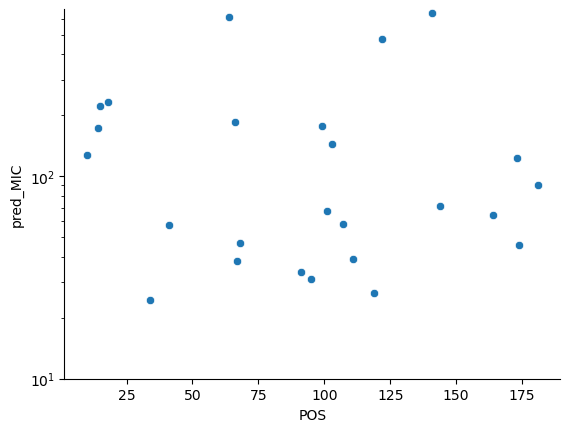

In [182]:
model_path = 'PZA'
peptide_predictions = pd.read_csv(f"/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/{model_path}/inSilico_analysis/test_predictions.csv")

keep_muts = who_variants_V2.query("gene=='pncA'")['variant'].values
print(len(keep_muts))
peptide_predictions['ROLLINGDB_ID'] = [val.replace('_c_', '_c.').replace('_p_', '_p.') for val in peptide_predictions['ROLLINGDB_ID'].values]
peptide_predictions = peptide_predictions.query("ROLLINGDB_ID.isin(@keep_muts) | ROLLINGDB_ID.str.contains('\+') | ROLLINGDB_ID == 'MT_H37Rv'")

nonsense_muts = peptide_predictions.query("ROLLINGDB_ID.str.contains('\+')")
nonsense_muts['POS'] = [int(val.replace('pncA_p.', '').replace('+', '')[3:]) for val in nonsense_muts.ROLLINGDB_ID.values]

sns.scatterplot(data=nonsense_muts,
                x='POS',
                y='pred_MIC',
               )

plt.ylim(10)
sns.despine()
plt.yscale('log')
plt.show()

In [185]:
nonsense_muts.sort_values('pred_MIC', ascending=False)

,ROLLINGDB_ID,log2_pred_MIC,pred_MIC,POS
174,pncA_p.Gln141+,9.315778,637.277470,141
426,pncA_p.Tyr64+,9.254646,610.838130,64
173,pncA_p.Gln122+,8.885586,472.963750,122
355,pncA_p.Ser18+,7.864154,232.994780,18
182,pncA_p.Glu15+,7.792048,221.636000,15
363,pncA_p.Ser66+,7.528878,184.679280,66
430,pncA_p.Tyr99+,7.460006,176.070110,99
157,pncA_p.Cys14+,7.435897,173.152250,14
416,pncA_p.Tyr103+,7.166145,143.623230,103
167,pncA_p.Gln10+,6.988614,126.993780,10


In [101]:
X_insilico = sparse.load_npz("/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/PZA/inSilico_analysis/pkl_sparse_full.npz")

In [102]:
X_insilico.shape

(483, 5, 2602, 7)

In [109]:
nonsense_muts.pred_MIC.min()

84.753944

In [5]:
gene_peptide_lengths = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/PZA/gene_peptide_lengths.csv", index_col=[0])

In [11]:
gene_peptide_lengths.loc[['MT_H37Rv'], :].values[:, :7].shape

(1, 7)

In [9]:
gene_peptide_lengths.loc[['MT_H37Rv'], :7]

IndexError: .iloc requires numeric indexers, got ['MT_H37Rv']

In [100]:
np.repeat(gene_peptide_lengths.loc[['MT_H37Rv'], :].values, 62, axis=0).shape

(62, 11)

In [85]:
np.sort(nonsense_muts.POS.unique())

array([ 10,  14,  15,  18,  34,  41,  64,  66,  67,  68,  91,  95,  99,
       101, 103, 107, 111, 119, 122, 141, 144, 164, 173, 174, 181])

In [23]:
peptide_AA_predictions.pred_MIC.min(), peptide_AA_predictions.pred_MIC.max()

(14.587807, 68.63683)

In [81]:
results_combined = []

for dir_name in glob.glob("/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/PZA*"):

    results = pd.read_csv(os.path.join(dir_name, "results.csv"))
    results['Model'] = os.path.basename(dir_name)
    results_combined.append(results)

results_combined = pd.concat(results_combined)

In [84]:
results_combined = []

for dir_name in glob.glob("/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/PZA*/inSilico_analysis"):

    if os.path.isfile(os.path.join(dir_name, "lineage_predictions.csv")):
        print(dir_name)
        
        # results = pd.read_csv(os.path.join(dir_name, "results.csv"))
        # results['Model'] = os.path.basename(dir_name)
        # results_combined.append(results)

# results_combined = pd.concat(results_combined)

In [79]:
glob.glob("/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/PZA*")

['/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/PZA',
 '/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/PZA_amino_acid',
 '/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/PZA_lineage',
 '/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/PZA_lineage_amino_acid',
 '/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/PZA_peptide',
 '/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/PZA_peptide_amino_acid',
 '/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/PZA_peptide_lineage',
 '/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/PZA_peptide_lineage_amino_acid']

In [39]:
results_combined

,Drug,Model,Num_Loci,Binned_MAE,Binned_MSE,MAE,MSE,Within_doubling,Spearman,Pearson,Sensitivity,Specificity,Precision,Accuracy,Balanced_Acc,CV
0,PZA,PZA,4,0.456999,0.935930,1.254278,3.654247,0.841121,0.792185,0.701994,0.698113,0.962963,0.948718,0.831776,0.830538,0
0,PZA,PZA_amino_acid,4,0.535870,1.095558,1.165396,2.081795,0.803738,0.745342,0.758307,0.698113,0.962963,0.948718,0.831776,0.830538,0
0,PZA,PZA_lineage,4,0.533297,1.178227,1.404001,4.032492,0.850467,0.753484,0.699445,0.735849,0.962963,0.951220,0.850467,0.849406,0
0,PZA,PZA_lineage_amino_acid,4,0.488325,0.949005,1.055200,1.870415,0.850467,0.744238,0.777817,0.754717,0.962963,0.952381,0.859813,0.858840,0
0,PZA,PZA_peptide,4,0.453379,0.970454,1.108532,2.017661,0.850467,0.747301,0.784109,0.811321,0.962963,0.955556,0.887850,0.887142,0
0,PZA,PZA_peptide_amino_acid,4,0.467459,0.981259,1.103105,1.981620,0.850467,0.751630,0.775516,0.792453,0.944444,0.933333,0.869159,0.868449,0
0,PZA,PZA_peptide_lineage,4,0.504466,1.015192,1.375371,4.990973,0.831776,0.760377,0.666432,0.735849,0.962963,0.951220,0.850467,0.849406,0


In [ ]:
python3 analysis/addl_data_predictions.py -c config_files/config_pza.yaml --insilico-muts
python3 analysis/addl_data_predictions.py -c config_files/config_pza.yaml --lineage --insilico-muts
python3 analysis/addl_data_predictions.py -c config_files/config_pza.yaml --peptide-lengths --insilico-muts
python3 analysis/addl_data_predictions.py -c config_files/config_pza.yaml --amino-acid --insilico-muts
python3 analysis/addl_data_predictions.py -c config_files/config_pza.yaml --lineage --amino-acid --insilico-muts
python3 analysis/addl_data_predictions.py -c config_files/config_pza.yaml --peptide-lengths --lineage --insilico-muts
python3 analysis/addl_data_predictions.py -c config_files/config_pza.yaml --peptide-lengths --amino-acid --insilico-muts
python3 analysis/addl_data_predictions.py -c config_files/config_pza.yaml --lineage --peptide-lengths --amino-acid --insilico-muts

In [ ]:
    python3 -u model/cnn_custom_loss.py -c "${config_array[$i]}" --train
    python3 -u model/cnn_custom_loss.py -c "${config_array[$i]}" --train --amino-acid
    python3 -u model/cnn_custom_loss.py -c "${config_array[$i]}" --train --lineage
    python3 -u model/cnn_custom_loss.py -c "${config_array[$i]}" --train --peptide-lengths
    python3 -u model/cnn_custom_loss.py -c "${config_array[$i]}" --train --amino-acid --lineage
    python3 -u model/cnn_custom_loss.py -c "${config_array[$i]}" --train --amino-acid --peptide-lengths
    python3 -u model/cnn_custom_loss.py -c "${config_array[$i]}" --train --lineage --peptide-lengths
    python3 -u model/cnn_custom_loss.py -c "${config_array[$i]}" --train --lineage --peptide-lengths --amino-acid

In [77]:
model_path = "PZA"
insilico_pred = pd.read_csv(f"/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/{model_path}/inSilico_analysis/test_predictions.csv")

In [78]:
insilico_pred

,ROLLINGDB_ID,category,log2_pred_MIC,pred_MIC
0,pncA_c_-10T>C,NaN,5.330980,40.251770
1,pncA_c_-10delT,NaN,8.640266,399.005950
2,pncA_c_-11A>C,NaN,8.531814,370.110840
3,pncA_c_-11A>G,NaN,9.044790,528.145000
4,pncA_c_-11A>T,NaN,7.940033,245.577300
...,...,...,...,...
478,pncA_p_Val93Leu,NaN,5.600344,48.514490
479,pncA_p_Val93Met,NaN,5.930294,60.981260
480,pncA_p_Val9Ala,NaN,7.238110,150.969120
481,pncA_p_Val9Gly,NaN,5.423166,42.907734


In [56]:
seqDict = pd.read_pickle("/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/PZA/inSilico_analysis/seqDict.pkl")

seqDict_old = pd.read_pickle("/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/PZA/seqDict.pkl")

In [57]:
seqDict.keys()

dict_keys(['pncA', 'panD', 'rpsA', 'clpC1', 'sigE', 'Rv3236c', 'Rv1258c'])

In [72]:
pncA = [(seq.id, str(seq.seq)) for seq in SeqIO.parse("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/PZA/inSilico_analysis/fastas/pncA.fasta", "fasta")]

In [74]:
len(pncA[-1][1])

1557

In [71]:
len(''.join(seqDict_old['pncA'].loc['MT_H37Rv'].values)), len(''.join(seqDict['pncA'].loc['MT_H37Rv'].values))

(1453, 1557)

'GCAAACTGC-CCG-GGCAGTCGCCCGAAC-GT-ATGGTGGACG-TATGCGGGCGTTGATCATCGTCGACGTGCAGAACGAC---------------------------T----TCTGCGAGGGTGGCTCGCTGGCGGTAACCGGTGG-CGCCG----CGCT-GGCCCGCGCCATCAGCGACTACCTGGCCGAAGCGGCGGACTACCATCACGTCGTGGCAACCAA-GGACTTC-CACATCGACCCGGGTGACCACTTCTCCGGCACACC-GGACTAT-TCC---------TCGTCG---------------TGGCCACCGCATTGCGTCAG-CGGTACTCCCGG-CGCGGACTTCCATCCCAGTCTGG--ACACGTCGGCAATCGAGGCG------------GTGTTCTACA-AG---------------------------------GGTGCCTACACCGGAGCGTACAGCGGCTTCGAAGGAGTCGACGAGAACGGCACGCCACTGCTGAATT-GGCTGCGGCAACGCGGCGTCGATGAGGTCGATGTGG--TCGGTATTGCCACCGA-TCATTGTGTG--CGCCAGACGGCCGAGGACGCGGTACGCAATGGC------------------TTGGCC-ACCAGGG--TG---CTGGTGGACCTGACAGCGGGTGTGTCGGCCG----ATACCACCGTCGCCGCGCTGGAGGAGATGCGCACCGCCAGCGTCG-----AGTTGGTTTGCAGCTCCTGATGGCACCGCCGAACCGGGATGAACTGTTGGCGGCGGTGGAGCGCTCGCCGCAAGCGGCCGCCGCGCACGACCGCGCCGGCTGGGTCGGGTTGTTCACCGGTGACGCGCGGGTCGAAGACCCGGTGGGTTCGCAGCCGCAGGTGGGGCATGAGGCCATCGGCCGCTTCTACGACACCTTCATCGGGCCGCGGGATATCACGTTCCATCGCGATCTGGATATCGTCTCCGGCACGGTGGTG

In [48]:
peptide_lengths = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/PZA/inSilico_analysis/gene_peptide_lengths.csv", index_col=[0])

In [49]:
for col in peptide_lengths.columns:
    print(peptide_lengths[col].value_counts())

Rv2042c_length
265    483
Name: count, dtype: int64
pncA_length
186    428
183      7
185      6
184      5
182      5
174      1
163      1
17       1
159      1
65       1
66       1
67       1
118      1
177      1
102      1
33       1
40       1
63       1
94       1
79       1
180      1
100      1
90       1
173      1
172      1
14       1
143      1
110      1
106      1
140      1
121      1
9        1
13       1
165      1
181      1
41       1
98       1
Name: count, dtype: int64
panD_length
139    483
Name: count, dtype: int64
panC_length
309    483
Name: count, dtype: int64
Rv3603c_length
303    483
Name: count, dtype: int64
rpsA_length
481    483
Name: count, dtype: int64
clpC1_length
848    483
Name: count, dtype: int64
sigE_length
257    483
Name: count, dtype: int64
Rv3236c_length
385    483
Name: count, dtype: int64
Rv3237c_length
160    483
Name: count, dtype: int64
Rv1258c_length
419    483
Name: count, dtype: int64


In [53]:
PZA_new = [(seq.id, str(seq.seq)) for seq in SeqIO.parse("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/PZA/TRUST/fastas/Rv3236c.fasta", "fasta")]
PZA_old = [(seq.id, str(seq.seq)) for seq in SeqIO.parse("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/PZA/fastas/Rv3236c.fasta", "fasta")]

In [55]:
len(PZA_old[-1][1])

1705

In [57]:
for id, seq in PZA_new:

    if len(seq.replace('-', '')) > 1705:
        print(id)

MFS-371
MFS-370


In [64]:
vcf_full_paths = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/TRUST/vcf_full_paths.txt", sep='\t', header=None)
len(vcf_full_paths)

395

In [65]:
vcf_filtered = []

for name in vcf_full_paths[0].values:
    if 'MFS-370' not in name and 'MFS-371' not in name:
        vcf_filtered.append(name)

len(vcf_filtered)

393

In [66]:
pd.Series(vcf_filtered).to_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/TRUST/vcf_full_paths_filtered.txt", sep='\t', header=None, index=False)

In [58]:
df_TRUST = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/TRUST/20240124_MIC_pass_genoQC.csv")
df_TRUST.query("ROLLINGDB_ID in ['MFS-370', 'MFS-371']")

,ROLLINGDB_ID,original_ID,shipment,status,comment,SampleLib,Coll2014_Annotated,quality,Cov_Any_Mean,Cov_Unam_Perc,...,sample_week,pid,Coll2014,Lineage,s_inhmic_sputum_specimen_1,s_rifmic_sputum_specimen_1,s_embmic_sputum_specimen_1,s_pzamic_sputum_specimen_1,VCF,F2
294,MFS-371,S0144-06,3rd,finished,-,MFS-371_lib59192,2.2.1.1 Beijing Pacific RD150,1.0,327.48,0.99,...,6,T0144,2.2.1.1,2,3.0,5.0,2.0,2.0,/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/TRUS...,0.010968
295,MFS-370,S0144-01,3rd,in progress,-,MFS-370_lib59191,2.2.1.1 Beijing Pacific RD150,1.0,229.35,0.99,...,1,T0144,2.2.1.1,2,3.0,5.0,2.0,2.0,/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/TRUS...,0.011355


In [2]:
seq_data_path = "/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/PZA"
X = sparse.load_npz(os.path.join(seq_data_path, 'pkl_sparse_ref.npz'))

In [7]:
num_proteins = 7

# all 1s (because effective length is relative to H37Rv) of the same shape as the data
H37Rv_peptide_lengths = np.ones((lineages.shape[0], num_proteins))

mlp_input = np.concatenate([lineages.values,
                                   H37Rv_peptide_lengths
                                ], axis=1).astype(float)

mlp_input.shape

(62, 69)

In [8]:
mlp_input

array([[0., 0., 0., ..., 1., 1., 1.],
       [0., 0., 0., ..., 1., 1., 1.],
       [0., 0., 0., ..., 1., 1., 1.],
       ...,
       [0., 0., 0., ..., 1., 1., 1.],
       [0., 0., 0., ..., 1., 1., 1.],
       [0., 0., 0., ..., 1., 1., 1.]])

In [4]:
lineages = coll_2014.copy()
lineages["Count"] = 1
lineages = lineages.pivot(index="lineage", columns="position", values="Count").fillna(0).astype(int)

In [5]:
lineages

position,62657,107794,346693,355181,403364,497491,514245,541048,615614,615938,...,4151558,4229087,4246508,4248115,4249732,4260268,4307886,4316114,4398141,4404247
lineage,,,,,,,,,,,,,,,,,,,,,
1,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1.1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1.1.1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1.1.1.1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1.1.2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [6]:
seq_data_path = "/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/PZA/TRUST"

drug = 'PZA'

df_samples = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/TRUST/20240124_MIC_pass_genoQC.csv")

# increased the size of the alignment for Rv3236c
if drug == 'PZA':
    df_samples = df_samples.query("ROLLINGDB_ID not in ['MFS-370', 'MFS-371']")
    
df_genos = pd.read_csv(os.path.join(seq_data_path, "df_protein_seqs.csv"))

genes_lst = [val.replace('_AA', '') for val in df_genos.columns if '_AA' in val]

# Apply one-hot encoding function to get each isolate sequence
print(f'Making biophysical property matrices for {len(genes_lst)} genes...')
for gene in genes_lst:
    print("...", gene)
    lengths = [len(seq) for seq in df_genos[f"{gene}_AA"]]
    assert len(np.unique(lengths)) == 1
    df_genos[f"{gene}_biophys"] = df_genos[f"{gene}_AA"].apply(np.vectorize(convert_AA_seq_to_property_matrix))

if "category" in df_genos and "category" in df_phenos:
    del df_genos["category"]

# combined dataframe of all genotypes and phenotypes
df_geno_pheno = df_samples.merge(df_genos, how='inner', on="ROLLINGDB_ID")

NameError: name 'os' is not defined

In [4]:
df_geno_pheno['Rv2042c_biophys'].values[0].shape

(265, 3)

In [75]:
df_geno_pheno['Rv2042c_biophys'].values[0].shape

(3, 265)

In [91]:
df_nt_genos['pncA_one_hot'].values[0].shape

(1453, 5)

In [78]:
# def _get_shapes(df_geno_pheno):
#     """
#     Finds the length of each gene in the input dataframe
#     Parameters
#     ----------
#     df_geno_pheno: pd.Dataframe

#     Returns
#     -------
#     dict of str: int
#         length of coordinates in each column
#     """
#     shapes = {}
#     for column in df_geno_pheno.columns:
#         if "one_hot" in column or "_biophys" in column:
#             shapes[column] = df_geno_pheno.loc[df_geno_pheno.index[0], column].shape[1]

#     return shapes

# shapes = _get_shapes(df_geno_pheno)

# # Length of longest gene locus
# n_genes = len(shapes)
# L_longest = max(list(shapes.values()))

# # Number of strains in model
# n_strains = df_geno_pheno.shape[0]

# amino_acid = True

# # define shape of matrix - fill with zeros (effectively accomplishes padding)
# if amino_acid:
#     X = np.zeros((n_strains, 3, L_longest, n_genes))
# else:
#     X = np.zeros((n_strains, 5, L_longest, n_genes))

# X.shape

(393, 3, 3, 11)

In [87]:
df_nt_genos = pd.read_csv(os.path.join(seq_data_path, "df_genos.csv"))
locus_list = ['pncA']

# Apply one-hot encoding function to get each isolate sequence
print('Making one hot encoding for...')
for locus in df_nt_genos.columns[1:]:
    print("...", locus)
    lengths = [len(seq) for seq in df_nt_genos[locus]]
    assert len(np.unique(lengths)) == 1
    df_nt_genos[locus + "_one_hot"] = df_nt_genos[locus].apply(np.vectorize(get_one_hot))

# combined dataframe of all genotypes and phenotypes
# df_nt_geno_pheno = df_phenos.merge(df_nt_genos, how='inner', on="ROLLINGDB_ID")

Making one hot encoding for...
... sigE
... pncA
... Rv3236c
... panD
... clpC1
... rpsA
... Rv1258c


NameError: name 'df_phenos' is not defined

In [80]:
shapes

{'Rv1258c_biophys': 3,
 'Rv2042c_biophys': 3,
 'Rv3236c_biophys': 3,
 'Rv3237c_biophys': 3,
 'Rv3603c_biophys': 3,
 'clpC1_biophys': 3,
 'panC_biophys': 3,
 'panD_biophys': 3,
 'pncA_biophys': 3,
 'rpsA_biophys': 3,
 'sigE_biophys': 3}

In [79]:
len(df_geno_pheno)

393

In [82]:
df_geno_pheno.loc[df_geno_pheno.index[0], 'Rv3236c_biophys']

array([[  0.26,  -0.62,   0.54, ...,   0.25,  -0.26,  -0.64],
       [149.21, 147.13, 117.15, ...,  89.1 , 105.09, 132.12],
       [  5.71,   3.08,   6.02, ...,   6.11,   5.7 ,   5.43]])

In [83]:
df_geno_pheno.loc[df_geno_pheno.index[0], 'Rv3236c_biophys'].shape

(3, 385)

In [81]:
df_geno_pheno.head()

,ROLLINGDB_ID,original_ID,shipment,status,comment,SampleLib,Coll2014_Annotated,quality,Cov_Any_Mean,Cov_Unam_Perc,...,Rv2042c_biophys,Rv3236c_biophys,Rv3237c_biophys,Rv3603c_biophys,clpC1_biophys,panC_biophys,panD_biophys,pncA_biophys,rpsA_biophys,sigE_biophys
0,MFS-141,231-05,1st,finished,-,MFS-141_lib47320,4.3.2.1 LAM,1.0,268.19,1.00,...,"[[0.26, 0.25, -0.07, -0.07, -0.64, -1.8, -0.72...","[[0.26, -0.62, 0.54, -0.26, -1.8, 0.25, 0.53, ...","[[0.26, -0.72, 0.54, -1.1, -0.62, 0.54, 0.53, ...","[[0.26, -0.62, -1.8, 0.61, -0.72, 0.16, 0.53, ...","[[0.26, 0.61, -0.62, -1.8, 0.61, -0.18, -0.72,...","[[0.26, -0.18, 0.73, -0.07, 0.25, 0.61, -0.4, ...","[[0.26, 0.53, -1.8, -0.18, 0.26, 0.53, -1.1, -...","[[0.26, -1.8, 0.25, 0.53, 0.73, 0.73, 0.54, -0...","[[0.26, -0.07, -0.26, -0.07, -0.18, 0.54, -0.1...","[[0.26, -0.62, 0.53, 0.53, 0.16, 0.16, -0.07, ..."
1,MFS-140,231-01,1st,finished,-,MFS-140_lib47319,4.3.2.1 LAM,1.0,311.68,1.00,...,"[[0.26, 0.25, -0.07, -0.07, -0.64, -1.8, -0.72...","[[0.26, -0.62, 0.54, -0.26, -1.8, 0.25, 0.53, ...","[[0.26, -0.72, 0.54, -1.1, -0.62, 0.54, 0.53, ...","[[0.26, -0.62, -1.8, 0.61, -0.72, 0.16, 0.53, ...","[[0.26, 0.61, -0.62, -1.8, 0.61, -0.18, -0.72,...","[[0.26, -0.18, 0.73, -0.07, 0.25, 0.61, -0.4, ...","[[0.26, 0.53, -1.8, -0.18, 0.26, 0.53, -1.1, -...","[[0.26, -1.8, 0.25, 0.53, 0.73, 0.73, 0.54, -0...","[[0.26, -0.07, -0.26, -0.07, -0.18, 0.54, -0.1...","[[0.26, -0.62, 0.53, 0.53, 0.16, 0.16, -0.07, ..."
2,MFS-157,245-08,1st,finished,-,MFS-157_lib47336,2.2.1.1 Beijing Pacific RD150,1.0,286.39,0.99,...,"[[0.26, 0.25, -0.07, -0.07, -0.64, -1.8, -0.72...","[[0.26, -0.62, 0.54, -0.26, -1.8, 0.25, 0.53, ...","[[0.26, -0.72, 0.54, -1.1, -0.62, 0.54, 0.53, ...","[[0.26, -0.62, -1.8, 0.61, -0.72, 0.16, 0.53, ...","[[0.26, 0.61, -0.62, -1.8, 0.61, -0.18, -0.72,...","[[0.26, -0.18, 0.73, -0.07, 0.25, 0.61, -0.4, ...","[[0.26, 0.53, -1.8, -0.18, 0.26, 0.53, -1.1, -...","[[0.26, -1.8, 0.25, 0.53, 0.73, 0.73, 0.54, -0...","[[0.26, -0.07, -0.26, -0.07, -0.18, 0.54, -0.1...","[[0.26, -0.62, 0.53, 0.53, 0.16, 0.16, -0.07, ..."
3,MFS-156,245-01,1st,finished,-,MFS-156_lib47335,2.2.1.1 Beijing Pacific RD150,1.0,380.20,0.99,...,"[[0.26, 0.25, -0.07, -0.07, -0.64, -1.8, -0.72...","[[0.26, -0.62, 0.54, -0.26, -1.8, 0.25, 0.53, ...","[[0.26, -0.72, 0.54, -1.1, -0.62, 0.54, 0.53, ...","[[0.26, -0.62, -1.8, 0.61, -0.72, 0.16, 0.53, ...","[[0.26, 0.61, -0.62, -1.8, 0.61, -0.18, -0.72,...","[[0.26, -0.18, 0.73, -0.07, 0.25, 0.61, -0.4, ...","[[0.26, 0.53, -1.8, -0.18, 0.26, 0.53, -1.1, -...","[[0.26, -1.8, 0.25, 0.53, 0.73, 0.73, 0.54, -0...","[[0.26, -0.07, -0.26, -0.07, -0.18, 0.54, -0.1...","[[0.26, -0.62, 0.53, 0.53, 0.16, 0.16, -0.07, ..."
4,MFS-86,168-01,1st,finished,-,MFS-86_lib47265,2.2.1 Beijing,1.0,326.77,0.99,...,"[[0.26, 0.25, -0.07, -0.07, -0.64, -1.8, -0.72...","[[0.26, -0.62, 0.54, -0.26, -1.8, 0.25, 0.53, ...","[[0.26, -0.72, 0.54, -1.1, -0.62, 0.54, 0.53, ...","[[0.26, -0.62, -1.8, 0.61, -0.72, 0.16, 0.53, ...","[[0.26, 0.61, -0.62, -1.8, 0.61, -0.18, -0.72,...","[[0.26, -0.18, 0.73, -0.07, 0.25, 0.61, -0.4, ...","[[0.26, 0.53, -1.8, -0.18, 0.26, 0.53, -1.1, -...","[[0.26, -1.8, 0.25, 0.53, 0.73, 0.73, 0.54, -0...","[[0.26, -0.07, -0.26, -0.07, -0.18, 0.54, -0.1...","[[0.26, -0.62, 0.53, 0.53, 0.16, 0.16, -0.07, ..."


In [27]:
seq_data_path = "/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/PZA"
df_protein_seqs = pd.read_csv(os.path.join(seq_data_path, "df_protein_seqs.csv"))

In [30]:
gene = 'Rv1258c'
df_protein_seqs[f"{gene}_biophys"] = df_protein_seqs[f"{gene}_AA"].apply(np.vectorize(convert_AA_seq_to_property_matrix))

In [33]:
df_protein_seqs['Rv1258c_biophys'].shape

(1064,)

In [ ]:
python3 data_processing/03_make_scripts_protein_alns.py -c config_files/config_rif.yaml
python3 data_processing/03_make_scripts_protein_alns.py -c config_files/config_inh.yaml
python3 data_processing/03_make_scripts_protein_alns.py -c config_files/config_emb.yaml
python3 data_processing/03_make_scripts_protein_alns.py -c config_files/config_eth.yaml

In [37]:
df_protein_seqs['Rv1258c_biophys'][0]#.shape

array([[  0.26,  -1.8 ,  -0.64, ...,  -0.26,   0.25,  -0.69],
       [149.21, 174.2 , 132.12, ..., 105.09,  89.1 , 146.15],
       [  5.71,  10.76,   5.43, ...,   5.7 ,   6.11,   5.65]])

In [38]:
df_protein_seqs['Rv1258c_biophys'][0].shape

(3, 419)

In [ ]:
df_protein_seqs['Rv1258c_biophys'][0]

In [3]:
X_aa.shape

(107, 3, 848, 11)

In [95]:
np.repeat(X_aa, 62, axis=0).shape

(62, 3, 848, 11)

In [ ]:
X_aa

In [4]:
X_aa.mean(), X_aa.std()

(17.502236732071207, 43.67104092469111)

In [90]:
X_aa = np.load("/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/PZA/inSilico_analysis/pkl_AA_full.npy")
X_aa = X_aa[[-1], :]

In [91]:
X_aa.shape

(1, 3, 848, 11)

In [44]:
df_PZA = pd.read_csv(os.path.join(data_dir, "PZA", "data_for_model.csv"))

X_aa = np.concatenate([np.load("/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/PZA/pkl_AA_train_val.npy"), np.load("/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/PZA/pkl_AA_test.npy")])

# flatten to perform PCA
X_aa_flattened = np.reshape(X_aa, (X_aa.shape[0], X_aa.shape[1]*X_aa.shape[2]*X_aa.shape[3]))
X_aa_flattened.shape

(1063, 27984)

In [45]:
scaler = StandardScaler()
pca = PCA(n_components=100)
X_aa_flattened_pca = pca.fit_transform(scaler.fit_transform(X_aa_flattened))

print(pca.explained_variance_ratio_.sum(), X_aa_flattened_pca.shape)

0.9982097465409875 (1063, 100)


In [46]:
X_aa_flattened_pca = pd.DataFrame(X_aa_flattened_pca)
X_aa_flattened_pca['ROLLINGDB_ID'] = np.concatenate([df_PZA.query("category != 'test_set'")['ROLLINGDB_ID'].values, df_PZA.query("category == 'test_set'")['ROLLINGDB_ID'].values])
X_aa_flattened_pca = X_aa_flattened_pca.set_index('ROLLINGDB_ID')
X_aa_flattened_pca.columns = [f"PC{num}" for num in X_aa_flattened_pca.columns]

X_aa_flattened_pca = X_aa_flattened_pca.merge(df_PZA[['ROLLINGDB_ID', 'Coll2014', 'Lineage', 'PZA_lower_bound', 'PZA_midpoint', 'PZA_upper_bound']].set_index('ROLLINGDB_ID'), left_index=True, right_index=True)

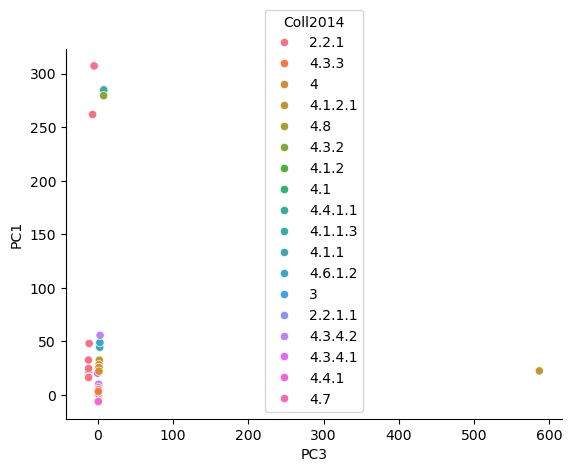

In [51]:
sns.scatterplot(data=X_aa_flattened_pca,
                x='PC3',
                y='PC1',
                hue='Coll2014'
               )

sns.despine()
plt.show()

In [45]:
# standard-scale across the sample axis (0) and the length of the amino acid sequence (2). Don't scale different biophysical properties together (1), or different genes together (3)
X_rescaled = np.zeros(X_aa.shape)

# separately scale biophysical properties
for property_idx in np.arange(X_aa.shape[1]):

    # separately scale genes
    for gene_idx in np.arange(X_aa.shape[-1]):

        X_rescaled[:, property_idx, :, gene_idx] = scaler.fit_transform(X_aa[:, property_idx, :, gene_idx])

# separately scale biophysical properties
for property_idx in np.arange(X_rescaled.shape[1]):

    # separately scale genes
    for gene_idx in np.arange(X_rescaled.shape[-1]):
        print(X_aa[:, property_idx, :, gene_idx].shape, X_aa[:, property_idx, :, gene_idx].mean(), X_aa[:, property_idx, :, gene_idx].std())

# check shapes match
assert X_aa.shape == X_rescaled.shape

(107, 3, 848, 11)
(107, 3, 848, 11)


In [49]:
X_aa.shape, X_rescaled.shape 

((107, 3, 848, 11), (107, 3, 848, 11))

In [52]:
X_aa.shape == (107, 3, 848, 11)

True

In [53]:
amino_acid_biophysical_properties

,Eisenberg_Weiss,MW_g_mol,pI_25C
AA,,,
I,0.7300,131.180,6.0400
F,0.6100,165.190,5.7600
V,0.5400,117.150,6.0200
L,0.5300,131.180,6.0400
W,0.3700,204.230,5.8800
M,0.2600,149.210,5.7100
A,0.2500,89.100,6.1100
G,0.1600,75.070,6.0600
C,0.0400,121.160,5.1500


In [41]:
# separately scale biophysical properties
for property_idx in np.arange(X_rescaled.shape[1]):

    # separately scale genes
    for gene_idx in np.arange(X_rescaled.shape[-1]):
        print(X_aa[:, property_idx, :, gene_idx].shape, X_aa[:, property_idx, :, gene_idx].mean(), X_aa[:, property_idx, :, gene_idx].std())

(107, 848) 0.03500077146887675 0.4097203425811069
(107, 848) -0.04138247222712044 0.4057673890653032
(107, 848) 0.04330894022218304 0.4026708454500737
(107, 848) -0.028702830188679248 0.3335072576952206
(107, 848) -0.01986466231705166 0.39149686769227143
(107, 848) -0.18337297213895254 0.7125288140844555
(107, 848) -0.02708021072121319 0.4083316381106083
(107, 848) -0.010271226415094339 0.262292230483636
(107, 848) -0.015355360606594958 0.2717686859935449
(107, 848) -0.09640925321812732 0.5193550313973161
(107, 848) -0.06107245194850996 0.3858612489079464
(107, 848) 57.6268624360783 64.01783759707922
(107, 848) 39.91382384059248 61.81344114579813
(107, 848) 54.23930490654206 62.724639500308896
(107, 848) 23.700860849056603 50.831358947434225
(107, 848) 43.097404778698646 60.188912008452284
(107, 848) 128.31724001498856 28.690321805148603
(107, 848) 45.07925773673074 62.114792087162606
(107, 848) 20.485247641509435 47.644384533048736
(107, 848) 26.4152629827191 52.38407169346547
(107, 8

In [40]:
# separately scale biophysical properties
for property_idx in np.arange(X_rescaled.shape[1]):

    # separately scale genes
    for gene_idx in np.arange(X_rescaled.shape[-1]):
        print(X_rescaled[:, property_idx, :, gene_idx].shape, X_rescaled[:, property_idx, :, gene_idx].mean(), X_rescaled[:, property_idx, :, gene_idx].std())

(107, 848) -2.866885200601445e-16 0.5139561687500467
(107, 848) 2.1192472187870072e-17 0.06868028197434446
(107, 848) 1.0326911938684855e-16 0.08411582311380662
(107, 848) 2.168404344971009e-17 4.1337866936620915e-16
(107, 848) 3.249019913196977e-17 0.03434014098717234
(107, 848) -2.123355371896224e-16 0.06868028197434448
(107, 848) 2.02932974995199e-17 0.03434014098717226
(107, 848) -5.44965016509695e-18 3.235748615737048e-16
(107, 848) 4.9099618158347603e-17 0.4411070977643787
(107, 848) -1.3036641164499164e-16 0.07678688960424387
(107, 848) 1.0312749057898799e-17 0.034340140987172287
(107, 848) -2.6770646672428566e-14 0.5128076619096164
(107, 848) -1.4593659946905163e-14 0.06868028197434445
(107, 848) -2.2176614372336472e-14 0.08411582311380661
(107, 848) -6.954604607085886e-15 9.704742389213436e-14
(107, 848) -1.892572973081829e-14 0.0343401409871723
(107, 848) -3.0976441985436985e-14 0.0686802819743445
(107, 848) -1.4942180606718444e-14 0.03434014098717225
(107, 848) -6.6529591060

In [35]:
X_rescaled[0][0][10]

array([-6.66133815e-16,  0.00000000e+00, -6.66133815e-16,  7.77156117e-16,
        2.22044605e-15,  2.22044605e-15, -6.66133815e-16, -8.32667268e-16,
        4.44089210e-16,  7.77156117e-16,  4.44089210e-16])

In [15]:
# # Assuming X_aa is your original matrix
# # Reshape X_aa so that the dimensions to be scaled are consecutive
# X_reshaped = X_aa.reshape(X_aa.shape[0], X_aa.shape[1], -1)

# # Standard scale across the first and third dimensions
# X_scaled_reshaped = np.apply_along_axis(lambda x: st.zscore(x, axis=(0, 2), nan_policy='omit'), 0, X_reshaped)

# # Reshape back to the original shape
# X_scaled = X_scaled_reshaped.reshape(X_aa.shape[0], X_aa.shape[1], -1)

In [12]:
X_reshaped.shape

(9328, 107, 3)

In [ ]:
X_scaled.shape, X_scaled.mean(), X_scaled.std()

In [6]:
X_scaled[0][0][0]

array([nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan])

In [24]:
X_scaled

array([[[[        nan,         nan,         nan, ...,         nan,
                  nan,         nan],
         [-1.73291487,  0.91459396, -0.20898296, ..., -1.73291487,
           0.50132429, -0.20898296],
         [-0.46774173,  0.19278544,  0.89966539, ...,  0.56360771,
          -0.02739028,  0.8880772 ],
         ...,
         [-0.31622777, -0.31622777, -0.31622777, ..., -0.31622777,
          -0.31622777, -0.31622777],
         [-0.31622777, -0.31622777, -0.31622777, ..., -0.31622777,
          -0.31622777, -0.31622777],
         [ 0.31622777,  0.31622777,  0.31622777, ...,  0.31622777,
           0.31622777,  0.31622777]],

        [[        nan,         nan,         nan, ...,         nan,
                  nan,         nan],
         [ 1.3563763 , -2.04237056,  0.2752473 , ...,  1.3563763 ,
          -1.00277737,  0.2752473 ],
         [ 0.07069835, -0.60034355, -0.52056105, ..., -1.62843187,
          -0.99688626,  0.03357184],
         ...,
         [-0.31622777, -0.31622777

In [116]:
variant_counts_old = pd.read_csv("../filtered_values.txt", sep=': ', header=None)
variant_counts_old.columns = ['Isolate', 'OLD']

variant_counts = pd.read_csv("../filtered_values_2.txt", sep=': ', header=None)
variant_counts.columns = ['Isolate', 'NEW']
len(variant_counts_old), len(variant_counts)

(14135, 14135)

In [117]:
combined = variant_counts.merge(variant_counts_old, on='Isolate')

In [124]:
combined.query("NEW > OLD")

,Isolate,NEW,OLD


In [118]:
combined.NEW.min(), combined.NEW.max(), combined.NEW.mean(), combined.NEW.median()

(48, 2646, 1152.9688715953307, 993.0)

In [120]:
combined.OLD.min(), combined.OLD.max(), combined.OLD.mean(), combined.OLD.median()

(48, 2646, 1152.9791298195967, 993.0)

In [121]:
np.max(np.abs(combined['NEW'] - combined['OLD']))

2

In [123]:
len(combined.query("NEW != OLD")) / len(combined)

0.009975238769013088

In [97]:
amino_acid_biophysical_properties.iloc[:20, 1:].mean(axis=0)

Eisenberg_Weiss     -0.1485
MW_g_mol           136.9030
pI_25C               6.0505
dtype: float64

In [ ]:
bcftools filter -i "FILTER=='PASS' & BQ > 20 & MQ > 30 & IC == 0 & DC == 0 & INFO/DP >= 20 & max(QP) >= 75" "SAMEA3393050.vcf" | grep -v '^#' | wc -l

In [ ]:
# Iterate through all .vcf files in the current directory
for file in *.vcf; do
    # Check if file exists and is readable
    if [ -r "$file" ]; then
        # Run bcftools filter command, remove lines starting with '#' and count remaining lines
        filtered_lines=$(bcftools filter -i "FILTER=='PASS' & BQ > 20 & MQ > 30 & IC == 0 & DC == 0 & INFO/DP >= 20 & max(QP) >= 75" "$file" | grep -v '^#' | wc -l)

        echo "$file: $filtered_lines"
        # Write filename and number of filtered lines to output file
        # echo "$file: $filtered_lines" >> "$output_file"
    else
        echo "Error: Unable to read file $file"
    fi
done

In [26]:
os.listdir('/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/PZA/fastas')

['Rv1258c.fasta',
 'Rv1258c_insertion_sites.csv',
 'Rv3236c.fasta',
 'Rv3236c_insertion_sites.csv',
 'clpC1.fasta',
 'clpC1_insertion_sites.csv',
 'panD.fasta',
 'panD_insertion_sites.csv',
 'pncA.fasta',
 'pncA_insertion_sites.csv',
 'rpsA.fasta',
 'rpsA_insertion_sites.csv',
 'sigE.fasta',
 'sigE_insertion_sites.csv']

In [128]:
def make_AA_property_matrices(seq_data_path, **kwargs):
    
    drug = kwargs["drug"]
    phenotype_file = kwargs['phenotype_file']
    data_dir = os.path.dirname(phenotype_file)

    df_phenos = pd.read_csv(phenotype_file)
    print(f"Found phenotypes for {len(df_phenos)} strains")
    df_phenos.loc[-1, ['ROLLINGDB_ID', 'category']] = np.array(["MT_H37Rv", "reference"], dtype=object)
    
    # get table for phenotypes and add the reference strain to match the format of the FASTA files
    if not os.path.isfile(os.path.join(seq_data_path, "df_protein_seqs.csv")):
            
        # make table of all genotypes. Index is the identifier
        df_genos = make_genotype_df(kwargs['genotype_input_directory'], amino_acid=True)
        
        df_genos.index = [name.split(".")[0] for name in df_genos.index]
        df_genos.index.rename('ROLLINGDB_ID', inplace=True)
    
        # this makes life easier later. Keep H37Rv in this      
        df_genos = df_phenos[["category", "ROLLINGDB_ID"]].merge(df_genos, on="ROLLINGDB_ID", how="inner")
        df_genos.to_csv(os.path.join(seq_data_path, "df_protein_seqs.csv"), index=False)

    df_genos = pd.read_csv(os.path.join(seq_data_path, "df_protein_seqs.csv"))
    genes_lst = [val.replace('_AA', '') for val in df_genos.columns if '_AA' in val]
    
    # Apply one-hot encoding function to get each isolate sequence
    print(f'Making biophysical property matrices for {len(genes_lst)} genes...')
    for gene in genes_lst:
        print("...", gene)
        lengths = [len(seq) for seq in df_genos[f"{gene}_AA"]]
        assert len(np.unique(lengths)) == 1
        df_genos[f"{gene}_biophys"] = df_genos[f"{gene}_AA"].apply(np.vectorize(convert_AA_seq_to_property_matrix))
    
    if "category" in df_genos and "category" in df_phenos:
        del df_genos["category"]

    # combined dataframe of all genotypes and phenotypes
    df_geno_pheno = df_phenos.merge(df_genos, how='inner', on="ROLLINGDB_ID")

    X = create_X(df_geno_pheno, amino_acid=True)
    
    # last row is H37Rv
    X_H37Rv = X[[-1], :]
    print(f"Reference shape: {X_H37Rv.shape}")
    np.save(os.path.join(seq_data_path, "pkl_AA_ref.npy"), X_H37Rv)
    
    # Separate train + val from test to keep test aside only for final predictions
    # H37Rv is the last row, so remove it before saving to avoid redundancy 
    X = X[:-1, :]
    
    # Reset index first
    df_geno_pheno = df_geno_pheno.reset_index(drop=True)
    train_val_idx = df_geno_pheno.query("category in ['train_set', 'validation_set']").index
    test_idx = df_geno_pheno.query("category == 'test_set'").index
    
    np.save(os.path.join(seq_data_path, "pkl_AA_train_val.npy"), X[train_val_idx, :])
    np.save(os.path.join(seq_data_path, "pkl_AA_test.npy"), X[test_idx, :])

In [129]:
kwargs = yaml.safe_load(open("config_files/config_pza.yaml", "r"))

seq_data_path = "/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/PZA"

df_AA = make_AA_property_matrices(seq_data_path, **kwargs)

Found phenotypes for 1063 strains
Making biophysical property matrices for 11 genes...
... Rv1258c
... Rv2042c
... Rv3236c
... Rv3237c
... Rv3603c
... clpC1
... panC
... panD
... pncA
... rpsA
... sigE


(1064, 3, 848, 11)

In [167]:
seq_data_path

'/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/PZA'

In [168]:
X = create_X(df_AA, amino_acid=True)
print(X.shape)

# last row is H37Rv
X_H37Rv = X[[-1], :]
print(f"Reference shape: {X_H37Rv.shape}")
np.save(os.path.join(seq_data_path, "pkl_AA_ref.npy"), X_H37Rv)

# Separate train + val from test to keep test aside only for final predictions
# H37Rv is the last row, so remove it before saving to avoid redundancy 
X = X[:-1, :]
print(X.shape)

# Reset index first
df_AA = df_AA.reset_index(drop=True)
train_val_idx = df_AA.query("category in ['train_set', 'validation_set']").index
test_idx = df_AA.query("category == 'test_set'").index

np.save(os.path.join(seq_data_path, "pkl_AA_train_val.npy"), X[train_val_idx, :])
np.save(os.path.join(seq_data_path, "pkl_AA_test.npy"), X[test_idx, :])

(1064, 3, 848, 11)
Reference shape: (1, 3, 848, 11)
(1063, 3, 848, 11)


In [166]:
X[train_val_idx, :].shape, X[test_idx, :].shape

((956, 3, 848, 11), (107, 3, 848, 11))

In [169]:
df_AA

,ROLLINGDB_ID,DB_OF_ORIGIN,MEDIA,MEDIA_NORM,PZA_lower_bound,PZA_midpoint,PZA_upper_bound,VCF,F2,Coll2014,...,Rv2042c_biophys,Rv3236c_biophys,Rv3237c_biophys,Rv3603c_biophys,clpC1_biophys,panC_biophys,panD_biophys,pncA_biophys,rpsA_biophys,sigE_biophys
0,SAMEA3392672,farhat_internal,MGIT,MGIT,0.0,50.0,100.0,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,0.021705,4.1.1,...,"[[0.26, 149.21, 5.71], [0.25, 89.1, 6.11], [-0...","[[0.26, 149.21, 5.71], [-0.62, 147.13, 3.08], ...","[[0.26, 149.21, 5.71], [-0.72, 133.11, 2.98], ...","[[0.26, 149.21, 5.71], [-0.62, 147.13, 3.08], ...","[[0.26, 149.21, 5.71], [0.61, 165.19, 5.76], [...","[[0.26, 149.21, 5.71], [-0.18, 119.12, 5.6], [...","[[0.26, 149.21, 5.71], [0.53, 131.18, 6.04], [...","[[0.26, 149.21, 5.71], [-1.8, 174.2, 10.76], [...","[[0.26, 149.21, 5.71], [-0.07, 115.13, 6.3], [...","[[0.26, 149.21, 5.71], [-0.62, 147.13, 3.08], ..."
1,SAMEA3392675,farhat_internal,MGIT,MGIT,100.0,100.0,inf,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,0.005253,4.1.2.1,...,"[[0.26, 149.21, 5.71], [0.25, 89.1, 6.11], [-0...","[[0.26, 149.21, 5.71], [-0.62, 147.13, 3.08], ...","[[0.26, 149.21, 5.71], [-0.72, 133.11, 2.98], ...","[[0.26, 149.21, 5.71], [-0.62, 147.13, 3.08], ...","[[0.26, 149.21, 5.71], [0.61, 165.19, 5.76], [...","[[0.26, 149.21, 5.71], [-0.18, 119.12, 5.6], [...","[[0.26, 149.21, 5.71], [0.53, 131.18, 6.04], [...","[[0.26, 149.21, 5.71], [-1.8, 174.2, 10.76], [...","[[0.26, 149.21, 5.71], [-0.07, 115.13, 6.3], [...","[[0.26, 149.21, 5.71], [-0.62, 147.13, 3.08], ..."
2,SAMEA3401665,farhat_internal,MGIT,MGIT,20.0,35.0,50.0,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,0.011462,2.2.1,...,"[[0.26, 149.21, 5.71], [0.25, 89.1, 6.11], [-0...","[[0.26, 149.21, 5.71], [-0.62, 147.13, 3.08], ...","[[0.26, 149.21, 5.71], [-0.72, 133.11, 2.98], ...","[[0.26, 149.21, 5.71], [-0.62, 147.13, 3.08], ...","[[0.26, 149.21, 5.71], [0.61, 165.19, 5.76], [...","[[0.26, 149.21, 5.71], [-0.18, 119.12, 5.6], [...","[[0.26, 149.21, 5.71], [0.53, 131.18, 6.04], [...","[[0.26, 149.21, 5.71], [-1.8, 174.2, 10.76], [...","[[0.26, 149.21, 5.71], [-0.07, 115.13, 6.3], [...","[[0.26, 149.21, 5.71], [-0.62, 147.13, 3.08], ..."
3,SAMEA3401971,farhat_internal,MGIT,MGIT,0.0,5.0,10.0,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,0.011980,2.2.1,...,"[[0.26, 149.21, 5.71], [0.25, 89.1, 6.11], [-0...","[[0.26, 149.21, 5.71], [-0.62, 147.13, 3.08], ...","[[0.26, 149.21, 5.71], [-0.72, 133.11, 2.98], ...","[[0.26, 149.21, 5.71], [-0.62, 147.13, 3.08], ...","[[0.26, 149.21, 5.71], [0.61, 165.19, 5.76], [...","[[0.26, 149.21, 5.71], [-0.18, 119.12, 5.6], [...","[[0.26, 149.21, 5.71], [0.53, 131.18, 6.04], [...","[[0.26, 149.21, 5.71], [-1.8, 174.2, 10.76], [...","[[0.26, 149.21, 5.71], [-0.07, 115.13, 6.3], [...","[[0.26, 149.21, 5.71], [-0.62, 147.13, 3.08], ..."
4,SAMEA3404125,farhat_internal,MGIT,MGIT,100.0,100.0,inf,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,0.007829,4.1.2.1,...,"[[0.26, 149.21, 5.71], [0.25, 89.1, 6.11], [-0...","[[0.26, 149.21, 5.71], [-0.62, 147.13, 3.08], ...","[[0.26, 149.21, 5.71], [-0.72, 133.11, 2.98], ...","[[0.26, 149.21, 5.71], [-0.62, 147.13, 3.08], ...","[[0.26, 149.21, 5.71], [0.61, 165.19, 5.76], [...","[[0.26, 149.21, 5.71], [-0.18, 119.12, 5.6], [...","[[0.26, 149.21, 5.71], [0.53, 131.18, 6.04], [...","[[0.26, 149.21, 5.71], [-1.8, 174.2, 10.76], [...","[[0.26, 149.21, 5.71], [-0.07, 115.13, 6.3], [...","[[0.26, 149.21, 5.71], [-0.62, 147.13, 3.08], ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1059,SAMN06094221,farhat_internal,MGIT,MGIT,0.0,50.0,100.0,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,0.007873,4.7,...,"[[0.26, 149.21, 5.71], [0.25, 89.1, 6.11], [-0...","[[0.26, 149.21, 5.71], [-0.62, 147.13, 3.08], ...","[[0.26, 149.21, 5.71], [-0.72, 133.11, 2.98], ...","[[0.26, 149.21, 5.71], [-0.62, 147.13, 3.08], ...","[[0.26, 149.21, 5.71], [0.61, 165.19, 5.76], [...","[[0.26, 149.21, 5.71], [-0.18, 119.12, 5.6],

In [162]:
df_AA

,ROLLINGDB_ID,DB_OF_ORIGIN,MEDIA,MEDIA_NORM,PZA_lower_bound,PZA_midpoint,PZA_upper_bound,VCF,F2,Coll2014,...,Rv2042c_biophys,Rv3236c_biophys,Rv3237c_biophys,Rv3603c_biophys,clpC1_biophys,panC_biophys,panD_biophys,pncA_biophys,rpsA_biophys,sigE_biophys
0,SAMEA3392672,farhat_internal,MGIT,MGIT,0.0,50.0,100.0,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,0.021705,4.1.1,...,"[[0.26, 149.21, 5.71], [0.25, 89.1, 6.11], [-0...","[[0.26, 149.21, 5.71], [-0.62, 147.13, 3.08], ...","[[0.26, 149.21, 5.71], [-0.72, 133.11, 2.98], ...","[[0.26, 149.21, 5.71], [-0.62, 147.13, 3.08], ...","[[0.26, 149.21, 5.71], [0.61, 165.19, 5.76], [...","[[0.26, 149.21, 5.71], [-0.18, 119.12, 5.6], [...","[[0.26, 149.21, 5.71], [0.53, 131.18, 6.04], [...","[[0.26, 149.21, 5.71], [-1.8, 174.2, 10.76], [...","[[0.26, 149.21, 5.71], [-0.07, 115.13, 6.3], [...","[[0.26, 149.21, 5.71], [-0.62, 147.13, 3.08], ..."
1,SAMEA3392675,farhat_internal,MGIT,MGIT,100.0,100.0,inf,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,0.005253,4.1.2.1,...,"[[0.26, 149.21, 5.71], [0.25, 89.1, 6.11], [-0...","[[0.26, 149.21, 5.71], [-0.62, 147.13, 3.08], ...","[[0.26, 149.21, 5.71], [-0.72, 133.11, 2.98], ...","[[0.26, 149.21, 5.71], [-0.62, 147.13, 3.08], ...","[[0.26, 149.21, 5.71], [0.61, 165.19, 5.76], [...","[[0.26, 149.21, 5.71], [-0.18, 119.12, 5.6], [...","[[0.26, 149.21, 5.71], [0.53, 131.18, 6.04], [...","[[0.26, 149.21, 5.71], [-1.8, 174.2, 10.76], [...","[[0.26, 149.21, 5.71], [-0.07, 115.13, 6.3], [...","[[0.26, 149.21, 5.71], [-0.62, 147.13, 3.08], ..."
2,SAMEA3401665,farhat_internal,MGIT,MGIT,20.0,35.0,50.0,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,0.011462,2.2.1,...,"[[0.26, 149.21, 5.71], [0.25, 89.1, 6.11], [-0...","[[0.26, 149.21, 5.71], [-0.62, 147.13, 3.08], ...","[[0.26, 149.21, 5.71], [-0.72, 133.11, 2.98], ...","[[0.26, 149.21, 5.71], [-0.62, 147.13, 3.08], ...","[[0.26, 149.21, 5.71], [0.61, 165.19, 5.76], [...","[[0.26, 149.21, 5.71], [-0.18, 119.12, 5.6], [...","[[0.26, 149.21, 5.71], [0.53, 131.18, 6.04], [...","[[0.26, 149.21, 5.71], [-1.8, 174.2, 10.76], [...","[[0.26, 149.21, 5.71], [-0.07, 115.13, 6.3], [...","[[0.26, 149.21, 5.71], [-0.62, 147.13, 3.08], ..."
3,SAMEA3401971,farhat_internal,MGIT,MGIT,0.0,5.0,10.0,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,0.011980,2.2.1,...,"[[0.26, 149.21, 5.71], [0.25, 89.1, 6.11], [-0...","[[0.26, 149.21, 5.71], [-0.62, 147.13, 3.08], ...","[[0.26, 149.21, 5.71], [-0.72, 133.11, 2.98], ...","[[0.26, 149.21, 5.71], [-0.62, 147.13, 3.08], ...","[[0.26, 149.21, 5.71], [0.61, 165.19, 5.76], [...","[[0.26, 149.21, 5.71], [-0.18, 119.12, 5.6], [...","[[0.26, 149.21, 5.71], [0.53, 131.18, 6.04], [...","[[0.26, 149.21, 5.71], [-1.8, 174.2, 10.76], [...","[[0.26, 149.21, 5.71], [-0.07, 115.13, 6.3], [...","[[0.26, 149.21, 5.71], [-0.62, 147.13, 3.08], ..."
4,SAMEA3404125,farhat_internal,MGIT,MGIT,100.0,100.0,inf,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,0.007829,4.1.2.1,...,"[[0.26, 149.21, 5.71], [0.25, 89.1, 6.11], [-0...","[[0.26, 149.21, 5.71], [-0.62, 147.13, 3.08], ...","[[0.26, 149.21, 5.71], [-0.72, 133.11, 2.98], ...","[[0.26, 149.21, 5.71], [-0.62, 147.13, 3.08], ...","[[0.26, 149.21, 5.71], [0.61, 165.19, 5.76], [...","[[0.26, 149.21, 5.71], [-0.18, 119.12, 5.6], [...","[[0.26, 149.21, 5.71], [0.53, 131.18, 6.04], [...","[[0.26, 149.21, 5.71], [-1.8, 174.2, 10.76], [...","[[0.26, 149.21, 5.71], [-0.07, 115.13, 6.3], [...","[[0.26, 149.21, 5.71], [-0.62, 147.13, 3.08], ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1059,SAMN06094221,farhat_internal,MGIT,MGIT,0.0,50.0,100.0,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,0.007873,4.7,...,"[[0.26, 149.21, 5.71], [0.25, 89.1, 6.11], [-0...","[[0.26, 149.21, 5.71], [-0.62, 147.13, 3.08], ...","[[0.26, 149.21, 5.71], [-0.72, 133.11, 2.98], ...","[[0.26, 149.21, 5.71], [-0.62, 147.13, 3.08], ...","[[0.26, 149.21, 5.71], [0.61, 165.19, 5.76], [...","[[0.26, 149.21, 5.71], [-0.18, 119.12, 5.6],

In [133]:
def create_X(df_geno_pheno, amino_acid=False):
    """
	Create an input X matrix, with output dimensions:
		n_strains x 5 (one-hot) x longest locus length x no. of loci
	"""

    def _get_shapes(df_geno_pheno):
        """
		Finds the length of each gene in the input dataframe
		Parameters
		----------
		df_geno_pheno: pd.Dataframe

		Returns
		-------
		dict of str: int
			length of coordinates in each column
		"""
        shapes = {}
        for column in df_geno_pheno.columns:
            if "one_hot" in column or "_biophys" in column:
                shapes[column] = df_geno_pheno.loc[df_geno_pheno.index[0], column].shape[0]

        return shapes

    shapes = _get_shapes(df_geno_pheno)

    # Length of longest gene locus
    n_genes = len(shapes)
    L_longest = max(list(shapes.values()))

    # Number of strains in model
    n_strains = df_geno_pheno.shape[0]

    # define shape of matrix - fill with zeros (effectively accomplishes padding)
    if amino_acid:
        X = np.zeros((n_strains, 3, L_longest, n_genes))
    else:
        X = np.zeros((n_strains, 5, L_longest, n_genes))

    # for each strain and gene locus
    for idx, strain in enumerate(df_geno_pheno.index):
        for gene_index, gene in enumerate(shapes.keys()):
            one_hot_gene = df_geno_pheno.loc[strain, gene]

            # one_hot_gene.shape[0] is the length of the locus
            X[idx, :, range(0, one_hot_gene.shape[0]), gene_index] = one_hot_gene

    return X

In [92]:
def convert_AA_seq_to_property_matrix(aa_seq):
    '''
    Convert a single amino acid sequence to a matrix of biophysical properties. 
    
    The properties are Eisenberg-Weiss consensus hydrophobicity scale, molecular weight (molar mass), and isoelectronic point at 25 degrees C.
    '''
    
    # Convert sequences to matrix
    biophys_matrix = []

    for aa in aa_seq:
        if aa not in amino_acid_biophysical_properties.index.values:
            raise ValuError(f"{aa} is not in the biophysical property table")
            
        biophys_matrix.append(amino_acid_biophysical_properties.loc[aa, :].values.flatten())

    
    biophys_matrix = np.array(biophys_matrix)
    
    assert biophys_matrix.shape[0] == len(aa_seq)
    assert biophys_matrix.shape[1] == amino_acid_biophysical_properties.shape[1]

    # Convolutions will be k x 12, where k is the number of properties. 12 is consistent with the nucleotide CNN
    return biophys_matrix

In [33]:
test_seq = df_protein_seqs['Rv1258c_AA'].values[0]
print(len(test_seq))

test_matrix = convert_AA_seq_to_property_matrix(test_seq)

419


In [34]:
test_matrix

array([[  0.26,  -1.8 ,  -0.64, ...,  -0.26,   0.25,  -0.69],
       [149.21, 174.2 , 132.12, ..., 105.09,  89.1 , 146.15],
       [  5.71,  10.76,   5.43, ...,   5.7 ,   6.11,   5.65]])

In [35]:
amino_acid_biophysical_properties

,Eisenberg_Weiss,MW_g_mol,pI_25C
AA,,,
I,0.7300,131.180,6.0400
F,0.6100,165.190,5.7600
V,0.5400,117.150,6.0200
L,0.5300,131.180,6.0400
W,0.3700,204.230,5.8800
M,0.2600,149.210,5.7100
A,0.2500,89.100,6.1100
G,0.1600,75.070,6.0600
C,0.0400,121.160,5.1500


In [127]:
amino_acid_biophysical_properties = pd.read_csv("./data_processing/protein_seqs/biophysical_properties_AA.csv", index_col=[0])

# Convert sequences to matrix
biophys_matrix = []

for seq in sequences:
    single_protein_biophys_matrix = []
    for aa in seq:
        single_protein_biophys_matrix.append(amino_acid_biophysical_properties.loc[aa, :].values.flatten())
    
    biophys_matrix.append(single_protein_biophys_matrix)

NameError: name 'sequences' is not defined

In [88]:
gene = 'pncA'
seq_lst = [(seq.id, str(seq.seq)) for seq in SeqIO.parse(f"{fasta_dir}/{gene}_AA.fasta", "fasta")]
lengths = [len(seq[1]) for seq in seq_lst]
np.unique(lengths)

array([191])

In [90]:
amino_acid_biophysical_properties

,AA,Eisenberg_Weiss,MW_g_mol,pI_25C
0,I,0.7300,131.180,6.0400
1,F,0.6100,165.190,5.7600
2,V,0.5400,117.150,6.0200
3,L,0.5300,131.180,6.0400
4,W,0.3700,204.230,5.8800
5,M,0.2600,149.210,5.7100
6,A,0.2500,89.100,6.1100
7,G,0.1600,75.070,6.0600
8,C,0.0400,121.160,5.1500
9,Y,0.0200,181.190,5.6300


In [86]:
amino_acid_biophysical_properties

,AA,Eisenberg_Weiss,MW_g_mol,pI_25C
0,I,0.7300,131.180,6.0400
1,F,0.6100,165.190,5.7600
2,V,0.5400,117.150,6.0200
3,L,0.5300,131.180,6.0400
4,W,0.3700,204.230,5.8800
5,M,0.2600,149.210,5.7100
6,A,0.2500,89.100,6.1100
7,G,0.1600,75.070,6.0600
8,C,0.0400,121.160,5.1500
9,Y,0.0200,181.190,5.6300


In [75]:
3612968, 3614043

(3612968, 3614043)

In [ ]:
bcftools filter -i "POS > 3611958 & POS <= 3613663" /n/data1/hms/dbmi/farhat/Sanjana/MIC_data/VCF_clean/SAMN05919656.vcf	

In [73]:
h37Rv_genes.query("Symbol in ['Rv3237c', 'Rv3236c']")

,Gene_Ind,Feature,Start,End,Strand,Frame,H37rv_GeneID,Symbol,Function,Product,...,SWISS-MODEL,Orthologues M. leprae,Orthologues M. marinum,Orthologues M. smegmatis,Orthologues M. bovis,Orthologues M. lepromatosis,Orthologues M. tuberculosis,Orthologues M. abscessus,Orthologues M. haemophilum,Orthologues M. orygis
3332,3332,CDS,3611959,3613116,-,0.0,Rv3236c,Rv3236c,Probably involved in transport of undetermined...,Probable conserved integral membrane transport...,...,L7N665,ML0782,MMAR_1309,MSMEG_3664,Mb3264c,NaN,NaN,NaN,NaN,NaN
3333,3333,CDS,3613121,3613603,-,0.0,Rv3237c,Rv3237c,Function unknown,Conserved protein,...,O05882,ML0781,MMAR_1308,MSMEG_3665,Mb3265c,NaN,NaN,NaN,NaN,NaN


In [76]:
3613121-3613603

-482

In [51]:
pd.Series(lengths).value_counts()

419    970
231     93
120      1
Name: count, dtype: int64

In [23]:
lineage_pred = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/PZA_lineage/TRUST/test_predictions.csv")
peptide_lineage_pred = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/PZA_peptide_lineage/TRUST/test_predictions.csv")

In [24]:
lineage_pred.pred_MIC.min(), lineage_pred.pred_MIC.max()

(14.313995, 58.950417)

In [25]:
peptide_lineage_pred.pred_MIC.min(), peptide_lineage_pred.pred_MIC.max()

(10.895185, 37.337433)

In [28]:
df_PZA = pd.read_csv(os.path.join(data_dir, "PZA", "data_for_model.csv"))

In [12]:
lineage_pred.query("pred_MIC > 100").Coll2014.unique()

array([], dtype=object)

<Axes: xlabel='pred_MIC', ylabel='Count'>

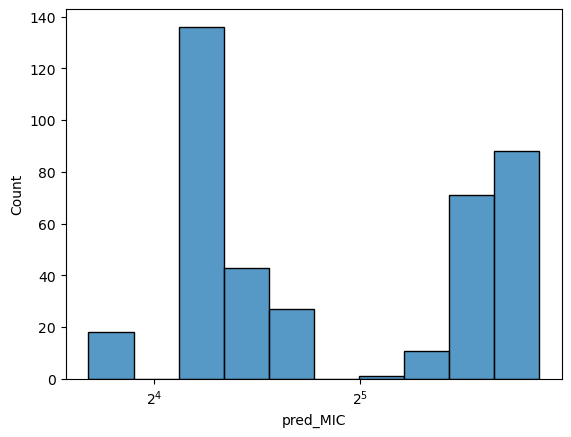

In [19]:
sns.histplot(data=lineage_pred,
             x='pred_MIC',
             log_scale=2
            )

<Axes: xlabel='pred_MIC', ylabel='Count'>

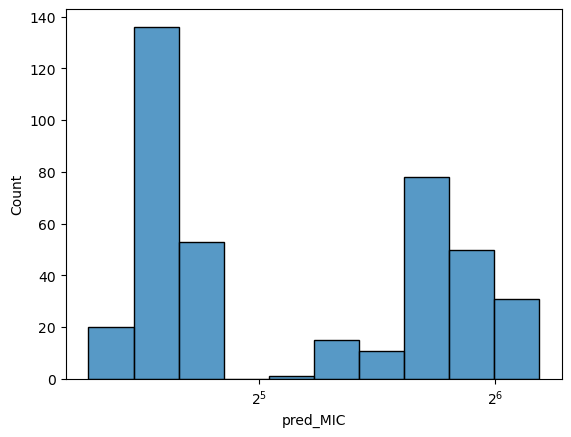

In [18]:
sns.histplot(data=peptide_lineage_pred,
             x='pred_MIC',
             log_scale=2
            )

In [8]:
old_aln = [(seq.id, str(seq.seq)) for seq in SeqIO.parse("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/PZA/fastas/Rv3236c.fasta", "fasta")]

new_aln = [(seq.id, str(seq.seq)) for seq in SeqIO.parse("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/PZA/TRUST/fastas/Rv3236c.fasta", "fasta")]

In [13]:
len(old_aln[-1][-1])

1705

In [14]:
for seq in new_aln:

    if '-' not in seq[1]:
        print(seq[0])

MFS-371
MFS-370


In [16]:
df_samples = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/TRUST/20240124_MIC_pass_genoQC.csv")

In [18]:
df_samples.query("ROLLINGDB_ID in ['MFS-371', 'MFS-370']")

,ROLLINGDB_ID,original_ID,shipment,status,comment,SampleLib,Coll2014_Annotated,quality,Cov_Any_Mean,Cov_Unam_Perc,...,sample_week,pid,Coll2014,Lineage,s_inhmic_sputum_specimen_1,s_rifmic_sputum_specimen_1,s_embmic_sputum_specimen_1,s_pzamic_sputum_specimen_1,VCF,F2
294,MFS-371,S0144-06,3rd,finished,-,MFS-371_lib59192,2.2.1.1 Beijing Pacific RD150,1.0,327.48,0.99,...,6,T0144,2.2.1.1,2,3.0,5.0,2.0,2.0,/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/TRUS...,0.010968
295,MFS-370,S0144-01,3rd,in progress,-,MFS-370_lib59191,2.2.1.1 Beijing Pacific RD150,1.0,229.35,0.99,...,1,T0144,2.2.1.1,2,3.0,5.0,2.0,2.0,/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/TRUS...,0.011355


In [19]:
df_samples.query("Coll2014=='2.2.1.1'")

,ROLLINGDB_ID,original_ID,shipment,status,comment,SampleLib,Coll2014_Annotated,quality,Cov_Any_Mean,Cov_Unam_Perc,...,sample_week,pid,Coll2014,Lineage,s_inhmic_sputum_specimen_1,s_rifmic_sputum_specimen_1,s_embmic_sputum_specimen_1,s_pzamic_sputum_specimen_1,VCF,F2
2,MFS-157,245-08,1st,finished,-,MFS-157_lib47336,2.2.1.1 Beijing Pacific RD150,1.0,286.39,0.99,...,8,T0245,2.2.1.1,2,2.0,3.0,2.0,1.0,/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/TRUS...,0.011048
3,MFS-156,245-01,1st,finished,-,MFS-156_lib47335,2.2.1.1 Beijing Pacific RD150,1.0,380.20,0.99,...,1,T0245,2.2.1.1,2,2.0,3.0,2.0,1.0,/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/TRUS...,0.010579
15,MFS-165,250-06,1st,finished,-,MFS-165_lib47344,2.2.1.1 Beijing Pacific RD150,1.0,296.08,0.99,...,6,T0250,2.2.1.1,2,2.0,3.0,2.0,1.0,/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/TRUS...,0.010723
16,MFS-164,250-01,1st,finished,-,MFS-164_lib47343,2.2.1.1 Beijing Pacific RD150,1.0,383.64,0.99,...,1,T0250,2.2.1.1,2,2.0,3.0,2.0,1.0,/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/TRUS...,0.010143
17,MFS-89,170-08,1st,finished,-,MFS-89_lib48373,2.2.1.1 Beijing Pacific RD150,1.0,260.61,0.99,...,8,T0170,2.2.1.1,2,2.0,5.0,2.0,NaN,/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/TRUS...,0.012637
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
381,MFS-471,S0378-01,3rd,in progress,-,MFS-471_lib59739,2.2.1.1 Beijing Pacific RD150,1.0,243.79,0.99,...,1,T0378,2.2.1.1,2,2.0,3.0,2.0,1.0,/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/TRUS...,0.009852
382,MFS-472,S0378-08,3rd,in progress,-,MFS-472_lib59740,2.2.1.1 Beijing Pacific RD150,1.0,214.08,0.99,...,8,T0378,2.2.1.1,2,2.0,3.0,2.0,1.0,/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/TRUS...,0.010644
386,MFS-479,S0385-01,3rd,in progress,-,MFS-479_lib59747,2.2.1.1 Beijing Pacific RD150,1.0,234.95,0.99,...,1,T0385,2.2.1.1,2,3.0,3.0,2.0,1.0,/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/TRUS...,0.010590
391,MFS-369,S0136-01,3rd,in progress,-,MFS-369_lib59190,2.2.1.1 Beijing Pacific RD150,1.0,222.89,0.99,...,1,T0136,2.2.1.1,2,4.0,2.0,2.0,3.0,/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/TRUS...,0.011589


In [ ]:
bcftools filter -i "POS > 3611958 & POS <= 3613663" /n/data1/hms/dbmi/farhat/Sanjana/MIC_data/TRUST/VCF_clean/MFS-371.vcf

In [15]:
drug_loci

,Drug,Locus,Start,End,Sense
0,BDQ,atpE,1460996,1461290,+
1,BDQ,pepQ,2859299,2860451,-
2,BDQ,Rv0678,778905,779487,+
3,BDQ,mmpLS5,775585,778989,-
4,DLM,fgd1,490705,491793,+
5,DLM,Rv2983,3338999,3339762,+
6,DLM,ndh,2101650,2103183,-
7,DLM,fbiC,1302855,1305501,+
8,DLM,ddn,3986732,3987299,+
9,DLM,fbiAB,3640141,3642881,+


In [6]:
TRUST_seq = sparse.load_npz("/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/PZA/TRUST/pkl_sparse_full.npz")

In [7]:
TRUST_seq.shape

(395, 5, 2602, 4)

In [5]:
lineage_pred

,ROLLINGDB_ID,original_ID,shipment,status,comment,SampleLib,Coll2014_Annotated,quality,Cov_Any_Mean,Cov_Unam_Perc,...,Coll2014,Lineage,s_inhmic_sputum_specimen_1,s_rifmic_sputum_specimen_1,s_embmic_sputum_specimen_1,s_pzamic_sputum_specimen_1,VCF,F2,log2_pred_MIC,pred_MIC
0,MFS-141,231-05,1st,finished,-,MFS-141_lib47320,4.3.2.1 LAM,1.0,268.19,1.00,...,4.3.2.1,4,2.0,2.0,2.0,NaN,/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/TRUS...,0.010058,12.229227,4801.359
1,MFS-140,231-01,1st,finished,-,MFS-140_lib47319,4.3.2.1 LAM,1.0,311.68,1.00,...,4.3.2.1,4,2.0,2.0,2.0,NaN,/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/TRUS...,0.011486,12.229227,4801.359
2,MFS-157,245-08,1st,finished,-,MFS-157_lib47336,2.2.1.1 Beijing Pacific RD150,1.0,286.39,0.99,...,2.2.1.1,2,2.0,3.0,2.0,1.0,/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/TRUS...,0.011048,12.174836,4623.713
3,MFS-156,245-01,1st,finished,-,MFS-156_lib47335,2.2.1.1 Beijing Pacific RD150,1.0,380.20,0.99,...,2.2.1.1,2,2.0,3.0,2.0,1.0,/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/TRUS...,0.010579,12.174836,4623.713
4,MFS-86,168-01,1st,finished,-,MFS-86_lib47265,2.2.1 Beijing,1.0,326.77,0.99,...,2.2.1,2,2.0,4.0,3.0,NaN,/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/TRUS...,0.009724,12.512425,5842.724
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
390,MFS-463,S0370-07,3rd,in progress,-,MFS-463_lib59731,2.2.1 Beijing,1.0,218.39,0.99,...,2.2.1,2,2.0,2.0,1.0,1.0,/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/TRUS...,0.008900,12.512425,5842.724
391,MFS-369,S0136-01,3rd,in progress,-,MFS-369_lib59190,2.2.1.1 Beijing Pacific RD150,1.0,222.89,0.99,...,2.2.1.1,2,4.0,2.0,2.0,3.0,/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/TRUS...,0.011589,12.174836,4623.713
392,MFS-481,S0389-08,3rd,in progress,-,MFS-481_lib59749,4.1.1.1 X-type,1.0,218.54,0.99,...,4.1.1.1,4,2.0,4.0,2.0,2.0,/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/TRUS...,0.009336,13.121267,8910.355
393,MFS-390,S0326-01,3rd,in progress,not joined,MFS-390_lib59205,4.8 mainly T,1.0,176.82,0.99,...,4.8,4,3.0,3.0,2.0,1.0,/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/TRUS...,0.042713,12.128955,4478.981


In [24]:
df = pd.read_csv(os.path.join(data_dir, "INH", "data_for_model.csv"))

In [29]:
coll_2014.loc[coll_2014['#lineage'].str.contains('OV')]

,#lineage,position,allele_change,tag
60,lineageBOV,2831482,A/G,coll2014
61,lineageBOV_AFRI,1882180,C/T,coll2014


In [23]:
# aa_lst = ['A', 'R', 'N', 'D', 'C', 'E', 'Q', 'G', 'H', 'I', 'L', 'K', 'M', 'F', 'P', 'S', 'T', 'W', 'Y', 'V']

# MW_lst = [89.10, 174.20, 132.12, 133.11, 121.16, 147.13, 146.15, 75.07, 155.16, 131.18, 131.18, 146.19, 149.21, 165.19, 115.13, 105.09, 119.12, 204.23, 181.19, 117.15]

# pI_lst = [6.11, 10.76, 5.43, 2.98, 5.15, 3.08, 5.65, 6.06, 7.64, 6.04, 6.04, 9.47, 5.71, 5.76, 6.30, 5.70, 5.60, 5.88, 5.63, 6.02]

# MW_dict = dict(zip(aa_lst, MW_lst))
# pi_dict = dict(zip(aa_lst, pI_lst))

In [37]:
os.listdir("data_processing/protein_seqs")

['.ipynb_checkpoints',
 'biophysical_properties_AA.csv',
 'concatenate_SNPs_indels.py',
 'convert_embeddings_csv.py',
 'esm-extract.py',
 'reduce_embeddings_dimension.py']

In [25]:
# df.rename(columns={'Value': 'Eisenberg_Weiss'}, inplace=True)

In [31]:
# for drug in os.listdir(data_dir):

#     if os.path.isdir(f"{data_dir}/{drug}/fastas"):
#         shutil.rmtree(f"{data_dir}/{drug}/fastas")

In [35]:
drug_loci.loc[(drug_loci['Locus']=='panD')]

,Drug,Locus,Start,End,Sense
25,PZA,panD,4043861,4046302,-


In [39]:
add_df = pd.DataFrame({'Drug': ['PZA'] * 3, 'Locus': ['sigE', 'Rv3236c', 'Rv1258c'],
                       'Start': [1364150, 3611958, 1406080], 'End': [1365186, 3613663, 1407347], 'Sense': ['+', '-', '-']
                      })

In [42]:
pd.concat([drug_loci, add_df]).sort_values('Drug').to_csv("data_processing/data_utils/drug_loci.csv", index=False)

In [30]:
df.query("Coll2014.str.contains('BOV')")

,ROLLINGDB_ID,MEDIA_NORM,INH_lower_bound,INH_midpoint,INH_upper_bound,MEDIA,DB_OF_ORIGIN,VCF,F2,Coll2014,Freschi2020,Lipworth2019,Shitikov2017,Stucki2016,Binary,Lineage,Stratify,category
134,SAMEA7524971,7H10,0.05,0.075,0.10,UKMYC,CRyPTIC,/n/data1/hms/dbmi/farhat/rollingDB/cryptic_out...,0.025668,BOV_AFRI,NaN,"orygis,mungi",NaN,NaN,0,BOV_AFRI,BOV_AFRI-0,test_set
587,SAMEA7562077,7H10,0.00,0.025,0.05,UKMYC,CRyPTIC,/n/data1/hms/dbmi/farhat/rollingDB/cryptic_out...,0.016511,"6,BOV_AFRI",6,"westafrican2,mungi",NaN,NaN,0,"6,BOV_AFRI","6,BOV_AFRI-0",test_set
2533,SAMEA7524961,7H10,0.10,0.150,0.20,UKMYC,CRyPTIC,/n/data1/hms/dbmi/farhat/rollingDB/cryptic_out...,0.023328,BOV_AFRI,NaN,"orygis,mungi",NaN,NaN,0,BOV_AFRI,BOV_AFRI-0,validation_set
3472,SAMEA7526289,7H10,0.00,0.025,0.05,UKMYC,CRyPTIC,/n/data1/hms/dbmi/farhat/rollingDB/cryptic_out...,0.020153,BOV_AFRI,NaN,"orygis,mungi",NaN,NaN,0,BOV_AFRI,BOV_AFRI-0,train_set
3557,SAMEA7526880,7H10,0.00,0.025,0.05,UKMYC,CRyPTIC,/n/data1/hms/dbmi/farhat/rollingDB/cryptic_out...,0.022968,BOV_AFRI,NaN,"orygis,mungi",NaN,NaN,0,BOV_AFRI,BOV_AFRI-0,train_set
4683,SAMEA7544444,7H10,0.00,0.025,0.05,UKMYC,CRyPTIC,/n/data1/hms/dbmi/farhat/rollingDB/cryptic_out...,0.021375,"6,BOV_AFRI",6,"westafrican2,canetti,mungi",NaN,NaN,0,"6,BOV_AFRI","6,BOV_AFRI-0",train_set
5528,SAMEA7546453,7H10,0.05,0.075,0.10,UKMYC,CRyPTIC,/n/data1/hms/dbmi/farhat/rollingDB/cryptic_out...,0.017127,BOV_AFRI,NaN,"bovis,canetti,ghana,westafrican1,mungi",NaN,NaN,0,BOV_AFRI,BOV_AFRI-0,train_set
6629,SAMEA7561476,7H10,0.05,0.075,0.10,UKMYC,CRyPTIC,/n/data1/hms/dbmi/farhat/rollingDB/cryptic_out...,0.016542,BOV_AFRI,NaN,"bcg,ghana,mungi",NaN,NaN,0,BOV_AFRI,BOV_AFRI-0,train_set
6793,SAMEA7561937,7H10,0.00,0.025,0.05,UKMYC,CRyPTIC,/n/data1/hms/dbmi/farhat/rollingDB/cryptic_out...,0.021607,"6,BOV_AFRI",6,"westafrican2,mungi",NaN,NaN,0,"6,BOV_AFRI","6,BOV_AFRI-0",train_set
6821,SAMEA7561982,7H10,0.00,0.025,0.05,UKMYC,CRyPTIC,/n/data1/hms/dbmi/farhat/rollingDB/cryptic_out...,0.016419,BOV_AFRI,NaN,"bcg,ghana,mungi",NaN,NaN,0,BOV_AFRI,BOV_AFRI-0,train_set


In [44]:
kwargs = yaml.safe_load(open("config_files/config_pza.yaml", 'r'))

In [63]:
def get_gene_coords(locus_list, fasta_dir):
    '''
    Use this function to get a dataframe of coordinates from the bash scripts used to generate the alignment FASTA files for every locus.
    
    coords_lst is a list of tuples of the start and end coordinates of the genes
    '''
    coords = []

    # don't filter by drug because some loci (Tier 2 only) are associated with multiple drugs
    gene_coords = model_loci.query("Locus in @locus_list")                    
    gene_coords["Length"] = (gene_coords["End"] - gene_coords["Start"]) # don't need to add 1 because these are 0-indexed half open intervals.
    gene_coords = gene_coords.set_index("Locus")
    del gene_coords['Drug']

    # during this iteration, convert everything to 1-indexing because using np.arange on inverted coordinates is going to get messy
    # so add 1 to the start position, and then both coordinates should be inclusive
    for i, row in gene_coords.iterrows():
        if row["Sense"] == "-":
            new_start = row["End"]
            new_end = row["Start"] + 1
            gene_coords.loc[i, "Start"] = new_start
            gene_coords.loc[i, "End"] = new_end
        elif row["Sense"] == "+":
            gene_coords.loc[i, "Start"] = row["Start"] + 1
            gene_coords.loc[i, "End"] = row["End"]
        else:
            raise ValueError(f"{row['Sense']} is not a valid gene sense!")
            
    assert sum(gene_coords.query("Sense=='-'").End > gene_coords.query("Sense=='-'").Start) == 0
    assert sum(gene_coords.query("Sense=='+'").End < gene_coords.query("Sense=='+'").Start) == 0

    return gene_coords, dict(zip(gene_coords.index.values, gene_coords.Sense.values))

In [66]:
model_loci = pd.read_csv("./data_processing/data_utils/drug_loci.csv")

In [67]:
gene_coords, sense_dict = get_gene_coords(kwargs['tier1_loci'] + kwargs['tier2_loci'], kwargs['genotype_input_directory'])

In [68]:
kwargs['tier1_loci'] + kwargs['tier2_loci']

['pncA', 'panD', 'rpsA', 'clpC1', 'sigE', 'Rv3236c', 'Rv1258c']

In [69]:
gene_coords

,Start,End,Sense,Length
Locus,,,,
Rv3236c,3613663,3611959,-,1705
rpsA,1833493,1834987,+,1495
pncA,2289281,2287884,-,1398
panD,4046302,4043862,-,2441
clpC1,4040759,4038158,-,2602
sigE,1364151,1365186,+,1036
Rv1258c,1407347,1406081,-,1267


In [74]:
os.remove(os.path.join(kwargs['genotype_input_directory'], f"{locus}.fasta"))

In [33]:
df

,AA,Eisenberg_Weiss,MW_g_mol,pI_25C
0,I,0.73,131.18,6.04
1,F,0.61,165.19,5.76
2,V,0.54,117.15,6.02
3,L,0.53,131.18,6.04
4,W,0.37,204.23,5.88
5,M,0.26,149.21,5.71
6,A,0.25,89.10,6.11
7,G,0.16,75.07,6.06
8,C,0.04,121.16,5.15
9,Y,0.02,181.19,5.63


In [31]:
seqDict = pd.read_pickle("/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/PZA/seqDict.pkl")

In [32]:
seqDict['pncA']

,2289281.0,2289280.0,2289279.0,2289278.0,2289277.0,2289276.0,2289275.0,2289274.0,2289273.0,2289272.0,...,2287893.0,2287892.0,2287891.0,2287890.0,2287889.0,2287888.0,2287887.0,2287886.0,2287885.0,2287884.0
Isolate,,,,,,,,,,,,,,,,,,,,,
SAMEA3401929,G,C,A,A,A,C,T,G,C,C,...,C,C,C,A,G,C,C,T,G,A
SAMEA3401970,G,C,A,A,A,C,T,G,C,C,...,C,C,C,A,G,C,C,T,G,A
SAMEA3403354,G,C,A,A,A,C,T,G,C,C,...,C,C,C,A,G,C,C,T,G,A
SAMEA3403355,G,C,A,A,A,C,T,G,C,C,...,-,-,-,-,-,-,-,-,-,-
SAMEA3404173,G,C,A,A,A,C,T,G,C,C,...,C,C,C,A,G,C,C,T,G,A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SAMN06094221,G,C,A,A,A,C,T,G,C,C,...,C,C,C,A,G,C,C,T,G,A
SAMN06094222,G,C,A,A,A,C,T,G,C,C,...,C,C,C,A,G,C,C,T,G,A
SAMN06094224,G,C,A,A,A,C,T,G,C,C,...,C,C,C,A,G,C,C,T,G,A


In [34]:
locus_peptide_lengths = pd.read_csv(os.path.join("/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/PZA", f"gene_peptide_lengths.csv"), index_col=[0])

In [36]:
locus_peptide_lengths.sort_values('pncA_length')

,Rv2042c_length,pncA_length,panD_length,panC_length,Rv3603c_length,rpsA_length,clpC1_length,sigE_length,Rv3236c_length,Rv3237c_length,Rv1258c_length
SAMN06094087,265,0,139,309,303,481,848,257,385,160,419
SAMN05916222,0,0,139,309,303,481,848,257,385,160,419
SAMN05916235,0,0,139,309,303,481,848,257,385,160,231
SAMN05916417,0,0,139,309,303,481,848,257,385,160,419
SAMN05918556,0,0,139,309,303,481,848,257,385,160,231
...,...,...,...,...,...,...,...,...,...,...,...
SAMN06094070,265,187,139,309,303,481,848,257,385,160,419
SAMN05916275,265,188,139,309,303,481,848,257,385,160,419
SAMN05916459,265,188,139,309,303,481,848,257,385,160,419
SAMN05916460,265,188,139,309,303,481,848,257,385,160,419


In [82]:
os.remove("/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/PZA/seqDict.pkl")

In [80]:
seqDict.keys()

dict_keys(['pncA', 'panD', 'rpsA', 'clpC1'])

In [81]:
kwargs["tier1_loci"] + kwargs["tier2_loci"]

['pncA', 'panD', 'rpsA', 'clpC1', 'sigE', 'Rv3236c', 'Rv1258c']

In [72]:
dfs_list = []

for locus in kwargs['tier1_loci'] + kwargs['tier2_loci']:
            
    # read in the sequences for the fasta file
    seqs = [(seq.id, seq.seq) for seq in SeqIO.parse(os.path.join(kwargs['genotype_input_directory'], f"{locus}.fasta"), "fasta")]
            
    # H37Rv is the last one
    H37Rv = list(seqs[-1][1])
    H37Rv_coords = pd.DataFrame(H37Rv).rename(columns={0:locus})

    # replace deletion characters with nan
    coords_count = []
    pos = gene_coords.loc[locus, "Start"]
    sense = gene_coords.loc[locus, "Sense"]
    length = gene_coords.loc[locus, "Length"]

    print(locus, len(H37Rv), length)
    assert len(H37Rv) >= length

    # for _, row in H37Rv_coords.iterrows():

    #     if row[locus] == "-":
    #         coords_count.append(np.nan)
    #     else:
    #         coords_count.append(pos)
    #         # increment because we're going from 5' to 3'
    #         if sense == "+":
    #             pos += 1
    #         # decrement because we're going from 3' to 5'
    #         elif sense == "-":
    #             pos -= 1
    #         else:
    #             raise ValueError(f"{sense} is not a valid gene sense!")
                
    # # check that the last number is the same as the end position
    # assert pd.Series(coords_count).dropna()[:length].values[-1] == gene_coords.loc[locus, "End"]
    
    # # combine the locus name with the coordinates and remove the sequence
    # H37Rv_coords[locus + "_coord"] = coords_count
    # del H37Rv_coords[locus]
    # dfs_list.append(H37Rv_coords)

pncA 1453 1398
panD 1349 2441


AssertionError: 

In [43]:
list(['a'])

['a']

In [22]:
df.query("Lineage in ['BOV_AFRI', '1']")

,ROLLINGDB_ID,DB_OF_ORIGIN,MEDIA,MEDIA_NORM,PZA_lower_bound,PZA_midpoint,PZA_upper_bound,VCF,F2,Coll2014,Freschi2020,Lipworth2019,Shitikov2017,Stucki2016,Binary,Lineage,Stratify,category


In [23]:
df.Lineage.value_counts()

Lineage
4    981
2     95
3      6
Name: count, dtype: int64

In [16]:
for drug in os.listdir(data_dir):
    print(f"python3 02_clean_pheno_data.py {drug}")

python3 02_clean_pheno_data.py BDQ
python3 02_clean_pheno_data.py EMB
python3 02_clean_pheno_data.py ETH
python3 02_clean_pheno_data.py INH
python3 02_clean_pheno_data.py LEV
python3 02_clean_pheno_data.py LZD
python3 02_clean_pheno_data.py MXF
python3 02_clean_pheno_data.py PZA
python3 02_clean_pheno_data.py RIF


In [ ]:
python3 02_clean_pheno_data.py PZA
python3 02_clean_pheno_data.py BDQ
python3 02_clean_pheno_data.py EMB
python3 02_clean_pheno_data.py ETH
python3 02_clean_pheno_data.py INH
python3 02_clean_pheno_data.py LEV
python3 02_clean_pheno_data.py LZD
python3 02_clean_pheno_data.py MXF
python3 02_clean_pheno_data.py RIF

In [26]:
CETR_isolate_metadata#.loc[CETR_isolate_metadata['Alt ID']=='01-r1038']

,BioProject,Run No,BioSample,WGSAccessionNumber/Run Accession,ID,var2tab_ID,GTBDR_ID,Alt ID,PATIENT_ID1,PATIENT_ID2,...,AMOXCLAV,LIN,Drug Pheno_avail,Phylogenetic lineage,Insilico spoligo octal,Spacer count,spoldb4 match,Spoldb4 identity,spoligotype family,Coll et al Barcode based lineage
0,PRJEB26000,NaN,ERS2401270,ERR2516592,00-R0223,4004.0,NaN,00-R0223,NaN,NaN,...,NaN,NaN,9.0,4.8,7.777778e+14,53.0,7.777778e+14,43.0,Haarlem,"lineage4,lineage4.8"
1,PRJEB26000,NaN,ERS2401327,ERR2516649,00-R0312,4006.0,NaN,00-R0312,NaN,NaN,...,NaN,NaN,9.0,4.3,7.777741e+14,222.0,7.777741e+14,40.0,LAM,"lineage4,lineage4.3,lineage4.3.3"
2,PRJEB26000,NaN,ERS2401310,ERR2516632,00-R0435,4007.0,1006.0,00-R0435,NaN,NaN,...,NaN,NaN,14.0,NaN,NaN,NaN,NaN,NaN,NaN,"lineage4,lineage4.8"
3,PRJEB26000,NaN,ERS2401368,ERR2516690,00-R0453,4008.0,729.0,00-R0453,NaN,NaN,...,NaN,NaN,10.0,4.3,7.777741e+14,222.0,7.777741e+14,40.0,LAM,"lineage4,lineage4.3,lineage4.3.3"
4,PRJEB26000,NaN,ERS2401251,ERR2516573,00-R1566,4014.0,606.0,00-R1566,NaN,NaN,...,NaN,NaN,13.0,4.1,7.777408e+14,219.0,7.777408e+14,43.0,X – clade,"lineage4,lineage4.1,lineage4.1.1,lineage4.1.1.3"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1048570,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1048571,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1048572,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1048573,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
fastlin -d /n/scratch/users/s/sak0914/SRR5818653 -b /home/ska0914/lineage_calling/comparison//MTBC_barcodes.tsv -x 150

In [18]:
isolate_metadata.loc[isolate_metadata['ROLLINGDB_ID']=='01-r1038', 'ROLLINGDB_ID'] = ''

,ROLLINGDB_ID,BIOSAMPLE_ACCESSION,ISOLATION_LOCATION,DB_OF_ORIGIN,SPUTUM/CULTURE,SPECIES,UNPAIRED/PAIRED,SAMPLE,RUN,Platform,Model,TaxID,ReleaseDate,LoadDate,Combined_Runs,Num_Runs,TDR_Sample
7,01-r1038,NaN,Peru,farhat_internal,1,Mycobacterium tuberculosis,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [15]:
isolate_metadata.query("ROLLINGDB_ID=='01-r1038'")

,ROLLINGDB_ID,BIOSAMPLE_ACCESSION,ISOLATION_LOCATION,DB_OF_ORIGIN,SPUTUM/CULTURE,SPECIES,UNPAIRED/PAIRED,SAMPLE,RUN,Platform,Model,TaxID,ReleaseDate,LoadDate,Combined_Runs,Num_Runs,TDR_Sample
7,01-r1038,NaN,Peru,farhat_internal,1,Mycobacterium tuberculosis,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [16]:
isolate_metadata.loc[~pd.isnull(isolate_metadata['TDR_Sample'])]

,ROLLINGDB_ID,BIOSAMPLE_ACCESSION,ISOLATION_LOCATION,DB_OF_ORIGIN,SPUTUM/CULTURE,SPECIES,UNPAIRED/PAIRED,SAMPLE,RUN,Platform,Model,TaxID,ReleaseDate,LoadDate,Combined_Runs,Num_Runs,TDR_Sample
21779,SAMEA5282322,SAMEA5282322,Bangladesh,TDR,1,Mycobacterium tuberculosis,1,ERS3089590,ERR3132072,ILLUMINA,Illumina HiSeq 2500,1773.0,2019-05-31 11:07:43,2019-05-31 13:30:51,NaN,NaN,TDR_1
21780,SAMEA5282433,SAMEA5282433,Bangladesh,TDR,1,Mycobacterium tuberculosis,1,ERS3089701,ERR3132183,ILLUMINA,Illumina HiSeq 2500,1773.0,2019-05-31 11:07:44,2019-05-31 13:46:54,NaN,NaN,TDR_2
21781,SAMEA5282476,SAMEA5282476,Bangladesh,TDR,1,Mycobacterium tuberculosis,1,ERS3089744,ERR3132226,ILLUMINA,Illumina HiSeq 2500,1773.0,2019-05-31 11:07:45,2019-05-31 13:53:07,NaN,NaN,TDR_3
21782,SAMEA5282487,SAMEA5282487,Bangladesh,TDR,1,Mycobacterium tuberculosis,1,ERS3089755,ERR3132237,ILLUMINA,Illumina HiSeq 2500,1773.0,2019-05-31 11:07:45,2019-05-31 13:54:35,NaN,NaN,TDR_4
21783,SAMEA5282498,SAMEA5282498,Bangladesh,TDR,1,Mycobacterium tuberculosis,1,ERS3089766,ERR3132248,ILLUMINA,Illumina HiSeq 2500,1773.0,2019-05-31 11:07:45,2019-05-31 13:56:11,NaN,NaN,TDR_5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22005,SAMEA5282465,SAMEA5282465,Niger,TDR,1,Mycobacterium tuberculosis,1,ERS3089733,ERR3132215,ILLUMINA,Illumina HiSeq 2500,1773.0,2019-05-31 11:07:45,2019-05-31 13:51:20,NaN,NaN,TDR_232
22006,SAMEA5282466,SAMEA5282466,Centr Afr Rep,TDR,1,Mycobacterium tuberculosis,1,ERS3089734,ERR3132216,ILLUMINA,Illumina HiSeq 2500,1773.0,2019-05-31 11:07:45,2019-05-31 13:51:46,NaN,NaN,TDR_233
22007,SAMEA5282467,SAMEA5282467,Germany,TDR,1,Mycobacterium tuberculosis,1,ERS3089735,ERR3132217,ILLUMINA,Illumina HiSeq 2500,1773.0,2019-05-31 11:07:45,2019-05-31 14:36:49,NaN,NaN,TDR_234
22008,SAMEA5282468,SAMEA5282468,Germany,TDR,1,Mycobacterium tuberculosis,1,ERS3089736,ERR3132218,ILLUMINA,Illumina HiSeq 2500,1773.0,2019-05-31 11:07:45,2019-05-31 14:37:01,NaN,NaN,TDR_235


In [11]:
isolate_metadata.loc[pd.isnull(isolate_metadata['RUN'])].query("ISOLATION_LOCATION=='Peru'")

,ROLLINGDB_ID,BIOSAMPLE_ACCESSION,ISOLATION_LOCATION,DB_OF_ORIGIN,SPUTUM/CULTURE,SPECIES,UNPAIRED/PAIRED,SAMPLE,RUN,Platform,Model,TaxID,ReleaseDate,LoadDate,Combined_Runs,Num_Runs,TDR_Sample
0,00-R1210,NaN,Peru,farhat_internal,1,Mycobacterium tuberculosis,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,01-r1038,NaN,Peru,farhat_internal,1,Mycobacterium tuberculosis,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
16,02-R1486,NaN,Peru,farhat_internal,1,Mycobacterium tuberculosis,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
19712,Peru4700,SAMN05825228,Peru,cetr,1,Mycobacterium tuberculosis,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
19713,Peru4701,SAMN05830624,Peru,cetr,1,Mycobacterium tuberculosis,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20826,M0017320-4,SAMN06094222,Peru,cetr,1,Mycobacterium tuberculosis,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
20827,M0003753-2,SAMN06094223,Peru,cetr,1,Mycobacterium tuberculosis,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
20828,M0017734-6,SAMN06094224,Peru,cetr,1,Mycobacterium tuberculosis,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
20829,M0010478-7,SAMN06094225,Peru,cetr,1,Mycobacterium tuberculosis,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
gene_peptide_lengths = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/RIF/gene_peptide_lengths.csv", index_col=[0])

In [6]:
gene_peptide_lengths['rpoB_length'].value_counts()

rpoB_length
1172    10319
1173       19
1171       12
1169        7
1170        6
1174        5
1168        3
1178        2
1167        1
1175        1
1176        1
Name: count, dtype: int64

<Axes: xlabel='rpoC_length', ylabel='Count'>

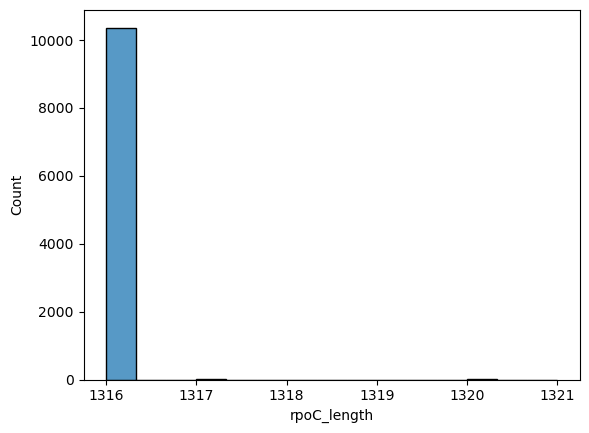

In [10]:
sns.histplot(data=gene_peptide_lengths,
             x='rpoC_length'
            )

In [8]:
gene_peptide_lengths['rpoC_length'].value_counts()

rpoC_length
1316    10367
1317        3
1320        3
1318        2
1321        1
Name: count, dtype: int64

In [6]:
drug = 'PZA'
config_file = f"config_files/config_{drug.lower()}.yaml"
kwargs = yaml.safe_load(open(config_file, "r"))
embed_genes = kwargs['tier2_genes'] + kwargs['LASSO_genes']
print(len(embed_genes))

18


In [7]:
keep_genes_lst = [f'"{val}"' for val in embed_genes]
print(' '.join(keep_genes_lst), "\n")

"sigE" "Rv3236c" "Rv1258c" "Rv1056" "ctpI" "pks8" "esxW" "prrA" "Rv1482c" "Rv1894c" "mmpL10" "glcB" "mfd" "Rv2571c" "lldD2" "kdpA" "moeA1" "Rv0161" 



In [6]:
TRUST_df = pd.read_csv("analysis/TRUST_MIC_20240124.csv")
TRUST_samples = TRUST_df['SampleID'].values
len(TRUST_samples)

397

In [32]:
TRUST_df.loc[TRUST_df['comment']=='empty, all DNA used - Illumina and PacBio']

,SampleID,original_ID,shipment,status,comment,SampleLib,Coll2014_Annotated,quality,Cov_Any_Mean,Cov_Unam_Perc,Perc_Reads_Mapped,patient_num,sample_week,pid,Coll2014,Lineage,s_inhmic_sputum_specimen_1,s_rifmic_sputum_specimen_1,s_embmic_sputum_specimen_1,s_pzamic_sputum_specimen_1
348,MFS-401,S0333-01,3rd,finished,"empty, all DNA used - Illumina and PacBio",MFS-401_lib59408,4.3.2.1 LAM,1.0,274.6,1.0,0.9913,333,1,T0333,4.3.2.1,4,2.0,3.0,3.0,1.0


In [63]:
TRUST_data_processed_VCF = glob.glob("/n/data1/hms/dbmi/farhat/rollingDB/TRUST/231218.TRUST.Illumina.Batch3.Output/*/pilon/*_variants.vcf")
len(TRUST_data_processed_VCF)
# TRUST_data_need_variant_calling =

144

In [75]:
df_processed = pd.DataFrame({"Pilon_File": TRUST_data_processed_VCF})
df_processed['Sample'] = [os.path.basename(dir_name).split("_")[0] for dir_name in df_processed.Pilon_File]
df_processed['Pilon_Dir'] = [os.path.dirname(dir_name) for dir_name in df_processed.Pilon_File]
df_processed[['Sample', 'Pilon_Dir']].to_csv("analysis/TRUST_finished_variant_calling.tsv", sep='\t', header=None, index=False)

In [104]:
complete = 0

for name in df_processed.Sample.values:
    if os.path.isfile(f"/n/scratch/users/s/sak0914/TRUST/{name}/lineage_calling/{name}_lineage.tsv"):
        complete += 1

complete, len(df_processed)

(144, 144)

In [105]:
complete = 0

for name in list(df_processed.Sample.values) + list(df_for_variant_calling.Sample.values):
    if os.path.isfile(f"/n/scratch/users/s/sak0914/TRUST/{name}/pilon/{name}_variants.vcf"):
        complete += 1

complete, len(list(df_processed.Sample.values) + list(df_for_variant_calling.Sample.values))

(221, 411)

In [29]:
# for fName in TRUST_data_processed_VCF:
#     isolate = os.path.basename(fName).split("_")[0]
#     shutil.copy(fName, f"/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/TRUST/VCF_clean/{isolate}.vcf")

In [35]:
# get all paths to BAM files, then run your own variant calling with MQ = 1 thresh and no other thresholds
bam_files_batch_1 = glob.glob("/n/data1/hms/dbmi/farhat/rollingDB/TRUST/220617.TRUST.Set1.Illumina.Output/*/IlluminaWGS/IlluminaPE_AlignedTo_H37rv/*.IllPE.H37rv.duprem.bam")
bam_files_batch_2 = glob.glob("/n/data1/hms/dbmi/farhat/rollingDB/TRUST/221216.TRUST.Illumina.Batch2.Output/*/IlluminaWGS/IlluminaPE_AlignedTo_H37rv/*.IllPE.H37rv.duprem.bam")
len(bam_files_batch_1), len(bam_files_batch_2)

(191, 76)

In [81]:
df_for_variant_calling = pd.DataFrame({'BAM': bam_files_batch_1 + bam_files_batch_2})
df_for_variant_calling['Sample'] = [os.path.basename(fName).split(".")[0] for fName in df_for_variant_calling.BAM.values]
df_for_variant_calling[['Sample', 'BAM']].to_csv("analysis/TRUST_bams_for_variants_calling.tsv", sep='\t', header=None, index=False)

In [ ]:
sbatch variant_calling.sh TRUST_bams_for_variants_calling.tsv

In [ ]:
bash variant_calling.sh TRUST_bams_for_variants_calling.tsv

In [47]:
df_for_variant_calling[['Sample', 'BAM']].iloc[:1]

,Sample,BAM
0,MFS-40,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/22061...


## Molar Masses of Drugs

In [83]:
molar_mass_dict = {'INH': 137.14,
                   'RIF': 822.94,
                   'EMB': 204.31,
                   'MXF': 401.43,
                   'ETH': 166.24,
                   'BDQ': 555.50,
                   'LZD': 337.35,
                   'AMI': 585.61,
                   'PTM': 359.26,
                   'SQ109': 330.56
                  }

In [3]:
Alland_Courtney_MICs_raw = pd.read_excel("MIC_data/Alland_Courtney_MICs.xlsx", sheet_name=None)
H37Rv_standards = Alland_Courtney_MICs_raw['H37Rv_standards'].set_index('Drug')
# Alland_Courtney_MICs_raw['H37Rv_standards']['Drug'] = Alland_Courtney_MICs_raw['H37Rv_standards']['Drug'].replace('AMK', 'AMI').replace('PA824', 'PTM')

Alland_Courtney_MICs = pd.read_csv("MIC_data/Alland_Courtney_MICs.csv")
len(Alland_Courtney_MICs)

91

In [4]:
Alland_Courtney_MICs.query("ID in ['Erdman', 'CDC1551']")[['ID', 'ROLLINGDB_ID']]

,ID,ROLLINGDB_ID
79,CDC1551,SAMN02402661
80,Erdman,SAMEA3558180


In [5]:
Alland_Courtney_metadata = pd.read_csv("MIC_data/Alland_Courtney_WGS_to_download.csv")

In [6]:
Alland_Courtney_metadata.query("Query in ['Erdman', 'CDC1551']")

,Query,ReleaseDate,LoadDate,Run,Sample,LibraryName,BioSample,Platform,Model,TaxID,ScientificName,CenterName,Combined_Runs,Num_Runs
35,CDC1551,2013-12-17 00:16:09,2013-12-17 00:23:18,SRR1051196,SRS515998,Solexa-188725,SAMN02402661,ILLUMINA,Illumina HiSeq 2000,83331.0,Mycobacterium tuberculosis CDC1551,BI,"SRR1051196,SRR1051197",2
36,CDC1551,2013-12-17 00:16:08,2013-12-17 00:19:43,SRR1051197,SRS515998,Solexa-189619,SAMN02402661,ILLUMINA,Illumina HiSeq 2000,83331.0,Mycobacterium tuberculosis CDC1551,BI,"SRR1051196,SRR1051197",2
37,Erdman,2015-10-27 04:36:28,2015-12-10 05:38:40,ERR1034647,ERS865329,unspecified,SAMEA3558180,ILLUMINA,Illumina MiSeq,1773.0,Mycobacterium tuberculosis,LSHTM,"ERR1034647,ERR1213895",2
38,Erdman,2016-01-20 05:34:31,2016-03-02 13:08:50,ERR1213895,ERS865329,unspecified,SAMEA3558180,ILLUMINA,Illumina MiSeq,1773.0,Mycobacterium tuberculosis,LSHTM,"ERR1034647,ERR1213895",2


In [302]:
test = Alland_Courtney_metadata.query("Query in ['CDC1551', 'Erdman']")[['BioSample', 'Combined_Runs']]

In [306]:
test.to_csv("Alland_more.tsv", sep='\t', header=None, index=False)

In [46]:
samples_pass_geno_QC = pd.read_csv("data_processing/samples_pass_geno_QC.csv")
rollingDB_MIC_raw = pd.read_csv("MIC_data/rollingDB_MIC_raw.csv")

print(len(samples_pass_geno_QC))

14210


In [55]:
annot_fNames = []
for fName in samples_pass_geno_QC.VCF.values:

    annot_fName = fName.replace("_variants", "_variants_combinedCodons.eff")
    assert os.path.isfile(annot_fName)
    annot_fNames.append(annot_fName)

In [126]:
len(annot_fNames)

14210

In [138]:
lineage_mat_fName = f"/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/lineage_matrix_Coll2014.csv"
old_lineages_mat = pd.read_csv(lineage_mat_fName, index_col=[0])

14125

In [ ]:
os

In [174]:
df = pd.read_csv("./data_processing/samples_pass_geno_QC.csv")

In [175]:
len(df), df.ROLLINGDB_ID.nunique()

(14135, 14135)

In [190]:
VCFs_remove_duplicate_indels = pd.read_csv("./data_processing/VCFs_remove_duplicate_indels.csv", header=None)
len(VCFs_remove_duplicate_indels)

14134

In [152]:
lineage_mat_fName = f"/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/lineage_matrix_{suffix}.csv"
lineage_mat = pd.read_csv(lineage_mat_fName, index_col=[0])

In [91]:
pd.Series(annot_fNames).to_csv("data_processing/samples_fNames_for_extraction.tsv", sep='\t', header=None, index=False)

In [136]:
who_variants = pd.read_csv("./data_processing/data_utils/WHO-catalog-V2.csv", header=[2]).query("tier==1").reset_index(drop=True)

# create columns for REF and ALT for noncoding mutations only. This is to look for them later
for i, row in who_variants.iterrows():

    if row['genomic position'].isalnum():
        pos = int(float(row['genomic position']))
        assert '_p.' not in row['variant']

        if '>' in row['mutation']:        
            who_variants.loc[i, 'REF'] = row['mutation'].split('>')[0][-1]
            who_variants.loc[i, 'ALT'] = row['mutation'].split('>')[-1]
        else:
            who_variants.loc[i, ['REF', 'ALT']] = [np.nan, np.nan]
    else:
        who_variants.loc[i, ['REF', 'ALT']] = [np.nan, np.nan]

del who_variants['mutation']
who_variants.rename(columns={'variant': "mutation", "genomic position": "POS"}, inplace=True)

In [138]:
drug = 'ETH'
full_drug_name = abbr_drug_dict[drug]
group1_WHO_variants = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/group1_WHO_variants.tsv", sep='\t')

# convert POS column to string type to compare with the genomic position column in who_variants
# need to compare positions because variants in noncoding regions (importantly, promoter variants) may not match in the MUT column
group1_WHO_variants['POS'] = group1_WHO_variants['POS'].astype(str)

# get the complete mutation names for Group 1 graded mutations from the V2 catalog
single_drug_group1_mutations = who_variants.loc[who_variants['FINAL CONFIDENCE GRADING']=='1) Assoc w R'].query(f"drug==@full_drug_name").mutation.values

# get the isolates that have these mutations with high confidence
isolates_with_group1_coding_mutations = group1_WHO_variants.query("MUT in @single_drug_group1_mutations & FILTER=='PASS' & QUAL >= 10 & AF > 0.75 & DP >= 5 & BQ >= 20 & MQ >= 30").ISOLATE.values

# get a dataframe of the noncoding mutations to merge the mutations in the samples in the dataset with
single_drug_group1_noncoding_df = who_variants.loc[(who_variants['FINAL CONFIDENCE GRADING']=='1) Assoc w R') & (~who_variants['POS'].str.contains('sheet'))].query(f"drug==@full_drug_name")

# get the isolates that have the noncoding mutations with high confidence
islates_with_group1_noncoding_mutations = group1_WHO_variants.query("FILTER=='PASS' & QUAL >= 10 & AF > 0.75 & DP >= 5 & BQ >= 20 & MQ >= 30")[['ISOLATE', 'POS', 'REF', 'ALT']].merge(single_drug_group1_noncoding_df[['POS', 'REF', 'ALT']], on=['POS', 'REF', 'ALT'], how='inner').ISOLATE.values

isolates_with_group1_mutations = list(set(isolates_with_group1_coding_mutations).union(islates_with_group1_noncoding_mutations))

In [162]:
# drug_loci.loc[(drug_loci['Locus']=='rrl'), ['Start', 'End', 'Sense']] = [1471486, 1477013, '+']
# drug_loci.loc[(drug_loci['Locus']=='rplC'), 'Sense'] = '+'
# drug_loci.loc[(drug_loci['Locus']=='tsnR'), 'Sense'] = '+'


In [228]:
# drug_loci.to_csv("data_processing/data_utils/drug_loci.csv", index=False)

In [229]:
drug_loci = pd.read_csv("data_processing/data_utils/drug_loci.csv")


In [298]:
BDQ_peptide_lengths = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/PZA/gene_peptide_lengths.csv", index_col=[0])

In [299]:
for col in BDQ_peptide_lengths.columns:
    print(col, len(BDQ_peptide_lengths.query(f"{col}==0")))

Rv2042c_length 12
pncA_length 10
panD_length 0
panC_length 0
rpsA_length 0
clpC1_length 0
Rv3236c_length 1
Rv3237c_length 1
sigE_length 0
rseA_length 0
Rv1258c_length 0


In [300]:
search_lst = BDQ_peptide_lengths.query("pncA_length==0").index.values
search_lst

array(['SAMEA3392614', 'SAMN05915259', 'SAMN05916222', 'SAMN05916235',
       'SAMN05916324', 'SAMN05916417', 'SAMN05918556', 'SAMN05916296',
       'SAMN05918723', 'SAMN06094087'], dtype=object)

In [301]:
pncA_df = [(seq.id, str(seq.seq)) for seq in SeqIO.parse("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/PZA/fastas/pncA.fasta", "fasta")]
pncA_df = pd.DataFrame(pncA_df)

Rv0678_df = [(seq.id, str(seq.seq)) for seq in SeqIO.parse("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/BDQ/fastas/Rv0678.fasta", "fasta")]
Rv0678_df = pd.DataFrame(Rv0678_df)

Rv1979c_df = [(seq.id, str(seq.seq)) for seq in SeqIO.parse("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/BDQ/fastas/Rv1979c.fasta", "fasta")]
Rv1979c_df = pd.DataFrame(Rv1979c_df)

In [ ]:
778990..779487

In [ ]:
778986 delete 438

In [235]:
Rv0678_df.loc[Rv0678_df[0].isin(['SAMEA7562365'])][1].values

array(['CGCCCTCCGCCTCTGCCGCATGAAGTTCACGCCGGTCTGGTGACGCATACCGAACGTCACAGAT---TT-------CAGAGTACAGTGAAA-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------ATGGAG-AACGTCGTCTCCGACGCCCTGGG--G-CGATACAGCCAGCGAACCGGAGAGGAC--GACTGA'],
      dtype=object)

In [242]:
len("CGCCCTCCGCCTCTGCCGCATGAAGTTCACGCCGGTCTGGTGACGCATACCGAACGTCACAGAT---TT-------CAGAGTACAGTGAAA")

91

In [232]:
Rv0678_df.loc[Rv0678_df[0]=='SAMEA7562365'][1].values

array(['CCGCCCAGCGCGTCGGGGGCGTCGAGCACCACGCGACACCGGGCCCGATCGATCTGCTAGCTTGAGTCTGGTCAGGCATCGTCGTCAGCAGCGCGATGCCCTATGTTTGTCGTCGACTCAGATATCGCGGCAATCCAATCTCCCGCCTGCGGCCGGCGGTGCTGCAAACTACTCCCGGAGGAATTTCGACGTGCGCATCAAGATCTTCATGCTGGTCACGGCTGTCGTTTTGCTCTGTTGTTCGGGTGTGGCCACGGCCGCGCCCAAGACCTACTGCGAGGAGTTGAAAGGCACCGATACCGGCCAGGCGTGCCAGATTCAAATGTCCGACCCGGCCTACAACATCAACATCAGCCTGCCCAGTTACTACCCCGACCAGAAGTCGCTGGAAAATTACATCGCCCAGACGCGCGACAAGTTCCTCAGCGCGGCCACATCGTCCACTCCACGCGAAGCCCCCTACGAATTGAATATCACCTCGGCCACATACCAGTCC------GCGATACCGCCGCGTGGTACGCAGGCCGTGGTGCTCAAGGTCTACCAGAACGCCGGCGGCACGCACCCAACGACCACGTACAAGGCCTTCGATTGGGACCAGGCCTATCGCAAGCCAATCACCTATGACACGCTGTGGCAGGCTGACACCGATCCGCTGCCAGTCGTCTTCCCCATTGTGCAAGGTGAACTGAGCAAGCAGACCGGACAACAGGTATCGATAGCGCCGAATGCCGGCTTGGACCCGGTGAATTATCAGAACTTCGCAGTCACGAACGACGGGGTGATTTTCTTCTTCAACCCGGGGG-AGTTGCTGCCCGAAGCAGCCGGCCCAACCCAGGTATTGGTCCCACGTTCCGCGATCGACTCGATGCTGGCCTAGACTCGCGAGGACCGCGCGGTGGTCACTGCGCGGATTTGGGGCGGCGGAAGTGAGTGTTCGGTGCGCCCACTGCGGTGACTCACCTGCAGCGCCGGCATCGACAGGCCG

In [175]:
BDQ_peptide_lengths.query("Rv1979c_length==0")

,mmpL5_length,mmpS5_length,Rv0678_length,pepQ_length,atpE_length,lpqB_length,mtrB_length,mtrA_length,Rv1979c_length,mpt64_length
SAMEA1102324,964,142,165,372,81,583,567,228,0,152
SAMEA5282376,964,142,165,372,81,583,567,228,0,0
SAMEA7562072,964,142,165,372,81,583,567,228,0,0


In [176]:
BDQ_peptide_lengths.query("mpt64_length==0")

,mmpL5_length,mmpS5_length,Rv0678_length,pepQ_length,atpE_length,lpqB_length,mtrB_length,mtrA_length,Rv1979c_length,mpt64_length
SAMEA5282376,964,142,165,372,81,583,567,228,0,0
SAMEA7562072,964,142,165,372,81,583,567,228,0,0


In [142]:
isolates_with_group1_coding_mutations

array(['SAMN05918630', 'SAMN05918657', 'SAMEA104362466', 'SAMEA5569538',
       'SAMEA5569631', 'SAMEA5569640', 'SAMEA5569705', 'SAMEA5570074',
       'SAMEA7525192', 'SAMEA7525202', 'SAMEA7525222', 'SAMEA7525279',
       'SAMEA7525298', 'SAMEA7525423', 'SAMEA7525507', 'SAMEA7525519',
       'SAMEA7525520', 'SAMEA7525558', 'SAMEA7525871', 'SAMEA7526556',
       'SAMEA7526697', 'SAMEA7555724', 'SAMEA7555919', 'SAMEA7561281',
       'SAMEA7561306', 'SAMEA7561431', 'SAMEA7561442', 'SAMEA7561540',
       'SAMEA7561550', 'SAMEA7561829', 'SAMEA7563222', 'SAMEA7563225',
       'SAMEA7563229', 'SAMEA7563232', 'SAMEA7563233', 'SAMEA7563234',
       'SAMEA7563237', 'SAMEA7563238', 'SAMEA7563253', 'SAMEA7563260',
       'SAMEA7563264', 'SAMEA7563265', 'SAMEA7563268', 'SAMEA7563269',
       'SAMEA7563271', 'SAMEA7563278', 'SAMEA7563279', 'SAMEA7563280',
       'SAMEA7563619', 'SAMEA7563650', 'SAMEA7563680', 'SAMEA7563681',
       'SAMEA7563682'], dtype=object)

In [148]:
group1_WHO_variants.query("FILTER=='PASS' & QUAL >= 10 & AF > 0.75 & DP >= 5 & BQ >= 20 & MQ >= 30")[['ISOLATE', 'POS', 'REF', 'ALT', 'GENE', 'NUC', 'MUT']].merge(single_drug_group1_noncoding_df[['POS', 'REF', 'ALT']], on=['POS', 'REF', 'ALT'], how='inner')

,ISOLATE,POS,REF,ALT,GENE,NUC,MUT
0,29598,1673425,C,T,Rv1482c-fabG1,n.1673425C>T,Rv1482c-fabG1_n.1673425C>T
1,30544,1673425,C,T,Rv1482c-fabG1,n.1673425C>T,Rv1482c-fabG1_n.1673425C>T
2,26228,1673425,C,T,Rv1482c-fabG1,n.1673425C>T,Rv1482c-fabG1_n.1673425C>T
3,27186,1673425,C,T,Rv1482c-fabG1,n.1673425C>T,Rv1482c-fabG1_n.1673425C>T
4,29779,1673425,C,T,Rv1482c-fabG1,n.1673425C>T,Rv1482c-fabG1_n.1673425C>T
...,...,...,...,...,...,...,...
1585,SAMEA5282417,1673425,C,T,Rv1482c-fabG1,n.1673425C>T,Rv1482c-fabG1_n.1673425C>T
1586,SAMEA5282426,1673425,C,T,Rv1482c-fabG1,n.1673425C>T,Rv1482c-fabG1_n.1673425C>T
1587,SAMEA5282538,1673425,C,T,Rv1482c-fabG1,n.1673425C>T,Rv1482c-fabG1_n.1673425C>T
1588,SAMEA5282552,1673425,C,T,Rv1482c-fabG1,n.1673425C>T,Rv1482c-fabG1_n.1673425C>T


In [140]:
len(isolates_with_group1_mutations)

1643

In [15]:
group1_variants.query("MUT.str.contains('_c.')").EFFECT.unique()

array(['synonymous_variant',
       'splice_region_variant&stop_retained_variant'], dtype=object)

In [16]:
group1_variants.query("MUT.str.contains('_c.') & EFFECT != 'synonymous_variant'")

,POS,REF,ALT,FILTER,QUAL,AF,DP,BQ,MQ,GENE_ID,GENE,EFFECT,NUC,PROT,ISOLATE,MUT
30026,4249810,G,A,PASS,3693.0,1.0,95,39,60,Rv3795,embB,splice_region_variant&stop_retained_variant,c.3297G>A,p.Ter1099Ter,SAMEA104362046,embB_c.3297G>A


In [22]:
group1_variants.shape

(145527, 16)

In [27]:
group1_variants.EFFECT.unique()

array(['missense_variant', 'synonymous_variant', 'intragenic_variant',
       'frameshift_variant', 'intergenic_region',
       'stop_lost&splice_region_variant', 'stop_gained',
       'conservative_inframe_insertion', 'initiator_codon_variant',
       'disruptive_inframe_insertion', 'start_lost',
       'splice_region_variant&stop_retained_variant',
       'frameshift_variant&stop_gained'], dtype=object)

In [121]:
keep_idx = np.random.choice([0, 1])
keep_idx

0

In [122]:
['a', 'b'][keep_idx]

'a'

In [123]:
['a', 'b'][1-keep_idx]

'b'

In [77]:
group1_variants.tail(7)

,POS,REF,ALT,FILTER,QUAL,AF,DP,BQ,MQ,GENE_ID,GENE,EFFECT,NUC,PROT,ISOLATE
137476,1917972,A,G,PASS,6275.0,1.00,173,36,60,Rv1694,tlyA,synonymous_variant,c.33A>G,p.Leu11Leu,SAMEA8742203
137477,7362,G,C,PASS,2678.0,1.00,81,33,60,Rv0006,gyrA,missense_variant,c.61G>C,p.Glu21Gln,20542
137478,7585,G,C,PASS,1986.0,1.00,61,33,60,Rv0006,gyrA,missense_variant,c.284G>C,p.Ser95Thr,20542
137479,9304,G,A,PASS,2276.0,0.99,74,32,60,Rv0006,gyrA,missense_variant,c.2003G>A,p.Gly668Asp,20542
137480,1917972,A,G,PASS,1888.0,0.99,58,34,60,Rv1694,tlyA,synonymous_variant,c.33A>G,p.Leu11Leu,20542
137481,4246665,A,C,PASS,2075.0,1.00,63,33,57,Rv3795,embB,missense_variant,c.152A>C,p.Gln51Pro,20542
137482,4249408,G,A,PASS,2246.0,0.99,74,31,60,Rv3795,embB,synonymous_variant,c.2895G>A,p.Pro965Pro,20542


In [86]:
group1_variants = group1_variants.iloc[:-6]

In [70]:
group1_variants.ISOLATE.unique()

array(['20542', '21849', '23768', ..., 'SAMEA8742201', 'SAMEA8742202',
       'SAMEA8742203'], dtype=object)

,ROLLINGDB_ID,DB_OF_ORIGIN,VCF,F2,Coll2014,Freschi2020,Lipworth2019,Shitikov2017,Stucki2016
14019,SAMEA5282520,Alland,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,0.015678,4.1.1.1,"4.1.i1.2.1,3.1.1.i1",xtype,NaN,4
14020,SAMEA5282326,Alland,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,0.017020,2.2.2,2.2.2,"beijing,mungi","asia_ancestral_1,lin2.2",NaN
14021,SAMEA5282328,Alland,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,0.017058,4.5,4.2.1.1.2,NaN,NaN,4.5
14022,SAMEA5282330,Alland,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,0.018003,2.2.2,2.2.2,"beijing,mungi","asia_ancestral_1,lin2.2",NaN
14023,SAMEA5282332,Alland,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,0.012873,4.5,4.2.1.1.2,NaN,NaN,4.5
...,...,...,...,...,...,...,...,...,...
14205,B44,Alland,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,0.023127,2.2.1,2.2.1.1.1,"beijing,canetti","lin2.2.1,asian_african_3",NaN
14206,B91,Alland,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,0.011630,4.6.1.1,4.2.1.1.1.2.2.1.1.1.1,uganda,NaN,4.6.1/Uganda
14207,DA301,Alland,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,0.025436,4.2.1,4.2.2.2.1,"ural,canetti",NaN,4
14208,DA824,Alland,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,0.019918,4.1.2.1,4.1.i1.1.1.1,haarlem,NaN,4.1.2/Haarlem


In [ ]:
sample_ID="21849"
output_file="/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/group1_WHO_variants.tsv"
found_isolate=$(awk -F'\t' -v search="$sample_ID" -v col="-1" '$NF == search' $output_file)

In [65]:
group1_variants.dtypes

POS          int64
REF         object
ALT         object
FILTER      object
QUAL       float64
AF         float64
DP           int64
BQ           int64
MQ           int64
GENE_ID     object
GENE        object
EFFECT      object
NUC         object
PROT        object
ISOLATE     object
MUT         object
dtype: object

In [68]:
type(group1_variants.ISOLATE.values[0])

str

In [69]:
type(group1_variants.ISOLATE.values[-1])

str

In [104]:
duplicate_indels_df.loc[(pd.isnull(duplicate_indels_df['Locus'])) | (pd.isnull(duplicate_indels_df['Locus2']))]

,VCF,Isolate,KEEP_POS,DROP_POS,Locus,Locus2
0,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,SAMEA5282328,1305494,1305592,fbiC,NaN
1,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,SAMEA5282332,1305494,1305592,fbiC,NaN
6,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,SAMEA5282357,1305494,1305592,fbiC,NaN
7,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,SAMEA5282358,1305494,1305592,fbiC,NaN
8,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,SAMEA5282359,1305494,1305592,fbiC,NaN
9,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,SAMEA5282361,1305494,1305592,fbiC,NaN
11,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,SAMEA5282374,1305494,1305592,fbiC,NaN
14,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,SAMEA5282379,1305494,1305592,fbiC,NaN
17,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,SAMEA5282403,1305494,1305592,fbiC,NaN
18,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,SAMEA5282414,1305494,1305592,fbiC,NaN


In [121]:
# samples_pass_geno_QC.to_csv("data_processing/samples_pass_geno_QC.csv", index=False)

In [22]:
new_samples = np.concatenate([rollingDB_MIC_raw.dropna(subset='TDR_Sample')['BioSample'].values, Alland_Courtney_MICs['ROLLINGDB_ID'].values])
len(new_samples)

199

In [27]:
samples_pass_geno_QC.head()

,ROLLINGDB_ID,DB_OF_ORIGIN,VCF,F2,Coll2014,Freschi2020,Lipworth2019,Shitikov2017,Stucki2016
0,20542,MICML,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,0.027387,4.1.1,4.1.i1.2.1,"xtype,pinipedii",NaN,4.0
1,21849,MICML,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,0.012577,4.3.4.2.1,4.2.1.2.1.1.i3.1,"lam,beijing",NaN,4.3/LAM
2,23768,MICML,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,0.015828,4.8,4.2.1.1.1.1.1.1.i1,NaN,NaN,4.10/PGG3
3,24304,MICML,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,0.181536,4.1.1.1,4.1.i1.2.1,"xtype,lam",NaN,4
4,26243,MICML,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,0.013581,4.3.2.1,4.2.1.2.1.1.i1,lam,NaN,4.3/LAM


In [44]:
pd.concat([samples_pass_geno_QC, lineage_df]).to_csv("data_processing/samples_pass_geno_QC.csv", index=False)

In [40]:
lineage_df = pd.DataFrame(columns=samples_pass_geno_QC.columns)
count = 0

for name in new_samples:

    fName = f"/n/data1/hms/dbmi/farhat/rollingDB/genomic_data/{name}/lineage_calling/{name}_lineage.tsv"
    F2_fName = f"/n/data1/hms/dbmi/farhat/rollingDB/genomic_data/{name}/lineage_calling/{name}_F2_Coll2014.txt"
    VCF_fName = f"/n/data1/hms/dbmi/farhat/rollingDB/genomic_data/{name}/pilon/{name}_variants.vcf"

    if os.path.isfile(fName):
        count += 1
        df = pd.read_csv(fName, sep='\t')       

        df.rename(columns={'Isolate': 'ROLLINGDB_ID', 'coll2014': 'Coll2014', 'freschi2020': 'Freschi2020', 'lipworth2019': 'Lipworth2019', 'shitikov2017': 'Shitikov2017', 'stucki2016': 'Stucki2016'}, inplace=True)

        df['ROLLINGDB_ID'] = df['ROLLINGDB_ID'].str.replace("_variants", "")
        df['Coll2014'] = df['Coll2014'].str.replace("lineage", "")
        df['DB_OF_ORIGIN'] = 'Alland'

        with open(F2_fName, 'r') as file:
            F2 = file.readlines()
            assert len(F2) == 1
            F2 = float(F2[0])

        df['F2'] = F2
        assert os.path.isfile(VCF_fName)
        df['VCF'] = VCF_fName

        lineage_df = pd.concat([lineage_df, df])

count, len(new_samples)

(191, 199)

,ROLLINGDB_ID,DB_OF_ORIGIN,VCF,F2,Coll2014,Freschi2020,Lipworth2019,Shitikov2017,Stucki2016


,BioSample
0,SAMEA10029749
1,SAMEA10029750
2,SAMEA10029750
3,SAMEA10029751
4,SAMEA10029753
...,...
2500,SAMEA5282547
2501,SAMEA5282548
2502,SAMEA5282549
2503,SAMEA5282550


<Axes: xlabel='MXF_midpoint', ylabel='Count'>

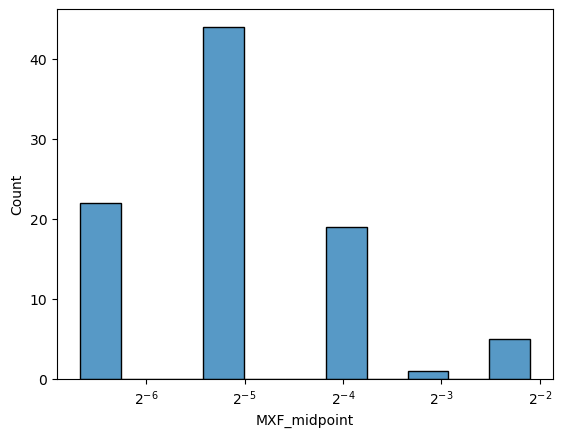

In [111]:
drug = 'MXF'

sns.histplot(data=Alland_Courtney_MICs,
             x=f"{drug}_midpoint",
             log_scale=2
            )

In [ ]:
MIC_mg_L

In [103]:
for col in Alland_Courtney_MICs.columns:

    if '_midpoint' in col or '_bound' in col:
        drug = col.split('_')[0]
        assert drug in H37Rv_standards.index.values

        # currently have the fold change between sample and H37Rv, so just multiply by MIC
        Alland_Courtney_MICs[f"{col}_NORM"] = Alland_Courtney_MICs[col] * H37Rv_standards.loc[drug, 'MIC_mg_L']

        assert len(Alland_Courtney_MICs.query(f"{drug}_lower_bound_NORM > {drug}_midpoint_NORM")) == 0
        assert len(Alland_Courtney_MICs.query(f"{drug}_upper_bound_NORM < {drug}_midpoint_NORM")) == 0

In [104]:
Alland_Courtney_MICs

,ID,INH,RIF,EMB,MXF,ETH,AMI,PTM,BDQ,LZD,...,PTM_midpoint_NORM_NORM,BDQ_lower_bound_NORM_NORM,BDQ_upper_bound_NORM_NORM,BDQ_midpoint_NORM_NORM,LZD_lower_bound_NORM_NORM,LZD_upper_bound_NORM_NORM,LZD_midpoint_NORM_NORM,SQ109_lower_bound_NORM_NORM,SQ109_upper_bound_NORM_NORM,SQ109_midpoint_NORM_NORM
0,TDR_001,≤0.25,≥8,0.5,1,4,0.5,2,0.5,1,...,0.001549,0.000077,0.000154,0.000116,0.052903,0.105806,0.079355,0.03748,0.074959,0.056219
1,TDR_005,1,≤0.25,0.5,1,≥8,1,2,0.5,1,...,0.001549,0.000077,0.000154,0.000116,0.052903,0.105806,0.079355,0.01874,0.037480,0.028110
2,TDR_006,≥8,≥8,4,0.5,4,4,1,0.5,1,...,0.000774,0.000077,0.000154,0.000116,0.052903,0.105806,0.079355,0.01874,0.037480,0.028110
3,TDR_007,≥8,4,1,1,2,1,2,1,0.5,...,0.001549,0.000154,0.000309,0.000231,0.026452,0.052903,0.039677,0.00937,0.018740,0.014055
4,TDR_019,≥8,2,2,0.5,≥8,0.5,1,0.5,≤0.25,...,0.000774,0.000077,0.000154,0.000116,0.000000,0.026452,0.013226,0.01874,0.037480,0.028110
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
86,B91,1,0.5,0.5,≤0.25,0.5,1,≤0.25,1,1,...,0.000129,0.000154,0.000309,0.000231,0.052903,0.105806,0.079355,0.01874,0.037480,0.028110
87,B94,1,≤0.25,≤0.25,≤0.25,1,1,0.5,1,1,...,0.000387,0.000154,0.000309,0.000231,0.052903,0.105806,0.079355,0.01874,0.037480,0.028110
88,DA301,≥8,≥8,2,0.5,≥8,2,0.5,2,0.5,...,0.000387,0.000309,0.000617,0.000463,0.026452,0.052903,0.039677,0.03748,0.074959,0.056219
89,DA824,≥8,≥8,≥8,1,≥8,2,0.5,2,0.5,...,0.000387,0.000309,0.000617,0.000463,0.026452,0.052903,0.039677,0.03748,0.074959,0.056219


In [48]:
# for col in Alland_Courtney_MICs.columns:
#     if 'PA824' in col:
#         Alland_Courtney_MICs.rename(columns={col: col.replace('PA824', 'PTM')}, inplace=True)

In [25]:
count = 0

for name in Alland_Courtney_MICs.ROLLINGDB_ID.values:
    if os.path.isfile(f"/n/data1/hms/dbmi/farhat/rollingDB/genomic_data/{name}/pilon/{name}_full.vcf.gz"):
        count += 1

count

83

In [87]:
Alland_Courtney_MICs_raw['H37Rv_standards']['Molar_mass_gmol'] = Alland_Courtney_MICs_raw['H37Rv_standards']['Drug'].map(molar_mass_dict)

Alland_Courtney_MICs_raw['H37Rv_standards']['MIC_mg_L'] = Alland_Courtney_MICs_raw['H37Rv_standards']['H37Rv_MIC'] * Alland_Courtney_MICs_raw['H37Rv_standards']['Molar_mass_gmol'] / 1000

In [88]:
Alland_Courtney_MICs_raw['H37Rv_standards']

,Drug,H37Rv_MIC,Molar_mass_gmol,MIC_mg_L
0,INH,0.1953,137.14,0.026783
1,RIF,0.0117,822.94,0.009628
2,EMB,3.1300,204.31,0.639490
3,MXF,0.0781,401.43,0.031352
4,ETH,6.0000,166.24,0.997440
5,AMI,0.4000,585.61,0.234244
6,PTM,0.2000,359.26,0.071852
7,BDQ,0.1000,555.50,0.055550
8,LZD,0.9760,337.35,0.329254
9,SQ109,0.7000,330.56,0.231392


In [93]:
Alland_Courtney_MICs_raw_2['Fold_change_H37Rv']

,Strain,INH,RIF,EMB,MXF,ETH,AMK,PA824,BDQ,LZD,SQ109
0,TDR1,≤0.25,≥8,0.5,1,4,0.5,2,0.5,1,2
1,TDR5,1,≤0.25,0.5,1,≥8,1,2,0.5,1,1
2,TDR6,≥8,≥8,4,0.5,4,4,1,0.5,1,1
3,TDR7,≥8,4,1,1,2,1,2,1,0.5,0.5
4,TDR19,≥8,2,2,0.5,≥8,0.5,1,0.5,≤0.25,1
...,...,...,...,...,...,...,...,...,...,...,...
87,B94,1,≤0.25,≤0.25,≤0.25,1,1,0.5,1,1,1
88,da301,≥8,≥8,2,0.5,≥8,2,0.5,2,0.5,2
89,da824,≥8,≥8,≥8,1,≥8,2,0.5,2,0.5,2
90,da405,≥8,≥8,4,0.5,4,1,1,1,0.5,1


In [95]:
with pd.ExcelWriter("MIC_data/Alland_Courtney_MICs.xlsx") as file:
    for key, val in Alland_Courtney_MICs_raw.items():
        val.to_excel(file, sheet_name=key, index=False)

In [8]:
TDR_strains_metadata = pd.read_csv("../data_cleaning/20240314_TDR_strains.csv")
len(TDR_strains_metadata), TDR_strains_metadata.BioSample.nunique(), TDR_strains_metadata.Run.nunique()

(369, 265, 265)

In [45]:
drop_queries = TDR_strains_metadata.loc[pd.isnull(TDR_strains_metadata['Run'])].Query.values
len(drop_queries)

104

In [46]:
TDR_strains_metadata.dropna(subset="Run").CenterName.value_counts()

CenterName
INSTITUTE OF TROPICAL MEDICINE    231
LSHTM                              34
Name: count, dtype: int64

In [47]:
TDR_strains_metadata.dropna(subset="Run").Query.nunique()

231

In [81]:
TDR_strains_keep = TDR_strains_metadata.dropna(subset="Run").query("CenterName=='INSTITUTE OF TROPICAL MEDICINE'").reset_index(drop=True)
TDR_strains_keep['TDR_Sample_Num'] = TDR_strains_keep['Query'].str.replace('TDR_', '').astype(int)

# no MICs for these either in the TDR master table, so maybe they didn't grow or something in culture
set(np.arange(236)+1) - set(TDR_strains_keep['TDR_Sample_Num'])

{221, 222, 223, 224, 225}

In [49]:
len(TDR_strains_keep.Query.values), len(np.unique(TDR_strains_keep.Query.values))

(231, 231)

In [54]:
isolate_metadata_TDR = isolate_metadata.query("ROLLINGDB_ID.str.startswith('TDR')").reset_index(drop=True)

for i, row in isolate_metadata_TDR.iterrows():

    clean_name = '_'.join(row['ROLLINGDB_ID'].split('_')[:2])
    sample_num = float(clean_name.replace('TDR_', ''))
    
    isolate_metadata_TDR.loc[i, ['TDR_Num', 'Sample_Num']] = [clean_name, sample_num]

isolate_metadata_TDR['Sample_Num'] = isolate_metadata_TDR['Sample_Num'].astype(int)

In [58]:
isolate_metadata_TDR.Sample_Num.nunique(), set(isolate_metadata_TDR.Sample_Num).symmetric_difference(TDR_strains_keep['Sample_Num'])

(231, set())

In [65]:
count = 0
# TDR_strains_keep = pd.read_csv("MIC_data/TDR_cleaned_metadata.csv")
rollingDB_MIC_data = pd.read_csv("MIC_data/rollingDB_MIC_raw.csv")

for i, row in rollingDB_MIC_data.iterrows():
    if os.path.isfile(f"/n/data1/hms/dbmi/farhat/rollingDB/genomic_data/{row['BioSample']}/{row['Run']}/kraken/kraken_report"):
        count += 1

count, len(rollingDB_MIC_data)

(2363, 2505)

In [70]:
rollingDB_MIC_data.dropna(subset="TDR_Sample")[['INH', 'RIF', 'MXF']].loc[~pd.isnull(rollingDB_MIC_data['MXF'])]

,INH,RIF,MXF


In [75]:
Alland_MIC = pd.read_csv("MIC_data/Alland_Courtney_MICs.csv").rename(columns={'ROLLINGDB_ID': 'Name'})

In [80]:
names = []

for name in Alland_MIC.Name.values:

    if name.startswith('TDR_'):
        names.append(f"TDR_{int(float(name.split('_')[1]))}")
    else:
        names.append(name)

mapping_dict = dict(zip(Alland_MIC.Name.values, names))

In [83]:
Alland_MIC['TDR_Sample'] = Alland_MIC['Name'].map(mapping_dict)

In [94]:
Alland_MIC.merge(rollingDB_MIC_data[['TDR_Sample', 'BioSample', 'Sample', 'Run']], on='TDR_Sample', how='left')

,Name,INH,RIF,EMB,MXF,ETH,AMK,PA824,BDQ,LZD,...,LZD_lower_bound,LZD_upper_bound,LZD_midpoint,SQ109_lower_bound,SQ109_upper_bound,SQ109_midpoint,TDR_Sample,BioSample,Sample,Run
0,TDR_001,≤0.25,≥8,0.5,1,4,0.5,2,0.5,1,...,0.488,0.976,0.732,0.700,1.40,1.0500,TDR_1,NaN,NaN,NaN
1,TDR_005,1,≤0.25,0.5,1,≥8,1,2,0.5,1,...,0.488,0.976,0.732,0.350,0.70,0.5250,TDR_5,NaN,NaN,NaN
2,TDR_006,≥8,≥8,4,0.5,4,4,1,0.5,1,...,0.488,0.976,0.732,0.350,0.70,0.5250,TDR_6,NaN,NaN,NaN
3,TDR_007,≥8,4,1,1,2,1,2,1,0.5,...,0.244,0.488,0.366,0.175,0.35,0.2625,TDR_7,SAMEA5282520,ERS3089788,ERR3132270
4,TDR_019,≥8,2,2,0.5,≥8,0.5,1,0.5,≤0.25,...,0.000,0.244,0.122,0.350,0.70,0.5250,TDR_19,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
86,B91,1,0.5,0.5,≤0.25,0.5,1,≤0.25,1,1,...,0.488,0.976,0.732,0.350,0.70,0.5250,B91,NaN,NaN,NaN
87,B94,1,≤0.25,≤0.25,≤0.25,1,1,0.5,1,1,...,0.488,0.976,0.732,0.350,0.70,0.5250,B94,NaN,NaN,NaN
88,DA301,≥8,≥8,2,0.5,≥8,2,0.5,2,0.5,...,0.244,0.488,0.366,0.700,1.40,1.0500,DA301,NaN,NaN,NaN
89,DA824,≥8,≥8,≥8,1,≥8,2,0.5,2,0.5,...,0.244,0.488,0.366,0.700,1.40,1.0500,DA824,NaN,NaN,NaN


In [10]:
TDR_strains_keep[['BioSample', 'Run']].to_csv("TDR_samples_megapipe.tsv", sep='\t', header=None, index=False)

In [ ]:
sbatch run_megapipe.sh ../../TDR_samples_megapipe.tsv /n/data1/hms/dbmi/farhat/rollingDB/genomic_data

In [210]:
isolate_metadata.loc[~pd.isnull(isolate_metadata['TDR_Sample'])][['RUN']].to_csv("../data_cleaning/TDR_FASTQ_download.csv", index=False, header=None)

In [ ]:
bash download_SRA_data.sh TDR_FASTQ_download.csv /n/data1/hms/dbmi/farhat/rollingDB/fastq_db

In [66]:
cryptic_metadata = pd.read_csv("/n/data1/hms/dbmi/farhat/rollingDB/metadata/cryptic_WGS_metadata.csv")

In [110]:
TDR_bank = pd.read_excel("../data_cleaning/TDR_bank_data.xlsx", sheet_name=0, header=[0, 1])
TDR_bank_locations = TDR_bank[[('General strain info', 'TB-TDR nr'), ('General strain info', 'Geographical Origin')]].dropna(how='all', axis=0)
TDR_bank_locations.columns = TDR_bank_locations.columns.droplevel()

for i, row in TDR_bank_locations.iterrows():

    sample_name = row['TB-TDR nr']
    sample_num = float(sample_name.replace('TB-TDR-', ''))

    TDR_bank_locations.loc[i, 'TDR_Sample_Num'] = sample_num

TDR_bank_locations['TDR_Sample_Num'] = TDR_bank_locations['TDR_Sample_Num'].astype(int)
TDR_bank_locations.rename(columns={'Geographical Origin': "ISOLATION_LOCATION"}, inplace=True)

In [119]:
TDR_strains_keep = TDR_strains_keep[['BioSample', 'Sample', 'Run', 'Query', 'TDR_Sample_Num', 'Platform', 'Model', 'TaxID', 'ScientificName', 'ReleaseDate', 'LoadDate', 'CenterName']].sort_values('TDR_Sample_Num').rename(columns={'Query': 'TDR_Sample'})

TDR_strains_keep = TDR_strains_keep.merge(TDR_bank_locations[['TDR_Sample_Num', "ISOLATION_LOCATION"]], on='TDR_Sample_Num')
TDR_strains_keep.to_csv("MIC_data/TDR_cleaned_metadata.csv", index=False)

In [173]:
TDR_strains_keep_for_merge = TDR_strains_keep.copy()

TDR_strains_keep_for_merge = TDR_strains_keep_for_merge[['TDR_Sample', 'BioSample', 'ISOLATION_LOCATION', 'ScientificName', 'Sample', 'Run', 'Platform', 'Model', 'TaxID', 'ReleaseDate', 'LoadDate']].rename(columns={'BioSample': 'BIOSAMPLE_ACCESSION', 'Sample': 'SAMPLE', 'ScientificName': 'SPECIES', 'Run': 'RUN'})

TDR_strains_keep_for_merge['ROLLINGDB_ID'] = TDR_strains_keep_for_merge['BIOSAMPLE_ACCESSION'].values
TDR_strains_keep_for_merge = TDR_strains_keep_for_merge.set_index('ROLLINGDB_ID').reset_index()

TDR_strains_keep_for_merge['DB_OF_ORIGIN'] = 'TDR'
TDR_strains_keep_for_merge['SPUTUM/CULTURE'] = 1
TDR_strains_keep_for_merge['UNPAIRED/PAIRED'] = 1

In [174]:
# isolate_metadata = pd.read_csv("/n/data1/hms/dbmi/farhat/rollingDB/metadata/isolate_metadata.csv")
# isolate_metadata = isolate_metadata.query("~ROLLINGDB_ID.str.startswith('TDR')")
# isolate_metadata = pd.concat([isolate_metadata, TDR_strains_keep_for_merge], axis=0)
# isolate_metadata.to_csv("/n/data1/hms/dbmi/farhat/rollingDB/metadata/isolate_metadata.csv", index=False)

In [127]:
TDR_strains_keep_for_merge = TDR_strains_keep.copy()

In [130]:
model_loci = pd.read_csv("data_processing/data_utils/drug_loci.csv")

In [138]:
os.path.isfile("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/VCF_clean/SAMEA3392614.vcf.bgz")

True

In [137]:
# model_loci.to_csv("data_processing/data_utils/drug_loci.csv", index=False)

In [164]:
drug_gene_mapping.query("Drug=='Pyrazinamide'").sort_values("Tier")

,Drug,Gene,Tier
102,Pyrazinamide,clpC1,1
103,Pyrazinamide,panD,1
104,Pyrazinamide,pncA,1
97,Pyrazinamide,Rv3236c,2
98,Pyrazinamide,Rv1258c,2
99,Pyrazinamide,rpsA,2
100,Pyrazinamide,sigE,2
101,Pyrazinamide,PPE35,2


In [12]:
model_loci.query("Drug=='LEV'")

,Drug,Locus,Start,End,Sense
23,LEV,Rv2477c,2782365,2784122,-
24,LEV,Rv1129c,1253073,1254554,-
25,LEV,Rv2752c,3064514,3067192,-
26,LEV,gyrBA,4997,9818,+


In [16]:
h37Rv_genes.query("Symbol=='Rv2752c'")

,Gene_Ind,Feature,Start,End,Strand,Frame,H37rv_GeneID,Symbol,Function,Product,...,SWISS-MODEL,Orthologues M. leprae,Orthologues M. marinum,Orthologues M. smegmatis,Orthologues M. bovis,Orthologues M. lepromatosis,Orthologues M. tuberculosis,Orthologues M. abscessus,Orthologues M. haemophilum,Orthologues M. orygis
2828,2828,CDS,3064515,3066191,-,0.0,Rv2752c,Rv2752c,Function unknown,Conserved hypothetical protein,...,P9WGZ9,"ML1512,ML1512c",MMAR_1963,MSMEG_2685,Mb2773c,NaN,NaN,NaN,NaN,NaN


In [17]:
PZA_gene_peptide_lengths = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/PZA/gene_peptide_lengths.csv", index_col=[0])

In [20]:
PZA_gene_peptide_lengths.query("Rv2042c_length < 250")#.Rv2477c_length.unique()

,Rv2042c_length,pncA_length,panD_length,panC_length,rpsA_length,clpC1_length,Rv3236c_length,Rv3237c_length,sigE_length,rseA_length,Rv1258c_length
SAMEA3392614,0,0,139,309,481,848,385,160,257,154,231
SAMEA3403355,0,101,139,309,481,848,385,160,257,154,231
SAMN05915259,0,0,139,309,481,848,385,160,257,154,419
SAMN05916222,0,0,139,309,481,848,385,160,257,154,419
SAMN05916296,0,0,139,309,481,848,385,160,257,154,419
SAMN05916324,0,0,139,309,481,848,385,160,257,154,419
SAMN05916417,0,0,139,309,481,848,385,160,257,154,419
SAMN05918556,0,0,139,309,481,848,385,160,257,154,231
SAMN05918734,0,101,139,309,481,848,385,160,257,154,231
SAMN05919591,0,7,139,309,481,848,385,160,257,154,419


In [33]:
Alland_strains = pd.read_csv("Alland_strains.tsv", sep='\t', header=None)
# Alland_strains = Alland_strains.loc[Alland_strains[0] != 'TDR_162']
# Alland_strains.to_csv("Alland_strains.tsv", sep='\t', header=None, index=False)

In [2]:
Alland_strains = pd.read_csv("Alland_strains.tsv", sep='\t', header=None)

In [3]:
os.path.isfile(f"/n/data1/hms/dbmi/farhat/rollingDB/fastq_db/TDR_162/TDR_162_R1.fastq.gz")

False

In [5]:
pd.DataFrame({'ID': 'TDR_162_S130_L002', 'ID2': 'TDR_162_S130_L002'}, index=[0]).to_csv("Alland_strains_rerun.tsv", sep='\t', header=None, index=False)

In [ ]:
bash run_megapipe.sh ../../Alland_strains_rerun.tsv /n/data1/hms/dbmi/farhat/rollingDB/genomic_data

In [25]:
# for name in Alland_strains[0].values:
#     if os.path.isdir(f"/n/data1/hms/dbmi/farhat/rollingDB/genomic_data/{name}"):
#         print(os.listdir(f"/n/data1/hms/dbmi/farhat/rollingDB/genomic_data/{name}"))

,0,1
0,TDR_132,TDR_132
1,TDR_034,TDR_034
2,TDR_104,TDR_104
3,TDR_065,TDR_065
4,TDR_054,TDR_054
...,...,...
82,TDR_153,TDR_153
83,TDR_150,TDR_150
84,TDR_072,TDR_072
85,TDR_067,TDR_067


In [53]:
isolate_metadata.query("ROLLINGDB_ID.str.contains('TDR_001')")

,ROLLINGDB_ID,BIOSAMPLE_ACCESSION,ISOLATION_LOCATION,DB_OF_ORIGIN,SPUTUM/CULTURE,SPECIES,UNPAIRED/PAIRED,SAMPLE,RUN,Platform,Model,TaxID,ReleaseDate,LoadDate,Combined_Runs,Num_Runs
6800,TDR_001,NaN,NaN,TDR,1,Mycobacterium tuberculosis,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [55]:
isolate_metadata.query("ROLLINGDB_ID.str.contains('TDR_1_')")

,ROLLINGDB_ID,BIOSAMPLE_ACCESSION,ISOLATION_LOCATION,DB_OF_ORIGIN,SPUTUM/CULTURE,SPECIES,UNPAIRED/PAIRED,SAMPLE,RUN,Platform,Model,TaxID,ReleaseDate,LoadDate,Combined_Runs,Num_Runs
7644,TDR_1_S86_L002,NaN,Bangladesh,TDR,1,Mycobacterium tuberculosis,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [51]:
len(search_lst), len(np.unique(search_lst))

(331, 329)

In [58]:
pd.Series(np.unique(search_lst)).to_csv("../data_cleaning/TDR_search.tsv", sep='\t', header=None, index=False)

In [44]:
all_data = []

for i, query_name in enumerate(search_lst):
    
    # print(f"Processing line {i+1} of {len(fName)}")

    command = f'esearch -db sra -query "Mycobacterium tuberculosis AND {query_name}" | efetch -format runinfo'

    try:
        res = subprocess.Popen(command, shell=True, encoding='utf8', stdout=subprocess.PIPE)
        
        res = res.communicate()[0]
    
        with open("/home/sak0914/data_cleaning/intermediate_res.txt", 'w+') as file:
            file.write(res)
    
        res_df = pd.read_csv("/home/sak0914/data_cleaning/intermediate_res.txt")
        res_df['Query'] = query_name

        all_data.append(res_df)
        #all_data.append(res_df[['Query', 'ReleaseDate', 'LoadDate', 'Run', 'Sample', 'LibraryName', 'BioSample', 'Platform', 'Model', 'TaxID', 'ScientificName']])
    except:
        all_data.append(pd.DataFrame({"Query": query_name}, index=[i]))
        
    if i % 50 == 0:
        print(f"Finished {i}")

    # print("--------------------------------")

all_data = pd.concat(all_data)

Finished 0
Finished 50


In [45]:
all_data

,Query
0,TDR_001
1,TDR_002
2,TDR_003
3,TDR_004
4,TDR_005
...,...
93,TDR_095
94,TDR_096
95,TDR_097
96,TDR_098


In [35]:
Alland_download = pd.read_csv("MIC_data/Alland_Courtney_WGS_to_download.csv")

In [36]:
Alland_download

,Query,ReleaseDate,LoadDate,Run,Sample,LibraryName,BioSample,Platform,Model,TaxID,ScientificName,CenterName
0,B13,2023-05-01 00:02:05,2022-01-18 19:28:52,SRR17657999,SRS11705212,=A108,SAMN25078197,ILLUMINA,NextSeq 550,1773.0,Mycobacterium tuberculosis,RUTGERS UNIVERSITY NEWARK
1,B44,2021-10-16 19:16:34,2021-10-16 19:11:23,SRR16370647,SRS10601295,1479146369267T184315lib5048nextseqn0036151bp,SAMN20693115,ILLUMINA,NextSeq 500,1773.0,Mycobacterium tuberculosis,HARVARD MEDICAL SCHOOL
2,B61,2023-05-01 00:02:05,2022-01-18 19:27:27,SRR17657998,SRS11705213,=A109,SAMN25078198,ILLUMINA,NextSeq 550,1773.0,Mycobacterium tuberculosis,RUTGERS UNIVERSITY NEWARK
3,B91,2023-05-01 00:02:05,2022-01-18 19:32:01,SRR17657997,SRS11705214,=A110,SAMN25078199,ILLUMINA,NextSeq 550,1773.0,Mycobacterium tuberculosis,RUTGERS UNIVERSITY NEWARK
4,B94,2023-05-01 00:02:05,2022-01-18 19:28:43,SRR17657996,SRS11705215,=A111,SAMN25078200,ILLUMINA,NextSeq 550,1773.0,Mycobacterium tuberculosis,RUTGERS UNIVERSITY NEWARK
5,DA301,2023-05-01 00:02:05,2022-01-18 19:24:35,SRR17657994,SRS11705217,=A112,SAMN25078201,ILLUMINA,NextSeq 550,1773.0,Mycobacterium tuberculosis,RUTGERS UNIVERSITY NEWARK
6,TDR_104,2019-05-31 11:07:43,2019-05-31 13:31:45,ERR3132078,ERS3089596,unspecified,SAMEA5282328,ILLUMINA,Illumina HiSeq 2500,1773.0,Mycobacterium tuberculosis,INSTITUTE OF TROPICAL MEDICINE
7,TDR_105,2019-05-31 11:07:43,2019-05-31 13:31:56,ERR3132079,ERS3089597,unspecified,SAMEA5282329,ILLUMINA,Illumina HiSeq 2500,1773.0,Mycobacterium tuberculosis,INSTITUTE OF TROPICAL MEDICINE
8,TDR_109,2019-05-31 11:07:43,2019-05-31 13:32:50,ERR3132083,ERS3089601,unspecified,SAMEA5282333,ILLUMINA,Illumina HiSeq 2500,1773.0,Mycobacterium tuberculosis,INSTITUTE OF TROPICAL MEDICINE
9,TDR_111,2019-05-31 11:07:43,2019-05-31 13:33:12,ERR3132086,ERS3089604,unspecified,SAMEA5282336,ILLUMINA,Illumina HiSeq 2500,1773.0,Mycobacterium tuberculosis,INSTITUTE OF TROPICAL MEDICINE


In [14]:
len(TDR_strains), len(np.unique(sep_names))

(371, 329)

In [17]:
TDR_df = pd.DataFrame({'TDR': TDR_strains, 'ID': sep_names})

In [30]:
duplicate_ids = TDR_df.iloc[TDR_df.index.values[TDR_df.duplicated('ID', keep=False)]].sort_values('ID').ID.values
TDR_df.iloc[TDR_df.index.values[TDR_df.duplicated('ID', keep=False)]].sort_values('ID')

,TDR,ID
63,TDR_007,TDR_007
51,TDR_007_S79_L002,TDR_007
162,TDR_100,TDR_100
342,TDR_100_S104_L002,TDR_100
356,TDR_101,TDR_101
...,...,...
98,TDR_198_S149_L002,TDR_198
314,TDR_216,TDR_216
196,TDR_216_S193_L002,TDR_216
66,TDR_217_S194_L002,TDR_217


In [31]:
TDR_df.iloc[TDR_df.index.values[TDR_df.duplicated('ID', keep=False)]].sort_values('ID').query("ID=='TDR_132'")

,TDR,ID
350,TDR_132_S101_L002,TDR_132
338,TDR_132,TDR_132


In [28]:
Alland_strains.loc[Alland_strains[0].isin(duplicate_ids)]

,0,1
0,TDR_132,TDR_132
2,TDR_104,TDR_104
5,TDR_172,TDR_172
7,TDR_100,TDR_100
11,TDR_167,TDR_167
12,TDR_105,TDR_105
13,TDR_111,TDR_111
14,TDR_116,TDR_116
21,TDR_123,TDR_123
24,TDR_188,TDR_188


In [26]:
Alland_strains.shape

(88, 2)

In [22]:
model_loci.query("Drug=='LEV'")

,Drug,Locus,Start,End,Sense
23,LEV,Rv2477c,2782365,2784122,-
24,LEV,Rv1129c,1253073,1254554,-
25,LEV,Rv2752c,3064514,3067192,-
26,LEV,gyrBA,4997,9818,+


In [135]:
model_loci.loc[(model_loci['Drug']=='PZA') & (model_loci['Locus']=='pncA'), ['Start', 'End']] = [2287883, 2289281]

In [136]:
model_loci.loc[(model_loci['Drug']=='PZA') & (model_loci['Locus']=='pncA')]

,Drug,Locus,Start,End,Sense
35,PZA,pncA,2287883,2289281,-


In [ ]:
['pncA', 'panD', 'rpsA', 'clpC1', 'Rv3236c', 'sigE', 'Rv1258c'] 

In [117]:
h37Rv_genes.query("Symbol=='Rv2477c'")

,Gene_Ind,Feature,Start,End,Strand,Frame,H37rv_GeneID,Symbol,Function,Product,...,SWISS-MODEL,Orthologues M. leprae,Orthologues M. marinum,Orthologues M. smegmatis,Orthologues M. bovis,Orthologues M. lepromatosis,Orthologues M. tuberculosis,Orthologues M. abscessus,Orthologues M. haemophilum,Orthologues M. orygis
2548,2548,CDS,2782366,2784042,-,0.0,Rv2477c,Rv2477c,Thought to be involved in active transport of ...,Probable macrolide-transport ATP-binding prote...,...,P9WQK3,ML1248,MMAR_3830,MSMEG_4700,Mb2504c,NaN,NaN,NaN,NaN,NaN


In [27]:
# LEV_df = pd.DataFrame({'Drug': ['Levofloxacin']*3, 'Locus': ['Rv3236c', 'Rv1129c', 'Rv2752c'], 'Start': [2782366, 1253074, 3064515], 'End': [2784122, 1254554, 3067192], 'Sense': ['-', '-', '-']})

In [58]:
# fName = "/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/VCF_clean/SAMEA3392614.vcf.bgz"
# vcf_reader = vcf.Reader(filename=fName)
# # vcf_reader.fetch('NC_000962.3', start=2288681, end=2289241)

In [146]:
os.path.isfile("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/VCF_clean/SAMN05918723.vcf.bgz.tbi")

True

In [2]:
fName = "/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/VCF_clean/SAMN05918723.vcf.bgz"

vcf_reader = vcf.Reader(filename=fName, compressed=True)
records = vcf_reader.fetch('NC_000962.3', start=2288681, end=2289241)

In [3]:
for record in records:
    print(record)
    break

Record(CHROM=NC_000962.3, POS=2286946, REF=CCAGACCGTCGGCACGGTCGAACGTCTGATATCGCCAGTGCCCGGCCAACGCGATCCCGGCCTTGCCCACAGAAAACAGGTCCGCCGTCGACATCGACTGCTGCTCAGCAGCGCTGGGGGCCACCTTGTGCTTGTTGGTCAGGTCGGCGTAGAACTGCACCGCTTCGAGGAACCCATCGTGGTCGAAATTGAGGTGGGTGGGATTCATCCGCGGAACCGACCACGGTACACCGTTATTCATGGCGAACAACCCGGCAGCGTAGAACGAGACCCACGCGTTGACGAAGCCCCATTGCCTGTCCCGTCCCGACCGGCCCTGCTTGGTAAGCGCCTGGGCGGCATCCAGGAATTCGGCGAAGCTCCATGGCCGTTCCCAGCTACCGGGCGGCGGTGGCACGCCGGCGTCGTCGAATAGCTGTTTGTTGTAGAACAAGAAGTTGCCGGACCATTGCTCCGGAAAGGCGTACTGGCCTCCGTTGAACGTGAAAGTCTCATACAGGGCCCCGATGCTGTCCGATTTCAGCTCCGCGGCGAAAGCCTGGTCGCGCGCCAATAGCGTGTTCAGGTCAAGCAACACCCCCCGGTCGGCCAGTTCGGCATAGGTCAGTTCCCATGCCATCAGCACATCCGGACACTTGCCACCCGCGCAAAACGTTGCGAGCTGCTGCATGACGCCGGGTCCGGACAACAGGGCCCGTACCTTGATATCGGGATAGCGCCGCTGGAATTCGTTGACGACGCGCATCCGGGGACGGAGCTCGTCCGGATTGGCTGCAAAAAAGAAAGTCAACGCGTCATCGTCATCGGCAGCACACCCAGCGGCCCAGGGAGCCAGCGAGGCCGCAGTAAGCGCGCCCGCACCCCGTAACAGACTGCGCCGCTCGAACGGCTTATTGACCATCGTGCTCCCGATTTTGGGTCCTGTGGTACAACGACCGTCAGGCTGGGAAGTACCGA

In [5]:
type(records)

vcf.parser.Reader

In [47]:
os.path.isfile("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/VCF_clean/SAMEA3392614.vcf.tbi")

True

In [ ]:
tabix -0 -p vcf /n/data1/hms/dbmi/farhat/Sanjana/MIC_data/VCF_clean/SAMEA3392614.vcf.gz

In [ ]:
gzip -c /n/data1/hms/dbmi/farhat/Sanjana/MIC_data/VCF_clean/SAMEA3392614.vcf | tabix -0 -p vcf '-'

In [106]:
drug = 'LEV'
combined_names = pd.read_csv(f"/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/{drug}/combined_paths_for_aln_clean.txt", sep='\t', header=None)
new_names = []

for name in combined_names[0].values:

    new_name = f"/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/VCF_clean/{os.path.basename(name)}"
    assert os.path.isfile(new_name)
    new_names.append(new_name)

pd.Series(new_names).to_csv(f"/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/{drug}/combined_paths_for_aln_clean.txt", sep='\t', header=None, index=False)

In [42]:
new_PZA_loci = pd.DataFrame({'Drug': ['Pyrazinamide']*3,
                             'Locus': ['Rv3236c', 'Rv1258c', 'sigE'],
                             'Start': [],
                             'End': [],
                             'Sense': []
                            })

'/n/scratch/users/s/sak0914/MIC_model_variants_clean/SAMEA3392614.vcf'

In [58]:
del new_PZA_loci

In [2]:
Alland_data_search = pd.read_csv("MIC_data/Alland_Courtney_WGS_to_download.csv")

In [6]:
count

33

In [76]:
# for i, row in df_MIC.iterrows():

#     if row['ID'].startswith('TDR'):

#         num = int(row['ID'].strip('TDR'))

#         if num < 10:
#             new_name = 'TDR_' + f'00{num}'
#         elif num < 100:
#             new_name = 'TDR_' + f'0{num}'
#         else:
#             new_name = 'TDR_' + str(num)

#     else:
#         new_name = row['ID']

#     df_MIC.loc[i, 'ROLLINGDB_ID'] = new_name.upper()

len(df_MIC)

91

In [4]:
# Courtney_fastq = os.listdir("../Alland_WGS")
# Courtney_fastq = np.unique([name.split('_')[0] for name in Courtney_fastq])
# Courtney_fastq_actual = []

# for name in Courtney_fastq:
#     if name.startswith('TDR'):

#         num = int(name.strip('TDR'))

#         if num < 10:
#             new_name = 'TDR_' + f'00{num}'
#         elif num < 100:
#             new_name = 'TDR_' + f'0{num}'
#         else:
#             new_name = 'TDR_' + str(num)
#     else:
#         new_name = name

#     Courtney_fastq_actual.append(new_name.upper())

# name_mapping = dict(zip(Courtney_fastq, Courtney_fastq_actual))

In [26]:
fastq_db_isolates = glob.glob(f"/n/data1/hms/dbmi/farhat/rollingDB/fastq_db/*")
print(len(fastq_db_isolates))

fastq_db_isolates = [os.path.basename(val) for val in fastq_db_isolates]

have_fastq = list(set(fastq_db_isolates).intersection(df_MIC.ROLLINGDB_ID))

# remove other reference genomes
to_download_fastq = list(set(df_MIC.ROLLINGDB_ID) - set(fastq_db_isolates) - set(['CDC1551', 'THE210']))
len(to_download_fastq)

24926


1

In [31]:
pd.DataFrame({'ID': have_fastq, 'ID2': have_fastq}).to_csv("Alland_strains.tsv", sep='\t', header=None, index=False)

In [ ]:
cd MtbQuantCNN/data_processing/variant_calling
sbatch run_megapipe.sh ../../Alland_strains.tsv /n/data1/hms/dbmi/farhat/rollingDB/genomic_data

In [7]:
df_MIC.ROLLINGDB_ID.nunique()

91

In [8]:
df_MIC

,ROLLINGDB_ID,INH,RIF,EMB,MXF,ETH,AMK,PA824,BDQ,LZD,...,PA824_midpoint,BDQ_lower_bound,BDQ_upper_bound,BDQ_midpoint,LZD_lower_bound,LZD_upper_bound,LZD_midpoint,SQ109_lower_bound,SQ109_upper_bound,SQ109_midpoint
0,TDR_001,≤0.25,≥8,0.5,1,4,0.5,2,0.5,1,...,0.300,0.025,0.05,0.0375,0.488,0.976,0.732,0.700,1.40,1.0500
1,TDR_005,1,≤0.25,0.5,1,≥8,1,2,0.5,1,...,0.300,0.025,0.05,0.0375,0.488,0.976,0.732,0.350,0.70,0.5250
2,TDR_006,≥8,≥8,4,0.5,4,4,1,0.5,1,...,0.150,0.025,0.05,0.0375,0.488,0.976,0.732,0.350,0.70,0.5250
3,TDR_007,≥8,4,1,1,2,1,2,1,0.5,...,0.300,0.050,0.10,0.0750,0.244,0.488,0.366,0.175,0.35,0.2625
4,TDR_019,≥8,2,2,0.5,≥8,0.5,1,0.5,≤0.25,...,0.150,0.025,0.05,0.0375,0.000,0.244,0.122,0.350,0.70,0.5250
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
86,B91,1,0.5,0.5,≤0.25,0.5,1,≤0.25,1,1,...,0.025,0.050,0.10,0.0750,0.488,0.976,0.732,0.350,0.70,0.5250
87,B94,1,≤0.25,≤0.25,≤0.25,1,1,0.5,1,1,...,0.075,0.050,0.10,0.0750,0.488,0.976,0.732,0.350,0.70,0.5250
88,DA301,≥8,≥8,2,0.5,≥8,2,0.5,2,0.5,...,0.075,0.100,0.20,0.1500,0.244,0.488,0.366,0.700,1.40,1.0500
89,DA824,≥8,≥8,≥8,1,≥8,2,0.5,2,0.5,...,0.075,0.100,0.20,0.1500,0.244,0.488,0.366,0.700,1.40,1.0500


In [14]:
all_data = []

for i, query_name in enumerate(['HN878', 'CDC1551', 'THE210']):
    
    # print(f"Processing line {i+1} of {len(fName)}")

    command = f'esearch -db sra -query "Mycobacterium tuberculosis AND {query_name} NOT RNA AND WGS" | efetch -format runinfo'

    try:
        res = subprocess.Popen(command, shell=True, encoding='utf8', stdout=subprocess.PIPE)
        
        res = res.communicate()[0]
    
        with open("/home/sak0914/data_cleaning/intermediate_res.txt", 'w+') as file:
            file.write(res)
    
        res_df = pd.read_csv("/home/sak0914/data_cleaning/intermediate_res.txt")
        res_df['Query'] = query_name

        all_data.append(res_df)
        #all_data.append(res_df[['Query', 'ReleaseDate', 'LoadDate', 'Run', 'Sample', 'LibraryName', 'BioSample', 'Platform', 'Model', 'TaxID', 'ScientificName']])
    except:
        all_data.append(pd.DataFrame({"Query": query_name}, index=[i]))
        
    print(i)

all_data = pd.concat(all_data)

0
1
2


In [20]:
all_data.query("CenterName=='RUTGERS UNIVERSITY'")[Alland_data_search.columns]

,Query,ReleaseDate,LoadDate,Run,Sample,LibraryName,BioSample,Platform,Model,TaxID,ScientificName,CenterName
3,HN878,2019-07-01 00:59:35,2019-01-14 21:21:51,SRR8441985,SRS4251321,HN878-SCV WGS,SAMN10742622,ILLUMINA,Illumina MiSeq,1773.0,Mycobacterium tuberculosis,RUTGERS UNIVERSITY


In [22]:
all_data.query("Query=='CDC1551'")

,Run,ReleaseDate,LoadDate,spots,bases,spots_with_mates,avgLength,size_MB,AssemblyName,download_path,...,Analyte_Type,Histological_Type,Body_Site,CenterName,Submission,dbgap_study_accession,Consent,RunHash,ReadHash,Query
0,SRR1051197,2013-12-17 00:16:08,2013-12-17 00:19:43,4182958.0,8.449575e+08,4182958.0,202.0,283.0,assembly,https://sra-downloadb.be-md.ncbi.nlm.nih.gov/s...,...,NaN,NaN,NaN,BI,SRA117637,NaN,public,A528BEA9B8FC0C842152296984EE7AB0,37A67478874BCD21A1370837D6E19E13,CDC1551
1,SRR25152714,2024-02-24 00:46:20,2023-07-05 22:59:08,10138188.0,7.603641e+08,0.0,75.0,349.0,NaN,https://sra-downloadb.be-md.ncbi.nlm.nih.gov/s...,...,NaN,NaN,NaN,COLORADO STATE UNIVERSITY,SRA1667998,NaN,public,51F7823651117E0624ACECBDB532BBA4,4A552991A61A5C3B9C8DF2D5B313C806,CDC1551
2,SRR25152716,2024-02-24 00:46:20,2023-07-05 23:05:21,41832505.0,3.179270e+09,0.0,76.0,1342.0,NaN,https://sra-downloadb.be-md.ncbi.nlm.nih.gov/s...,...,NaN,NaN,NaN,COLORADO STATE UNIVERSITY,SRA1667998,NaN,public,DD21E71EF67047AB57D465ECBF557508,5B7AD8A73EB52A1D62D7586209C0FA4F,CDC1551
3,SRR25152715,2024-02-24 00:46:20,2023-07-05 23:03:49,32919168.0,2.501857e+09,0.0,76.0,1053.0,NaN,https://sra-downloadb.be-md.ncbi.nlm.nih.gov/s...,...,NaN,NaN,NaN,COLORADO STATE UNIVERSITY,SRA1667998,NaN,public,87475BD726E363924C9177D2932A34C9,E95BFF7F0D8305E0CDE8F51E16AA211F,CDC1551
4,SRR1051196,2013-12-17 00:16:09,2013-12-17 00:23:18,5749597.0,1.161419e+09,5749597.0,202.0,624.0,assembly,https://sra-downloadb.be-md.ncbi.nlm.nih.gov/s...,...,NaN,NaN,NaN,BI,SRA117637,NaN,public,E7BF04669BFD17627B8DAD59660563A5,F45A9C51D483C6E9BF8D46FE7DEC3901,CDC1551


In [18]:
Alland_data_search

,Query,ReleaseDate,LoadDate,Run,Sample,LibraryName,BioSample,Platform,Model,TaxID,ScientificName,CenterName
0,B13,2023-05-01 00:02:05,2022-01-18 19:28:52,SRR17657999,SRS11705212,=A108,SAMN25078197,ILLUMINA,NextSeq 550,1773.0,Mycobacterium tuberculosis,RUTGERS UNIVERSITY NEWARK
1,B44,2021-10-16 19:16:34,2021-10-16 19:11:23,SRR16370647,SRS10601295,1479146369267T184315lib5048nextseqn0036151bp,SAMN20693115,ILLUMINA,NextSeq 500,1773.0,Mycobacterium tuberculosis,HARVARD MEDICAL SCHOOL
2,B61,2023-05-01 00:02:05,2022-01-18 19:27:27,SRR17657998,SRS11705213,=A109,SAMN25078198,ILLUMINA,NextSeq 550,1773.0,Mycobacterium tuberculosis,RUTGERS UNIVERSITY NEWARK
3,B91,2023-05-01 00:02:05,2022-01-18 19:32:01,SRR17657997,SRS11705214,=A110,SAMN25078199,ILLUMINA,NextSeq 550,1773.0,Mycobacterium tuberculosis,RUTGERS UNIVERSITY NEWARK
4,B94,2023-05-01 00:02:05,2022-01-18 19:28:43,SRR17657996,SRS11705215,=A111,SAMN25078200,ILLUMINA,NextSeq 550,1773.0,Mycobacterium tuberculosis,RUTGERS UNIVERSITY NEWARK
5,DA301,2023-05-01 00:02:05,2022-01-18 19:24:35,SRR17657994,SRS11705217,=A112,SAMN25078201,ILLUMINA,NextSeq 550,1773.0,Mycobacterium tuberculosis,RUTGERS UNIVERSITY NEWARK
6,TDR_104,2019-05-31 11:07:43,2019-05-31 13:31:45,ERR3132078,ERS3089596,unspecified,SAMEA5282328,ILLUMINA,Illumina HiSeq 2500,1773.0,Mycobacterium tuberculosis,INSTITUTE OF TROPICAL MEDICINE
7,TDR_105,2019-05-31 11:07:43,2019-05-31 13:31:56,ERR3132079,ERS3089597,unspecified,SAMEA5282329,ILLUMINA,Illumina HiSeq 2500,1773.0,Mycobacterium tuberculosis,INSTITUTE OF TROPICAL MEDICINE
8,TDR_109,2019-05-31 11:07:43,2019-05-31 13:32:50,ERR3132083,ERS3089601,unspecified,SAMEA5282333,ILLUMINA,Illumina HiSeq 2500,1773.0,Mycobacterium tuberculosis,INSTITUTE OF TROPICAL MEDICINE
9,TDR_111,2019-05-31 11:07:43,2019-05-31 13:33:12,ERR3132086,ERS3089604,unspecified,SAMEA5282336,ILLUMINA,Illumina HiSeq 2500,1773.0,Mycobacterium tuberculosis,INSTITUTE OF TROPICAL MEDICINE


In [26]:
single_samples = pd.DataFrame(all_data.groupby("Query")['BioSample'].nunique()).query("BioSample == 1").index.values
len(single_samples)

31

In [30]:
pd.DataFrame(all_data.groupby("Query")['BioSample'].nunique()).query("BioSample > 1")

,BioSample
Query,
B13,7
B18,57
B61,3
B91,2
B94,3


In [46]:
Alland_data_search = pd.concat([all_data.query("Query in @single_samples"), all_data.query("Query not in @single_samples & CenterName == 'RUTGERS UNIVERSITY NEWARK'")])[['Query', 'ReleaseDate', 'LoadDate', 'Run', 'Sample', 'LibraryName', 'BioSample', 'Platform', 'Model', 'TaxID', 'ScientificName', 'CenterName']].sort_values('Query')

In [47]:
Alland_data_search.Query.nunique(), len(Alland_data_search)

(35, 35)

In [64]:
Alland_data_search[['Query', 'Run']].to_csv("../data_cleaning/Alland_download.csv", header=None, index=False)

In [68]:
Alland_data_search[['Query', 'Query']].to_csv("Alland_strains.tsv", sep='\t', header=None, index=False)

In [92]:
pd.DataFrame({'ID': have_fastq, 'ID_2': have_fastq})

,ID,ID_2
0,TDR_033,TDR_033
1,TDR_065,TDR_065
2,TDR_091,TDR_091
3,TDR_086,TDR_086
4,TDR_005,TDR_005
5,TDR_032,TDR_032
6,TDR_073,TDR_073
7,TDR_034,TDR_034
8,TDR_087,TDR_087
9,TDR_064,TDR_064


In [ ]:
bash run_megapipe.sh ../../tdr_strains.tsv /n/data1/hms/dbmi/farhat/rollingDB/genomic_data

In [79]:
len(have_fastq), len(Courtney_fastq_actual), len(to_download_fastq), len(duplicate_fastq)

(37, 26, 36, 8)

In [81]:
df_MIC.ROLLINGDB_ID.values

array(['TDR_001', 'TDR_005', 'TDR_006', 'TDR_007', 'TDR_019', 'TDR_021',
       'TDR_028', 'TDR_029', 'TDR_031', 'TDR_032', 'TDR_033', 'TDR_034',
       'TDR_036', 'TDR_037', 'TDR_042', 'TDR_050', 'TDR_051', 'TDR_052',
       'TDR_054', 'TDR_058', 'TDR_064', 'TDR_065', 'TDR_067', 'TDR_069',
       'TDR_071', 'TDR_072', 'TDR_073', 'TDR_074', 'TDR_077', 'TDR_081',
       'TDR_085', 'TDR_086', 'TDR_087', 'TDR_089', 'TDR_091', 'TDR_092',
       'TDR_093', 'TDR_099', 'TDR_100', 'TDR_101', 'TDR_104', 'TDR_105',
       'TDR_106', 'TDR_109', 'TDR_111', 'TDR_114', 'TDR_116', 'TDR_120',
       'TDR_123', 'TDR_126', 'TDR_128', 'TDR_132', 'TDR_133', 'TDR_138',
       'TDR_143', 'TDR_144', 'TDR_146', 'TDR_148', 'TDR_150', 'TDR_151',
       'TDR_152', 'TDR_153', 'TDR_155', 'TDR_156', 'TDR_162', 'TDR_163',
       'TDR_167', 'TDR_172', 'TDR_173', 'TDR_180', 'TDR_188', 'TDR_191',
       'TDR_192', 'TDR_193', 'TDR_195', 'TDR_196', 'TDR_198', 'TDR_216',
       'THE210', 'CDC1551', 'ERDMANN', 'HN878', 'B1

In [69]:
drug_gene_mapping.query("Drug=='Delamanid'")

,Drug,Gene,Tier
34,Delamanid,ndh,2
35,Delamanid,Rv2983,1
36,Delamanid,fbiA,1
37,Delamanid,ddn,1
38,Delamanid,fbiC,1
39,Delamanid,fbiB,1
40,Delamanid,fgd1,1


In [68]:
drug_gene_mapping.query("Drug=='Moxifloxacin'")

,Drug,Gene,Tier
85,Moxifloxacin,glpK,2
86,Moxifloxacin,Rv2477c,2
87,Moxifloxacin,Rv1129c,2
88,Moxifloxacin,Rv2752c,2
89,Moxifloxacin,gyrA,1
90,Moxifloxacin,gyrB,1


In [62]:
drug_gene_mapping.query("Drug=='Rifampicin'")

,Drug,Gene,Tier
105,Rifampicin,nusG,2
106,Rifampicin,lpqB,2
107,Rifampicin,glpK,2
108,Rifampicin,Rv2477c,2
109,Rifampicin,rpoC,2
110,Rifampicin,mtrB,2
111,Rifampicin,mtrA,2
112,Rifampicin,Rv1129c,2
113,Rifampicin,Rv2752c,2
114,Rifampicin,rpoA,2


In [64]:
drug_gene_mapping.query("Drug=='Moxifloxacin'")

,Drug,Gene,Tier
85,Moxifloxacin,glpK,2
86,Moxifloxacin,Rv2477c,2
87,Moxifloxacin,Rv1129c,2
88,Moxifloxacin,Rv2752c,2
89,Moxifloxacin,gyrA,1
90,Moxifloxacin,gyrB,1


In [8]:
# for fName in glob.glob("/home/sak0914/Alland_WGS/*.fastq.gz"):
#     try:
#         subprocess.run(f"gunzip -c {fName} | wc -l", shell=True)
#     except:
#         print(f"Error: {fName}")

In [116]:
df_MIC_with_bounds

,INH,RIF,EMB,MXF,ETH,AMK,PA824,BDQ,LZD,SQ109,...,PA824_midpoint,BDQ_lower_bound,BDQ_upper_bound,BDQ_midpoint,LZD_lower_bound,LZD_upper_bound,LZD_midpoint,SQ109_lower_bound,SQ109_upper_bound,SQ109_midpoint
Strain,,,,,,,,,,,,,,,,,,,,,
TDR1,≤0.25,≥8,0.5,1,4,0.5,2,0.5,1,2,...,0.300,0.025,0.05,0.0375,0.488,0.976,0.732,0.700,1.40,1.0500
TDR5,1,≤0.25,0.5,1,≥8,1,2,0.5,1,1,...,0.300,0.025,0.05,0.0375,0.488,0.976,0.732,0.350,0.70,0.5250
TDR6,≥8,≥8,4,0.5,4,4,1,0.5,1,1,...,0.150,0.025,0.05,0.0375,0.488,0.976,0.732,0.350,0.70,0.5250
TDR7,≥8,4,1,1,2,1,2,1,0.5,0.5,...,0.300,0.050,0.10,0.0750,0.244,0.488,0.366,0.175,0.35,0.2625
TDR19,≥8,2,2,0.5,≥8,0.5,1,0.5,≤0.25,1,...,0.150,0.025,0.05,0.0375,0.000,0.244,0.122,0.350,0.70,0.5250
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
B94,1,≤0.25,≤0.25,≤0.25,1,1,0.5,1,1,1,...,0.075,0.050,0.10,0.0750,0.488,0.976,0.732,0.350,0.70,0.5250
da301,≥8,≥8,2,0.5,≥8,2,0.5,2,0.5,2,...,0.075,0.100,0.20,0.1500,0.244,0.488,0.366,0.700,1.40,1.0500
da824,≥8,≥8,≥8,1,≥8,2,0.5,2,0.5,2,...,0.075,0.100,0.20,0.1500,0.244,0.488,0.366,0.700,1.40,1.0500


In [113]:
Alland_MICs = pd.read_excel("MIC_data/Alland_Courtney_MICs.xlsx", sheet_name=None)

df_MIC_fold_change = Alland_MICs['Fold_change_H37Rv'].set_index('Strain')#[['INH', 'RIF', 'EMB', 'MXF', 'ETH', 'BDQ', 'LZD']]
df_standards = Alland_MICs['H37Rv_standards'].set_index('Drug')

In [132]:
df_MIC_with_bounds = df_MIC_fold_change.copy()

for drug in df_MIC_fold_change.columns:

    h37Rv_mic = df_standards.loc[drug, 'H37Rv_MIC']
    bounds = df_MIC_with_bounds.dropna(subset=drug)[drug].unique()

    bounds = list(np.sort([float(val.strip('≤').strip('≥')) if type(val) == str else val for val in bounds]))
    print(drug, bounds)

    for i, row in df_MIC_with_bounds.iterrows():

        if not pd.isnull(row[drug]):

            if type(row[drug]) == str:
                val = float(row[drug].strip('≤').strip('≥'))
    
                if '≤' in row[drug]:
                    df_MIC_with_bounds.loc[i, f"{drug}_lower_bound"] = 0
                    df_MIC_with_bounds.loc[i, f"{drug}_midpoint"] = val * h37Rv_mic / 2
                    df_MIC_with_bounds.loc[i, f"{drug}_upper_bound"] = val * h37Rv_mic
    
                elif '≥' in row[drug]:
                    df_MIC_with_bounds.loc[i, f"{drug}_lower_bound"] = val * h37Rv_mic
                    df_MIC_with_bounds.loc[i, f"{drug}_midpoint"] = val * h37Rv_mic
                    df_MIC_with_bounds.loc[i, f"{drug}_upper_bound"] = np.inf
            else:
                ub_idx = bounds.index(row[drug])
                
                df_MIC_with_bounds.loc[i, f"{drug}_lower_bound"] = bounds[ub_idx-1] * h37Rv_mic
                df_MIC_with_bounds.loc[i, f"{drug}_upper_bound"] = row[drug] * h37Rv_mic
                df_MIC_with_bounds.loc[i, f"{drug}_midpoint"] = np.mean([df_MIC_with_bounds.loc[i, f"{drug}_upper_bound"], df_MIC_with_bounds.loc[i, f"{drug}_lower_bound"]])

        else:
            df_MIC_with_bounds.loc[i, f"{drug}_lower_bound"] = np.nan
            df_MIC_with_bounds.loc[i, f"{drug}_midpoint"] = np.nan
            df_MIC_with_bounds.loc[i, f"{drug}_upper_bound"] = np.nan
            
df_MIC_with_bounds.reset_index().query("Strain != 'H37Rv'").rename(columns={'Strain': "ROLLINGDB_ID"}).to_csv("MIC_data/Alland_Courtney_MICs.csv", index=False)
#     
    
#     for i, row in df_MIC.iterrows():

#         if type(row[drug]) == str:
#             val = float(row[drug].strip('≤').strip('≥'))

#             if '≤' in row[drug]:
#                 df_MIC.loc[i, drug] = f'≤{val * h37Rv_mic}'

#             elif '≥' in row[drug]:
#                 df_MIC.loc[i, drug] = f'≥{val * h37Rv_mic}'
#         else:
#             df_MIC.loc[i, drug] = str(row[drug] * h37Rv_mic)

INH [0.25, 0.5, 1.0, 4.0, 8.0]
RIF [0.25, 0.5, 1.0, 2.0, 4.0, 8.0]
EMB [0.25, 0.5, 1.0, 2.0, 4.0, 8.0]
MXF [0.25, 0.5, 1.0, 2.0, 4.0]
ETH [0.25, 0.5, 1.0, 2.0, 4.0, 8.0]
AMK [0.25, 0.5, 1.0, 2.0, 4.0, 8.0]
PA824 [0.25, 0.5, 1.0, 2.0, 4.0, 8.0]
BDQ [0.25, 0.5, 1.0, 2.0, 4.0]
LZD [0.25, 0.5, 1.0, 4.0]
SQ109 [0.25, 0.5, 1.0, 2.0]


In [115]:
drug = 'MXF'
df_MIC_with_bounds[[drug, f'{drug}_lower_bound', f'{drug}_midpoint', f'{drug}_upper_bound']].drop_duplicates().sort_values(f'{drug}_lower_bound')

,MXF,MXF_lower_bound,MXF_midpoint,MXF_upper_bound
Strain,,,,
TDR21,≤0.25,0.000000,0.009763,0.019525
TDR6,0.5,0.019525,0.029288,0.039050
TDR1,1,0.039050,0.058575,0.078100
TDR173,2,0.078100,0.117150,0.156200
TDR36,4,0.156200,0.234300,0.312400


In [110]:
df_standards.loc[drug, 'H37Rv_MIC']

0.0781

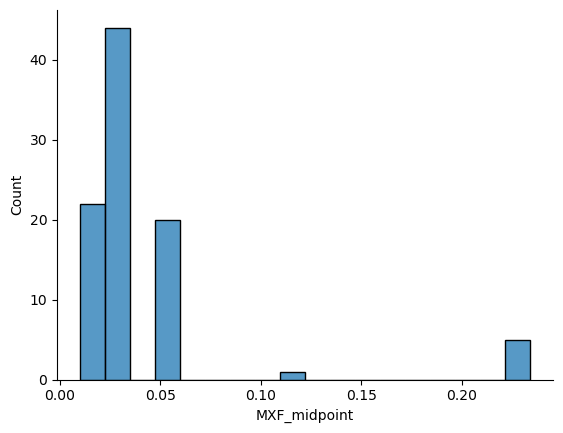

In [105]:
sns.histplot(data=df_MIC_with_bounds,
             x=f"{drug}_midpoint"
            )

sns.despine()
plt.show()

In [28]:
h37Rv_1 = [(seq.id, seq.seq) for seq in SeqIO.parse("/n/data1/hms/dbmi/farhat/mtb_data/h37rv/h37rv.fna", "fasta")]
h37Rv_2 = [(seq.id, seq.seq) for seq in SeqIO.parse("/n/data1/hms/dbmi/farhat/Sanjana/H37Rv/ref_genome.fna", "fasta")]

In [49]:
drug_loci.query("Drug=='Delamanid'")

,Drug,Locus,Start,End
29,Delamanid,Rv2983,3339000,3339762
30,Delamanid,fbiAB,3640142,3642881
31,Delamanid,ddn,3986733,3987299
32,Delamanid,fbiC,1302856,1305501
33,Delamanid,fgd1,490706,491793
34,Delamanid,ndh,2101651,2103183


In [50]:
drug_loci.query("Drug=='Ethionamide'")

,Drug,Locus,Start,End
16,Ethionamide,ethA,4326004,4327548
17,Ethionamide,ethR,4327474,4328199
18,Ethionamide,inhA,1673397,1675011
19,Ethionamide,mshA,575301,576790
20,Ethionamide,ndh,2101651,2103183


In [51]:
cc_df.query("antb=='DELAMANID'")

,antb,ABBR,m7h10,m7h11,lj,mgit960/mgit7h9,UKMYC,MYCOTB,BMD,nsw_sensititre
21,DELAMANID,DLM,NaN,0.016,NaN,NaN,0.12,NaN,NaN,NaN


In [133]:
drug = 'RIF'
# data_for_model = pd.read_csv(os.path.join(data_dir, drug, "data_for_model.csv"))
combined_MIC = pd.read_csv(os.path.join(data_dir, drug, "combined_MIC.csv"))

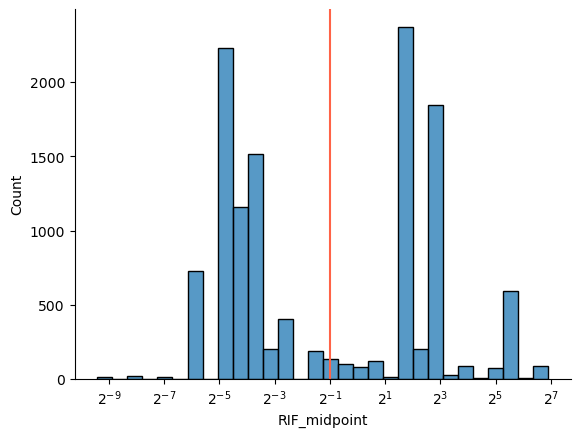

In [134]:
sns.histplot(data=combined_MIC,
             x=f'{drug}_midpoint',
             log_scale=2
            )

cc = 0.5
plt.axvline(cc, color='tomato')

sns.despine()
plt.show()

In [135]:
combined_MIC['DB_OF_ORIGIN'].value_counts()

DB_OF_ORIGIN
CRyPTIC            10310
farhat_internal     1436
CASS                 404
NICD                 396
EXIT-RIF             353
JATA-KIT             342
PATRIC_20191206      285
Wadsworth            248
Alland                91
TDR_TB                85
Cox                   48
JATA-Mongolia         41
Kreiswirth            39
NSW                   19
IS-1007_reseqTB        2
Name: count, dtype: int64

In [137]:
combined_MIC.query("DB_OF_ORIGIN=='Alland'")

,ROLLINGDB_ID,RIF_PHENOTYPE_QUALITY,RIF_lower_bound,RIF_midpoint,RIF_upper_bound,MEDIA_NORM,RIF_lower_bound_NORM,RIF_midpoint_NORM,RIF_upper_bound_NORM,MEDIA,DB_OF_ORIGIN
14008,TDR1,NaN,0.093600,0.093600,inf,NaN,NaN,NaN,NaN,NaN,Alland
14009,TDR5,NaN,0.000000,0.001463,0.002925,NaN,NaN,NaN,NaN,NaN,Alland
14010,TDR6,NaN,0.093600,0.093600,inf,NaN,NaN,NaN,NaN,NaN,Alland
14011,TDR7,NaN,0.023400,0.035100,0.046800,NaN,NaN,NaN,NaN,NaN,Alland
14012,TDR19,NaN,0.011700,0.017550,0.023400,NaN,NaN,NaN,NaN,NaN,Alland
...,...,...,...,...,...,...,...,...,...,...,...
14094,B91,NaN,0.002925,0.004387,0.005850,NaN,NaN,NaN,NaN,NaN,Alland
14095,B94,NaN,0.000000,0.001463,0.002925,NaN,NaN,NaN,NaN,NaN,Alland
14096,da301,NaN,0.093600,0.093600,inf,NaN,NaN,NaN,NaN,NaN,Alland
14097,da824,NaN,0.093600,0.093600,inf,NaN,NaN,NaN,NaN,NaN,Alland


In [142]:
df_MIC_with_bounds.index.values

array(['TDR1', 'TDR5', 'TDR6', 'TDR7', 'TDR19', 'TDR21', 'TDR28', 'TDR29',
       'TDR31', 'TDR32', 'TDR33', 'TDR34', 'TDR36', 'TDR37', 'TDR42',
       'TDR50', 'TDR51', 'TDR52', 'TDR54', 'TDR58', 'TDR64', 'TDR65',
       'TDR67', 'TDR69', 'TDR71', 'TDR72', 'TDR73', 'TDR74', 'TDR77',
       'TDR81', 'TDR85', 'TDR86', 'TDR87', 'TDR89', 'TDR91', 'TDR92',
       'TDR93', 'TDR99', 'TDR100', 'TDR101', 'TDR104', 'TDR105', 'TDR106',
       'TDR109', 'TDR111', 'TDR114', 'TDR116', 'TDR120', 'TDR123',
       'TDR126', 'TDR128', 'TDR132', 'TDR133', 'TDR138', 'TDR143',
       'TDR144', 'TDR146', 'TDR148', 'TDR150', 'TDR151', 'TDR152',
       'TDR153', 'TDR155', 'TDR156', 'TDR162', 'TDR163', 'TDR167',
       'TDR172', 'TDR173', 'TDR180', 'TDR188', 'TDR191', 'TDR192',
       'TDR193', 'TDR195', 'TDR196', 'TDR198', 'TDR216', 'The210',
       'CDC1551', 'Erdmann', 'HN878', 'B13', 'B18', 'B44', 'B61', 'B91',
       'B94', 'da301', 'da824', 'da405', 'H37Rv'], dtype=object)

In [143]:
isolate_metadata.query("ROLLINGDB_ID.str.contains('tdr', case=False)").ROLLINGDB_ID.values

array(['TDR_001', 'TDR_002', 'TDR_003', 'TDR_004', 'TDR_005', 'TDR_006',
       'TDR_007_S79_L002', 'TDR_008', 'TDR_009', 'TDR_010', 'TDR_011',
       'TDR_012', 'TDR_013', 'TDR_014', 'TDR_015', 'TDR_016', 'TDR_017',
       'TDR_018', 'TDR_019', 'TDR_020', 'TDR_021', 'TDR_022', 'TDR_023',
       'TDR_024', 'TDR_025', 'TDR_026', 'TDR_027', 'TDR_028', 'TDR_029',
       'TDR_030', 'TDR_031', 'TDR_032', 'TDR_033', 'TDR_034', 'TDR_035',
       'TDR_036', 'TDR_037', 'TDR_038', 'TDR_039', 'TDR_040', 'TDR_041',
       'TDR_042', 'TDR_043', 'TDR_044', 'TDR_045', 'TDR_046', 'TDR_047',
       'TDR_048', 'TDR_049', 'TDR_050', 'TDR_051', 'TDR_052', 'TDR_053',
       'TDR_054', 'TDR_055', 'TDR_056', 'TDR_057', 'TDR_058', 'TDR_059',
       'TDR_060', 'TDR_061', 'TDR_062', 'TDR_063', 'TDR_064', 'TDR_065',
       'TDR_066', 'TDR_067', 'TDR_068', 'TDR_069', 'TDR_070', 'TDR_071',
       'TDR_072', 'TDR_073', 'TDR_074', 'TDR_075', 'TDR_076', 'TDR_077',
       'TDR_078', 'TDR_079', 'TDR_080', 'TDR_081', 'T

In [21]:
def add_args_to_bash_script(fName):

    with open(fName, 'r') as file:
        lines = file.readlines()

    no_change_lines = [line for line in lines if 'python' not in line]
    change_lines = [line for line in lines if 'python' in line]
    
    assert len(change_lines) == 1
    change_lines = change_lines[0].split(' ')

    if '-start' in change_lines:
        return None

    new_line = 'python3 -u data_processing/make_MSA.py -f ' + change_lines[3] + ' -start ' + change_lines[4] + ' -end ' + change_lines[5] + ' -sense ' + change_lines[6] + ' -o ' + change_lines[7] + ' --save-fasta' 
    
    with open(fName, 'w+') as file:

        for line in no_change_lines:
            file.write(line)

        file.write(new_line + '\n')

In [27]:
for fName in glob.glob("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/*/fastas/*.sh"):
    add_args_to_bash_script(fName)
    print(f"bash {fName}")

bash /n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/RIF/fastas/rpoZ.sh
bash /n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/RIF/fastas/rpoBC.sh
bash /n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/RIF/fastas/rpoA.sh
bash /n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/PZA/fastas/panD.sh
bash /n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/PZA/fastas/pncA.sh
bash /n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/PZA/fastas/rpsA.sh
bash /n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/PZA/fastas/clpC1.sh
bash /n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/DLM/fastas/ddn.sh
bash /n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/LEV/fastas/gyrBA.sh
bash /n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/MXF/fastas/gyrBA.sh
bash /n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/INH/fastas/katG.sh
bash /n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/INH/fastas/inhA.sh
bash /n/data1/hms/dbmi/farhat/Sanjana/MIC_data/si

In [26]:
seq_df = [(seq.id, str(seq.seq)) for seq in SeqIO.parse("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/BDQ/fastas/mmpSL5.fasta", 'fasta')]
seq_df = pd.DataFrame(seq_df)

In [27]:
len(seq_df), seq_df[1].nunique()

(9024, 360)

In [29]:
lengths_lst = []

for seq in seq_df[1].values:
    len_seq = len(seq.replace('-', ''))
    lengths_lst.append(len_seq)

In [31]:
np.argsort(lengths_lst)

array([5011, 2773, 4855, ..., 5180, 8483, 5956])

In [35]:
lengths_lst[5011], lengths_lst[5956], lengths_lst[-1]

(3389, 3413, 3404)

In [40]:
seq_df[0].values[5956]

'SAMEA8718734'

In [13]:
for script in glob.glob("/home/sak0914/bash_scripts/*.sh"):
    print(f"bash {script}")

bash /home/sak0914/bash_scripts/Rv0678.sh
bash /home/sak0914/bash_scripts/Rv2983.sh
bash /home/sak0914/bash_scripts/atpE.sh
bash /home/sak0914/bash_scripts/ddn.sh
bash /home/sak0914/bash_scripts/ethA.sh
bash /home/sak0914/bash_scripts/ethR.sh
bash /home/sak0914/bash_scripts/fbiAB.sh
bash /home/sak0914/bash_scripts/fbiC.sh
bash /home/sak0914/bash_scripts/fgD1.sh
bash /home/sak0914/bash_scripts/inhA.sh
bash /home/sak0914/bash_scripts/mmpSL5.sh
bash /home/sak0914/bash_scripts/mshA.sh
bash /home/sak0914/bash_scripts/mtrBA.sh
bash /home/sak0914/bash_scripts/ndh.sh
bash /home/sak0914/bash_scripts/pepQ.sh
bash /home/sak0914/bash_scripts/rplC.sh
bash /home/sak0914/bash_scripts/rrl.sh
bash /home/sak0914/bash_scripts/tsnR.sh


In [10]:
pncA_df.loc[pncA_df[0]=='SAMN05915259'][1].values

array(['---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------'],
      dtype=object)

In [8]:
pncA_df.loc[pncA_df[1].str.endswith('-')]

,0,1
0,SAMEA3392614,----------------------------------------------...
42,SAMEA3403355,ATGCGGGCGTTGATCATCGTCGACGTGCAGAACGACT----TCTGC...
99,SAMN05915259,----------------------------------------------...
131,SAMN05916222,----------------------------------------------...
179,SAMN05916296,----------------------------------------------...
201,SAMN05916324,----------------------------------------------...
243,SAMN05916417,----------------------------------------------...
305,SAMN05918556,----------------------------------------------...
424,SAMN05918734,ATGCGGGCGTTGATCATCGTCGACGTGCAGAACGACT----TCTGC...
520,SAMN05919591,ATGCGGGCGTTGATCATCGTC-------------------------...


In [21]:
for drug in ['BDQ', 'CFZ', 'DLM']:
    print(f"02_clean_pheno_data.py {drug}")

02_clean_pheno_data.py BDQ
02_clean_pheno_data.py CFZ
02_clean_pheno_data.py DLM


In [25]:
drug = 'LZD'
paths = pd.read_csv(f"/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/{drug}/combined_paths_for_aln.txt", sep='\t', header=None)
new_path = "/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/VCF_clean"

new_paths = []

for path in paths[0].values:
    new_fName = os.path.join(new_path, os.path.basename(path).replace('_variants', ''))
    assert os.path.isfile(new_fName)
    new_paths.append(new_fName)

pd.Series(new_paths).to_csv(f"/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/{drug}/combined_paths_for_aln_clean.txt", sep='\t', header=None, index=False)

In [113]:
seq = [(seq.id, str(seq.seq)) for seq in SeqIO.parse("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/BDQ/fastas/Rv0678.fasta", "fasta")]
seq_df = pd.DataFrame(seq)
seq_df.head()

,0,1
0,SAMEA104362043,CGCCCTCCGCCTCTGCCGCATGAAGTTCACGCCGGTCTGGTGACGC...
1,SAMEA104362045,CGCCCTCCGCCTCTGCCGCATGAAGTTCACGCCGGTCTGGTGACGC...
2,SAMEA104362046,CGCCCTCCGCCTCTGCCGCATGAAGTTCACGCCGGTCTGGTGACGC...
3,SAMEA104362047,CGCCCTCCGCCTCTGCCGCATGAAGTTCACGCCGGTCTGGTGACGC...
4,SAMEA104362048,CGCCCTCCGCCTCTGCCGCATGAAGTTCACGCCGGTCTGGTGACGC...


In [114]:
seq_df[1].nunique()

183

In [115]:
len(seq_df)

9024

In [38]:
group1_WHO_variants = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/group1_WHO_variants.tsv", sep='\t')

In [44]:
who_variants.loc[who_variants['FINAL CONFIDENCE GRADING']=='1) Assoc w R'].query(f"drug=='Ethionamide'")

,drug,gene,mutation,variant,tier,effect,genomic position,algorithm_pass,Present_SOLO_SR,Present_SOLO_R,...,Additional grading criteria applied,FINAL CONFIDENCE GRADING,Comment,CHANGES vs ver1,"Relaxed thresholds simulation (BDQ_Rv0678, CFZ_Rv0678, INH_katG, DLM_ddn/fbiA/fbiB/fbiC/fgd1/Rv2983)",Silent mutation,Listed in abridged tables,Additional grading,Footnote,CHANGES vs ver1.1
8887,Ethionamide,ethA,LoF,ethA_LoF,1,LoF,"(see ""Genomic_coordinates"" sheet)",1.0,1291.0,658.0,...,NaN,1) Assoc w R,NaN,UP from AwRI to AwR,NaN,NaN,yes,NaN,NaN,4
8953,Ethionamide,ethA,p.Arg207Gly,ethA_p.Arg207Gly,1,missense_variant,"(see ""Genomic_coordinates"" sheet)",1.0,57.0,36.0,...,NaN,1) Assoc w R,NaN,No change,NaN,NaN,yes,NaN,NaN,1
9386,Ethionamide,ethA,p.Lys37fs,ethA_p.Lys37fs,1,frameshift,"(see ""Genomic_coordinates"" sheet)",1.0,164.0,81.0,...,NaN,1) Assoc w R,NaN,UP from AwRI to AwR,NaN,NaN,yes,NaN,NaN,4
9392,Ethionamide,ethA,p.Met1?,ethA_p.Met1?,1,start_lost,"(see ""Genomic_coordinates"" sheet)",1.0,99.0,52.0,...,NaN,1) Assoc w R,NaN,UP from AwRI to AwR,NaN,NaN,yes,NaN,NaN,4
9671,Ethionamide,ethA,p.Tyr235fs,ethA_p.Tyr235fs,1,frameshift,"(see ""Genomic_coordinates"" sheet)",1.0,35.0,24.0,...,NaN,1) Assoc w R,NaN,UP from AwRI to AwR,NaN,NaN,yes,NaN,NaN,4
9874,Ethionamide,inhA,c.-777C>T,inhA_c.-777C>T,1,upstream_gene_variant,1673425,1.0,1434.0,939.0,...,NaN,1) Assoc w R,Alias fabG1_c.-15C>T,No change,NaN,NaN,yes,NaN,L,1


In [ ]:
bash 04_subset_variants_regions_interest.sh samples_fNames_for_subset.tsv

In [85]:
pd.concat([drug_loci, eth_df, bdq_df, lzd_df, dlm_df]).to_csv("data_processing/data_utils/drug_loci.csv", index=False)

In [100]:
drug_loci = pd.read_csv("data_processing/data_utils/drug_loci.csv")
drug_loci_for_bed = drug_loci[['Start', 'End']].drop_duplicates()
drug_loci_for_bed.columns = ['BEG', 'END']
drug_loci_for_bed['BEG'] -= 1
drug_loci_for_bed['CHROM'] = 'NC_000962.3'
drug_loci_for_bed[['CHROM', 'BEG', 'END']].to_csv("data_processing/data_utils/drug_loci.bed", index=False, sep='\t')

In [65]:
eth_df = pd.DataFrame({'Drug': ['Ethionamide']*5, 'Locus': ['ethA', 'ethR', 'inhA', 'mshA', 'ndh'], 'Start': [4326004, 4327474, 1673397, 575301, 2101651], 'End': [4327548, 4328199, 1675011, 576790, 2103183]})
eth_df

,Drug,Locus,Start,End
0,Ethionamide,ethA,4326004,4327548
1,Ethionamide,ethR,4327474,4328199
2,Ethionamide,inhA,1673397,1675011
3,Ethionamide,mshA,575301,576790
4,Ethionamide,ndh,2101651,2103183


In [70]:
bdq_df = pd.DataFrame({'Drug': ['Bedaquiline']*5, 'Locus': ['mmpSL5', 'Rv0678', 'pepQ', 'atpE', 'mtrBA'], 'Start': [775586, 778906, 2859300, 1460997, 3623159], 'End': [778989, 779487, 2860451, 1461290, 3627418]})
bdq_df

,Drug,Locus,Start,End
0,Bedaquiline,mmpSL5,775586,778989
1,Bedaquiline,Rv0678,778906,779487
2,Bedaquiline,pepQ,2859300,2860451
3,Bedaquiline,atpE,1460997,1461290
4,Bedaquiline,mtrBA,3623159,3627418


In [76]:
lzd_df = pd.DataFrame({'Drug': ['Linezolid']*3, 'Locus': ['rrl', 'rplC', 'tsnR'], 'Start': [1473504, 800203, 1851991], 'End': [1476795, 801462, 1854388]})
lzd_df

,Drug,Locus,Start,End
0,Linezolid,rrl,1473504,1476795
1,Linezolid,rplC,800203,801462
2,Linezolid,tsnR,1851991,1854388


In [83]:
dlm_df = pd.DataFrame({'Drug': ['Delamanid']*6, 'Locus': ['Rv2983', 'fbiAB', 'ddn', 'fbiC', 'fgd1', 'ndh'], 'Start': [3339000, 3640142, 3986733, 1302856, 490706, 2101651], 'End': [3339762, 3642881, 3987299, 1305501, 491793, 2103183]})
dlm_df

,Drug,Locus,Start,End
0,Delamanid,Rv2983,3339000,3339762
1,Delamanid,fbiAB,3640142,3642881
2,Delamanid,ddn,3986733,3987299
3,Delamanid,fbiC,1302856,1305501
4,Delamanid,fgd1,490706,491793
5,Delamanid,ndh,2101651,2103183


,Drug,Locus,Start,End
0,Rifampicin,rpoBC,759480,767320
1,Rifampicin,rpoA,3877464,3878507
2,Rifampicin,rpoZ,1565003,1565425
3,Isoniazid,katG,2153235,2156705
4,Isoniazid,ahpC,2725478,2726780
5,Isoniazid,inhA,1673397,1675011
6,Isoniazid,kasA,2517696,2519365
7,Pyrazinamide,pncA,2288681,2289241
8,Pyrazinamide,clpC1,4038158,4040759
9,Pyrazinamide,rpsA,1833493,1834987


In [74]:
drug_gene_mapping.query("Drug=='Delamanid'")

,Drug,Gene,Tier
34,Delamanid,ndh,2
35,Delamanid,Rv2983,1
36,Delamanid,fbiA,1
37,Delamanid,ddn,1
38,Delamanid,fbiC,1
39,Delamanid,fbiB,1
40,Delamanid,fgd1,1


In [56]:
drug_gene_mapping = pd.read_csv("~/who-analysis/data/drug_gene_mapping.csv")

In [23]:
drug = 'ETH'

In [25]:
output_dir = os.path.join("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs", drug.upper())

if not os.path.isdir(output_dir):
    os.mkdir(output_dir)

if drug in df_rollingDB.columns:
    df_rollingDB_single_drug = split_mic_ranges(df_rollingDB, drug)
    df_rollingDB_single_drug = normalize_MICs(df_rollingDB_single_drug, drug, cc_df)
    df_rollingDB_single_drug = df_rollingDB_single_drug.rename(columns={'BioSample': 'ROLLINGDB_ID'})[['ROLLINGDB_ID', 'DB_OF_ORIGIN', 'MEDIA'] + list(df_rollingDB_single_drug.columns[df_rollingDB_single_drug.columns.str.contains(drug)])].dropna(subset=f"{drug}_midpoint_NORM", axis=0)
else:
    df_rollingDB_single_drug = pd.DataFrame()

ValueError: Some MICs for ETH were not normalized

In [30]:
df_rollingDB_single_drug = split_mic_ranges(df_rollingDB, drug)


array(['7H9', '7H10', 'LJ', '7H11'], dtype=object)

In [35]:
df_rollingDB_single_drug['MEDIA'].value_counts()

MEDIA
7H10    1281
7H9       61
LJ        50
7H11       3
Name: count, dtype: int64

In [34]:
cc_df_internal.loc['ETHIONAMIDE']

ABBR                     ETA
7H10                     5.0
7H11                    10.0
LJ                      40.0
MGIT                     5.0
UKMYC                    4.0
MYCOTB                   5.0
BMD                      NaN
NSW_sensititre_plate     5.0
Name: ETHIONAMIDE, dtype: object

In [49]:
who_variants

,drug,gene,mutation,variant,tier,effect,genomic position,algorithm_pass,Present_SOLO_SR,Present_SOLO_R,...,Additional grading criteria applied,FINAL CONFIDENCE GRADING,Comment,CHANGES vs ver1,"Relaxed thresholds simulation (BDQ_Rv0678, CFZ_Rv0678, INH_katG, DLM_ddn/fbiA/fbiB/fbiC/fgd1/Rv2983)",Silent mutation,Listed in abridged tables,Additional grading,Footnote,CHANGES vs ver1.1
0,Amikacin,eis,c.1023C>G,eis_c.1023C>G,1,synonymous_variant,"(see ""Genomic_coordinates"" sheet)",1.0,NaN,NaN,...,Silent mutation,4) Not assoc w R - Interim,NaN,Now listed,NaN,Silent mutation,no,NaN,NaN,0
1,Amikacin,eis,c.105C>G,eis_c.105C>G,1,synonymous_variant,"(see ""Genomic_coordinates"" sheet)",1.0,NaN,NaN,...,Silent mutation,4) Not assoc w R - Interim,NaN,Now listed,NaN,Silent mutation,no,NaN,NaN,0
2,Amikacin,eis,c.1068G>A,eis_c.1068G>A,1,synonymous_variant,"(see ""Genomic_coordinates"" sheet)",1.0,NaN,NaN,...,Silent mutation,4) Not assoc w R - Interim,NaN,Now listed,NaN,Silent mutation,no,NaN,NaN,0
3,Amikacin,eis,c.1086A>G,eis_c.1086A>G,1,synonymous_variant,"(see ""Genomic_coordinates"" sheet)",1.0,NaN,NaN,...,Silent mutation,4) Not assoc w R - Interim,NaN,Now listed,NaN,Silent mutation,no,NaN,NaN,0
4,Amikacin,eis,c.-10G>A,eis_c.-10G>A,1,upstream_gene_variant,2715342,1.0,328.0,18.0,...,NaN,5) Not assoc w R,NaN,UP from Uncertain to NotAwR,NaN,NaN,yes,NaN,NaN,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21584,Streptomycin,whiB7,p.Val38Leu,whiB7_p.Val38Leu,1,missense_variant,"(see ""Genomic_coordinates"" sheet)",1.0,1.0,0.0,...,NaN,3) Uncertain significance,NaN,No change,NaN,NaN,no,NaN,NaN,1
21585,Streptomycin,whiB7,p.Val65fs,whiB7_p.Val65fs,1,frameshift,"(see ""Genomic_coordinates"" sheet)",1.0,1.0,0.0,...,NaN,3) Uncertain significance,NaN,No change,NaN,NaN,no,NaN,NaN,1
21586,Streptomycin,whiB7,p.Val65Phe,whiB7_p.Val65Phe,1,missense_variant,"(see ""Genomic_coordinates"" sheet)",0.0,0.0,0.0,...,NaN,3) Uncertain significance,NaN,New Uncertain,NaN,NaN,no,NaN,NaN,0
21587,Streptomycin,whiB7,p.Val6Phe,whiB7_p.Val6Phe,1,missense_variant,"(see ""Genomic_coordinates"" sheet)",1.0,1.0,0.0,...,NaN,3) Uncertain significance,NaN,New Uncertain,NaN,NaN,no,NaN,NaN,0


In [37]:
cc_df.query("Drug=='Ethionamide'")

,Medium,Value,Drug
14,UKMYC5,4.0,Ethionamide
15,UKMYC6,4.0,Ethionamide
42,7H11,10.0,Ethionamide
46,MGIT,5.0,Ethionamide
52,LJ,40.0,Ethionamide
65,7H10,5.0,Ethionamide
82,MYCOTB,4.0,Ethionamide


0
1000
2000
3000
4000
5000
6000
7000
8000
9000
10000
11000
12000
13000
14000
3718/14125 isolates have suspicious indels


In [35]:
duplicate_indels_df.query("Locus=='katG'").drop_duplicates('KEEP_POS')

,VCF,Isolate,KEEP_POS,DROP_POS,Locus
0,/n/scratch/users/s/sak0914/MIC_model_variants/...,22598,2153725,2153741,katG
511,/n/scratch/users/s/sak0914/MIC_model_variants/...,PE143_S9,2156072,2156097,katG
2549,/n/scratch/users/s/sak0914/MIC_model_variants/...,SAMEA7563248,2156220,2156238,katG


In [4]:
len(duplicate_indels_df.drop_duplicates(['KEEP_POS'], keep='first')), len(duplicate_indels_df.drop_duplicates(['DROP_POS'], keep='first')), len(duplicate_indels_df.drop_duplicates(['KEEP_POS', 'DROP_POS'], keep='first'))

(13, 13, 13)

In [13]:
pd.DataFrame(duplicate_indels_df.groupby(['KEEP_POS', 'DROP_POS'])['Locus'].value_counts()).reset_index()

,KEEP_POS,DROP_POS,Locus,count
0,759627,759648,rpoBC,1
1,760349,760364,rpoBC,1
2,766479,766495,rpoBC,2
3,1674189,1674211,inhA,1
4,1834711,1834732,rpsA,1
5,2153725,2153741,katG,3707
6,2156072,2156097,katG,2
7,2156220,2156238,katG,1
8,2288791,2288809,pncA,1
9,2288829,2288846,pncA,2


In [5]:
len(duplicate_indels_df)

3724

In [37]:
3718/3724

0.9983888292158969